# Formula 1 Podium Prediction: Milestone 1

**Unit of analysis:** one driver entering one race. **Target:** the driver finishes on the podium (`positionOrder` <= 3). **Prediction cutoff:** after qualifying, before the race starts.

## Contents

0. Setup
1. Initial EDA (raw data, before cleaning)
2. Audit and cleaning, table by table: results, qualifying, seasons, races, circuits, drivers, constructors, status, driver_standings, constructor_standings, constructor_results, sprint_results, lap_times, pit_stops
3. Cleaning summary: decisions and findings
4. EDA after cleaning
5. Modelling table
6. Data-engineering questions
   - Q1: which circuits turn a front-row start into a podium, and did that change after 2014?
   - Q2: do drivers podium more often at home, after controlling for starting position?
   - Q3: which constructors have the highest mechanical-retirement rate in 2014–2021 vs 2022–2024?

# 0. Setup

In [308]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# the data folder: the Kaggle input when running on Kaggle, the local data/ folder otherwise
KAGGLE_DIR = '/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020'
DATA_DIR = KAGGLE_DIR if os.path.exists(KAGGLE_DIR) else 'data'


def load(name):
    """Read one table from its CSV with the text \\N read as missing.
    Every call reads the file again, so each table we clean is a new copy and the CSVs are never changed."""
    return pd.read_csv(os.path.join(DATA_DIR, f'{name}.csv'), na_values=['\\N'])


# checking and verifying the tables we have
for f in sorted(os.listdir(DATA_DIR)):
    print(f)

circuits.csv
constructor_results.csv
constructor_standings.csv
constructors.csv
driver_standings.csv
drivers.csv
lap_times.csv
pit_stops.csv
qualifying.csv
races.csv
results.csv
seasons.csv
sprint_results.csv
status.csv


In [309]:
# reading the tables above
raw_before = {f[:-4]: pd.read_csv(os.path.join(DATA_DIR, f))
              for f in sorted(os.listdir(DATA_DIR)) if f.endswith('.csv')}

In [310]:
# confirming the tables in the dataset
list(raw_before.keys())

['circuits',
 'constructor_results',
 'constructor_standings',
 'constructors',
 'driver_standings',
 'drivers',
 'lap_times',
 'pit_stops',
 'qualifying',
 'races',
 'results',
 'seasons',
 'sprint_results',
 'status']

In [311]:
# visualizing the size of each table in the dataset
for name, df in raw_before.items():
    print(name, df.shape) # (rows, columns)

circuits (77, 9)
constructor_results (12625, 5)
constructor_standings (13391, 7)
constructors (212, 5)
driver_standings (34863, 7)
drivers (861, 9)
lap_times (589081, 6)
pit_stops (11371, 7)
qualifying (10494, 9)
races (1125, 18)
results (26759, 18)
seasons (75, 2)
sprint_results (360, 16)
status (139, 2)


# 1. Initial EDA (raw data, before cleaning)

This section looks at the 14 tables exactly as they are read, with no options and no cleaning, to see what needs fixing. `raw_before` is never changed, so section 4 can compare the cleaned tables with it.

In [312]:
# one line per table: size, the text \N, and text (object) columns, as read with no cleaning
pre_overview = pd.DataFrame({
    name: {'rows': len(df),
           'columns': df.shape[1],
           'cells with \\N': int((df == '\\N').sum().sum()),
           'columns with \\N': int((df == '\\N').any().sum()),
           'missing seen by pandas': int(df.isna().sum().sum()),
           'object columns': int((df.dtypes == object).sum())}
    for name, df in raw_before.items()}).T
pre_overview

,rows,columns,cells with \N,columns with \N,missing seen by pandas,object columns
circuits,77,9,0,0,0,5
constructor_results,12625,5,12608,1,0,1
constructor_standings,13391,7,0,0,0,1
constructors,212,5,0,0,0,4
driver_standings,34863,7,0,0,0,1
drivers,861,9,1559,2,0,8
lap_times,589081,6,0,0,0,1
pit_stops,11371,7,0,0,0,2
qualifying,10494,9,11600,3,68,3
races,1125,18,11349,11,0,14


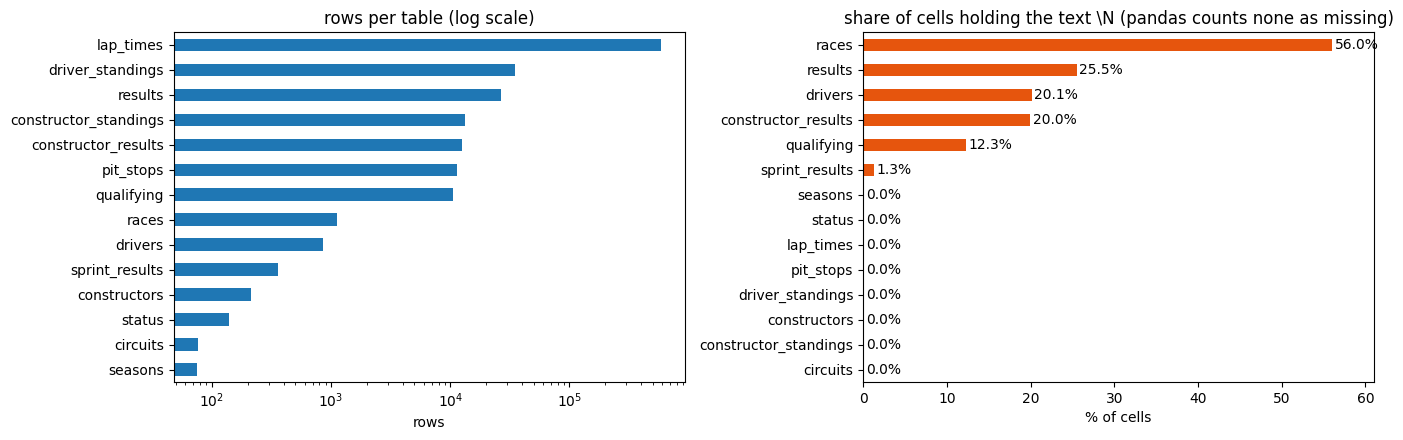

In [313]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

pre_overview['rows'].sort_values().plot.barh(ax=axes[0], logx=True)
axes[0].set_title('rows per table (log scale)')
axes[0].set_xlabel('rows')

pre_share = (100 * pre_overview['cells with \\N'] / (pre_overview['rows'] * pre_overview['columns'])).sort_values()
pre_share.plot.barh(ax=axes[1], color='#e6550d')
for i, v in enumerate(pre_share):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center')
axes[1].set_xlim(0, pre_share.max() + 5)
axes[1].set_title('share of cells holding the text \\N (pandas counts none as missing)')
axes[1].set_xlabel('% of cells')

plt.tight_layout()
plt.show()

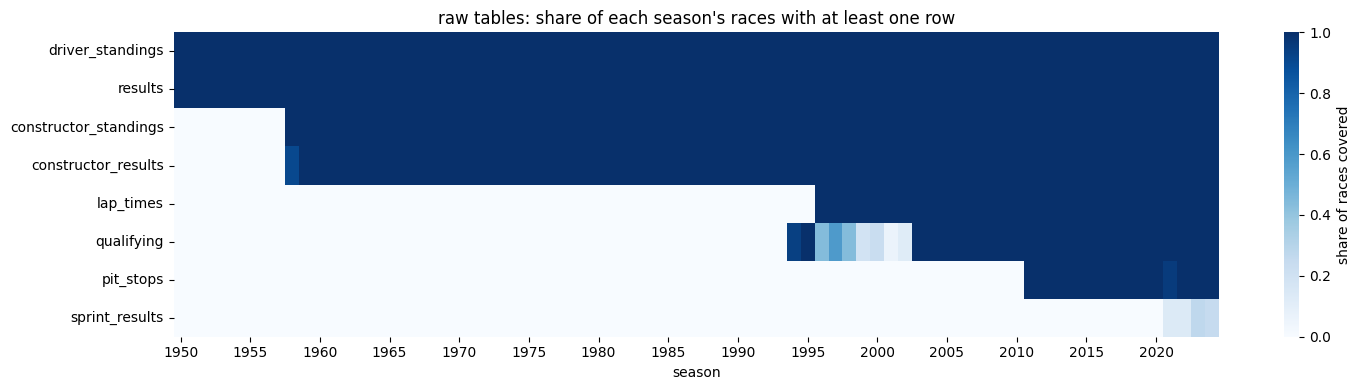

,first season
driver_standings,1950
results,1950
constructor_standings,1958
constructor_results,1958
lap_times,1996
qualifying,1994
pit_stops,2011
sprint_results,2021


In [314]:
# which seasons each table covers: share of a season's races with at least one row in the table
pre_races = raw_before['races'][['raceId', 'year']]
pre_per_season = pre_races.groupby('year').size()

pre_cov = pd.DataFrame({
    name: (df[['raceId']].drop_duplicates().merge(pre_races, on='raceId')
           .groupby('year').size().reindex(pre_per_season.index, fill_value=0) / pre_per_season)
    for name, df in raw_before.items() if 'raceId' in df.columns and name != 'races'}).T
pre_cov = pre_cov.loc[pre_cov.mean(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(15, 4))
sns.heatmap(pre_cov, cmap='Blues', vmin=0, vmax=1, xticklabels=5,
            cbar_kws={'label': 'share of races covered'})
plt.title("raw tables: share of each season's races with at least one row")
plt.xlabel('season')
plt.ylabel('')
plt.tight_layout()
plt.show()

# first season with any row, per table
pre_cov.apply(lambda r: r[r > 0].index.min(), axis=1).rename('first season').to_frame()

result rows: 26759 | podium rows: 3397 | podium rate: 12.7%
rows in a repeated (raceId, driverId) pair: 176


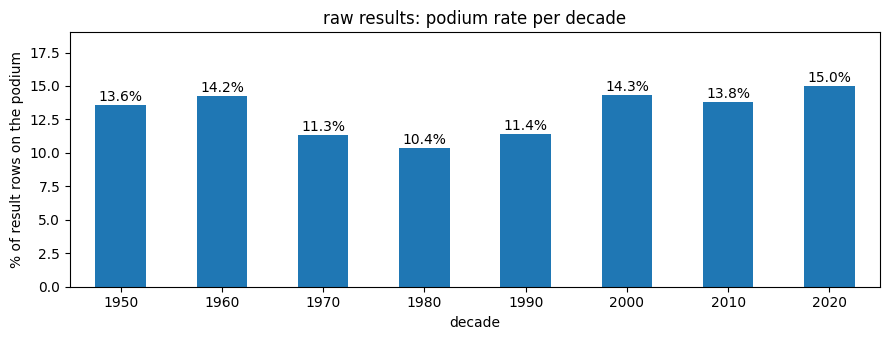

In [315]:
# the target in the raw results: how rare is a podium, and is the grain already one row per driver per race?
pre_res = raw_before['results'].merge(raw_before['races'][['raceId', 'year']], on='raceId')
pre_res['podium'] = pre_res.positionOrder <= 3

print('result rows:', len(pre_res), '| podium rows:', int(pre_res.podium.sum()),
      f'| podium rate: {pre_res.podium.mean():.1%}')
print('rows in a repeated (raceId, driverId) pair:', int(pre_res.duplicated(['raceId', 'driverId'], keep=False).sum()))

pre_rate = pre_res.groupby(pre_res.year // 10 * 10).podium.mean() * 100
ax = pre_rate.plot.bar(rot=0, figsize=(9, 3.5))
for i, v in enumerate(pre_rate):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center')
ax.set_ylim(0, pre_rate.max() + 4)
plt.xlabel('decade')
plt.ylabel('% of result rows on the podium')
plt.title('raw results: podium rate per decade')
plt.tight_layout()
plt.show()

### What the raw data shows, and what it means for the cleaning

**Hidden missing values.** Six tables hold the text `\N` in place of a missing value: `races` (56.0% of its cells), `results` (25.5%), `drivers` (20.1%), `constructor_results` (20.0%), `qualifying` (12.3%) and `sprint_results` (1.3%). pandas counts none of them as missing, and it reads every column that contains `\N` as text, which is why `results` has 9 text columns and `races` has 14. → Every table is read with `\N` as missing (`load()`), and the types are checked again table by table in section 2.

**Coverage over time.** `results` and `driver_standings` cover every season from 1950. The constructor tables start in 1958, `qualifying` in 1994 (complete in 1994 and 1995, then only partly until 2003), `lap_times` in 1996, `pit_stops` in 2011 and `sprint_results` in 2021, and only a few races per season have a sprint. → A feature built from one of these tables is empty before its first season, so the coverage is checked for each table in section 2 and decides the training window.

**The target.** 3,397 of the 26,759 result rows (12.7%) are podiums, between 10.4% (1980s) and 15.0% (2020s) per decade, so the positive class is rare in every era. 176 rows sit in a repeated (`raceId`, `driverId`) pair, so the table is not yet one row per driver per race. → The duplicates are handled first, in the `results` part of section 2.

# 2. Audit and cleaning, table by table

Each table follows the same steps: look at the data, state the problem, decide, fix, and check the fix. Type conversions are made next to the check that showed they were needed.

Only the duplicate driver-race rows are removed in this section, because every later join needs one row per driver per race. Rows that do not belong in the modelling table (`never_ran`, `is_indy500`) are flagged here and removed in section 5, after the history features are built, so they still count in a driver's history.

## `Results Table`

In [316]:
raw_before['results'].head(10)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1
5,6,18,6,3,8,13,6,6,6,3.0,57,\N,\N,50,14,1:29.639,212.974,11
6,7,18,7,5,14,17,7,7,7,2.0,55,\N,\N,54,8,1:29.534,213.224,5
7,8,18,8,6,1,15,8,8,8,1.0,53,\N,\N,20,4,1:27.903,217.180,5
8,9,18,9,2,4,2,\N,R,9,0.0,47,\N,\N,15,9,1:28.753,215.100,4
9,10,18,10,7,12,18,\N,R,10,0.0,43,\N,\N,23,13,1:29.558,213.166,3


In [317]:
raw_before['results'].dtypes

resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number              object
grid                 int64
position            object
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds        object
fastestLap          object
rank                object
fastestLapTime      object
fastestLapSpeed     object
statusId             int64
dtype: object

In [318]:
raw_before['results'].isna().sum()    

resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
dtype: int64

In [319]:
# but there are \N values in the cells, so let us count them
raw_before['results'].head()                       
(raw_before['results'] == '\\N').sum()             

resultId               0
raceId                 0
driverId               0
constructorId          0
number                 6
grid                   0
position           10953
positionText           0
positionOrder          0
points                 0
laps                   0
time               19079
milliseconds       19079
fastestLap         18507
rank               18249
fastestLapTime     18507
fastestLapSpeed    18507
statusId               0
dtype: int64

## 1. Results table: types and missing values

*Hypothesis: the `\N` text is why pandas reports 0 missing values and reads some numeric columns as `object`.*

*Prediction: after reading `\N` as missing, the missing counts will equal the `\N` counts, and some `object` columns will become numeric.*

In [320]:
results = load('results')

In [321]:
before = raw_before['results']

cmp = pd.DataFrame({
    'dtype_before':   before.dtypes.astype(str),
    'dtype_after':    results.dtypes.astype(str),
    'missing_before': before.isna().sum(),          
    'sentinel_before': (before == '\\N').sum(),     
    'missing_after':  results.isna().sum(),         
})
cmp

,dtype_before,dtype_after,missing_before,sentinel_before,missing_after
resultId,int64,int64,0,0,0
raceId,int64,int64,0,0,0
driverId,int64,int64,0,0,0
constructorId,int64,int64,0,0,0
number,object,float64,0,6,6
grid,int64,int64,0,0,0
position,object,float64,0,10953,10953
positionText,object,object,0,0,0
positionOrder,int64,int64,0,0,0
points,float64,float64,0,0,0


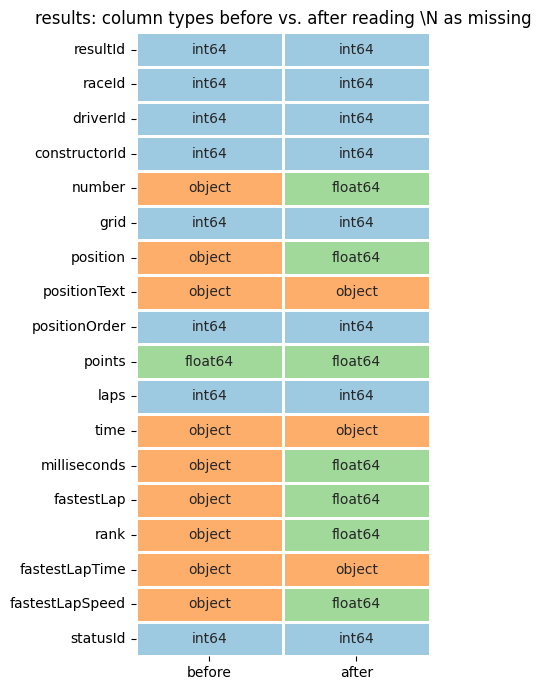

In [322]:
from matplotlib.colors import ListedColormap

# more clear visualization 
before = raw_before['results'].dtypes.astype(str)
after = results.dtypes.astype(str)
types = pd.DataFrame({'before': before, 'after': after})

codes = {'int64': 0, 'float64': 1, 'object': 2}
num = types.apply(lambda s: s.map(lambda t: codes.get(t, 3)))   # 3 = any other type

plt.figure(figsize=(4.5, 7))
sns.heatmap(num, annot=types, fmt='', cbar=False, linewidths=1, linecolor='white',
            cmap=ListedColormap(['#9ecae1', '#a1d99b', '#fdae6b', '#d9d9d9']),
            vmin=0, vmax=3)
plt.title('results: column types before vs. after reading \\N as missing')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [323]:
# the missing values per column in the results table
results.isna().sum()

resultId               0
raceId                 0
driverId               0
constructorId          0
number                 6
grid                   0
position           10953
positionText           0
positionOrder          0
points                 0
laps                   0
time               19079
milliseconds       19079
fastestLap         18507
rank               18249
fastestLapTime     18507
fastestLapSpeed    18507
statusId               0
dtype: int64

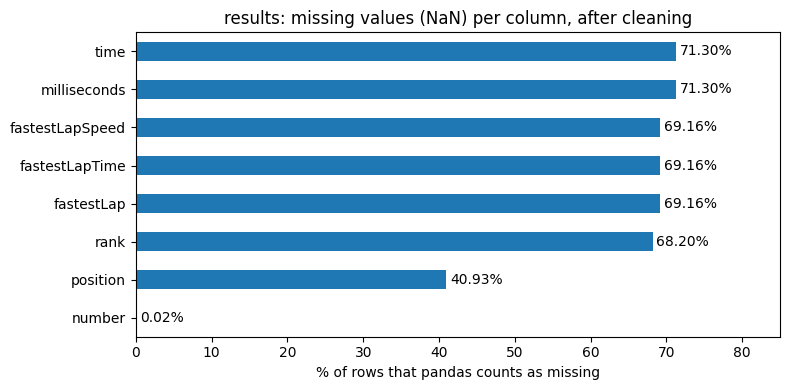

In [324]:
# visualization
pct_after = (results.isna().mean() * 100)
pct_after = pct_after[pct_after > 0].sort_values()

ax = pct_after.plot.barh(figsize=(8, 4))
for i, v in enumerate(pct_after):
    ax.text(v + 0.5, i, f'{v:.2f}%', va='center')

ax.set_xlim(0, 85)
plt.xlabel('% of rows that pandas counts as missing')
plt.title('results: missing values (NaN) per column, after cleaning')
plt.tight_layout()
plt.show()

## 2. Columns that are still `object` after reading `\N` as missing

After the reload, only three columns remain `object`: `positionText`, `time` and `fastestLapTime`.

- `positionText` holds codes (R, F, W, D, E, N, or a number), so text is its correct type. It is analyz ed separately.
- `time` and `fastestLapTime` hold durations written as strings, so they need a closer look.

**Method:** replace every digit with a `9` and count how many rows share each string pattern. This shows how many different formats a column contains without reading rows by eye.

In [325]:
for col in ['fastestLapTime', 'time']:
    shapes = (results[col].dropna()
              .str.replace(r'\d', '9', regex=True)
              .value_counts())
    print(col, '-', len(shapes), 'different shapes,', shapes.sum(), 'rows')
    print(shapes.to_string(), '\n')
    # checking if the column hold consistent format for the data
    # fastestLapTime does while time does not as mentioned in the guide
    # A leading + means a gap from winner
    # no + means the winner's full time. One column holds two different meanings.

fastestLapTime - 1 different shapes, 8252 rows
fastestLapTime
9:99.999    8252 

time - 21 different shapes, 7680 rows
time
+99.999        2973
+9:99.999      1614
9:99:99.999     765
+9.999          732
+9:99.99        281
+9:99.9         279
+99.9           259
+99.99          243
9:99:99.9       242
9:99:99.99      118
+9.9             73
+9.99            68
+99:99.99        13
+999.999         10
+99:99.9          3
+9:99.9999        2
99:99.999         1
99:99.9           1
+9:99             1
9:99.999          1
+99.9999          1 



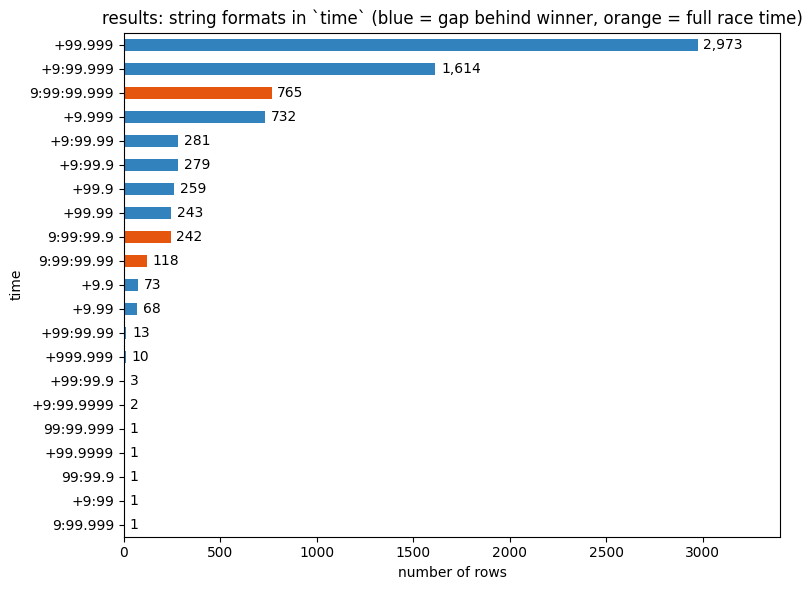

In [326]:
shapes = (results['time'].dropna()
          .str.replace(r'\d', '9', regex=True)
          .value_counts()
          .sort_values())

colors = ['#3182bd' if s.startswith('+') else '#e6550d' for s in shapes.index]

ax = shapes.plot.barh(figsize=(8, 6), color=colors)
for i, v in enumerate(shapes):
    ax.text(v + 30, i, f'{v:,}', va='center')

ax.set_xlim(0, 3400)
plt.xlabel('number of rows')
plt.title('results: string formats in `time` (blue = gap behind winner, orange = full race time)')
plt.tight_layout()
plt.show()

### `time`: what the string formats mean

**Two kinds of values share one column**
- **Leading `+` (6,552 rows):** the gap between this driver and the race winner, e.g. `+5.478` means 5.478 seconds behind.
- **No `+` (1,128 rows):** a full race time, which is the winner's total time, e.g. `1:34:50.616`.

So `time` mixes a duration and a difference in one column, which is why it cannot be treated as a single numeric field.

**Why there are 21 formats: the values are not zero-padded**
The strings are written at their natural length, so the pattern changes with the size of the number. Looking at the gaps by magnitude:
- under 10 seconds, `+9.999`: 873 rows
- 10 to 99 seconds, `+99.999`: 3,476 rows
- 1 to 9 minutes, `+9:99.999`: 2,177 rows
- 10 minutes or more, `+99:99.999`: 16 rows
- 100 seconds or more written as seconds, `+999.999`: 10 rows

Full race times follow the same logic: `9:99:99.999` has hours, while a few short races have no hours (`99:99.999`, 3 rows).

**The number of decimals also varies (0 to 4)**
Most rows have 3 decimals, but many have 1 or 2, and a handful have 0 or 4. We have not checked why. One possible explanation is that precision changed between eras, but that needs a check by season before we claim it.

**Decision**
Parsing would need a separate rule for each combination of hours, minutes, sign and decimals, and the result would duplicate `milliseconds`, which already holds the race duration as a number. We keep `time` as text and use `milliseconds`. `time` is a post-race column, so it is never used as a feature.

**Still to confirm:** that `time` and `milliseconds` are missing in the same rows, meaning they agree.

In [327]:
print('same rows missing:', (results.time.isna() == results.milliseconds.isna()).all())

same rows missing: True


**Decision:** keep `time` as text and use `milliseconds` as the numeric race duration. The dataset documentation (Kaggle) describes `milliseconds` as the finishing time in milliseconds, and `time` mixes full race times and gaps in 21 formats. Both are post-race columns and are never used as features, so we did not verify the two against each other any further.

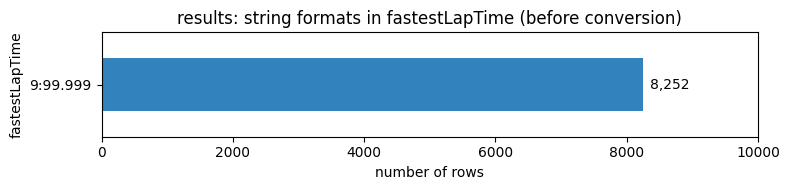

In [328]:
shapes_f = (results['fastestLapTime'].dropna()
            .str.replace(r'\d', '9', regex=True)
            .value_counts()
            .sort_values())

ax = shapes_f.plot.barh(figsize=(8, 2), color='#3182bd')
for i, v in enumerate(shapes_f):
    ax.text(v + 100, i, f'{v:,}', va='center')

ax.set_xlim(0, 10000)
plt.xlabel('number of rows')
plt.title('results: string formats in fastestLapTime (before conversion)')
plt.tight_layout()
plt.show()

### `fastestLapTime`

**Finding:** all 8,252 non-missing values share a single pattern (`9:99.999`, i.e. minutes:seconds.milliseconds, like "1:27.452"). This equals 26,759 rows minus 18,507 missing values, so no values are hidden.

**Decision:** convert it to numeric seconds in a new column, `fastestLapTime_s` (minutes × 60 + seconds). Because there is only one format, a single rule covers every row. This is the "lap-time strings to numeric seconds" step the brief asks for.

In [329]:
parts = results['fastestLapTime'].str.split(':', expand=True)
results['fastestLapTime_s'] = parts[0].astype(float) * 60 + parts[1].astype(float)

In [330]:
print('non-missing before:', results['fastestLapTime'].notna().sum())
print('non-missing after: ', results['fastestLapTime_s'].notna().sum())
results['fastestLapTime_s'].describe()

non-missing before: 8252
non-missing after:  8252


count    8252.000000
mean       90.827595
std        12.338956
min        55.404000
25%        80.848250
50%        90.267500
75%        99.476750
max       202.300000
Name: fastestLapTime_s, dtype: float64

### `positionText`

This is the last of the three columns that stayed `object` after reading `\N` as missing (the other two, `time` and `fastestLapTime`, are covered above). Its text type is correct, because it holds codes and not numbers. What makes it worth a closer look is that it seems to explain why `position` is empty in 10,953 rows (41%).

According to the course's F1 introduction, `positionText` holds the position as text, or a letter code when the driver has no official position:

| Code | Meaning |
|---|---|
| R | Retired (and not classified, see note) |
| D | Disqualified |
| E | Excluded |
| W | Withdrawn |
| F | Failed to qualify |
| N | Not classified |

**Note:** a driver can retire and still be classified, getting a numeric `position`, if they completed at least 90% of the winner's laps. So `R` only appears for retirements without an official position. We rely on the course description for this and did not verify it against `status`.

**Hypothesis:** a missing `position` always comes with a letter in `positionText`, and a filled `position` always comes with a number.

**Prediction:** a cross-tabulation of "`position` is missing" against "`positionText` is a number" will have two empty cells: missing with a number, and filled with a letter.

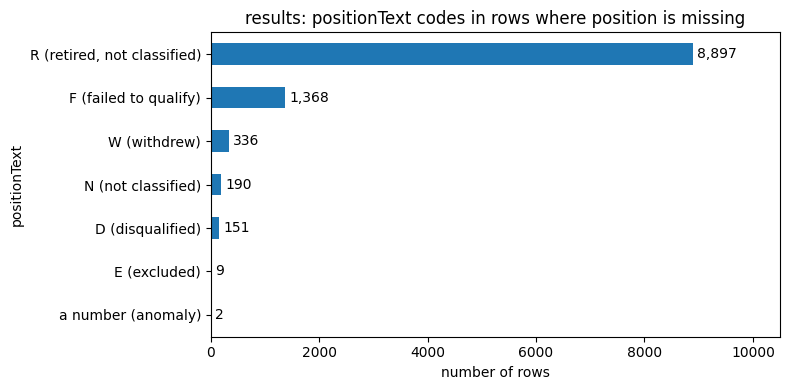

In [331]:
miss = results[results.position.isna()].copy()

def label(code):
    names = {'R': 'R (retired, not classified)', 'F': 'F (failed to qualify)', 'W': 'W (withdrew)',
             'N': 'N (not classified)', 'D': 'D (disqualified)', 'E': 'E (excluded)'}
    return names.get(code, 'a number (anomaly)')

counts = miss.positionText.map(label).value_counts().sort_values()

ax = counts.plot.barh(figsize=(8, 4))
for i, v in enumerate(counts):
    ax.text(v + 80, i, f'{v:,}', va='center')

ax.set_xlim(0, 10500)
plt.xlabel('number of rows')
plt.title('results: positionText codes in rows where position is missing')
plt.tight_layout()
plt.show()

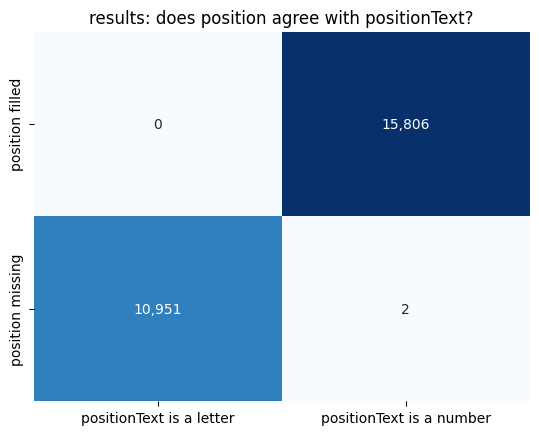

In [332]:
df = results
ct = pd.crosstab(df.position.isna(), df.positionText.str.isdigit())
ct.index = ['position filled', 'position missing']
ct.columns = ['positionText is a letter', 'positionText is a number']

sns.heatmap(ct, annot=True, fmt=',d', cmap='Blues', cbar=False)
plt.title('results: does position agree with positionText?')
plt.ylabel('')
plt.xlabel('')
plt.show()

### The 2 rows where `position` is missing but `positionText` is a number

The crosstab shows 2 rows where `position` is empty even though `positionText` holds a number.

**Question:** are these drivers classified or not?

**What we check:** their `status` (how the race ended), their `grid` (whether they took the start) and their `laps` compared with the winner's laps (the course's F1 introduction says classification requires completing at least 90% of the winner's laps).

In [333]:
odd = results[results.position.isna() & results.positionText.str.isdigit()]

winner_laps = results.groupby('raceId').laps.max()          # most laps completed in each race
out = (odd.merge(raw_before['races'][['raceId', 'year', 'name']], on='raceId')
          .merge(raw_before['drivers'][['driverId', 'surname']], on='driverId')
          .merge(raw_before['status'], on='statusId'))

out['race_laps'] = out.raceId.map(winner_laps)
out['pct_of_race'] = (100 * out.laps / out.race_laps).round(1)

out[['year', 'name', 'surname', 'status', 'grid', 'laps', 'race_laps', 'pct_of_race', 'positionText', 'positionOrder']]

,year,name,surname,status,grid,laps,race_laps,pct_of_race,positionText,positionOrder
0,2005,Australian Grand Prix,Button,+1 Lap,8,56,57,98.2,11,11
1,2005,Australian Grand Prix,Sato,+2 Laps,20,55,57,96.5,14,14


**Result:** both rows are from the 2005 Australian Grand Prix. Button (grid 8) finished 11th, one lap down (56 of 57 laps, 98.2%), and Sato (grid 20) finished 14th, two laps down (55 of 57 laps, 96.5%). Both took the start, both reached the flag with status "+1 Lap" and "+2 Laps", and both completed more than 90% of the race distance. Their `positionText` and `positionOrder` agree. They are therefore classified finishers whose `position` value is missing from the dataset, not unclassified drivers.

**Decision:** this is a data gap in `position` only. The target is built from `positionOrder`, which is complete and consistent for these rows, so the target is unaffected. We leave `position` as missing and document the two rows.

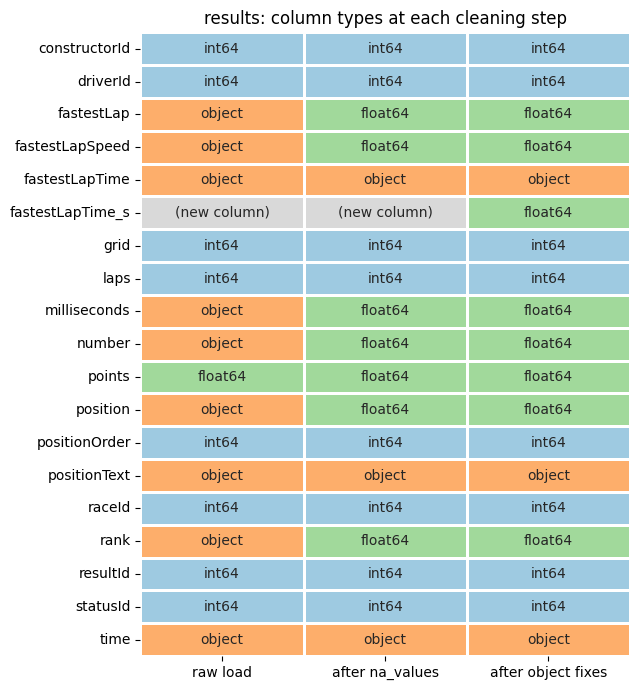

In [334]:
from matplotlib.colors import ListedColormap

stage1 = raw_before['results'].dtypes.astype(str)
stage2 = results.drop(columns='fastestLapTime_s').dtypes.astype(str)   # state right after the na_values reload
stage3 = results.dtypes.astype(str)                                    # now, after the object investigation

types = pd.DataFrame({'raw load': stage1,
                      'after na_values': stage2,
                      'after object fixes': stage3}).fillna('(new column)')

codes = {'int64': 0, 'float64': 1, 'object': 2}
num = types.apply(lambda s: s.map(lambda t: codes.get(t, 3)))   # 3 = new column

plt.figure(figsize=(6.5, 7))
sns.heatmap(num, annot=types, fmt='', cbar=False, linewidths=1, linecolor='white',
            cmap=ListedColormap(['#9ecae1', '#a1d99b', '#fdae6b', '#d9d9d9']),
            vmin=0, vmax=3)
plt.title('results: column types at each cleaning step')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 3. Remaining missing values in `results`

After reading `\N` as missing, seven columns still contain missing values: `time`, `milliseconds`, `fastestLap`, `rank`, `fastestLapTime`, `fastestLapSpeed` and `number`. (`position` is covered in its own section.)

**Six of them describe the outcome of the race itself** (`time`, `milliseconds`, `fastestLap`, `rank`, `fastestLapTime`, `fastestLapSpeed`). They are not known at the prediction cutoff (after qualifying, before the race starts), so using them would be data leakage and they cannot be features. We leave them as missing and do not fill them: filling columns we never use adds nothing, and for the race columns it would invent results that did not happen.

**`number` is different.** It is the car number, which is not an outcome of the race, so the leakage argument does not apply to it. It is missing in only 6 rows. Before deciding what to do, we look at which rows they are.

In [335]:
missing_num = results[results.number.isna()]

(missing_num.merge(raw_before['races'][['raceId', 'year', 'name']], on='raceId')
            .merge(raw_before['drivers'][['driverId', 'surname']], on='driverId')
            .merge(raw_before['constructors'][['constructorId', 'name']], on='constructorId', suffixes=('_race', '_team'))
            .merge(raw_before['status'], on='statusId')
            [['year', 'name_race', 'surname', 'name_team', 'grid', 'positionText', 'status', 'positionOrder']])

,year,name_race,surname,name_team,grid,positionText,status,positionOrder
0,1962,French Grand Prix,Marsh,BRM,0,W,Withdrew,19
1,1962,French Grand Prix,Davis,Porsche,0,W,Withdrew,20
2,1962,French Grand Prix,Abate,Lotus-Climax,0,W,Withdrew,21
3,1962,French Grand Prix,Burgess,Cooper-Climax,0,W,Withdrew,22
4,1961,French Grand Prix,Bordeu,Lotus-Climax,0,W,Withdrew,28
5,1963,South African Grand Prix,Hailwood,Lola,0,W,Withdrew,23


**Result:** the 6 rows with a missing `number` are all from the early 1960s (1961 to 1963). All have `positionText` = `W` and `status` = Withdrew, and all have `grid` = 0, even though `grid` has no `\N`. This suggests the missing `number` may be related to these drivers having withdrawn, but the data does not say why no car number was recorded.

**Next question:** `grid` normally starts at 1 (pole position), so a value of 0 is unusual. The course's F1 introduction says a `grid` of 0 may mean a pit-lane start ("verify in EDA"). The rows above are drivers who withdrew, which does not look like a pit-lane start, so we will need to investigate what `grid` = 0 means in `results` as a whole.

**Decision for `number`:** leave as missing, no fill. It is an identifier and not a feature.

## 4. One row per driver per race

Each row of the modeling table is one prediction: "will this driver finish on the podium in this race?" That requires the pair (`raceId`, `driverId`) to be unique. The course material says duplicates come from shared drives in early F1 (mainly the 1950s), when drivers swapped cars mid-race, so a driver can have two result rows in one race.

**Question:** how many pairs appear more than once, and in which years?

**Method:** count the rows whose (`raceId`, `driverId`) pair occurs more than once.

,duplicated pairs,rows involved
2 rows for the same driver in one race,79,158
3 rows for the same driver in one race,6,18
Total,85,176


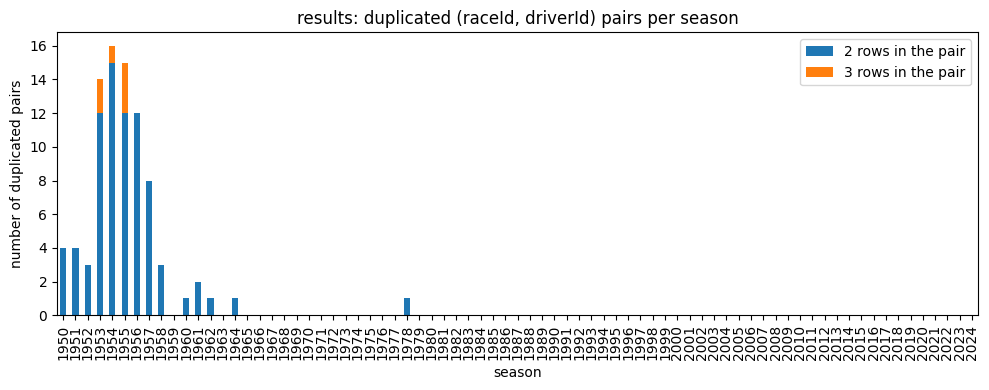

In [336]:
dup_rows = results[results.duplicated(['raceId', 'driverId'], keep=False)].merge(
    raw_before['races'][['raceId', 'year']], on='raceId')

# one line per duplicated pair, with how many rows it has
pair_size = (dup_rows.groupby(['raceId', 'driverId', 'year']).size()
                     .rename('rows_in_pair').reset_index())

# Table: how many pairs have 2 rows, how many have 3
summary = (pair_size.groupby('rows_in_pair').size().rename('duplicated pairs').to_frame()
           .assign(**{'rows involved': lambda d: d['duplicated pairs'] * d.index}))
summary.index = [f'{i} rows for the same driver in one race' for i in summary.index]
summary.loc['Total'] = summary.sum()
display(summary)

# Chart: duplicated pairs per season, split by 2 or 3 rows
per_year = pair_size.groupby(['year', 'rows_in_pair']).size().unstack(fill_value=0)
all_years = raw_before['races'].year
per_year = per_year.reindex(range(all_years.min(), all_years.max() + 1), fill_value=0)
per_year.columns = [f'{c} rows in the pair' for c in per_year.columns]

ax = per_year.plot.bar(stacked=True, figsize=(10, 4))
plt.xlabel('season')
plt.ylabel('number of duplicated pairs')
plt.title('results: duplicated (raceId, driverId) pairs per season')
plt.tight_layout()
plt.show()

In [337]:
pairs = (results[results.duplicated(['raceId', 'driverId'], keep=False)]
         .merge(raw_before['races'][['raceId', 'year']], on='raceId')
         .groupby(['raceId', 'driverId', 'year']).size()
         .rename('rows').reset_index())

print('duplicated pairs:', len(pairs), '| rows involved:', pairs.rows.sum())
print(pairs.rows.value_counts().sort_index().rename('pairs').rename_axis('rows in the pair'))

per_year = pairs.groupby('year').size()
print('pairs from 1950 to 1957:', (pairs.year <= 1957).sum())
print('pairs after 1957:       ', (pairs.year > 1957).sum())
print('peak season:', per_year.idxmax(), 'with', per_year.max(), 'pairs')

print('\npairs after 1957, per season:')
print(pairs[pairs.year > 1957].groupby('year').size().to_string())

duplicated pairs: 85 | rows involved: 176
rows in the pair
2    79
3     6
Name: pairs, dtype: int64
pairs from 1950 to 1957: 76
pairs after 1957:        9
peak season: 1954 with 16 pairs

pairs after 1957, per season:
year
1958    3
1960    1
1961    2
1962    1
1964    1
1978    1


**Result:** (`raceId`, `driverId`) is not unique in `results`: 85 pairs (176 rows) appear more than once. 79 pairs have 2 rows and 6 pairs have 3 rows (all from 1953 to 1955). 76 of the 85 pairs are from 1950 to 1957, with the peak in 1954 (16 pairs), as the course material says. The other 9 pairs are from 1958 to 1978 and are examined separately below.

**Next questions:**
1. What does a duplicated pair look like in the data (grid, laps, position, points)?
2. What are the 9 pairs after 1957, and why do they exist?

In [338]:
look = (dup_rows.merge(raw_before['drivers'][['driverId', 'surname']], on='driverId')
                .merge(raw_before['races'][['raceId', 'name']].rename(columns={'name': 'race'}), on='raceId')
                .merge(raw_before['constructors'][['constructorId', 'name']].rename(columns={'name': 'team'}), on='constructorId')
                .merge(raw_before['status'], on='statusId')
                .sort_values(['year', 'raceId', 'driverId']))

cols = ['year', 'race', 'surname', 'team', 'grid', 'laps', 'positionText', 'positionOrder', 'points', 'status']

look[cols].head(12)

,year,race,surname,team,grid,laps,positionText,positionOrder,points,status
84,1950,Indianapolis 500,Bettenhausen,Deidt,8,30,R,31,0.0,Wheel bearing
88,1950,Indianapolis 500,Bettenhausen,Kurtis Kraft,9,136,5,5,1.0,+2 Laps
85,1950,French Grand Prix,Rosier,Talbot-Lago,6,10,R,12,0.0,Overheating
89,1950,French Grand Prix,Rosier,Talbot-Lago,15,56,6,6,0.0,+8 Laps
86,1950,Italian Grand Prix,Fangio,Alfa Romeo,1,23,R,15,1.0,Gearbox
91,1950,Italian Grand Prix,Fangio,Alfa Romeo,7,34,R,13,0.0,Engine
87,1950,Italian Grand Prix,Ascari,Ferrari,2,21,R,17,0.0,Engine
90,1950,Italian Grand Prix,Ascari,Ferrari,6,80,2,2,3.0,Finished
81,1951,French Grand Prix,Fangio,Alfa Romeo,1,55,11,11,0.0,+22 Laps
92,1951,French Grand Prix,Fangio,Alfa Romeo,7,77,1,1,5.0,Finished


**What a duplicated pair looks like:** we looked at the first 12 rows (6 pairs, from 1950 and 1951). In each pair the same driver appears twice in the same race, with different `grid` slots, different `laps`, and different results. In 5 of the 6 pairs, one row has far fewer laps and a retirement or a poor finish, while the other row has many more laps and a better finish. For example, Fangio (1951 French GP) has one row with 55 laps (11th) and another with 77 laps (1st, 5 points), and Ascari (1950 Italian GP) has a retirement after 21 laps and a 2nd place after 80 laps. In the sixth pair (Fangio, 1950 Italian GP) both rows are retirements, with 23 and 34 laps.

This is consistent with the shared drives described in the course's F1 introduction, where a driver's own car stops, and he continues the race in another car, getting a better result. The data does not state this directly, so it is our reading of the pattern. It also shows that the two rows of a pair are results of two different cars, so each row has its own `grid`, `laps` and `positionOrder`, and we have to choose which one stands for the driver in that race.

**Limit:** this is based on 6 of the 85 pairs. We have not checked the others.

In [339]:
d = dup_rows.copy()
g = d.groupby(['raceId', 'driverId'])

d['best_finish'] = d.positionOrder == g.positionOrder.transform('min')
d['most_laps']   = d.laps == g.laps.transform('max')

# per pair: does the best-finish row also have the most laps?
agree = d[d.best_finish].groupby(['raceId', 'driverId', 'year']).most_laps.any().rename('same_row').reset_index()

print(agree.same_row.value_counts().rename({True: 'best finish = most laps', False: 'different rows'}))

same_row
best finish = most laps    85
Name: count, dtype: int64


**Result:** in all 85 duplicated pairs, the row with the best `positionOrder` is also the row with the most laps. The rules "keep the best finish" and "keep the most laps" therefore choose the same row in every case.

**Consequence:** the choice between these two rules does not change the table. We can use either one, and we pick the one that is easier to justify.

In [340]:
print('pairs after 1957:', (pair_size.year > 1957).sum())
look[look.year > 1957][cols]

pairs after 1957: 9


,year,race,surname,team,grid,laps,positionText,positionOrder,points,status
9,1958,Monaco Grand Prix,Flockhart,Cooper,0,0,F,17,0.0,Did not qualify
10,1958,Monaco Grand Prix,Flockhart,BRM,0,0,F,27,0.0,Did not qualify
11,1958,French Grand Prix,Brooks,Vanwall,5,16,R,18,0.0,Engine
171,1958,French Grand Prix,Brooks,Vanwall,10,35,R,14,0.0,Engine
12,1958,Italian Grand Prix,Shelby,Maserati,17,1,R,18,0.0,Handling
172,1958,Italian Grand Prix,Shelby,Maserati,11,69,4,4,0.0,+1 Lap
8,1960,Argentine Grand Prix,Moss,Cooper-Climax,1,40,R,17,0.0,Suspension
173,1960,Argentine Grand Prix,Moss,Cooper-Climax,8,80,3,3,0.0,Finished
5,1961,British Grand Prix,Moss,Ferguson,20,56,D,19,0.0,Disqualified
6,1961,British Grand Prix,Moss,Lotus-Climax,5,44,R,21,0.0,Brakes


### The 9 duplicated pairs after 1957

The course's F1 introduction says shared drives were possible until 1957, but 9 duplicated pairs fall after that. Three in 1958, one in 1960, two in 1961, one in 1962, one in 1964 and one in 1978. We read all 18 rows. They fall into two groups.

**Group 1: both rows have laps (6 pairs)**
Brooks (1958 French GP), Shelby (1958 Italian GP), Moss (1960 Argentine GP), Moss (1961 British GP), Gregory (1961 United States GP) and Clark (1964 United States GP).
- Each row has its own `grid` slot, `laps` and result, so each is the result of one car.
- In every pair, the row with more laps also has the better `positionOrder`. For example, Moss (1960) has one row with 40 laps (retired) and one with 80 laps (3rd), and Shelby (1958) has one with 1 lap (retired) and one with 69 laps (4th).
- In 5 of the 6 pairs both rows belong to the same team. The exception is Moss (1961 British GP), with one row for Ferguson and one for Lotus-Climax.
- This is the same pattern as the 1950s pairs, so these are probably shared drives that happened after 1957. The data does not state that, so it is our reading.
- Two pairs are worth a note. Moss (1961) has a row with 56 laps and the status Disqualified (`grid` 20), and a row with 44 laps and a retirement (`grid` 5). The data does not say whether the disqualification came during or after the race. Clark (1964) has `grid` 1 in both rows (102 laps, 7th, Out of fuel; 54 laps, retired, Injection). One driver cannot start from the same slot in two cars, so at least one of the two grid values is unreliable, and the data does not say which. The starting slot therefore cannot tell the two rows apart.

**Group 2: `grid` = 0 and 0 laps in both rows (3 pairs)**
Flockhart (1958 Monaco GP), Greene (1962 British GP) and Ertl (1978 Italian GP).
- Each driver appears twice with a different team: Cooper and BRM, Lotus-Climax and Gilby, ATS and Ensign.
- The statuses are Did not qualify (Flockhart, both rows), Withdrew (Greene, both rows) and Did not qualify and Did not prequalify (Ertl).
- These drivers were entered with two cars and did not start in either. They are not shared drives. This explains the 1978 pair.

**Consequence for the keep rule:** the 3 pairs in group 2 cannot be separated by laps, since both rows have 0, and they do not belong in the modeling table anyway if non-starters are dropped. So the duplicate rule and the non-starter rule interact, and the order in which we apply them has to be stated.

In [341]:
print('pairs with equal positionOrder:', (results[results.duplicated(['raceId', 'driverId'], keep=False)]
      .groupby(['raceId', 'driverId']).positionOrder.nunique() == 1).sum())

pairs with equal positionOrder: 0


### Keep rule for duplicated pairs

**Rule:** for each (`raceId`, `driverId`), keep the row with the best `positionOrder` (the lowest number).

**Why:**
- In all 85 duplicated pairs, the row with the best `positionOrder` is also the row with the most laps, so "best finish" and "most laps" give the same table.
- Within the 85 pairs, no two rows share the same `positionOrder` (checked), so the rule always selects exactly one row and needs no tie-breaker.
- It does not use `grid`, which is unreliable inside a pair (Clark, 1964, has `grid` 1 in both rows).

**Order:** the rule is applied first, before any history features are built, because a driver with two rows in one race would otherwise be counted twice. The raw `results` table is left unchanged, and the rule is applied to a copy, `results_unique`.

**The 3 non-starter pairs:** Flockhart (1958), Greene (1962) and Ertl (1978) have `grid` = 0 and 0 laps in both rows, so the rule picks one of the two rows by `positionOrder` alone, and the choice does not matter. The row that is kept is still a `grid` = 0 row, so it is handled in the next section, together with the other `grid` = 0 rows.

In [342]:
results_unique = (results
    .sort_values(['raceId', 'driverId', 'positionOrder'])
    .drop_duplicates(['raceId', 'driverId'], keep='first')
    .sort_values('resultId')
    .reset_index(drop=True))

print('rows before:', len(results))
print('rows after: ', len(results_unique))
print('removed:    ', len(results) - len(results_unique))
print('(raceId, driverId) unique?', not results_unique.duplicated(['raceId', 'driverId']).any())

rows before: 26759
rows after:  26668
removed:     91
(raceId, driverId) unique? True


**Applied:** the rule removed 91 rows (176 rows in 85 pairs became 85 rows), leaving 26,668 rows in `results_unique`, and (`raceId`, `driverId`) is now unique. From here on, the analysis uses `results_unique`.

## 5. Key checks for `results`

**Primary key:** `resultId` should identify each row, so it must be unique and non-null.

**Foreign keys:** `results` points to four other tables: `raceId` to `races`, `driverId` to `drivers`, `constructorId` to `constructors` and `statusId` to `status`. Each foreign key must be non-null, and every value must exist in the parent table (no orphans). The parent keys must also be unique.

**Method:** count nulls and duplicates for `resultId`, and for each foreign key count the nulls and the values missing from the parent table. 

In [343]:
parents = {
    'raceId':        ('races',        raw_before['races'].raceId),
    'driverId':      ('drivers',      raw_before['drivers'].driverId),
    'constructorId': ('constructors', raw_before['constructors'].constructorId),
    'statusId':      ('status',       raw_before['status'].statusId),
}

rows = [{'check': 'primary key', 'column': 'resultId', 'points to': '-',
         'nulls': int(results.resultId.isna().sum()),
         'duplicates': int(results.resultId.duplicated().sum()),
         'orphans': '-', 'parent key unique': '-'}]

for col, (tbl, keys) in parents.items():
    rows.append({'check': 'foreign key', 'column': col, 'points to': f'{tbl}.{col}',
                 'nulls': int(results[col].isna().sum()),
                 'duplicates': '-',
                 'orphans': int((~results[col].dropna().isin(keys)).sum()),
                 'parent key unique': keys.is_unique})

pd.DataFrame(rows)

,check,column,points to,nulls,duplicates,orphans,parent key unique
0,primary key,resultId,-,0,0,-,-
1,foreign key,raceId,races.raceId,0,-,0,True
2,foreign key,driverId,drivers.driverId,0,-,0,True
3,foreign key,constructorId,constructors.constructorId,0,-,0,True
4,foreign key,statusId,status.statusId,0,-,0,True


**Result:** all checks pass for `results`. `resultId` is unique and non-null. `raceId`, `driverId`, `constructorId` and `statusId` have no nulls, no orphans (every value exists in its parent table), and each parent key is unique. Together with the (`raceId`, `driverId`) check on `results_unique`, the table has a valid primary key, valid foreign keys and one row per driver per race.

## 6. `grid`

**Question:** what does `grid` contain, and what does the value 0 mean in this data? We also look for other anomalies in the column.

**Method:**
1. Look at the distribution of `grid` values.
2. Split the `grid` = 0 rows by `positionText` and `status`.
3. Look at how they are spread over the decades.
4. Check `grid` for other anomalies.

This section uses `results_unique` (one row per driver per race).

rows: 26668
min grid: 0 | max grid: 34
negative values: 0
grid == 0: 1635


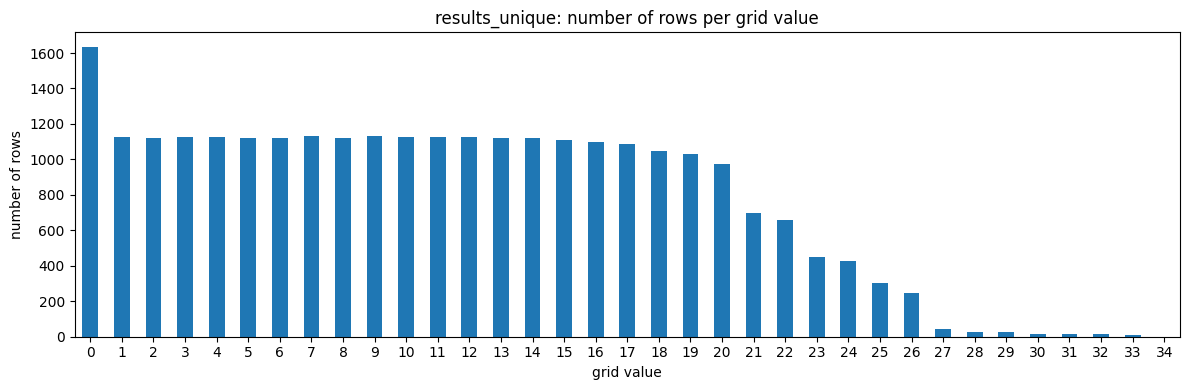

In [344]:
g = results_unique.grid

print('rows:', len(g))
print('min grid:', g.min(), '| max grid:', g.max())
print('negative values:', (g < 0).sum())
print('grid == 0:', (g == 0).sum())

counts = g.value_counts().sort_index()
ax = counts.plot.bar(figsize=(12, 4), rot=0)
plt.xlabel('grid value')
plt.ylabel('number of rows')
plt.title('results_unique: number of rows per grid value')
plt.tight_layout()
plt.show()

In [345]:
races_t   = raw_before['races'][['raceId', 'year', 'round', 'name']].copy()
drivers_t = raw_before['drivers'][['driverId', 'surname']]
constr_t  = raw_before['constructors'][['constructorId', 'name']].rename(columns={'name': 'team'})
status    = raw_before['status']

In [346]:
zero = results_unique[results_unique.grid == 0]

# one race per year: the one with the most grid==0 rows (earliest round on ties)
n_zero = (zero.groupby('raceId').size().rename('n_zero').reset_index()
              .merge(races_t, on='raceId'))
pick = (n_zero.sort_values(['year', 'n_zero', 'round'], ascending=[True, False, True])
              .drop_duplicates('year'))

rows = (zero.merge(pick[['raceId', 'year', 'round', 'name']], on='raceId')
            .merge(drivers_t, on='driverId')
            .merge(constr_t, on='constructorId')
            .merge(status, on='statusId')
            .sort_values(['year', 'positionOrder']))

cols = ['year', 'name', 'surname', 'team', 'positionOrder', 'positionText', 'grid', 'laps', 'status']

print('rows shown:', len(rows), '| years covered:', rows.year.min(), 'to', rows.year.max())
with pd.option_context('display.max_rows', None, 'display.width', 200):
    display(rows[cols])

print('years with no grid==0 at all:', sorted(set(races_t.year) - set(pick.year)))

rows shown: 311 | years covered: 1952 to 2024


,year,name,surname,team,positionOrder,positionText,grid,laps,status
276,1952,Italian Grand Prix,de Tornaco,Ferrari,25,F,0,0,Did not qualify
277,1952,Italian Grand Prix,Crespo,Maserati,26,F,0,0,Did not qualify
278,1952,Italian Grand Prix,de Graffenried,Maserati,27,F,0,0,Did not qualify
279,1952,Italian Grand Prix,Collins,HWM,28,F,0,0,Did not qualify
280,1952,Italian Grand Prix,Whitehead,Ferrari,29,F,0,0,Did not qualify
281,1952,Italian Grand Prix,Gaze,HWM,30,F,0,0,Did not qualify
282,1952,Italian Grand Prix,Aston,Aston Butterworth,31,F,0,0,Did not qualify
283,1952,Italian Grand Prix,Macklin,HWM,32,F,0,0,Did not qualify
284,1952,Italian Grand Prix,von Stuck,Ferrari,33,F,0,0,Did not qualify
285,1952,Italian Grand Prix,Dusio,Cisitalia,34,F,0,0,Did not qualify


years with no grid==0 at all: [1950, 1951, 1953, 1969, 2003, 2004, 2005, 2006, 2007, 2008, 2010, 2013, 2014]


code    D  E    F  R    W  number
decade                           
1950    0  0   48  0   19       0
1960    0  0   74  0  123       0
1970    0  0  329  0   21       0
1980    4  5  544  1   17       0
1990    2  2  342  0   11       0
2000    0  0    5  0    3       0
2010    0  0    4  7    4      13
2020    0  0    0  6    4      47


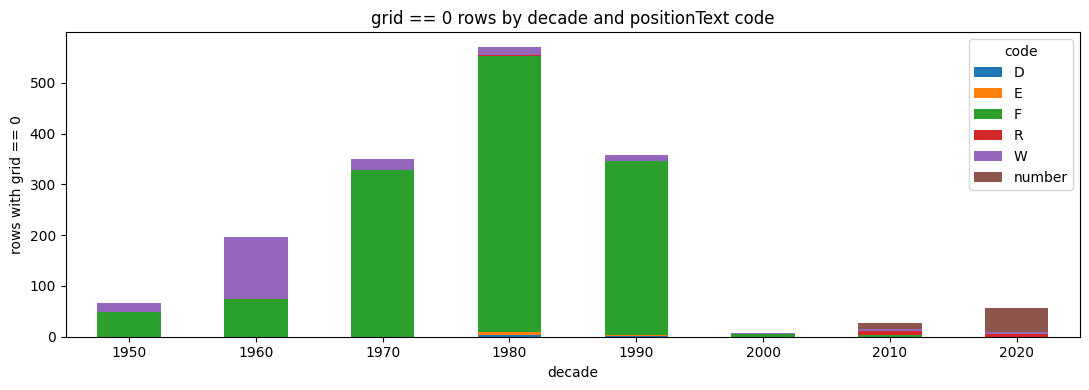

In [347]:
z = results_unique[results_unique.grid == 0].merge(raw_before['races'][['raceId', 'year']], on='raceId')

is_num = pd.to_numeric(z.positionText, errors='coerce').notna()
z['code'] = z.positionText.where(~is_num, 'number')
z['decade'] = (z.year // 10 * 10).astype(int)

ct = z.groupby(['decade', 'code']).size().unstack(fill_value=0)
print(ct)

ct.plot.bar(stacked=True, figsize=(11, 4), rot=0)
plt.xlabel('decade')
plt.ylabel('rows with grid == 0')
plt.title('grid == 0 rows by decade and positionText code')
plt.legend(title='code')
plt.tight_layout()
plt.show()

### What `grid` = 0 means

`grid` has no missing values, but 1,635 rows (about 6% of `results_unique`) have the value 0. The starting grid begins at 1 (pole position), so 0 is not a real starting slot. We looked at these rows through `positionText`, `status` and `laps`. As a sample we printed all `grid` = 0 rows for one race per year (the race with the most such rows in that year), and we counted all of them by decade and `positionText` code in the chart below.

**Observation 1: before 2000, the `grid` = 0 rows are almost all F and W.**
Of the 1,542 rows before 2000, 1,528 carry the codes F (did not qualify / did not prequalify / 107% rule / injury) or W (withdrew). The other 14 are D (disqualified), E (excluded) and one R. Every F, W, D and E row has `laps` = 0. Statuses such as "Engine" or "Accident" on W rows also show 0 laps, so these drivers never ran a lap of the race. The counts drop sharply after 1999 (8 rows in the 2000s).

**Observation 2: in the 2010s and 2020s the `grid` = 0 rows are different.**
All 60 rows with a numeric `positionText` (a classified finishing place) fall in 2010 or later, and so do 13 of the 14 R rows (retired). All 60 numeric rows have `laps` > 0, up to 78, and 12 of the 14 R rows have laps. Examples: Stroll finished 7th at the 2023 US Grand Prix with 56 laps, and Hartley retired on lap 1 at the 2018 British Grand Prix. These drivers raced, so a `grid` of 0 cannot mean "did not start" for them.

**Interpretation (hypothesis, not yet confirmed).**
The course material says a driver can start from the pit lane, which is not one of the numbered grid slots. A driver who raced with `grid` = 0 may therefore have started from the pit lane, which the dataset records as 0. The dataset has no pit-lane flag, so we cannot read this directly from `results`.

**Test: join with `qualifying`.**
`qualifying` records each driver's qualifying position separately from `grid`. If the hypothesis holds, `grid` = 0 drivers with `laps` > 0 should mostly have a qualifying position (they qualified and then started from the pit lane), while `grid` = 0 drivers with `laps` = 0 should mostly have none. `qualifying` only covers the later seasons, so we run the check on the years it covers. Older rows are judged from `laps` and `status` alone.

**Consequence for cleaning.**
Dropping every `grid` = 0 row would remove real race finishers. The rule we are considering separates the rows by whether the driver ran any laps. The final rule comes after the qualifying check.

In [348]:
import numpy as np

qual = load('qualifying')
races_t   = load('races')[['raceId', 'year', 'round', 'name']]
drivers_t = load('drivers')[['driverId', 'surname']]
status    = load('status')

# key check on qualifying before joining
print('qualifying rows:', len(qual))
print('duplicate (raceId, driverId):', qual.duplicated(['raceId', 'driverId']).sum())
print('qual position dtype:', qual.position.dtype, '| missing:', qual.position.isna().sum())

# join: qualifying.position renamed so it can't be confused with results.position
q = qual[['raceId', 'driverId', 'position']].rename(columns={'position': 'qual_pos'})
m = (results_unique
     .merge(q, on=['raceId', 'driverId'], how='left', validate='one_to_one')
     .merge(races_t[['raceId', 'year']], on='raceId'))

m['has_qual'] = m.qual_pos.notna()
print('rows after join:', len(m), '(results_unique has', len(results_unique), ')')

# is qualifying complete from a given year? share of results rows with a qualifying row, per year
cov_by_year = m.groupby('year').has_qual.mean()
print('\nshare of results rows with a qualifying row:')
print(cov_by_year[cov_by_year.index >= 1950].round(2).to_string())

qualifying rows: 10494
duplicate (raceId, driverId): 0
qual position dtype: int64 | missing: 0
rows after join: 26668 (results_unique has 26668 )

share of results rows with a qualifying row:
year
1950    0.00
1951    0.00
1952    0.00
1953    0.00
1954    0.00
1955    0.00
1956    0.00
1957    0.00
1958    0.00
1959    0.00
1960    0.00
1961    0.00
1962    0.00
1963    0.00
1964    0.00
1965    0.00
1966    0.00
1967    0.00
1968    0.00
1969    0.00
1970    0.00
1971    0.00
1972    0.00
1973    0.00
1974    0.00
1975    0.00
1976    0.00
1977    0.00
1978    0.00
1979    0.00
1980    0.00
1981    0.00
1982    0.00
1983    0.00
1984    0.00
1985    0.00
1986    0.00
1987    0.00
1988    0.00
1989    0.00
1990    0.00
1991    0.00
1992    0.00
1993    0.00
1994    0.88
1995    1.00
1996    0.44
1997    0.59
1998    0.44
1999    0.18
2000    0.24
2001    0.06
2002    0.12
2003    1.00
2004    1.00
2005    1.00
2006    1.00
2007    1.00
2008    1.00
2009    1.00
2010    1.00
2011    0.

In [349]:
QYEAR = 2003        # first year with (near-)complete qualifying coverage; change after reading the coverage table above
cov = m[m.year >= QYEAR].copy()

is_num = pd.to_numeric(cov.positionText, errors='coerce').notna()
cov['code'] = cov.positionText.where(~is_num, 'number')
cov['group'] = np.select(
    [(cov.grid == 0) & (cov.laps > 0), (cov.grid == 0) & (cov.laps == 0)],
    ['grid0_raced', 'grid0_no_laps'], default='grid>0')

print(f'years {QYEAR}+ only, {len(cov)} rows')
display(cov.groupby('group').agg(rows=('resultId', 'size'),
                                 with_qual=('has_qual', 'sum'),
                                 share_with_qual=('has_qual', 'mean')).round(3))

# the same split by code, grid==0 only
display(cov[cov.grid == 0].groupby(['group', 'code']).agg(rows=('resultId', 'size'),
                                                         with_qual=('has_qual', 'sum')))

# the raced group row by row: did they qualify, and where?
raced0 = (cov[cov.group == 'grid0_raced']
          .merge(races_t[['raceId', 'name']], on='raceId')
          .merge(drivers_t, on='driverId')
          .merge(status, on='statusId')
          .sort_values(['year', 'name', 'positionOrder']))
with pd.option_context('display.max_rows', None, 'display.width', 200):
    display(raced0[['year', 'name', 'surname', 'code', 'positionOrder', 'laps', 'status', 'qual_pos']])

years 2003+ only, 8970 rows


,rows,with_qual,share_with_qual
group,,,
grid0_no_laps,14,12,0.857
grid0_raced,72,71,0.986
grid>0,8884,8863,0.998


rows  with_qual
group         code                   
grid0_no_laps F          4          4
              R          1          1
              W          9          7
grid0_raced   R         12         12
              number    60         59

,year,name,surname,code,positionOrder,laps,status,qual_pos
0,2015,Monaco Grand Prix,Sainz,number,10,78,Finished,8.0
3,2016,Austrian Grand Prix,Massa,number,20,63,Brakes,10.0
4,2016,Austrian Grand Prix,Kvyat,R,22,2,Retired,20.0
1,2016,Monaco Grand Prix,Nasr,R,17,48,Retired,22.0
2,2016,Monaco Grand Prix,Verstappen,R,18,34,Accident,21.0
5,2017,Australian Grand Prix,Ricciardo,R,17,25,Power Unit,10.0
6,2018,British Grand Prix,Hartley,R,20,1,Power Unit,20.0
13,2019,Austrian Grand Prix,Russell,number,18,69,+2 Laps,19.0
8,2019,Azerbaijan Grand Prix,Räikkönen,number,10,50,+1 Lap,19.0
9,2019,Azerbaijan Grand Prix,Kubica,number,16,49,+2 Laps,18.0


In [350]:
z0 = m[(m.grid == 0) & (m.laps == 0)].copy()
print('grid==0 and laps==0:', len(z0), '(expected 1563)')

is_num = pd.to_numeric(z0.positionText, errors='coerce').notna()
z0['code'] = z0.positionText.where(~is_num, 'number')

# signs of having actually raced, even though laps == 0
checks = {
    'points > 0':              (z0.points > 0).sum(),
    'race time filled':        z0.time.notna().sum(),
    'milliseconds filled':     z0.milliseconds.notna().sum(),
    'fastestLap filled':       z0.fastestLap.notna().sum(),
    'numeric positionText':    (z0.code == 'number').sum(),
    'status Finished/+N Lap':  z0.statusId.isin(
        status[status.status.str.contains(r'^Finished$|^\+\d+ Lap', regex=True)].statusId).sum(),
}
display(pd.Series(checks, name='rows'))

# by code, with the years they cover
display(z0.groupby('code').agg(rows=('resultId', 'size'),
                               first_year=('year', 'min'),
                               last_year=('year', 'max')))

# qualified (has a qualifying row) but laps == 0: possible DNS cases, only meaningful from 2003
q0 = z0[(z0.year >= 2003) & z0.has_qual].merge(races_t[['raceId', 'name']], on='raceId') \
       .merge(drivers_t, on='driverId').merge(status, on='statusId')
print('\nlaps == 0 but has a qualifying row (2003+):', len(q0))
display(q0[['year', 'name', 'surname', 'code', 'status', 'qual_pos']])

grid==0 and laps==0: 1563 (expected 1563)


points > 0                0
race time filled          0
milliseconds filled       0
fastestLap filled         0
numeric positionText      0
status Finished/+N Lap    0
Name: rows, dtype: int64

,rows,first_year,last_year
code,,,
D,6,1984,1990
E,7,1987,1997
F,1346,1952,2012
R,2,1981,2017
W,202,1952,2023



laps == 0 but has a qualifying row (2003+): 12


,year,name,surname,code,status,qual_pos
0,2009,Hungarian Grand Prix,Massa,W,Withdrew,10.0
1,2012,Australian Grand Prix,de la Rosa,F,Did not qualify,23.0
2,2012,Australian Grand Prix,Karthikeyan,F,Did not qualify,24.0
3,2015,Australian Grand Prix,Bottas,W,Withdrew,6.0
4,2011,Australian Grand Prix,Liuzzi,F,Did not qualify,23.0
5,2011,Australian Grand Prix,Karthikeyan,F,Did not qualify,24.0
6,2011,Monaco Grand Prix,Pérez,W,Injury,10.0
7,2017,Malaysian Grand Prix,Räikkönen,R,Battery,2.0
8,2021,Italian Grand Prix,Tsunoda,W,Brakes,17.0
9,2022,Saudi Arabian Grand Prix,Schumacher,W,Withdrew,14.0


In [351]:
results_unique['never_ran'] = (results_unique.grid == 0) & (results_unique.laps == 0)
print('never_ran rows:', results_unique.never_ran.sum())   # expect 1563

never_ran rows: 1563


### Decision: `grid` = 0

**Rule.** A row with `grid` = 0 and `laps` = 0 is flagged `never_ran` and removed from the modeling table after the history features are built. A row with `grid` = 0 and `laps` > 0 is kept.

**Evidence.**
- 1,635 rows have `grid` = 0. 1,563 of them have `laps` = 0, and none of those has points, a race time, a fastest lap or a numeric `positionText`. They are almost all F (did not qualify) and W (withdrew), mostly before 2000.
- 72 rows have `grid` = 0 and `laps` > 0. All are from 2015 onward, and 71 of the 72 have a qualifying position. They qualified and raced, so a `grid` of 0 does not mean "did not start". A start from the pit lane is consistent with this, but the dataset has no field that confirms it.

**Why flag first.** The removed rows still carry history (for example, how often a driver failed to qualify before), so we flag them now and drop them after the features are built.

**Limitation.** `laps` is only known after the race. 12 drivers from 2003 onward qualified but never ran a lap, including two who qualified 2nd (Räikkönen, Malaysia 2017; Leclerc, São Paulo 2023). No pre-race information could have shown this, so the model is not scored on such cases.

**Next.** Search for other possible anomalies 

In [352]:
# grid 0 with laps run: kept and flagged as a pit-lane start
results_unique['pit_lane_start'] = (results_unique.grid == 0) & (results_unique.laps > 0)
print('pit_lane_start rows:', results_unique.pit_lane_start.sum())   # expect 72

# grid_clean: the original grid, with pit-lane starters put at the back of the field
# (the highest grid slot in that race + 1); `grid` itself is not changed
back_of_field = results_unique.groupby('raceId').grid.transform('max') + 1
results_unique['grid_clean'] = results_unique.grid.where(~results_unique.pit_lane_start, back_of_field)

assert (results_unique.grid == 0).sum() == results_unique.never_ran.sum() + results_unique.pit_lane_start.sum()
assert (results_unique.loc[~results_unique.never_ran, 'grid_clean'] > 0).all(), 'a starter still has grid 0'

pit_lane_start rows: 72


In [353]:
status_t = raw_before['status'][['statusId', 'status']]
r = results_unique.merge(races_t, on='raceId')
g = r.groupby('raceId')

print('=== podium / rank integrity ===')
podium_cnt = g['positionOrder'].apply(lambda s: (s <= 3).sum())
print('races with !=3 podium rows:', (podium_cnt != 3).sum())

dup_rank = g['positionOrder'].apply(lambda s: s.duplicated().any())
print('races with a repeated positionOrder:', dup_rank.sum())

# meaningful replacement for "1..N": are ranks 1,2,3 each present once?
def podium_ok(s):
    top = s[s <= 3]
    return sorted(top) == [1, 2, 3]
podium_shape = g['positionOrder'].apply(podium_ok)
print('races where podium is NOT exactly {1,2,3}:', (~podium_shape).sum())

print('\n=== points sanity ===')
print('rows with points > 0 but positionOrder > 11:', ((r.points > 0) & (r.positionOrder > 11)).sum())

print('\n=== podium but not classified-finished ===')
fin_ids = status_t[status_t.status.str.match(r'Finished|\+\d+ Lap')].statusId
print('podium rows whose status is not Finished/+N Laps:',
      ((r.positionOrder <= 3) & (~r.statusId.isin(fin_ids))).sum())

print('\n=== range checks ===')
print('grid < 0:', (r.grid < 0).sum(), '| positionOrder < 1:', (r.positionOrder < 1).sum())
over_grid = g.apply(lambda d: (d.grid > len(d)).any(), include_groups=False)
print('races with grid greater than field size:', over_grid.sum())

print('\n=== laps vs winner ===')
winner_laps = g.apply(lambda d: d.loc[d.positionOrder == 1, 'laps'].max(), include_groups=False)
r2 = r.merge(winner_laps.rename('win_laps'), on='raceId')
print('rows with more laps than the race winner:', (r2.laps > r2.win_laps).sum())

print('\n=== grain ===')
print('duplicate (raceId, driverId):', results_unique.duplicated(['raceId','driverId']).sum())

=== podium / rank integrity ===
races with !=3 podium rows: 18
races with a repeated positionOrder: 45
races where podium is NOT exactly {1,2,3}: 18

=== points sanity ===
rows with points > 0 but positionOrder > 11: 12

=== podium but not classified-finished ===
podium rows whose status is not Finished/+N Laps: 7

=== range checks ===
grid < 0: 0 | positionOrder < 1: 0
races with grid greater than field size: 12

=== laps vs winner ===
rows with more laps than the race winner: 1

=== grain ===
duplicate (raceId, driverId): 0


races with grid greater than field size: 12

=== laps vs winner ===


rows with more laps than the race winner: 1

=== grain ===
duplicate (raceId, driverId): 0


In [354]:
races_t = raw_before['races'][['raceId','year','name']]
drivers_t = raw_before['drivers'][['driverId','surname']]
constr_t = raw_before['constructors'][['constructorId','name']].rename(columns={'name':'team'})

pod = results_unique[results_unique.positionOrder <= 3].merge(races_t, on='raceId')

# races with more than 3 podium rows
counts = pod.groupby('raceId').size().rename('n_podium')
bad = counts[counts > 3].reset_index().merge(races_t, on='raceId').sort_values('year')
print('races with >3 podium rows:', len(bad))
print(bad[['year','name','n_podium']].to_string(index=False))

# one race in full, with status joined in
status_t = raw_before['status'][['statusId','status']]
rid = bad.raceId.iloc[1]
one = (results_unique[results_unique.raceId == rid]
       .merge(drivers_t, on='driverId').merge(constr_t, on='constructorId')
       .merge(status_t, on='statusId')
       .sort_values('positionOrder'))
print(races_t[races_t.raceId==rid][['year','name']].to_string(index=False))
display(one[['positionOrder','positionText','grid','surname','team','laps','milliseconds','status']])

races with >3 podium rows: 18
 year                 name  n_podium
 1950   Italian Grand Prix         4
 1951    French Grand Prix         5
 1951   Italian Grand Prix         4
 1951     Indianapolis 500         4
 1953     Dutch Grand Prix         4
 1953     Indianapolis 500         4
 1954   Italian Grand Prix         4
 1954    German Grand Prix         4
 1955     Indianapolis 500         4
 1955    Monaco Grand Prix         4
 1955 Argentine Grand Prix         5
 1956 Argentine Grand Prix         4
 1956    Monaco Grand Prix         4
 1956   British Grand Prix         4
 1956   Italian Grand Prix         4
 1956   Belgian Grand Prix         4
 1957   British Grand Prix         4
 1960 Argentine Grand Prix         4
 year              name
 1951 French Grand Prix


,positionOrder,positionText,grid,surname,team,laps,milliseconds,status
0,1,1,7,Fagioli,Alfa Romeo,77,12131000.0,Finished
21,1,1,7,Fangio,Alfa Romeo,77,12131000.0,Finished
22,2,2,6,González,Ferrari,77,12189200.0,Finished
1,2,2,6,Ascari,Ferrari,77,12189200.0,Finished
2,3,3,4,Villoresi,Ferrari,74,NaN,+3 Laps
3,4,4,9,Parnell,Ferrari,73,NaN,+4 Laps
4,5,5,2,Farina,Alfa Romeo,73,NaN,+4 Laps
5,6,6,8,Chiron,Talbot-Lago,71,NaN,+6 Laps
6,7,7,11,Cabantous,Talbot-Lago,71,NaN,+6 Laps
7,8,8,14,Chaboud,Talbot-Lago,69,NaN,+8 Laps


In [355]:
pod_rows = results_unique[results_unique.positionOrder <= 3].merge(races_t, on='raceId')
flagged = pod_rows[pod_rows.raceId.isin(bad.raceId)]

# for each race, are the >3 podium rows explained by tied (positionOrder, constructorId)?
def shared_drive_ok(g):
    # count distinct cars on the podium = distinct (positionOrder, constructorId)
    cars = g[['positionOrder','constructorId']].drop_duplicates().shape[0]
    return cars <= 3

summary = flagged.groupby(['year','name']).apply(shared_drive_ok, include_groups=False)
print('races explained by shared drives (<=3 distinct cars):', summary.sum(), 'of', len(summary))
print('\nany NOT explained:')
print(summary[~summary].to_string())

races explained by shared drives (<=3 distinct cars): 18 of 18

any NOT explained:
Series([], )


In [356]:
r = results_unique.merge(races_t, on='raceId')
g = r.groupby('raceId')

print('=== 1. points > 0 but positionOrder > 11 ===')
pts = (r[(r.points > 0) & (r.positionOrder > 11)]
       .merge(drivers_t, on='driverId')
       .sort_values(['year','positionOrder']))
print(pts[['year','name','surname','positionOrder','positionText','points','laps']].to_string(index=False))

print('\n=== 2. podium but not Finished/+N Laps ===')
fin_ids = status_t[status_t.status.str.match(r'Finished|\+\d+ Lap')].statusId
pod = (r[(r.positionOrder <= 3) & (~r.statusId.isin(fin_ids))]
       .merge(drivers_t, on='driverId').merge(status_t, on='statusId')
       .sort_values('year'))
print(pod[['year','name','surname','positionOrder','laps','status']].to_string(index=False))

print('\n=== 3. grid greater than field size ===')
field = g.size().rename('field')
over = (r.merge(field, on='raceId'))
over = over[over.grid > over.field].merge(drivers_t, on='driverId').sort_values('year')
print(over[['year','name','surname','grid','field','positionOrder']].to_string(index=False))

print('\n=== 4. laps > winner ===')
winner_laps = g.apply(lambda d: d.loc[d.positionOrder == 1, 'laps'].max(), include_groups=False)
r2 = r.merge(winner_laps.rename('win_laps'), on='raceId')
bad_laps = (r2[r2.laps > r2.win_laps]
            .merge(drivers_t, on='driverId')
            .sort_values('year'))
print(bad_laps[['year','name','surname','positionOrder','laps','win_laps']].to_string(index=False))

=== 1. points > 0 but positionOrder > 11 ===
 year               name  surname  positionOrder positionText  points  laps
 1951 British Grand Prix   Farina             14            R     1.0    75
 1952   Indianapolis 500 Vukovich             17           17     1.0   191
 1953 Belgian Grand Prix González             16            R     1.0    11
 1954  French Grand Prix Herrmann             14            R     1.0    16
 1954 Spanish Grand Prix   Ascari             19            R     1.0    10
 1955 Italian Grand Prix     Moss             14            R     1.0    27
 1955  Monaco Grand Prix   Fangio             15            R     1.0    49
 1955   Indianapolis 500 Vukovich             25            R     1.0    56
 1956 British Grand Prix     Moss             12            R     1.0    94
 1956   Indianapolis 500    Russo             33            R     1.0    21
 1958  German Grand Prix     Moss             21            R     1.0     3
 1959  French Grand Prix     Moss          

In [357]:
# 2) how far behind the winner were the non-"Finished" podium rows?
winner_laps = (r.groupby('raceId')
                 .apply(lambda d: d.loc[d.positionOrder == 1, 'laps'].max(), include_groups=False)
                 .rename('win_laps'))
chk = (r[(r.positionOrder <= 3) & (~r.statusId.isin(fin_ids))]
       .merge(winner_laps, on='raceId').merge(drivers_t, on='driverId').merge(status_t, on='statusId'))
chk['laps_behind'] = chk.win_laps - chk.laps
print(chk[['year', 'name', 'surname', 'positionOrder', 'laps', 'win_laps', 'laps_behind', 'status']].to_string(index=False))

# 4) the Dutch GP 1960 in full
t = (r[(r.year == 1960) & (r.name == 'Dutch Grand Prix')]
     .merge(drivers_t, on='driverId').merge(status_t, on='statusId').sort_values('positionOrder'))
print()
print(t[['positionOrder', 'positionText', 'surname', 'laps', 'milliseconds', 'status']].to_string(index=False))

 year                     name    surname  positionOrder  laps  win_laps  laps_behind      status
 1999     Brazilian Grand Prix   Frentzen              3    71        72            1 Out of fuel
 1984    San Marino Grand Prix de Angelis              3    59        60            1 Out of fuel
 1982        Monaco Grand Prix     Pironi              2    75        76            1 Out of fuel
 1982        Monaco Grand Prix de Cesaris              3    75        76            1 Out of fuel
 1975       British Grand Prix       Pace              2    55        56            1    Accident
 1975       British Grand Prix  Scheckter              3    55        56            1    Accident
 1966 United States Grand Prix      Rindt              2   107       108            1 Out of fuel

 positionOrder positionText     surname  laps  milliseconds       status
             1            1     Brabham    75     7307200.0     Finished
             2            2     Ireland    75     7331200.0     Finis

### Summary of anomaly checks on `results`

We tested rules that should never be broken. Four checks came back clean (no `grid` below 0, no `positionOrder` below 1, no duplicate (`raceId`, `driverId`), and every podium has a P1). Seven found rows to inspect:

**Shared drives (18 races, 45 with a repeated `positionOrder`).** In 18 races between 1950 and 1960, more than 3 rows have `positionOrder` <= 3. In all 18, the podium still has only 3 distinct cars (distinct `positionOrder` + `constructorId`), so the extra rows are drivers sharing a car and both being credited with its place, not a data error. A further 27 races have a tie lower down the field, from the same cause. Effect on the target: `podium = positionOrder <= 3` labels more than 3 drivers in these races. Shared drives end after the 1950s, so this does not occur in the modern era the model is trained and tested on. We therefore keep these rows and note the quirk; if an all-years training window is chosen, shared-drive cars would need to be collapsed to one podium per car.

**Points for a driver who finished far back (12 rows).** All 12 are from 1951 to 1959, each with exactly 1 point, and 11 of the 12 are coded R or D (3 are Indianapolis 500 rows). This is consistent with the one point for the fastest lap that existed until 1959, which did not depend on finishing, but our tables cannot confirm it (the fastest-lap columns are empty for those years). `points` is a post-race column and is never a feature, so no action.

**Podium finishers without status "Finished" (7 rows).** All 7 have "Out of fuel" or "Accident" as status (1966 to 1999). A driver can be classified after stopping if enough of the distance was completed, so the podium label is `positionOrder` <= 3 and not the status text.

**`grid` above the number of result rows (15 rows in 12 races, 1952 to 1986).** Seven of the 12 races are the German or Belgian Grand Prix. The grid numbers have gaps, so a slot such as 26 can appear in a race with only 19 result rows. Any replacement value for `grid` = 0 must therefore use the highest `grid` value of that race plus one, not the row count.

**More laps than the winner (1 row).** Taylor, 1960 Dutch Grand Prix: 7th with 78 laps, while the winner has 75 and his own status says "+5 Laps" (about 70 laps). The two drivers ahead of him have 74 laps, so 78 also breaks the rank order. It looks like a typo for 70, but we cannot confirm it. `laps` is a post-race column and the row is not affected by the `grid` = 0 rule, so we document it and leave the value unchanged.

In [358]:
# results_unique: grain and keys
assert results_unique.resultId.is_unique, 'resultId not unique'
assert not results_unique.duplicated(['raceId', 'driverId']).any(), 'duplicate driver per race'
assert results_unique.grid.min() >= 0, 'negative grid'
assert results_unique.laps.min() >= 0, 'negative laps'
assert results_unique.positionOrder.notna().all(), 'positionOrder has nulls'   # it is the target base

# the never_ran flag means what we think: grid 0 and no laps
assert (results_unique.loc[results_unique.never_ran, 'laps'] == 0).all(), 'never_ran row has laps'

## `Qualifying Table`

In [359]:
qualifying = load('qualifying')

print(qualifying.shape)
display(qualifying.head())

(10494, 9)


,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236


In [360]:
print(qualifying.isna().sum())

qualifyId           0
raceId              0
driverId            0
constructorId       0
number              0
position            0
q1                156
q2               4647
q3               6865
dtype: int64


In [361]:
print(qualifying.dtypes)

qualifyId         int64
raceId            int64
driverId          int64
constructorId     int64
number            int64
position          int64
q1               object
q2               object
q3               object
dtype: object


In [362]:
def check_pk(df, col, name):
    print(f'{name}.{col}: nulls = {df[col].isna().sum()}, duplicates = {df[col].duplicated().sum()}')

def check_fk(child, col, parent, pcol, cname, pname):
    nulls = child[col].isna().sum()
    orphans = (~child[col].dropna().isin(parent[pcol])).sum()
    print(f'{cname}.{col} -> {pname}.{pcol}: nulls = {nulls}, orphans = {orphans}, '
          f'parent unique = {parent[pcol].is_unique}')

races_p   = raw_before['races']
drivers_p = raw_before['drivers']
constr_p  = raw_before['constructors']

# primary key
check_pk(qualifying, 'qualifyId', 'qualifying')

# foreign keys
check_fk(qualifying, 'raceId',        races_p,   'raceId',        'qualifying', 'races')
check_fk(qualifying, 'driverId',      drivers_p, 'driverId',      'qualifying', 'drivers')
check_fk(qualifying, 'constructorId', constr_p,  'constructorId', 'qualifying', 'constructors')

# natural key: one row per driver per race
print('\nduplicate (raceId, driverId):', qualifying.duplicated(['raceId', 'driverId']).sum())

qualifying.qualifyId: nulls = 0, duplicates = 0
qualifying.raceId -> races.raceId: nulls = 0, orphans = 0, parent unique = True
qualifying.driverId -> drivers.driverId: nulls = 0, orphans = 0, parent unique = True
qualifying.constructorId -> constructors.constructorId: nulls = 0, orphans = 0, parent unique = True

duplicate (raceId, driverId): 0


### Key checks: `qualifying`

| Check | Column | Result |
|---|---|---|
| Primary key | `qualifyId` | 0 nulls, 0 duplicates ✓ |
| Foreign key | `raceId` → `races` | 0 nulls, 0 orphans, parent unique ✓ |
| Foreign key | `driverId` → `drivers` | 0 nulls, 0 orphans, parent unique ✓ |
| Foreign key | `constructorId` → `constructors` | 0 nulls, 0 orphans, parent unique ✓ |
| Natural key | (`raceId`, `driverId`) | 0 duplicates ✓ |

Every qualifying row can be joined to its race, driver and constructor, and there is one row per driver per race, so joining `qualifying` to `results` on (`raceId`, `driverId`) does not duplicate rows.

In [363]:
# 1) which text formats exist? (digits replaced by 9)
for c in ['q1', 'q2', 'q3']:
    pat = qualifying[c].dropna().str.replace(r'\d', '9', regex=True)
    print(c, pat.value_counts().to_dict())

q1 {'9:99.999': 10337, '99:99.999': 1}
q2 {'9:99.999': 5847}
q3 {'9:99.999': 3629}


In [364]:
def to_seconds(s):
    parts = s.str.split(':', expand=True)
    return parts[0].astype(float) * 60 + parts[1].astype(float)

for c in ['q1', 'q2', 'q3']:
    qualifying[c + '_s'] = to_seconds(qualifying[c])
    print(c, 'before:', qualifying[c].notna().sum(), '| after:', qualifying[c + '_s'].notna().sum(),
          '| min:', qualifying[c + '_s'].min(), '| max:', qualifying[c + '_s'].max())

q1 before: 10338 | after: 10338 | min: 53.904 | max: 1002.64
q2 before: 5847 | after: 5847 | min: 53.647 | max: 132.47
q3 before: 3629 | after: 3629 | min: 53.377 | max: 129.776


In [365]:
print(qualifying.dtypes)

qualifyId          int64
raceId             int64
driverId           int64
constructorId      int64
number             int64
position           int64
q1                object
q2                object
q3                object
q1_s             float64
q2_s             float64
q3_s             float64
dtype: object


In [366]:
qq = qualifying.merge(raw_before['races'][['raceId', 'year', 'name']], on='raceId')

# share missing per year (0.00 = complete, 1.00 = all empty)
miss = qq.groupby('year')[['q1', 'q2', 'q3']].apply(lambda d: d.isna().mean().round(2))
miss.insert(0, 'rows', qq.groupby('year').size())
with pd.option_context('display.max_rows', None):
    display(miss)

,rows,q1,q2,q3
year,,,,
1994,392,0.00,1.00,1.00
1995,418,0.06,1.00,1.00
1996,148,0.02,1.00,1.00
1997,220,0.00,1.00,1.00
1998,153,0.01,1.00,1.00
1999,65,0.02,1.00,1.00
2000,88,0.00,1.00,1.00
2001,22,0.00,1.00,1.00
2002,42,0.00,1.00,1.00


In [367]:
# does the missing pattern follow the knockout logic?
#    a q3 time should never exist without a q2 time, and q2 never without q1
print('q3 present but q2 missing:', (qq.q3.notna() & qq.q2.isna()).sum())
print('q2 present but q1 missing:', (qq.q2.notna() & qq.q1.isna()).sum())


q3 present but q2 missing: 0
q2 present but q1 missing: 0


## Summary of Checks on Qualifying Table

**Coverage.** The table has 10,494 rows and starts in 1994, so races before 1994 have no qualifying data. Features built from it will be empty for those years.

**`position`.** The qualifying position is filled in every row and is already an integer, so it needs no cleaning. It is the one qualifying column we can use directly.

**What `position` does not capture.** It only gives the order. It does not say how far apart the drivers were. A driver in 3rd place could be 0.05 seconds or 1.5 seconds behind pole. For that we need the lap times.

**Lap times `q1`, `q2`, `q3`.** These were stored as text (`object`), not numbers.
- Every non-missing value follows one format, minutes:seconds.milliseconds (for example `1:23.456`), except one `q1` value with a two-digit minute (10 minutes or more), which we check separately.
- Missing values: `q1` 156, `q2` 4,647 and `q3` 6,865 rows. The missing `q2` and `q3` are consistent with the knockout format, where a driver eliminated in Q1 has no Q2 or Q3 time, and a driver eliminated in Q2 has no Q3 time. In the older seasons, there may be only one session. We therefore do not fill them in, because an empty value carries information (the driver was eliminated).
- We converted all three columns to seconds (float) in new columns `q1_s`, `q2_s` and `q3_s`, and kept the original text. The non-missing counts are the same before and after the conversion (10,338, 5,847 and 3,629).

**Plan for features.** Instead of using `q1_s`, `q2_s` and `q3_s` directly, we may build features from them, such as each driver's gap to the fastest driver in the same session, as a percentage of the fastest time so that tracks of different lengths are comparable, and the difference between `grid` and qualifying `position`. This is a plan, not yet a decision, and we will test it in the ablation yet to come.

In [368]:
# the 156 rows with no q1 time
no_q1 = qq.merge(raw_before['drivers'][['driverId', 'surname']], on='driverId')
no_q1 = no_q1[no_q1.q1.isna()]
print('\nno q1 by year:', no_q1.year.value_counts().sort_index().to_dict())
print('of those, rows that still have q2 or q3:', (no_q1.q2.notna() | no_q1.q3.notna()).sum())
display(no_q1[['year', 'name', 'surname', 'position', 'q1', 'q2', 'q3']].head(15))


no q1 by year: {1994: 1, 1995: 24, 1996: 3, 1997: 1, 1998: 2, 1999: 1, 2003: 11, 2004: 21, 2005: 17, 2006: 8, 2007: 2, 2008: 2, 2009: 1, 2010: 4, 2011: 5, 2013: 2, 2014: 7, 2015: 3, 2016: 3, 2017: 2, 2018: 6, 2019: 9, 2020: 1, 2021: 7, 2022: 4, 2023: 5, 2024: 4}
of those, rows that still have q2 or q3: 0


,year,name,surname,position,q1,q2,q3
147,2008,Canadian Grand Prix,Vettel,20,NaN,NaN,NaN
307,2008,Singapore Grand Prix,Fisichella,20,NaN,NaN,NaN
455,2007,Spanish Grand Prix,Speed,22,NaN,NaN,NaN
477,2007,Monaco Grand Prix,Albers,22,NaN,NaN,NaN
763,2006,Bahrain Grand Prix,Räikkönen,22,NaN,NaN,NaN
873,2006,Spanish Grand Prix,Coulthard,22,NaN,NaN,NaN
894,2006,Monaco Grand Prix,Massa,21,NaN,NaN,NaN
895,2006,Monaco Grand Prix,Schumacher,22,NaN,NaN,NaN
917,2006,British Grand Prix,Trulli,22,NaN,NaN,NaN
1005,2006,German Grand Prix,Speed,22,NaN,NaN,NaN


In [369]:
# the one odd q1 value with a two-digit minute
display(qq[qq.q1.str.len() > 8])

,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3,q1_s,q2_s,q3_s,year,name
2567,2569,255,87,1,7,24,16:42.640,NaN,NaN,1002.64,NaN,NaN,1995,Japanese Grand Prix


In [370]:
rid = qualifying.loc[qualifying.q1.str.len() > 8, 'raceId'].iloc[0]
display(qualifying[qualifying.raceId == rid].sort_values('position')[['position', 'q1', 'q1_s']])

,position,q1,q1_s
2544,1,1:38.023,98.023
2545,2,1:38.888,98.888
2546,3,1:38.954,98.954
2547,4,1:39.032,99.032
2548,5,1:39.040,99.040
2549,6,1:39.155,99.155
2550,7,1:39.621,99.621
2551,8,1:40.010,100.010
2552,9,1:40.349,100.349
2553,10,1:40.381,100.381


In [371]:
# before: count of real q1 times and the max (should show the ~1003s outlier)
print('q1_s non-missing before:', qualifying.q1_s.notna().sum(), '| max:', qualifying.q1_s.max())

# set the one outlier to missing: a real F1 lap is ~55-150s, so anything over 250s is not a real time
qualifying.loc[qualifying.q1_s > 250, 'q1_s'] = np.nan

# after: one fewer non-missing, and the max is now a plausible lap
print('q1_s non-missing after: ', qualifying.q1_s.notna().sum(), '| max:', qualifying.q1_s.max())

q1_s non-missing before: 10338 | max: 1002.64
q1_s non-missing after:  10337 | max: 153.885


**Missing `q1` (no time in any session).** 156 rows (1.5%) have no `q1`, `q2` or `q3` time. What we found:
- They never have a later time either, meaning every one of the 156 is missing all three sessions (0 rows have a `q2` or `q3` time without `q1`). So these are entries with no recorded lap at all, not a gap in one session.
- They span 1994 to 2024, concentrated in 1995 (24), 2004 (21), 2005 (17) and 2003 (11), and in single figures in most other years.
- In the rows inspected, the driver sits at the back of the qualifying order (`position` 19 to 22). So `position` is filled even with no lap time, which means it is not derived from the times alone.
- The data gives no reason for the missing time (no status column in this table). We therefore do not guess a cause.

We keep these rows, because `position` is valid. In the table their `q1_s`, `q2_s` and `q3_s` stay missing. If we build features from the times (such as the gap to the fastest driver), these rows will need to be filled, and a `no_quali_time` flag (1 where the time was missing, 0 otherwise) may help the model separate a filled-in value from a real one. The fill value, and whether to add the flag, are decided at the feature step, not here.

**Outlier.** One `q1` value (1995 Japanese Grand Prix) is `16:42.640`, about 1,003 seconds, roughly ten times a normal lap. We keep the original text and set its `q1_s` to missing, which puts it in the same group as the rows above, where if the times are used, it will be filled (and possibly flagged) at the feature step.

In [372]:
# qualifying: keys and converted times
assert qualifying.qualifyId.is_unique, 'qualifyId not unique'
assert not qualifying.duplicated(['raceId', 'driverId']).any(), 'duplicate driver per race in qualifying'
assert qualifying.position.notna().all(), 'qualifying position has nulls'

## `Seasons Table`

In [373]:
seasons = load('seasons')
print('shape:', seasons.shape)

shape: (75, 2)


In [374]:
display(seasons.head())

,year,url
0,2009,http://en.wikipedia.org/wiki/2009_Formula_One_...
1,2008,http://en.wikipedia.org/wiki/2008_Formula_One_...
2,2007,http://en.wikipedia.org/wiki/2007_Formula_One_...
3,2006,http://en.wikipedia.org/wiki/2006_Formula_One_...
4,2005,http://en.wikipedia.org/wiki/2005_Formula_One_...


In [375]:
print(seasons.dtypes)

year     int64
url     object
dtype: object


In [376]:
print('\nmissing per column:')
print(seasons.isna().sum())


missing per column:
year    0
url     0
dtype: int64


In [377]:
races = load('races')

# primary key
print('year: nulls =', seasons.year.isna().sum(), '| duplicates =', seasons.year.duplicated().sum())

# coverage: every year 1950-2024, no gaps
print('years 1950-2024 all present:', sorted(seasons.year) == list(range(1950, 2025)))
print('min / max year:', seasons.year.min(), '/', seasons.year.max())

# foreign key both ways with races
print('race years missing from seasons:', set(races.year) - set(seasons.year))
print('seasons without any race:', set(seasons.year) - set(races.year))

# races per season
per = races.groupby('year').size()
print('races per season: min', per.min(), '| max', per.max())

# url: unique, and what the links look like
print('url unique:', seasons.url.is_unique)
print('url all wikipedia:', seasons.url.str.contains('wikipedia').all())
print('url all follow the pattern .../<year>_Formula_One_season:',
      seasons.apply(lambda r: str(r.year) in r.url, axis=1).all())

year: nulls = 0 | duplicates = 0
years 1950-2024 all present: True
min / max year: 1950 / 2024
race years missing from seasons: set()
seasons without any race: set()
races per season: min 7 | max 24
url unique: True
url all wikipedia: True
url all follow the pattern .../<year>_Formula_One_season: True


## Summary of Checks on Seasons Table

**What it is.** A reference list with one row per championship season. It has 75 rows and 2 columns: `year` and `url` (the Wikipedia page of that season). It holds no race results or points, so it is not a source of features. Its role is to be the parent table that `races` points to.

**Types and missing values.** Loaded with `na_values=['\\N']`, `year` is already an integer (`int64`) and `url` is text. Neither column has a missing value (0 and 0), so there is nothing to clean or fill.

**Order.** In the rows inspected, the table runs from 2009 downward, so it is not in chronological order. We never rely on row order and sort by `year` when order matters.

**Key checks.**

| Check | Result |
|---|---|
| Primary key `year` | 0 nulls, 0 duplicates ✓ |
| Coverage | every year from 1950 to 2024 is present, no gaps ✓ |
| Foreign key `races.year` → `seasons.year` | 0 race years missing from `seasons` ✓ |
| Reverse check | 0 seasons without a race ✓ |
| `url` | unique, every link is a Wikipedia page, and each link contains its own year ✓ |

**Season length.** Seasons have between 7 and 24 races. Raw counts per season (races, points, wins) are therefore not comparable across years, so any season-level feature must be a rate or a share, not a total.

**Cleaning decision.** None needed. We keep the table as loaded. `url` is a label only and is not used as a feature.

## `Races Table`

In [378]:
races = load('races')

print('shape:', races.shape)

shape: (1125, 18)


In [379]:
display(races.head())

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [380]:
print('\nmissing per column:')
print(races.isna().sum())


missing per column:
raceId            0
year              0
round             0
circuitId         0
name              0
date              0
time            731
url               0
fp1_date       1035
fp1_time       1057
fp2_date       1035
fp2_time       1057
fp3_date       1053
fp3_time       1072
quali_date     1035
quali_time     1057
sprint_date    1107
sprint_time    1110
dtype: int64


In [381]:
print(races.dtypes)

raceId          int64
year            int64
round           int64
circuitId       int64
name           object
date           object
time           object
url            object
fp1_date       object
fp1_time       object
fp2_date       object
fp2_time       object
fp3_date       object
fp3_time       object
quali_date     object
quali_time     object
sprint_date    object
sprint_time    object
dtype: object


In [382]:
date_cols = ['date'] + [c for c in races.columns if c.endswith('_date')]
time_cols = ['time'] + [c for c in races.columns if c.endswith('_time')]

for c in date_cols + time_cols:
    pat = races[c].dropna().str.replace(r'\d', '9', regex=True)
    print(c, pat.value_counts().to_dict())

date {'9999-99-99': 1125}
fp1_date {'9999-99-99': 90}
fp2_date {'9999-99-99': 90}
fp3_date {'9999-99-99': 72}
quali_date {'9999-99-99': 90}
sprint_date {'9999-99-99': 18}
time {'99:99:99': 394}
fp1_time {'99:99:99': 68}
fp2_time {'99:99:99': 68}
fp3_time {'99:99:99': 53}
quali_time {'99:99:99': 68}
sprint_time {'99:99:99': 15}


,dtype_before,dtype_after,filled_before,filled_after,same_count
date,object,datetime64[ns],1125,1125,True
fp1_date,object,datetime64[ns],90,90,True
fp2_date,object,datetime64[ns],90,90,True
fp3_date,object,datetime64[ns],72,72,True
quali_date,object,datetime64[ns],90,90,True
sprint_date,object,datetime64[ns],18,18,True


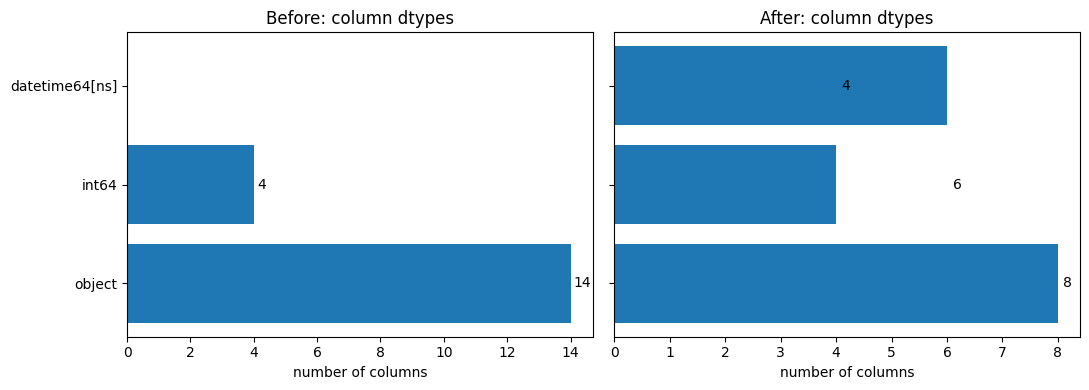

                   min        max
date        1950-05-13 2024-12-08
fp1_date    2021-03-26 2024-12-06
fp2_date    2021-03-26 2024-12-06
fp3_date    2021-03-27 2024-12-07
quali_date  2021-03-27 2024-12-07
sprint_date 2021-07-17 2024-11-30


In [383]:
races_raw = races.copy()   # before: text dates

date_cols = ['date', 'fp1_date', 'fp2_date', 'fp3_date', 'quali_date', 'sprint_date']
for c in date_cols:
    races[c] = pd.to_datetime(races[c], format='%Y-%m-%d')

# before vs after: dtype and non-missing count must not change
cmp = pd.DataFrame({
    'dtype_before':  races_raw[date_cols].dtypes.astype(str),
    'dtype_after':   races[date_cols].dtypes.astype(str),
    'filled_before': races_raw[date_cols].notna().sum(),
    'filled_after':  races[date_cols].notna().sum(),
})
cmp['same_count'] = cmp.filled_before == cmp.filled_after
display(cmp)

# visual: dtype per column, before vs after
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, df, title in [(axes[0], races_raw, 'Before'), (axes[1], races, 'After')]:
    counts = df.dtypes.astype(str).value_counts()
    ax.barh(counts.index, counts.values)
    ax.set_title(f'{title}: column dtypes')
    ax.set_xlabel('number of columns')
    for i, v in enumerate(counts.values):
        ax.text(v + 0.1, i, str(v), va='center')
plt.tight_layout()
plt.show()

print(races[date_cols].agg(['min', 'max']).T)

In [384]:
# primary key: raceId
print('raceId nulls:      ', races.raceId.isna().sum())
print('raceId duplicates: ', races.raceId.duplicated().sum())

# natural key: (year, round)
print('(year, round) duplicates:', races.duplicated(['year', 'round']).sum())

print('date duplicates:', races.duplicated(['date']).sum())

# does each date fall in its season?
print('date.year != year:       ', (races.date.dt.year != races.year).sum())

# does (year, round) order match date order?
by_round = races.sort_values(['year', 'round'])
print('dates in (year, round) order are increasing:', by_round.date.is_monotonic_increasing)

# and does raceId order match date order?
by_id = races.sort_values('raceId')
print('dates in raceId order are increasing:       ', by_id.date.is_monotonic_increasing)

# rounds run 1..n in every season with no gaps
g = races.groupby('year')['round'].agg(['min', 'max', 'count'])
print('seasons where rounds are not 1..n:', ((g['min'] != 1) | (g['max'] != g['count'])).sum())

# foreign keys and links to other tables
res_raw = raw_before['results']
sprint_raw = raw_before['sprint_results']
seasons_raw = raw_before['seasons']
circuits_raw = raw_before['circuits']

print('circuitId nulls:                      ', races.circuitId.isna().sum())
print('circuitId not found in circuits:      ', (~races.circuitId.isin(circuits_raw.circuitId)).sum())
print('races with no result rows:            ', (~races.raceId.isin(res_raw.raceId)).sum())
print('result rows with unknown raceId:      ', (~res_raw.raceId.isin(races.raceId)).sum())
print('season years differing (set() = none):', set(races.year) ^ set(seasons_raw.year))

sprint_ids = set(races.loc[races.sprint_date.notna(), 'raceId'])
print('races in sprint_results:              ', sprint_raw.raceId.nunique())
print('matches the sprint weekends:          ', set(sprint_raw.raceId) == sprint_ids)

raceId nulls:       0
raceId duplicates:  0
(year, round) duplicates: 0
date duplicates: 0
date.year != year:        0
dates in (year, round) order are increasing: True
dates in raceId order are increasing:        False
seasons where rounds are not 1..n: 0
circuitId nulls:                       0
circuitId not found in circuits:       0
races with no result rows:             0
result rows with unknown raceId:       0
season years differing (set() = none): set()
races in sprint_results:               18
matches the sprint weekends:           True


## races: data types and keys

**Format check.** Every date column has one pattern (`YYYY-MM-DD`) and every time column has one pattern (`HH:MM:SS`). No stray formats, so nothing needs cleaning in the text itself.

**What was fixed.** Six columns were stored as text (`object`) and are now real dates (`datetime64[ns]`): `date`, `fp1_date`, `fp2_date`, `fp3_date`, `quali_date`, `sprint_date`. The IDs (`raceId`, `year`, `round`, `circuitId`) were already `int64`. `name` and `url` are text, which is correct.

**Check.** Non-missing counts are identical before and after for all six columns, so the conversion lost nothing. The format was given explicitly, so a bad value would have raised an error and not turned silently into a missing value.

**Time columns left as text.** A time of day alone has no date. We combine them with the date into a timestamp only if a feature needs it.

**Date ranges after conversion.**
- `date`: 1950-05-13 to 2024-12-08, the full range of the dataset.
- All session dates start in 2021 and end in 2024. Nothing before 2021 has session dates.
- The first sprint date is 2021-07-17, in line with the sprint format being introduced in 2021.

**Primary key.** `raceId` has 0 nulls and 0 duplicates, so it is a valid primary key.

**Natural keys.** `(year, round)` is unique, and `date` is unique too (0 duplicates), so every race has its own date and either one gives a tie-free ordering. Rounds run 1 to n in every season with no gaps.

**Date vs season.** Every `date` falls in the season given by `year`, and sorting by `(year, round)` gives increasing dates, so the two orderings agree.

**Do not order by `raceId`.** In `raceId` order the dates do not increase (the first rows are 2009 races), so `raceId` is an identifier and not a timeline.

**How we use them.** We can use `date` for ordering races (it is unique and always increasing), and `year` and `round` for season structure (which season, which race of it). They both give the same order and are valid. Never use `raceId` for ordering.

**Foreign keys and links to other tables.** `circuitId` has 0 nulls and 0 orphans against `circuits`. Every race has result rows and every result row points to a known race, so the link in both directions is complete. Every season year in `races` exists in `seasons` and the other way round. The 18 races with a sprint date are exactly the races in `sprint_results`, so the sprint table lines up with the schedule.

**Why this matters.** Real dates allow date arithmetic (days since a driver's last race, month of the race), and the ordering rule above is what keeps rolling features from looking at the future.

**Next.** Why the session and time columns are missing, and what each gap means.

In [385]:
mask = races.isna()

coverage = pd.DataFrame({
    'n_missing': mask.sum(),
    'pct_missing': (mask.mean() * 100).round(1),
    'first_year_with_value': {c: races.loc[~mask[c], 'year'].min() for c in races.columns},
    'last_year_missing': {c: races.loc[mask[c], 'year'].max() for c in races.columns},
})
coverage

,n_missing,pct_missing,first_year_with_value,last_year_missing
raceId,0,0.0,1950,NaN
year,0,0.0,1950,NaN
round,0,0.0,1950,NaN
circuitId,0,0.0,1950,NaN
name,0,0.0,1950,NaN
date,0,0.0,1950,NaN
time,731,65.0,2005,2004.0
url,0,0.0,1950,NaN
fp1_date,1035,92.0,2021,2020.0
fp1_time,1057,94.0,2022,2021.0


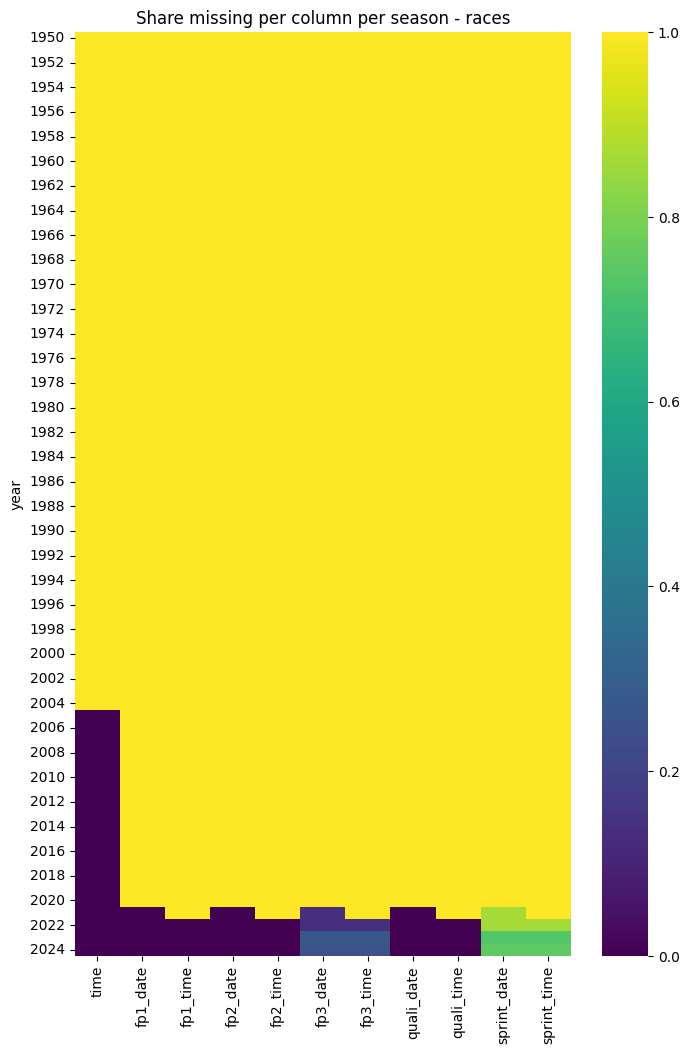

In [386]:
gap_cols = [c for c in races.columns if mask[c].any()]
share = mask[gap_cols].groupby(races.year).mean()
plt.figure(figsize=(8, 12))
sns.heatmap(share, cmap='viridis')
plt.title('Share missing per column per season - races')
plt.show()

In [387]:
# why 2021 has dates but no times
pairs = [('fp1_date', 'fp1_time'), ('quali_date', 'quali_time'),
         ('fp3_date', 'fp3_time'), ('sprint_date', 'sprint_time')]

for d, t in pairs:
    m = races[d].notna() & races[t].isna()
    print(d, '| date filled, time missing:', m.sum(), '| years:', sorted(races.loc[m, 'year'].unique()))

fp1_date | date filled, time missing: 22 | years: [np.int64(2021)]
quali_date | date filled, time missing: 22 | years: [np.int64(2021)]
fp3_date | date filled, time missing: 19 | years: [np.int64(2021)]
sprint_date | date filled, time missing: 3 | years: [np.int64(2021)]


In [388]:
# why fp3_* is still partly empty after 2021
recent = races[races.year >= 2021]
print(pd.crosstab(recent.fp3_date.isna().rename('fp3_missing'),
                  recent.sprint_date.notna().rename('has_sprint')))

has_sprint   False  True 
fp3_missing              
False           72      0
True             0     18


In [389]:
q = races[races.quali_date.notna()].copy()
q['gap'] = (q.date - q.quali_date).dt.days
q['sprint'] = q.sprint_date.notna()

print(q.gap.value_counts().sort_index())
print(pd.crosstab(q.gap, q.sprint, rownames=['days quali -> race'], colnames=['sprint weekend']))

# the exceptions: sprint with 1-day gap, or normal weekend with 2-day gap
display(q[(q.sprint & (q.gap == 1)) | (~q.sprint & (q.gap == 2))]
        [['year', 'round', 'name', 'quali_date', 'sprint_date', 'date', 'gap']])

display(races.loc[(races.year == 2023) & races.name.str.contains('Las Vegas'),
                  ['name', 'quali_date', 'quali_time', 'date', 'time']])

gap
1    77
2    13
Name: count, dtype: int64
sprint weekend      False  True 
days quali -> race              
1                      71      6
2                       1     12


,year,round,name,quali_date,sprint_date,date,gap
1099,2023,21,Las Vegas Grand Prix,2023-11-17,NaT,2023-11-19,2
1105,2024,5,Chinese Grand Prix,2024-04-20,2024-04-20,2024-04-21,1
1106,2024,6,Miami Grand Prix,2024-05-04,2024-05-04,2024-05-05,1
1111,2024,11,Austrian Grand Prix,2024-06-29,2024-06-29,2024-06-30,1
1119,2024,19,United States Grand Prix,2024-10-19,2024-10-19,2024-10-20,1
1121,2024,21,São Paulo Grand Prix,2024-11-02,2024-11-02,2024-11-03,1
1123,2024,23,Qatar Grand Prix,2024-11-30,2024-11-30,2024-12-01,1


,name,quali_date,quali_time,date,time
1099,Las Vegas Grand Prix,2023-11-17,08:00:00,2023-11-19,06:00:00


## races: missing values

**Complete columns.** `raceId`, `year`, `round`, `circuitId`, `name`, `date`, `url` have no missing values.

**Missingness follows eras, not chance.**
- `time` (race start time) is missing for 731 of 1,125 races (65%): empty up to 2004, recorded from 2005.
- Practice and qualifying dates are recorded from 2021 (1,035 missing, 92%). Their times are recorded from 2022 (1,057 missing, 94%), so 2021 has dates but no times.
- `fp3_*` and `sprint_*` stay partly empty after 2021: FP3 is missing on exactly the 18 sprint weekends and nowhere else, and sprint columns exist only on those 18 weekends.
- Every other column has a clean cut-off: its last missing season comes right before its first recorded season.

**Two meanings of missing.** *Not recorded* (sessions before 2021, race start times before 2005) is genuinely missing data. *Did not exist* (no FP3 on a sprint weekend, no sprint on a normal weekend) is a real answer and must not be imputed.

**What the columns hold.** The `fp*`, `quali_*` and `sprint_*` columns only record when each session was scheduled. Practice results are not in the dataset, and qualifying results are in the `qualifying` table. Where a qualifying date exists, it is always 1 or 2 days before the race, so using qualifying information at prediction time is allowed.

**Decision.** These columns only exist from 2021, so any training window that ends before 2021 sees them completely empty, and a model cannot learn from an empty column. They are not used as features. Columns that could be carried into the modelling table are `raceId`, `year`, `round`, `circuitId`, `name`, `date`. `time` and `url` are kept for reference only.

**One caveat.** In 2021-2022 the sprint result set the Sunday grid (per the F1 background document), so on those weekends `grid` differs from qualifying position for a reason other than penalties. This only matters if the training window reaches 2021.

count    75.000000
mean     15.000000
std       4.197812
min       7.000000
25%      11.000000
50%      16.000000
75%      17.000000
max      24.000000
dtype: float64

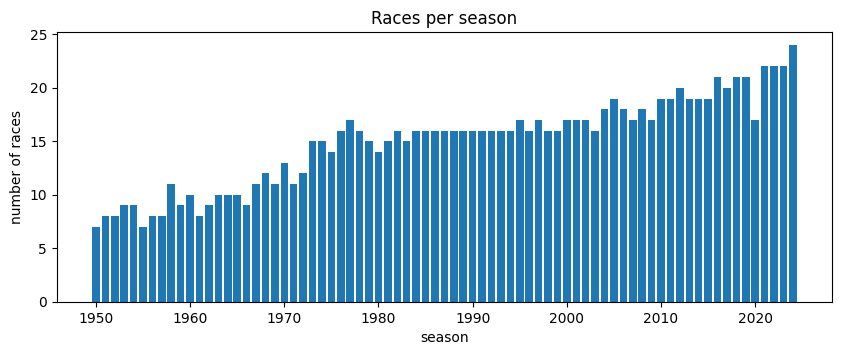

In [390]:
per_season = races.groupby('year').size()
display(per_season.describe())

plt.figure(figsize=(10, 3.5))
plt.bar(per_season.index, per_season.values)
plt.xlabel('season')
plt.ylabel('number of races')
plt.title('Races per season')
plt.show()

In [391]:
per_season = races.groupby('year').size()
by_decade = per_season.groupby(per_season.index // 10 * 10).agg(['min', 'max', 'mean'])
print(by_decade.round(1))
print('fewest races in a season:', per_season.idxmin(), per_season.min())
print('most races in a season:  ', per_season.idxmax(), per_season.max())


      min  max  mean
year                
1950    7   11   8.4
1960    8   12  10.0
1970   11   17  14.4
1980   14   16  15.6
1990   16   17  16.2
2000   16   19  17.4
2010   19   21  19.8
2020   17   24  21.4
fewest races in a season: 1950 7
most races in a season:   2024 24


## races: the calendar over the eras

**Races per season.** The calendar grew steadily. The average was 8.4 races per season in the 1950s, 14 to 16 in the 1970s and 1980s, 17 in the 2000s, 20 in the 2010s and 21 in the 2020s. The shortest season has 7 races (1950) and the longest has 24 (2024).

**Consequence for features.** Season totals are not comparable across eras, so we convert them to rates, such as points per race or share of the points available. Rolling features over the last N races are not affected.


### Indianapolis 500: what the data shows

In [392]:
indy = races[races.name.str.contains('Indianapolis', case=False)]
display(indy[['raceId', 'year', 'round', 'circuitId', 'name']])

print('races at the Indianapolis circuit:', (races.circuitId == indy.circuitId.mode()[0]).sum())
print('of those, named Indianapolis 500:  ', len(indy))


,raceId,year,round,circuitId,name
747,748,1960,3,19,Indianapolis 500
756,757,1959,2,19,Indianapolis 500
767,768,1958,4,19,Indianapolis 500
777,778,1957,3,19,Indianapolis 500
785,786,1956,3,19,Indianapolis 500
793,794,1955,3,19,Indianapolis 500
799,800,1954,2,19,Indianapolis 500
808,809,1953,2,19,Indianapolis 500
817,818,1952,2,19,Indianapolis 500
825,826,1951,2,19,Indianapolis 500


races at the Indianapolis circuit: 19
of those, named Indianapolis 500:   11


In [393]:
indy_ids = indy.raceId
print('races on circuitId 19:', (races.circuitId == 19).sum(), '| named Indianapolis 500:', len(indy))
print(races.loc[races.circuitId == 19, ['year', 'name']].query('name != "Indianapolis 500"'))

r = results_unique[results_unique.raceId.isin(indy_ids)].merge(races[['raceId', 'year']], on='raceId')

# how many drivers raced there, and how many of them raced anywhere else in F1
indy_drivers = set(r.driverId)
other = results_unique[~results_unique.raceId.isin(indy_ids)]
only_indy = indy_drivers - set(other.driverId)
print('drivers in Indy 500:', len(indy_drivers), '| who never raced a non-Indy F1 race:', len(only_indy))

# share of Indy rows held by drivers who only ever raced there
print('share of Indy result rows from Indy-only drivers:', round(r.driverId.isin(only_indy).mean(), 2))

# field size per race and statuses, to compare with normal races of the same years
print(r.groupby('year').size().rename('Indy field size'))
print(r.merge(raw_before['status'], on='statusId').status.value_counts().head(8))


races on circuitId 19: 19 | named Indianapolis 500: 11
     year                      name
41   2007  United States Grand Prix
61   2006  United States Grand Prix
78   2005  United States Grand Prix
97   2004  United States Grand Prix
121  2003  United States Grand Prix
138  2002  United States Grand Prix
155  2001  United States Grand Prix
171  2000  United States Grand Prix
drivers in Indy 500: 107 | who never raced a non-Indy F1 race: 103
share of Indy result rows from Indy-only drivers: 0.95
year
1950    34
1951    34
1952    33
1953    37
1954    42
1955    35
1956    34
1957    33
1958    33
1959    33
1960    33
Name: Indy field size, dtype: int64
status
Finished        124
Accident         43
Engine           23
Magneto          14
Spun off         12
+4 Laps          11
Oil leak         11
Transmission     10
Name: count, dtype: int64


### Indianapolis 500: decision

**What it is.** Eleven races in the table are named "Indianapolis 500", one per season from 1950 to 1960. The race counted for the world championship in those years but was run to different rules from the rest of the calendar.

**How to identify it.** We identify it by race name and not by circuit. The same circuit (`circuitId` 19) also hosted 8 races named "United States Grand Prix" between 2000 and 2007, which are normal Formula 1 races and must stay in.

**How it differs.** 107 drivers started the Indianapolis 500, and 103 of them never started any other Formula 1 race, so 95% of its result rows belong to drivers who appear nowhere else. The field was 33 to 42 cars, which is a different grid structure from the other races of the time.

**Effect on the questions.** It would distort the home-country question, because American drivers racing at Indianapolis would count as home races. For the circuit question it would add a circuit with 11 races in the old era only. The 2014 to 2024 mechanical-retirement question does not touch it.

**Decision.** We keep the 11 rows in the cleaned table and flag them, and we exclude them from the modelling table and from the home-country question. Every answer states whether it kept or excluded them.


In [394]:
indy_500_ids = races.loc[races.name == 'Indianapolis 500', 'raceId']
results_unique['is_indy500'] = results_unique.raceId.isin(indy_500_ids)
print(results_unique.is_indy500.sum(), 'result rows flagged')

381 result rows flagged


**Why we exclude them from the modelling table.** The Indianapolis 500 races follow different rules from the rest of the championship, and the data shows it. 103 of the 107 drivers who started them never started any other Formula 1 race, so 95% of their result rows come from drivers with no history anywhere else, and the history features we plan to build would be empty or meaningless for them. The fields were also much larger, 33 to 42 cars, so a grid position does not mean the same thing as in a normal race. All 11 races are from 1950 to 1960, which is far from the races we want to predict.

**Effect on the modelling table.** Excluding them removes 381 rows, about 1.4% of the 26,668 rows, and 11 of the 1,125 races. The 8 United States Grand Prix races held at the same circuit between 2000 and 2007 stay in, because we filter by race name and not by circuit. The rows are flagged with `is_indy500` in the cleaned table and removed only when the modelling table is built, after the history features, so no other driver's features are affected.


## `Circuits Table`

In [395]:
circuits = load('circuits')

print('shape:', circuits.shape)

shape: (77, 9)


In [396]:
display(circuits.head())

,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


In [397]:
print(circuits.dtypes)

circuitId       int64
circuitRef     object
name           object
location       object
country        object
lat           float64
lng           float64
alt             int64
url            object
dtype: object


In [398]:
print('\nmissing per column:')
print(circuits.isna().sum())


missing per column:
circuitId     0
circuitRef    0
name          0
location      0
country       0
lat           0
lng           0
alt           0
url           0
dtype: int64


In [399]:
# primary key
print('circuitId nulls:     ', circuits.circuitId.isna().sum())
print('circuitId duplicates:', circuits.circuitId.duplicated().sum())

# other columns that should also be unique
print('circuitRef duplicates:', circuits.circuitRef.duplicated().sum())
print('name duplicates:      ', circuits.name.duplicated().sum())

# value ranges
print(circuits[['lat', 'lng', 'alt']].describe())
print('lat outside -90..90:  ', (~circuits.lat.between(-90, 90)).sum())
print('lng outside -180..180:', (~circuits.lng.between(-180, 180)).sum())
print('alt <= 0:             ', (circuits.alt <= 0).sum())

# countries
print(circuits.country.value_counts())

# does every circuit get used?
print('circuits with no race:', (~circuits.circuitId.isin(races.circuitId)).sum())

circuitId nulls:      0
circuitId duplicates: 0
circuitRef duplicates: 0
name duplicates:       0
             lat         lng          alt
count  77.000000   77.000000    77.000000
mean   33.442925    1.076683   247.012987
std    22.808866   65.516951   362.738469
min   -37.849700 -118.189000    -7.000000
25%    32.777400   -9.394170    18.000000
50%    40.951700    3.930830   129.000000
75%    46.958900   19.248600   332.000000
max    57.265300  144.968000  2227.000000
lat outside -90..90:   0
lng outside -180..180: 0
alt <= 0:              3
country
USA              11
France            7
Spain             6
Italy             4
Portugal          4
UK                4
Germany           3
Belgium           3
Canada            3
Japan             3
Australia         2
Austria           2
Brazil            2
South Africa      2
Malaysia          1
Bahrain           1
Hungary           1
Turkey            1
Monaco            1
United States     1
China             1
Singapore         1
A

In [400]:
print(circuits.loc[circuits.alt <= 0, ['circuitRef', 'country', 'alt']])
print(circuits.loc[circuits.country == 'United States', ['circuitRef', 'name', 'location', 'country']])

   circuitRef     country  alt
34    yeongam       Korea    0
71       baku  Azerbaijan   -7
76      miami         USA    0
   circuitRef                            name   location        country
22      vegas  Las Vegas Strip Street Circuit  Las Vegas  United States


## circuits: keys and checks

**Grain.** One row is one physical track, 77 rows and 9 columns. `circuitId` is the identifier, `circuitRef` is a short text code, and `country` and `location` say where the track is.

**Types and missing values.** The IDs and `alt` are integers, the coordinates are floats and the rest is text, so nothing needed converting. No column has missing values, and loading with `\N` as missing found none to convert.

**Primary key.** `circuitId` has 0 nulls and 0 duplicates, so it is a valid primary key. `circuitRef` and `name` are also unique.

**Foreign keys.** The table has no foreign keys of its own, because other tables point to it. The link from `races.circuitId` was checked in the races section with 0 orphans, and all 77 circuits are used by at least one race.

**Ranges.** Latitude and longitude are inside their valid ranges. Altitude runs from -7 m to 2,227 m. Three circuits are at or below 0 m, which are Baku at -7 m, which is real since the track is below sea level, and Yeongam and Miami at 0 m, which are plausible for coastal tracks. Altitude is not used as a feature.

**Country spelling.** `country` writes the United States two ways, `USA` for 11 circuits and `United States` for the Las Vegas Strip Street Circuit. Short forms such as `UK`, `UAE` and `Korea` also won't match driver nationalities directly. We leave the raw values unchanged and handle this in the nationality-to-country mapping that the home-country question needs.

,circuitId,name,country,n_races,first,last
0,14,Autodromo Nazionale di Monza,Italy,74,1950,2024
1,6,Circuit de Monaco,Monaco,70,1950,2024
2,9,Silverstone Circuit,UK,59,1950,2024
3,13,Circuit de Spa-Francorchamps,Belgium,57,1950,2024
4,7,Circuit Gilles Villeneuve,Canada,43,1978,2024
5,18,Autódromo José Carlos Pace,Brazil,41,1973,2024
6,20,Nürburgring,Germany,41,1951,2020
7,11,Hungaroring,Hungary,39,1986,2024
8,70,Red Bull Ring,Austria,38,1970,2024
9,10,Hockenheimring,Germany,37,1970,2019


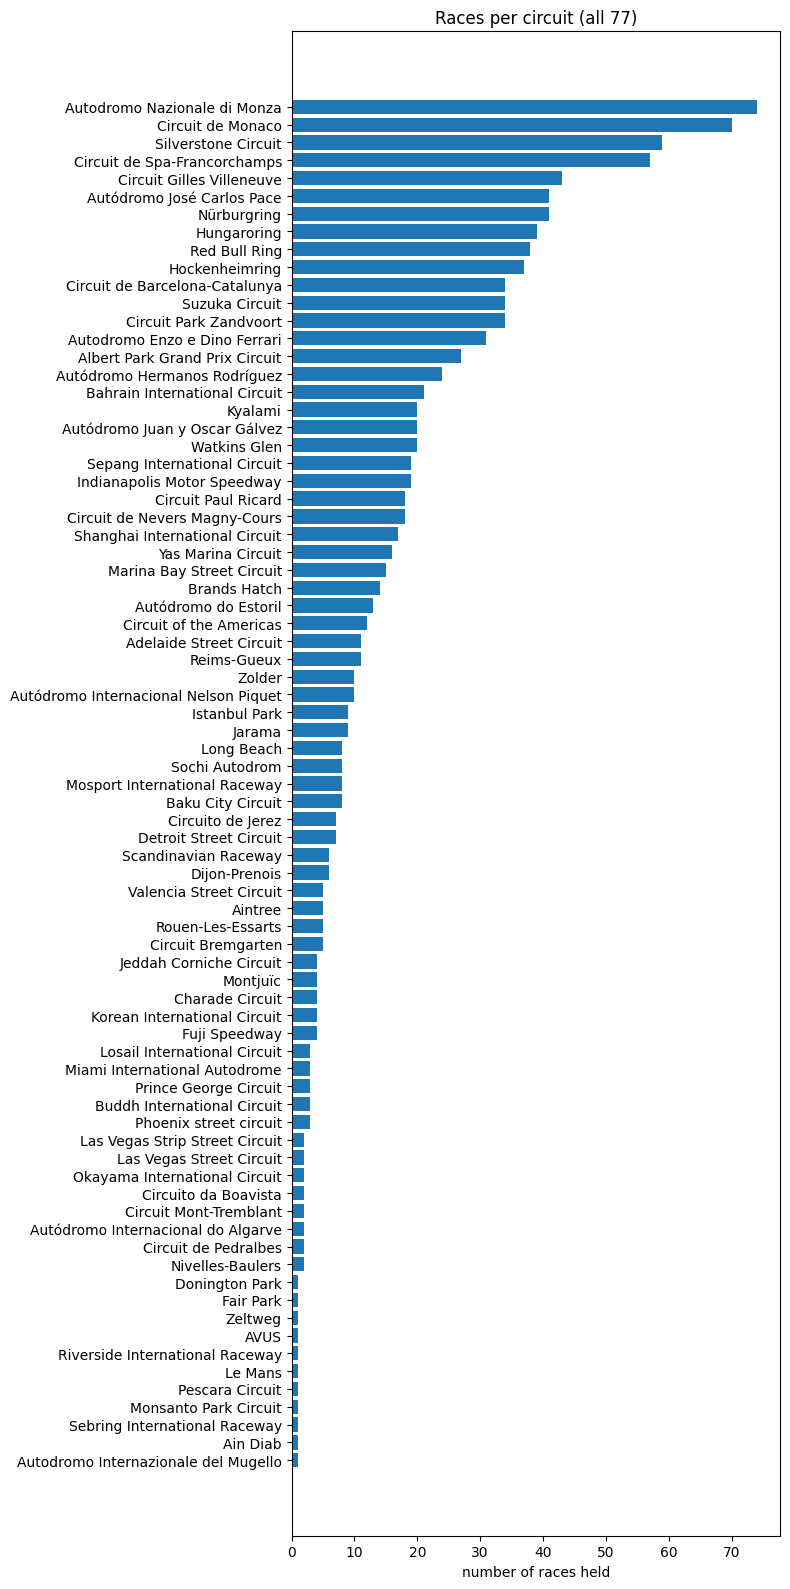

In [401]:
usage = (races.groupby('circuitId')
         .agg(n_races=('raceId', 'size'), first=('year', 'min'), last=('year', 'max')))
cu = (circuits.merge(usage, left_on='circuitId', right_index=True)
      .sort_values('n_races', ascending=False)
      [['circuitId', 'name', 'country', 'n_races', 'first', 'last']]
      .reset_index(drop=True))

pd.set_option('display.max_rows', None)
display(cu)

# picture: one bar per circuit
plt.figure(figsize=(8, 16))
plt.barh(cu.name[::-1], cu.n_races[::-1])
plt.xlabel('number of races held')
plt.title('Races per circuit (all 77)')
plt.tight_layout()
plt.show()

In [402]:
# trap 1: a circuit hosting two races in one season
per_year_circuit = races.groupby(['year', 'circuitId']).size().reset_index(name='n_races')
twice = per_year_circuit[per_year_circuit.n_races > 1].merge(circuits[['circuitId', 'name']], on='circuitId')
print('circuit-seasons with more than one race:', len(twice))
display(twice)

# trap 2: a circuit with more than one Grand Prix name
names = (races.groupby('circuitId').name
         .agg(n_names='nunique', gp_names=lambda s: sorted(s.unique())))
multi = names[names.n_names > 1].merge(circuits[['circuitId', 'name']], left_index=True, right_on='circuitId')
print('circuits with more than one GP name:', len(multi))
display(multi.sort_values('n_names', ascending=False)[['name', 'n_names', 'gp_names']])


circuit-seasons with more than one race: 4


,year,circuitId,n_races,name
0,2020,3,2,Bahrain International Circuit
1,2020,9,2,Silverstone Circuit
2,2020,70,2,Red Bull Ring
3,2021,70,2,Red Bull Ring


circuits with more than one GP name: 12


,name,n_names,gp_names
19,Nürburgring,4,"[Eifel Grand Prix, European Grand Prix, German..."
20,Autodromo Enzo e Dino Ferrari,3,"[Emilia Romagna Grand Prix, Italian Grand Prix..."
2,Bahrain International Circuit,2,"[Bahrain Grand Prix, Sakhir Grand Prix]"
8,Silverstone Circuit,2,"[70th Anniversary Grand Prix, British Grand Prix]"
18,Indianapolis Motor Speedway,2,"[Indianapolis 500, United States Grand Prix]"
17,Autódromo José Carlos Pace,2,"[Brazilian Grand Prix, São Paulo Grand Prix]"
25,Circuito de Jerez,2,"[European Grand Prix, Spanish Grand Prix]"
31,Autódromo Hermanos Rodríguez,2,"[Mexican Grand Prix, Mexico City Grand Prix]"
37,Brands Hatch,2,"[British Grand Prix, European Grand Prix]"
40,Dijon-Prenois,2,"[French Grand Prix, Swiss Grand Prix]"


## circuits: usage over time

**How often each circuit was used.** The 77 circuits are very uneven. Half of them hosted 8 races or fewer, a quarter hosted 3 or fewer, and 11 hosted exactly one race. At the other end, Monza hosted 74 races, Monaco 70, Silverstone 59, Spa 57 and Gilles Villeneuve 43, and all but the last of these have been used since 1950.

**Circuits still in use.** Only 24 of the 77 circuits were used in 2024, so about two thirds of the circuits no longer appear on the calendar. The set of tracks therefore changes a lot over the decades, and a circuit-level statistic is only meaningful for tracks with enough races in the period being studied.

**Two traps for later joins.** A circuit can host two races in the same season, which happened in 2020 and 2021, so a circuit and a year do not identify a race and `raceId` should be used instead. A circuit can also host Grands Prix under several names, for example the Nürburgring under four, so grouping by race name would split one track into several groups. We identify a track by `circuitId`, never by race name.


## `Drivers Table`

In [403]:
drivers = load('drivers')
print('shape:', drivers.shape)

shape: (861, 9)


In [404]:
display(drivers.head())

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [405]:
print(drivers.dtypes)

driverId         int64
driverRef       object
number         float64
code            object
forename        object
surname         object
dob             object
nationality     object
url             object
dtype: object


In [406]:
print('\nmissing per column:')
print(drivers.isna().sum())


missing per column:
driverId         0
driverRef        0
number         802
code           757
forename         0
surname          0
dob              0
nationality      0
url              0
dtype: int64


In [407]:
# format of dob (digits replaced by 9)
print(drivers.dob.str.replace(r'\d', '9', regex=True).value_counts())

# code should always be 3 letters, number should be whole
print(drivers.code.dropna().str.len().value_counts())
print('non-whole numbers:', (drivers.number.dropna() % 1 != 0).sum())

# first and last season each driver raced
yrs = (results_unique.merge(races[['raceId', 'year']], on='raceId')
       .groupby('driverId').year.agg(first='min', last='max'))
d = drivers.merge(yrs, left_on='driverId', right_index=True, how='left')

print('drivers with no result rows:', d['first'].isna().sum())
print('\nwith a number:');    print(d.loc[d.number.notna(), ['first', 'last']].describe().loc[['min', 'max']])
print('\nwith a code:');      print(d.loc[d.code.notna(), ['first', 'last']].describe().loc[['min', 'max']])

dob
9999-99-99    861
Name: count, dtype: int64
code
3    104
Name: count, dtype: int64
non-whole numbers: 0
drivers with no result rows: 0

with a number:
      first    last
min  2000.0  2014.0
max  2024.0  2024.0

with a code:
      first    last
min  1959.0  1968.0
max  2024.0  2024.0


,drivers,with_number,with_code,number_missing_pct,code_missing_pct
debut_decade,,,,,
1950,332,0,1,100.0,99.7
1960,145,0,0,100.0,100.0
1970,135,0,0,100.0,100.0
1980,79,0,0,100.0,100.0
1990,66,0,12,100.0,81.8
2000,49,11,36,77.6,26.5
2010,41,34,41,17.1,0.0
2020,14,14,14,0.0,0.0


Drivers who debuted from 2014: 38 | with a number: 38 | with a code: 38

Debut before 1990 but with a code:
    driverRef code  debut_year
375   bianchi  BIA        1959


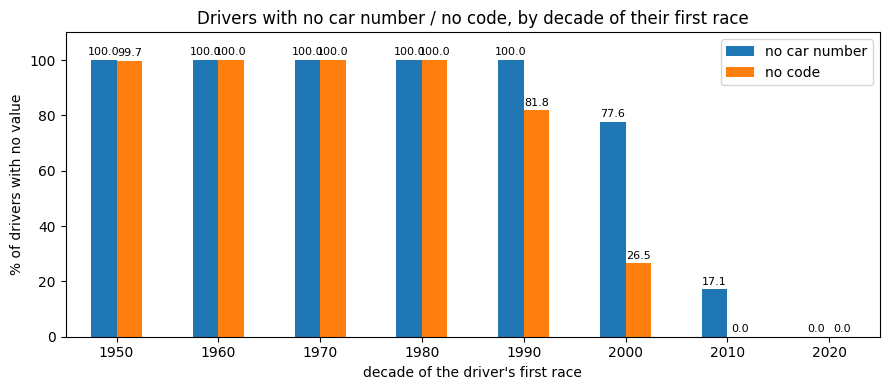

In [408]:
# first season of each driver, from the deduplicated results
debut = (results_unique.merge(races[['raceId', 'year']], on='raceId')
         .groupby('driverId').year.min())

d = drivers.assign(debut_year=drivers.driverId.map(debut))
d['debut_decade'] = d.debut_year // 10 * 10

# exact counts and percentages per decade of debut
by_decade = d.groupby('debut_decade').agg(
    drivers=('driverId', 'size'),
    with_number=('number', lambda s: int(s.notna().sum())),
    with_code=('code', lambda s: int(s.notna().sum())))
by_decade['number_missing_pct'] = ((1 - by_decade.with_number / by_decade.drivers) * 100).round(1)
by_decade['code_missing_pct'] = ((1 - by_decade.with_code / by_decade.drivers) * 100).round(1)
display(by_decade)

# drivers who debuted from 2014
recent = d[d.debut_year >= 2014]
print('Drivers who debuted from 2014:', len(recent),
      '| with a number:', int(recent.number.notna().sum()),
      '| with a code:', int(recent.code.notna().sum()))

# old drivers (debut before 1990) that do have a code
print('\nDebut before 1990 but with a code:')
print(d.loc[(d.debut_year < 1990) & d.code.notna(),
            ['driverRef', 'code', 'debut_year']].sort_values('debut_year'))

# bar chart: % of drivers with no number / no code, by decade of first race
ax = by_decade[['number_missing_pct', 'code_missing_pct']].plot.bar(
    figsize=(9, 4), rot=0,
    title="Drivers with no car number / no code, by decade of their first race")
ax.set_xlabel("decade of the driver's first race")
ax.set_ylabel('% of drivers with no value')
ax.set_ylim(0, 110)
ax.legend(['no car number', 'no code'])

# print the exact percent on each bar so rounding can't hide the exceptions
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=8, padding=2)

plt.tight_layout()
plt.show()


### drivers: structure and missing values

**Grain.** One row is one driver, 861 rows and 9 columns. `driverId` is the identifier, `driverRef` is a text code, `forename` and `surname` give the name, `dob` is the date of birth, and `nationality` is the country adjective such as British or German. Every driver appears in the results table, so there are no unused drivers.

**Format check.** `dob` has a single pattern (`YYYY-MM-DD`) in all 861 rows. Every `code` is exactly 3 letters, and every `number` is a whole number, so `number` is stored as a float only because it has missing values.

**Missing values.** Only two columns have gaps, and in both cases the gaps follow the era of the driver's first season and are not random.
- `number` is missing for 802 of 861 drivers, so only 59 have one. All 59 debuted in 2000 or later and were still racing in 2014 or later, so nobody who retired before 2014 has one.
- `code` is missing for 757 drivers, so 104 have one. Among drivers who debuted before 1990, only one has a code, Lucien Bianchi (debut 1959), so this is a single exception and not a pattern.
- All 38 drivers who debuted from 2014 have both a number and a code, so nothing is missing for the modern era.

**What missing means here.** A missing `number` or `code` means it did not exist for that driver in that era, and it does not mean the value was lost. The data shows the pattern. The likely reason, that permanent car numbers were introduced in 2014, is general Formula 1 knowledge that the data does not show.

**Decision.** `number` and `code` are labels and not performance information, so they are not used as features. We keep the missing cells as they are and do not fill them. `nationality` is complete, which matters for the home-country question.

**Next.** Convert `dob` to a real date, check the ages for impossible values, and then check the primary key and the links to other tables.

In [409]:
drivers_raw = drivers.copy()
drivers['dob'] = pd.to_datetime(drivers['dob'], format='%Y-%m-%d')

# before vs after
print('dob dtype before / after:', drivers_raw.dob.dtype, '/', drivers.dob.dtype)
print('dob filled before / after:', drivers_raw.dob.notna().sum(), '/', drivers.dob.notna().sum())
print('dob range:', drivers.dob.min().date(), 'to', drivers.dob.max().date())

# age in the first season each driver raced
yrs = (results_unique.merge(races[['raceId', 'year']], on='raceId')
       .groupby('driverId').year.agg(first='min', last='max'))
d = drivers.merge(yrs, left_on='driverId', right_index=True)
d['age_at_first_season'] = d['first'] - d.dob.dt.year
print(d.age_at_first_season.describe())

# the extremes, to look at by eye
cols = ['driverRef', 'dob', 'first', 'age_at_first_season']
print('\nyoungest at first season:'); print(d.nsmallest(5, 'age_at_first_season')[cols])
print('\noldest at first season:');   print(d.nlargest(5, 'age_at_first_season')[cols])

dob dtype before / after: object / datetime64[ns]
dob filled before / after: 861 / 861
dob range: 1896-12-28 to 2005-05-08
count    861.000000
mean      29.959350
std        6.647571
min       18.000000
25%       25.000000
50%       29.000000
75%       34.000000
max       54.000000
Name: age_at_first_season, dtype: float64

youngest at first season:
             driverRef        dob  first  age_at_first_season
451            monarch 1945-09-03   1963                   18
829     max_verstappen 1997-09-30   2015                   18
152        alguersuari 1990-03-23   2009                   19
190          thackwell 1961-03-30   1980                   19
454  ricardo_rodriguez 1942-02-14   1961                   19

oldest at first season:
     driverRef        dob  first  age_at_first_season
703      legat 1898-11-01   1952                   54
741  etancelin 1896-12-28   1950                   54
750     brudes 1899-10-15   1952                   53
760      dusio 1899-10-13   1952   

In [410]:
drivers.dtypes

driverId                int64
driverRef              object
number                float64
code                   object
forename               object
surname                object
dob            datetime64[ns]
nationality            object
url                    object
dtype: object

In [411]:
# primary key
print('driverId nulls:       ', drivers.driverId.isna().sum())
print('driverId duplicates:  ', drivers.driverId.duplicated().sum())

# other columns that look like identifiers
print('driverRef duplicates: ', drivers.driverRef.duplicated().sum())
print('code duplicates:      ', drivers.code.dropna().duplicated().sum())
print('number duplicates:    ', drivers.number.dropna().duplicated().sum())

# same person twice? (name + date of birth)
print('(forename, surname, dob) duplicates:', drivers.duplicated(['forename', 'surname', 'dob']).sum())

# links to other tables
res_raw = raw_before['results']
print('driverIds in results not found in drivers:', (~res_raw.driverId.isin(drivers.driverId)).sum())
print('drivers with no result rows:              ', (~drivers.driverId.isin(res_raw.driverId)).sum())
print('driverIds in qualifying not in drivers:   ', (~qualifying.driverId.isin(drivers.driverId)).sum())

driverId nulls:        0
driverId duplicates:   0
driverRef duplicates:  0
code duplicates:       7
number duplicates:     11
(forename, surname, dob) duplicates: 0
driverIds in results not found in drivers: 0
drivers with no result rows:               0
driverIds in qualifying not in drivers:    0


In [412]:
shared_code = drivers[drivers.code.notna() & drivers.code.duplicated(keep=False)].sort_values('code')
print(shared_code[['code', 'forename', 'surname', 'dob']])

shared_num = drivers[drivers.number.notna() & drivers.number.duplicated(keep=False)].sort_values('number')
print(shared_num[['number', 'forename', 'surname', 'dob']])


    code    forename     surname        dob
26   ALB  Christijan      Albers 1979-04-16
846  ALB   Alexander       Albon 1996-03-23
375  BIA      Lucien     Bianchi 1934-11-10
823  BIA       Jules     Bianchi 1989-08-03
37   DOO      Robert    Doornbos 1981-09-23
860  DOO        Jack      Doohan 2003-01-20
836  HAR         Rio    Haryanto 1993-01-22
841  HAR     Brendon     Hartley 1989-11-10
75   MAG         Jan   Magnussen 1973-07-04
824  MAG       Kevin   Magnussen 1992-10-05
29   MSC     Michael  Schumacher 1969-01-03
852  MSC        Mick  Schumacher 1999-03-22
817  VER   Jean-Éric      Vergne 1990-04-25
829  VER         Max  Verstappen 1997-09-30
     number  forename     surname        dob
837     2.0   Stoffel   Vandoorne 1992-03-26
856     2.0     Logan    Sargeant 2000-12-31
844     4.0     Lando      Norris 1999-11-13
819     4.0       Max     Chilton 1991-04-21
847     6.0  Nicholas      Latifi 1995-06-29
2       6.0      Nico     Rosberg 1985-06-27
827     9.0    Marcus    

## drivers: codes and numbers are not identifiers

**What we checked.** `driverId` is the only column that identifies a driver. We tested `code` and `number` to see whether they could do the same job, and neither can, because both are reused by different drivers.

**Shared codes.** 7 codes are used by two drivers each, so 14 drivers share a code. The code is built from the first letters of the surname, so drivers with the same or similar surnames collide. The pairs are Albers and Albon (ALB), Lucien and Jules Bianchi (BIA), Doornbos and Doohan (DOO), Haryanto and Hartley (HAR), Jan and Kevin Magnussen (MAG), Michael and Mick Schumacher (MSC), and Vergne and Verstappen (VER). These are different people, not duplicate rows.

**Shared numbers.** 11 numbers are used by two drivers each, so 22 drivers share a number. Examples are Kubica and Haryanto on 88, Button and Tsunoda on 22, and Rosberg and Latifi on 6. They look like the same number used by different drivers in different years, but we did not test whether any pair raced in the same season.

**Why it matters.** A join on `code` would merge Michael and Mick Schumacher into one driver, and a join on `number` would merge unrelated drivers. We use `driverId` for every join.

**No duplicate people.** `driverId` and `driverRef` have 0 duplicates, and no driver appears twice under the same forename, surname and date of birth.


In [413]:
# (a) how circuit countries are written
races_per_country = (races.merge(circuits[['circuitId', 'country']], on='circuitId')
                     .groupby('country').size().rename('races'))
country_table = (circuits.groupby('country').size().rename('circuits')
                 .to_frame().join(races_per_country))

abbreviations = [c for c in country_table.index if c.isupper() and len(c) <= 3]
print('Different country spellings:', len(country_table), '| abbreviations:', abbreviations)
display(country_table.loc[['USA', 'United States']])

usa_merged = circuits.country.replace({'United States': 'USA'})   # a copy, raw stays untouched
print("After merging 'United States' into 'USA':", usa_merged.nunique(), 'countries')

# (b) can circuit countries be matched to driver nationalities as written?
same_words = sorted(set(circuits.country) & set(drivers.nationality))
print('Circuit countries spelled exactly like a nationality:', len(same_words),
      'of', circuits.country.nunique(), '|', same_words)

# (c) the nationality column itself
print('Different nationality values:', drivers.nationality.nunique())
print('Values with stray spaces:',
      list(drivers.nationality[drivers.nationality != drivers.nationality.str.strip()].unique()))
print('Combined or historical values:',
      sorted(n for n in drivers.nationality.unique() if '-' in n or n in {'East German', 'Rhodesian'}))


Different country spellings: 35 | abbreviations: ['UAE', 'UK', 'USA']


,circuits,races
country,,
USA,11,77
United States,1,2


After merging 'United States' into 'USA': 34 countries
Circuit countries spelled exactly like a nationality: 0 of 35 | []
Different nationality values: 43
Values with stray spaces: ['Argentinian ']
Combined or historical values: ['American-Italian', 'Argentine-Italian', 'East German', 'Rhodesian']


## circuits and drivers: countries and nationalities

**What we checked.** The home-country question, and a possible home-race feature, need to match the country of a circuit with the nationality of a driver. We checked whether the two columns can be matched as they are written.

**Circuit countries.** `country` has 35 different spellings. The United States is written two ways, `USA` for 11 circuits (77 races) and `United States` for the Las Vegas circuit (2 races), and after merging them there are 34 countries. `UK`, `UAE` and `USA` are abbreviations, and `Korea` is a short form. We leave the raw values unchanged, and any merge is done on a copy.

**They cannot be matched directly.** Circuits store a country name such as `UK` or `Germany`, while drivers store an adjective such as `British` or `German`. None of the 35 circuit countries is spelled exactly like a driver nationality, so a direct join would find no home race at all.

**Nationality values.** `nationality` has 43 different values and no missing values. One value, `Argentinian`, has a trailing space and needs trimming before use. Four values do not map to one country, which are `American-Italian`, `Argentine-Italian`, `East German` and `Rhodesian`, because the driver has two nationalities or the country no longer exists.

**Decision.** We do not change the tables here. We will build one explicit nationality to country map and use it for both the home-country question and the `is_home` feature, so the two always define a home race in the same way. The map trims the stray space, merges `United States` into `USA`, and treats the four mixed or historical values as not home. The Indianapolis 500 rows are excluded from both, as described above.


## `Constructors Table`

In [414]:
constructors = load('constructors')

print('shape:', constructors.shape)
display(constructors.head())
print(constructors.dtypes)
print('\nmissing per column:')
print(constructors.isna().sum())

shape: (212, 5)


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


constructorId      int64
constructorRef    object
name              object
nationality       object
url               object
dtype: object

missing per column:
constructorId     0
constructorRef    0
name              0
nationality       0
url               0
dtype: int64


In [415]:
# primary key and other identifier-like columns
print('constructorId nulls:      ', constructors.constructorId.isna().sum())
print('constructorId duplicates: ', constructors.constructorId.duplicated().sum())
print('constructorRef duplicates:', constructors.constructorRef.duplicated().sum())
print('name duplicates:          ', constructors.name.duplicated().sum())

# nationality values
print('\ndifferent nationality values:', constructors.nationality.nunique())
print('values with stray spaces:', list(constructors.nationality[constructors.nationality != constructors.nationality.str.strip()].unique()))
print(constructors.nationality.value_counts())

# links to other tables
res_raw = raw_before['results']
print('\nconstructorIds in results not found in constructors:', (~res_raw.constructorId.isin(constructors.constructorId)).sum())
print('constructors with no result rows:                   ', (~constructors.constructorId.isin(res_raw.constructorId)).sum())
print('constructorIds in qualifying not in constructors:   ', (~qualifying.constructorId.isin(constructors.constructorId)).sum())


constructorId nulls:       0
constructorId duplicates:  0
constructorRef duplicates: 0
name duplicates:           0

different nationality values: 24
values with stray spaces: []
nationality
British          86
American         39
Italian          30
French           13
German           10
Japanese          5
Swiss             5
Dutch             3
South African     3
Russian           2
Malaysian         2
Canadian          2
Indian            1
Austrian          1
Hong Kong         1
Irish             1
Mexican           1
Brazilian         1
New Zealander     1
Australian        1
Rhodesian         1
Belgian           1
East German       1
Spanish           1
Name: count, dtype: int64

constructorIds in results not found in constructors: 0
constructors with no result rows:                    1
constructorIds in qualifying not in constructors:    0


## constructors: structure, keys and missing values

**Grain.** One row is one constructor, meaning a team entry. The table has 212 rows and 5 columns. `constructorId` is the identifier, `constructorRef` is a text code, `name` is the team name, `nationality` is the country adjective of the team, and `url` is the Wikipedia page.

**Types and missing values.** The ID is an integer and the other four columns are text, so nothing needed converting. No column has missing values, and loading with `\N` as missing found none to convert.

**Primary key.** `constructorId` has 0 nulls and 0 duplicates, so it is a valid primary key. `constructorRef` and `name` are also unique.

**Foreign keys.** The table has no foreign keys of its own. Every `constructorId` in `results` and in `qualifying` exists in `constructors`, so there are no orphans. One constructor has no result rows, which is a fact to note and not an error.

**Nationality.** `nationality` has 24 different values, no missing values and no stray spaces. `East German` and `Rhodesian` refer to countries that no longer exist, and `Hong Kong` is not a country in the circuits table, so these would need a rule if constructor nationality were ever matched to a circuit country. We do not plan to use it as a feature.

**Decision.** We keep `constructors` unchanged and use `constructorId` for every join, never `name` or `constructorRef`.

**Next.** Whether one `constructorId` is one continuous team, which matters for the mechanical-retirement question and for any team-form feature.


In [416]:
cars = (results_unique[['raceId', 'constructorId']]
        .merge(races[['raceId', 'year', 'name']].rename(columns={'name': 'race_name'}), on='raceId'))

# (a) activity per constructor
activity = cars.groupby('constructorId').agg(entries=('raceId', 'size'),
                                             first=('year', 'min'), last=('year', 'max'))
teams = constructors.merge(activity, left_on='constructorId', right_index=True, how='left')
print('constructors:', len(teams),
      '| with no result row:', int(teams.entries.isna().sum()), teams[teams.entries.isna()].name.tolist(),
      '| raced a single season only:', int((teams['first'] == teams['last']).sum()),
      '| with 100 or more entries:', int((teams.entries >= 100).sum()))


constructors: 212 | with no result row: 2 ['Eagle', 'Del Roy'] | raced a single season only: 69 | with 100 or more entries: 56


In [417]:
# (b) same Wikipedia page for several constructorIds
same_page = (constructors[constructors.url.duplicated(keep=False)]
             .groupby('url').agg(ids=('constructorId', 'size'),
                                 names=('name', lambda s: ', '.join(sorted(s)[:4]))))
print('constructors sharing a page with another:', int(constructors.url.duplicated(keep=False).sum()),
      'in', len(same_page), 'groups')
display(same_page.sort_values('ids', ascending=False).head(4))


constructors sharing a page with another: 50 in 13 groups


,ids,names
url,,
http://en.wikipedia.org/wiki/Cooper_Car_Company,11,"Cooper, Cooper-ATS, Cooper-Alfa Romeo, Cooper-BRM"
http://en.wikipedia.org/wiki/Team_Lotus,7,"Lotus-BRM, Lotus-Borgward, Lotus-Climax, Lotus..."
http://en.wikipedia.org/wiki/Brabham,6,"Brabham, Brabham-Alfa Romeo, Brabham-BRM, Brab..."
http://en.wikipedia.org/wiki/De_Tomaso,4,"De Tomaso, De Tomaso-Alfa Romeo, De Tomaso-Fer..."


In [418]:
# (c) one id covering separate periods
def longest_break(years):
    years = sorted(years)
    return max([b - a - 1 for a, b in zip(years, years[1:])], default=0)

teams['longest_break_seasons'] = teams.constructorId.map(
    cars.groupby('constructorId').year.apply(lambda s: longest_break(set(s))))
display(teams[(teams.longest_break_seasons >= 5) & (teams.entries >= 50)]
        .sort_values('entries', ascending=False)
        [['name', 'first', 'last', 'entries', 'longest_break_seasons']])

,name,first,last,entries,longest_break_seasons
31,Team Lotus,1958.0,1994.0,871.0,6.0
14,Sauber,1993.0,2024.0,837.0,5.0
3,Renault,1977.0,2020.0,787.0,16.0
33,Brabham,1962.0,1992.0,662.0,6.0
129,Mercedes,1954.0,2024.0,650.0,54.0
20,Arrows,1978.0,2002.0,590.0,6.0
49,Alfa Romeo,1950.0,2023.0,447.0,33.0
115,Aston Martin,1959.0,2024.0,191.0,60.0
25,Lola,1962.0,1997.0,165.0,9.0
52,ATS,1963.0,1984.0,162.0,14.0


In [419]:
# (d) constructors that only ever raced the Indianapolis 500
indy = cars.race_name == 'Indianapolis 500'
only_indy = set(cars[indy].constructorId) - set(cars[~indy].constructorId)
print('constructors that only raced the Indianapolis 500:', len(only_indy),
      '| their entries:', int(cars.constructorId.isin(only_indy).sum()))

constructors that only raced the Indianapolis 500: 30 | their entries: 166


## constructors: is one constructorId one continuous team

**Teams split over several ids.** 50 constructors share a Wikipedia page with another constructor, in 13 groups. The largest groups are Cooper with 11 ids, Team Lotus with 7, Brabham with 6 and De Tomaso with 4. The names, such as Cooper-ATS and Cooper-BRM, suggest that the same car maker was given a new id for each engine pairing, although the data only shows the shared page and not the reason. A team's history is therefore cut into several pieces, and this mostly affects the early decades.

**Ids covering separate periods.** Several large constructors have a long gap between two periods of racing under the same id. Mercedes raced in 1954 and 1955 and then again from 2010 to 2024, with a gap of 54 seasons in between. Aston Martin has a gap of 60 seasons, Honda 37, Alfa Romeo 33 and Renault 16. The data shows the gaps, and it is general Formula 1 knowledge, not something the table shows, that the later period is a different team under the same name.

**How active the constructors were.** Of the 212 constructors, 69 raced a single season only and 56 have 100 or more entries, so the table is made of a few long-lived teams and a long tail of short-lived ones. Team form is only meaningful for the long-lived teams.

**Consequence for features.** A rolling team-form feature that looks back over the last few races of one id would, for Mercedes' first race in 2010, reach back to 1955 and treat those results as recent form. Team form must therefore be limited to recent seasons or restarted after a long gap, and we also need to decide whether to link the ids that are split over several engine pairings.

**Constructors that only raced the Indianapolis 500.** 30 constructors raced only the Indianapolis 500, with 166 entries in total, so they disappear from the modelling table when those rows are excluded.

**Constructors with no results.** In the raw results table one constructor has no rows at all. After the duplicate rule there are two, Eagle and Del Roy. The second one had a single raw row, a 32nd place in race 809 (the 1953 Indianapolis 500), which the rule removed because the same driver has a better-placed row in that race. Removing rows can only leave more constructors empty, so the change from one to two is expected, and neither constructor affects the model.

**Decision.** We keep `constructors` unchanged and join on `constructorId`, never on `name`. The handling of long gaps and split ids is decided when the team-form feature is built.


## `Status Table`

In [420]:
status = load('status')

print('shape:', status.shape)
display(status.head(10))
print(status.dtypes)
print('\nmissing per column:')
print(status.isna().sum())

shape: (139, 2)


,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine
5,6,Gearbox
6,7,Transmission
7,8,Clutch
8,9,Hydraulics
9,10,Electrical


statusId     int64
status      object
dtype: object

missing per column:
statusId    0
status      0
dtype: int64


In [421]:
# primary key and label uniqueness
print('statusId nulls:       ', status.statusId.isna().sum())
print('statusId duplicates:  ', status.statusId.duplicated().sum())
print('status duplicates:    ', status.status.duplicated().sum())
print('labels with stray spaces:', list(status.status[status.status != status.status.str.strip()]))

# links to results
res_raw = raw_before['results']
print('statusIds in results not found in status:', (~res_raw.statusId.isin(status.statusId)).sum())
print('statuses never used in results:          ', (~status.statusId.isin(res_raw.statusId)).sum())


statusId nulls:        0
statusId duplicates:   0
status duplicates:     0
labels with stray spaces: []
statusIds in results not found in status: 0
statuses never used in results:           2


In [422]:
# how often each status is used (deduplicated results)
counts = (results_unique.merge(status, on='statusId')
          .groupby('status').size().sort_values(ascending=False)
          .rename('rows').to_frame())
counts['share_%'] = (counts.rows / counts.rows.sum() * 100).round(1)

pd.set_option('display.max_rows', None)
display(counts)

,rows,share_%
status,,
Finished,7674,28.8
+1 Lap,4036,15.1
Engine,2006,7.5
+2 Laps,1611,6.0
Accident,1053,3.9
Did not qualify,1024,3.8
Collision,854,3.2
Gearbox,804,3.0
Spun off,790,3.0


## status: structure, keys and how often each label is used

**Grain.** One row is one way a driver's race can end, 139 rows and 2 columns. `statusId` is the identifier and `status` is the label, such as `Finished`, `Engine` or `Accident`. It is a lookup table, so nothing is missing and the types need no conversion.

**Primary key.** `statusId` has 0 nulls and 0 duplicates, so it is a valid primary key, and `status` is also unique with no stray spaces.

**Foreign keys.** The table has no foreign keys of its own. Every `statusId` in `results` exists in `status`, and 2 of the 139 statuses are never used.

**What the column mixes.** The labels describe several different things in one column. Some mean the driver finished (`Finished` and the `+N Laps` labels, which are classified but lapped), some are mechanical failures, some are crashes, and some are not retirements at all, such as `Did not qualify` and `Withdrew`. The usage is a long tail. A few labels cover most rows, `Finished` alone is 28.8% and `+1 Lap` is 15.1%, while about 60 labels are used fewer than 10 times.

**Unclear labels.** `Retired`, `Not classified`, `Mechanical` and `Technical` do not say what kind of retirement it was, so they need an explicit rule before any mechanical-retirement rate is computed.

**Decision.** We keep `status` unchanged and group its labels into categories in a separate step, because the grouping is a modelling choice and not a cleaning fix.


lapped statuses: 33 | never used: ['+49 Laps', '+38 Laps'] | used 5 times or fewer: 54


,statuses,entries
group,,
finished,1,7674
"finished, laps down",33,7478
mechanical (clear),58,6217
accident or collision,5,2760
did not start,4,1610
grey zone,29,708
disqualified or excluded,3,156
driver health,6,65


period,2014-2021,2022-2024
mechanical (clear only),9.2,5.6
mechanical + grey zone,11.4,7.0
accident or collision,6.6,6.6


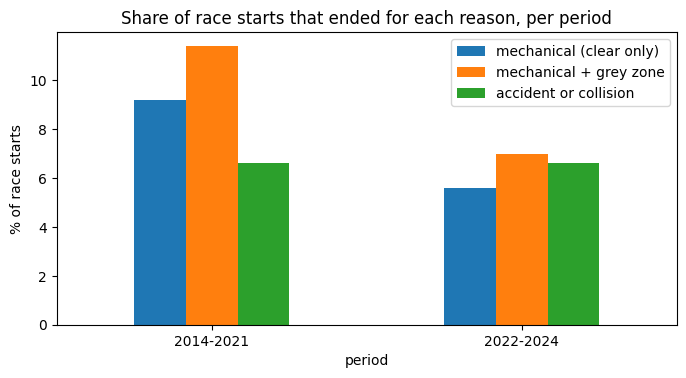

podium finishers with status finished or laps down: 99.8 %


In [423]:
res = results_unique.merge(races[['raceId', 'year']], on='raceId')

status['times_used'] = status.statusId.map(res.statusId.value_counts()).fillna(0).astype(int)
lapped = status.status.str.match(r'^\+\d+ Laps?$')
print('lapped statuses:', int(lapped.sum()),
      '| never used:', status[status.times_used == 0].status.tolist(),
      '| used 5 times or fewer:', int((status.times_used <= 5).sum()))

GROUPS = {
    'did not start': ['Did not qualify', 'Did not prequalify', '107% Rule', 'Withdrew'],
    'disqualified or excluded': ['Disqualified', 'Excluded', 'Underweight'],
    'accident or collision': ['Accident', 'Collision', 'Collision damage', 'Spun off', 'Fatal accident'],
    'driver health': ['Injury', 'Injured', 'Eye injury', 'Illness', 'Driver unwell', 'Physical'],
    'mechanical (clear)': ['Engine', 'Gearbox', 'Suspension', 'Transmission', 'Electrical', 'Brakes', 'Clutch',
        'Fuel system', 'Turbo', 'Hydraulics', 'Overheating', 'Ignition', 'Oil leak', 'Throttle', 'Halfshaft',
        'Oil pressure', 'Fuel pump', 'Differential', 'Fuel leak', 'Steering', 'Radiator', 'Power Unit',
        'Wheel bearing', 'Injection', 'Fuel pressure', 'Water leak', 'Alternator', 'Exhaust', 'Chassis',
        'Mechanical', 'Magneto', 'Driveshaft', 'Axle', 'Battery', 'Power loss', 'Oil pump', 'Distributor',
        'Oil pipe', 'Electronics', 'Water pressure', 'Water pump', 'ERS', 'Supercharger', 'Technical',
        'Pneumatics', 'Fuel pipe', 'Spark plugs', 'Water pipe', 'Drivetrain', 'Track rod', 'Oil line',
        'Engine fire', 'Engine misfire', 'Crankshaft', 'CV joint', 'Cooling system', 'Launch control', 'Brake duct'],
    'grey zone': ['Retired', 'Not classified', 'Out of fuel', 'Wheel', 'Wheel nut', 'Wheel rim', 'Tyre', 'Puncture',
        'Tyre puncture', 'Handling', 'Heat shield fire', 'Fire', 'Vibrations', 'Broken wing', 'Rear wing',
        'Front wing', 'Undertray', 'Damage', 'Debris', 'Fuel', 'Fuel rig', 'Refuelling', 'Stalled', 'Seat',
        'Driver Seat', 'Safety belt', 'Safety', 'Safety concerns', 'Not restarted']}
group_of = {s: g for g, members in GROUPS.items() for s in members}

status['group'] = [('finished' if s == 'Finished' else 'finished, laps down' if lapped[i] else group_of.get(s))
                   for i, s in zip(status.index, status.status)]
assert status.group.notna().all(), 'some status is not placed in a group'
display(status.groupby('group').agg(statuses=('status', 'size'), entries=('times_used', 'sum'))
        .sort_values('entries', ascending=False))

# share of race starts per Q3 period (everyone who did not start is left out)
res['period'] = pd.cut(res.year, [2013, 2021, 2024], labels=['2014-2021', '2022-2024'])
starts = res.merge(status[['statusId', 'group']], on='statusId')
starts = starts[(starts.group != 'did not start') & starts.period.notna()]
share = (starts.groupby('period', observed=True).group.value_counts(normalize=True).unstack(0) * 100).round(1)
rates = pd.DataFrame({'mechanical (clear only)': share.loc['mechanical (clear)'],
                      'mechanical + grey zone': share.loc['mechanical (clear)'] + share.loc['grey zone'],
                      'accident or collision': share.loc['accident or collision']})
display(rates.T)

rates.plot.bar(figsize=(8, 3.8), rot=0, title='Share of race starts that ended for each reason, per period')
plt.xlabel('period')
plt.ylabel('% of race starts')
plt.show()

# leakage check: how much of the podium does status give away?
podium = res[res.positionOrder <= 3]
podium_group = podium.statusId.map(status.set_index('statusId').group)
print('podium finishers with status finished or laps down:',
      round(podium_group.isin(['finished', 'finished, laps down']).mean() * 100, 1), '%')


## status: grouping the labels for the mechanical-retirement question

**Why a grouping is needed.** The `status` column mixes finishes, mechanical failures, crashes, driver problems and rule decisions in one list of 139 labels. The brief defines a mechanical retirement as a start that ended early because a component of the car failed, and it excludes crashes, driver causes and regulation decisions, so the labels have to be grouped before a rate can be computed.

**The draft grouping.** Every label is placed in exactly one of eight groups, and the code stops if one is missed. The groups are finished (1 label), finished but laps down (33 labels, the `+N Laps` family), clear mechanical failure (58), accident or collision (5), did not start (4), disqualified or excluded (3), driver health (6) and a grey zone (29). The grey zone holds labels that could be a failure or something else, such as `Retired`, `Not classified`, `Out of fuel`, the tyre and wheel labels and the wing labels. Two labels, `+49 Laps` and `+38 Laps`, are never used.

**How much the grey zone matters.** Counting race starts, and leaving out everyone who did not start, clear mechanical failures end 9.2% of starts in 2014 to 2021 and 5.6% in 2022 to 2024. Adding the whole grey zone gives 11.4% and 7.0%. The fall between the two periods is the same either way, so the choices about individual grey labels do not change the comparison. Accidents and collisions stay at 6.6% in both periods.

**Decision.** The grouping is a draft and not a cleaning fix, so `status` itself is unchanged. The question that uses it reports the clear-only rate and states the grey zone as a range.

**Not a feature.** The status of a race is only known after it ends, and 99.8% of podium finishers have a status of finished or finished laps down, so using it would give away the answer. It cannot be used as a model input.

## `Driver Standings Table`

In [424]:
driver_standings = load('driver_standings')

print('shape:', driver_standings.shape)
display(driver_standings.head())
print(driver_standings.dtypes)
print('\nmissing per column:')
print(driver_standings.isna().sum())

shape: (34863, 7)


,driverStandingsId,raceId,driverId,points,position,positionText,wins
0,1,18,1,10.0,1,1,1
1,2,18,2,8.0,2,2,0
2,3,18,3,6.0,3,3,0
3,4,18,4,5.0,4,4,0
4,5,18,5,4.0,5,5,0


driverStandingsId      int64
raceId                 int64
driverId               int64
points               float64
position               int64
positionText          object
wins                   int64
dtype: object

missing per column:
driverStandingsId    0
raceId               0
driverId             0
points               0
position             0
positionText         0
wins                 0
dtype: int64


In [425]:
ds_raw = driver_standings.copy()

# keys
print('driverStandingsId nulls:     ', ds_raw.driverStandingsId.isna().sum())
print('driverStandingsId duplicates:', ds_raw.driverStandingsId.duplicated().sum())
print('(raceId, driverId) duplicates:', ds_raw.duplicated(['raceId', 'driverId']).sum())

# links to other tables
print('raceIds not in races:   ', (~ds_raw.raceId.isin(races.raceId)).sum())
print('driverIds not in drivers:', (~ds_raw.driverId.isin(drivers.driverId)).sum())
print('races without any standings:', (~races.raceId.isin(ds_raw.raceId)).sum(), 'of', len(races))


driverStandingsId nulls:      0
driverStandingsId duplicates: 0
(raceId, driverId) duplicates: 0
raceIds not in races:    0
driverIds not in drivers: 0
races without any standings: 0 of 1125


In [426]:
# the rows, in season order
ds = (ds_raw.merge(races[['raceId', 'year', 'round', 'name']], on='raceId')
      .sort_values(['year', 'driverId', 'round']))

# is it a running total? points and wins should never go down inside a season
ds['added'] = ds.groupby(['year', 'driverId']).points.diff().fillna(ds.points)
ds['wins_added'] = ds.groupby(['year', 'driverId']).wins.diff().fillna(ds.wins)
print('points ever go down in a season:', int((ds.added < 0).sum()),
      '| wins ever go down:', int((ds.wins_added < 0).sum()))

points ever go down in a season: 0 | wins ever go down: 0


## driver_standings: structure, keys and what a row means

**Grain.** The table has 34,863 rows and 7 columns. One row is a driver's championship standing right after one race. `points` and `wins` are running totals for that season, and `position` is the championship rank at that moment, not the finishing position in the race. Points restart at 0 every season, so a driver's season is grouped by year and driver.

**Types and missing values.** `driverStandingsId`, `raceId`, `driverId`, `position` and `wins` are integers, `points` is a float because half points exist in some old seasons, and `positionText` is text. No column has missing values, so nothing needed converting.

**Primary key.** `driverStandingsId` has 0 nulls and 0 duplicates, so it is a valid primary key. The natural key `(raceId, driverId)` also has 0 duplicates, so a driver has at most one standing per race.

**Foreign keys.** Every `raceId` exists in `races` and every `driverId` exists in `drivers`, so there are no orphans. Every one of the 1,125 races has standings.

**Running total check.** Inside a season, points never go down and wins never go down, which confirms that each row is a running total and not a per-race score.

**Leakage.** A row is the standing after the race, so it already contains that race's result. For a feature on a given race, we use the standing from the previous round of the same season, ordered by `(year, round)`. In round 1 there is no previous row, so the values start at 0 and are marked with a flag.

**Next.** Which race starters have no standings row, how the decimal points arise, and how points differ between seasons.


In [427]:
# starters (from deduplicated results) vs standings rows
st = (results_unique[['raceId', 'driverId', 'points']]
      .merge(races[['raceId', 'year']], on='raceId'))
has = ds[['raceId', 'driverId']].assign(has_row=1)
st = st.merge(has, on=['raceId', 'driverId'], how='left')
st['has_row'] = st.has_row.fillna(0).astype(bool)

# standings rows for a driver who has no result row in that race
rows_no_result = ds[['raceId', 'driverId']].merge(
    results_unique[['raceId', 'driverId']].assign(r=1), on=['raceId', 'driverId'], how='left')
print('standings rows with no result row in that race:', int(rows_no_result.r.isna().sum()))

# result rows with no standings row
no_row = st[~st.has_row]
print('result rows with no standings row:', len(no_row), 'of', len(st))
print('by decade (%):', ((1 - st.groupby(st.year // 10 * 10).has_row.mean()) * 100).round(1).to_dict())
print('rows that scored points but have no standings row:',
      int((~st.has_row & (st.points > 0)).sum()), 'of', int((st.points > 0).sum()))

# champion's final points per season (row of the last round, position 1)
last_round = ds.sort_values('round').groupby('year').raceId.last()
champion = ds[ds.raceId.isin(last_round) & (ds.position == 1)].set_index('year').points
print("champion's final points: 1950 =", champion[1950], '| 2009 =', champion[2009],
      '| 2010 =', champion[2010], '| 2023 =', champion[2023])


standings rows with no result row in that race: 8664
result rows with no standings row: 469 of 26668
by decade (%): {1950: 0.1, 1960: 0.1, 1970: 0.1, 1980: 0.2, 1990: 7.0, 2000: 4.1, 2010: 0.1, 2020: 0.0}
rows that scored points but have no standings row: 0 of 8165
champion's final points: 1950 = 30.0 | 2009 = 95.0 | 2010 = 256.0 | 2023 = 575.0


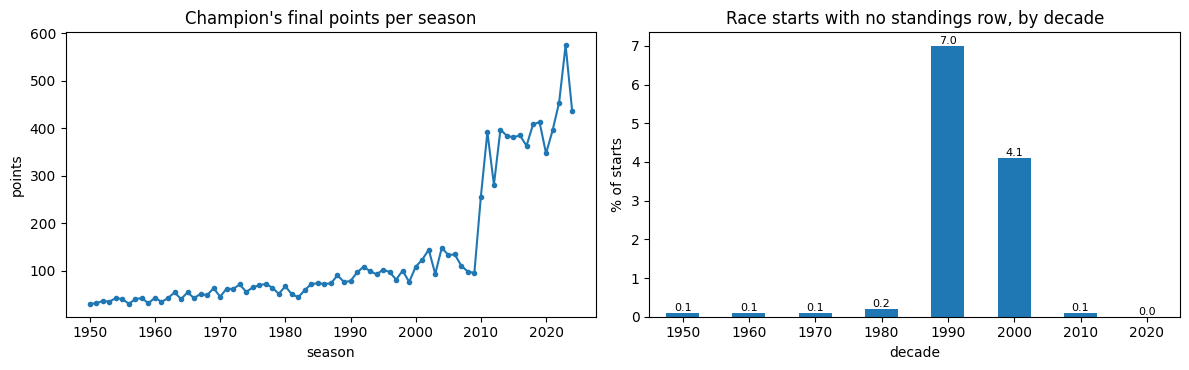

In [428]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

champion.plot(ax=axes[0], marker='o', markersize=3)
axes[0].set_title("Champion's final points per season")
axes[0].set_xlabel('season')
axes[0].set_ylabel('points')

miss = ((1 - st.groupby(st.year // 10 * 10).has_row.mean()) * 100).round(1)
miss.plot.bar(ax=axes[1], rot=0)
axes[1].set_title('Race starts with no standings row, by decade')
axes[1].set_xlabel('decade')
axes[1].set_ylabel('% of starts')
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.1f', fontsize=8)

plt.tight_layout()
plt.show()


## driver_standings: who has a standings row

**Standings rows for drivers who did not race.** 8,664 of the 34,863 rows belong to a driver with no result row in that race.

**Starts without a standings row.** 469 of the 26,668 result rows (1.8%) have no standings row. They are concentrated in the 1990s (7.0%) and 2000s (4.1%) and are below 0.3% in every other decade. None of them scored points, so the missing rows belong to drivers with zero points. For these starts the previous-round standing is missing and gets the same fallback as round 1.

**Points are not comparable between seasons.** The champion's final total is 30 in 1950, 95 in 2009, 256 in 2010 and 575 in 2023, because of scoring changes and a longer calendar. Standings points must be turned into rates, such as points per race or share of the points available, before they are used as features.

**Next.** We now check what these 8,664 standings rows are, meaning which drivers they belong to and why they have no result row in that race.


In [429]:
no_result = ds.merge(
    results_unique[['raceId', 'driverId']].assign(r=1),
    on=['raceId', 'driverId'], how='left')
no_result = no_result[no_result.r.isna()].copy()

# did this driver have a result row in an EARLIER round of the same season?
res_year = (results_unique[['raceId', 'driverId']]
            .merge(races[['raceId', 'year', 'round']], on='raceId'))
first_round = res_year.groupby(['year', 'driverId'])['round'].min().rename('first_round')
last_round_d = res_year.groupby(['year', 'driverId'])['round'].max().rename('last_round')

no_result = (no_result.merge(first_round, on=['year', 'driverId'], how='left')
                      .merge(last_round_d, on=['year', 'driverId'], how='left'))

print('total rows with no result row:                         ', len(no_result))
print('no result row, and the driver never raced that season: ', int(no_result.first_round.isna().sum()))
print('raced earlier in the season, absent this round:        ', int((no_result['round'] > no_result.first_round).sum()))
print('raced only later in the season:                        ', int((no_result['round'] < no_result.first_round).sum()))
print('absent after their last race of the season:            ', int((no_result['round'] > no_result.last_round).sum()))


total rows with no result row:                          8664
no result row, and the driver never raced that season:  0
raced earlier in the season, absent this round:         8664
raced only later in the season:                         0
absent after their last race of the season:             6959


**What the 8,664 rows are.** All 8,664 rows belong to drivers who had a result row in an earlier round of the same season, so no row belongs to a driver who never raced that season, and none appears before the driver's first race. Of these, 6,959 (80%) come after the driver's last race of the season, so a driver stays in the table until the season ends. The other 1,705 (20%) are rounds a driver missed and then raced again later in the season. The standings therefore list every driver who has raced so far in the season, and not only the starters of that round.

In [430]:
import numpy as np

sprint_raw = raw_before['sprint_results']

# points each driver scored per race weekend: Sunday race + Saturday sprint
scored = (results_unique[['raceId', 'driverId', 'positionOrder', 'points']]
          .rename(columns={'points': 'race_points'})
          .merge(races[['raceId', 'year', 'round']], on='raceId'))
scored = scored.merge(sprint_raw[['raceId', 'driverId', 'points']]
                      .rename(columns={'points': 'sprint_points'}),
                      on=['raceId', 'driverId'], how='left')
scored['sprint_points'] = scored.sprint_points.fillna(0)
scored['scored'] = scored.race_points + scored.sprint_points

# (a) is a row written AFTER its race?
m = ds.merge(scored[['raceId', 'driverId', 'race_points', 'sprint_points', 'scored', 'positionOrder']],
             on=['raceId', 'driverId'], how='left')
m[['race_points', 'sprint_points', 'scored']] = m[['race_points', 'sprint_points', 'scored']].fillna(0)
m['same_as_sunday'] = (m.added - m.race_points).abs() < 1e-6
m['same_as_weekend'] = (m.added - m.scored).abs() < 1e-6

print('standings rows:', len(m),
      '| points added = points scored that weekend:', int(m.same_as_weekend.sum()),
      f'({m.same_as_weekend.mean() * 100:.1f}%)')
print('drivers with no result row that add 0 points:',
      int((m.positionOrder.isna() & (m.added == 0)).sum()), 'of', int(m.positionOrder.isna().sum()))
print('agreement by decade (%):',
      (m.groupby(m.year // 10 * 10).same_as_weekend.mean() * 100).round(1).to_dict())

since_2021 = m[m.year >= 2021]
print('2021-2024: added = Sunday points only:', round(since_2021.same_as_sunday.mean() * 100, 1),
      '% | = Sunday + sprint:', round(since_2021.same_as_weekend.mean() * 100, 1), '%')
bad = m[~m.same_as_weekend]
print('rows that disagree: between', int(bad.year.min()), 'and', int(bad.year.max()), '| count:', len(bad))

# (b) the SAFE version: standings before the race = row of the previous round, same season
by_id = races.sort_values('raceId')
print('\nraceId order equals date order:',
      bool((by_id.raceId.values == races.sort_values('date').raceId.values).all()),
      '| raceIds whose date is earlier than the previous raceId:',
      int((by_id.date < by_id.date.shift(1)).sum()))

after = ds[['year', 'driverId', 'round', 'points']].rename(columns={'points': 'points_after'})
before = after.assign(round=after['round'] + 1).rename(columns={'points_after': 'points_before'})

x = scored.sort_values(['year', 'driverId', 'round']).copy()
x['scored_before'] = x.groupby(['year', 'driverId']).scored.cumsum() - x.scored
x = (x.merge(after, on=['year', 'driverId', 'round'], how='left')
      .merge(before, on=['year', 'driverId', 'round'], how='left'))
x[['points_after', 'points_before']] = x[['points_after', 'points_before']].fillna(0)

later = x[x['round'] > 1].copy()
print('race starts in round 1 (no standings before them):', int((x['round'] == 1).sum()), 'of', len(x))
print('after round 1: standings-before equals points scored in earlier races:',
      round(((later.points_before - later.scored_before).abs() < 1e-6).mean() * 100, 2), '%')


standings rows: 34863 | points added = points scored that weekend: 34778 (99.8%)
drivers with no result row that add 0 points: 8664 of 8664
agreement by decade (%): {1950: 99.3, 1960: 99.5, 1970: 99.8, 1980: 99.7, 1990: 100.0, 2000: 100.0, 2010: 100.0, 2020: 100.0}
2021-2024: added = Sunday points only: 93.2 % | = Sunday + sprint: 100.0 %
rows that disagree: between 1950 and 1990 | count: 85

raceId order equals date order: False | raceIds whose date is earlier than the previous raceId: 61
race starts in round 1 (no standings before them): 1721 of 26668
after round 1: standings-before equals points scored in earlier races: 99.7 %


## driver_standings: is a row written before or after its race

**A row is the standing after the race.** For 99.8% of the 34,863 rows, the points added since the driver's previous row equal what the driver scored that weekend, the Sunday race plus the Saturday sprint. The 85 rows that disagree are all between 1950 and 1990, and from 1990 on the agreement is 100%. Drivers with no result row in a round add 0 points in all 8,664 cases. From 2021 to 2024 the standings include sprint points, since Sunday plus sprint matches in 100% of rows while Sunday alone matches in 93.2%.

**Consequence.** Using the standing of the race being predicted would hand the model that race's result. This is a leak, and it applies to every race.

**The safe version.** The standing before a race is the driver's row from the previous round of the same season. We order by season and round, never by `raceId`, because `raceId` is not in date order (61 raceIds have a date earlier than the previous one). After round 1, the previous-round row equals the points the driver scored in earlier races in 99.7% of cases. Round 1 has no earlier row, which affects 1,721 of the 26,668 race starts, and these get 0 points with a flag.


,1950,1960,1970,1980,1990,2000,2010,2020
before the race,0.35,0.33,0.36,0.40,0.42,0.48,0.61,0.60
after the race (leak),0.55,0.53,0.49,0.51,0.51,0.57,0.67,0.66


average rank correlation over all races: {'before the race': 0.46, 'after the race (leak)': 0.57}
winner leads the standings AFTER the race in 48.4 % of races, but led them BEFORE the race in 32.8 % (round 2 onward)


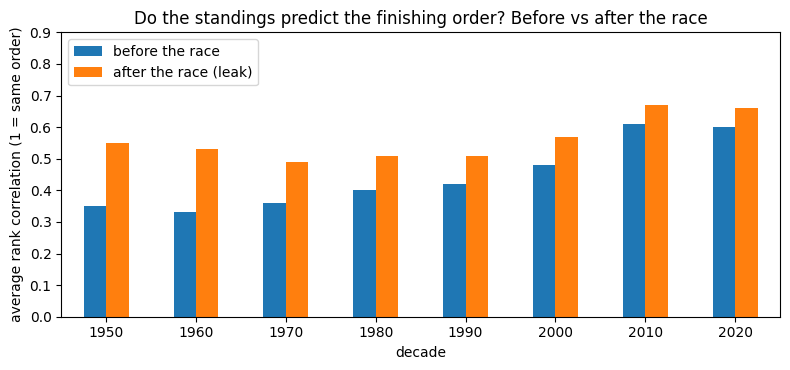

In [431]:
def rank_corr(a, b):
    return np.nan if a.nunique() < 2 or b.nunique() < 2 else a.corr(b)

# rank by points before the race, rank by points after the race, and the real finishing order
later['rank_before'] = later.groupby('raceId').points_before.rank(ascending=False)
later['rank_after'] = later.groupby('raceId').points_after.rank(ascending=False)
later['finish'] = later.groupby('raceId').positionOrder.rank()

leak = pd.DataFrame({
    'before the race': {r: rank_corr(g.rank_before, g['finish']) for r, g in later.groupby('raceId')},
    'after the race (leak)': {r: rank_corr(g.rank_after, g['finish']) for r, g in later.groupby('raceId')}
}).dropna()

year_of = races.set_index('raceId').year
by_decade = leak.groupby(leak.index.map(year_of) // 10 * 10).mean().round(2)
display(by_decade.T)
print('average rank correlation over all races:', leak.mean().round(2).to_dict())

# does the race winner lead the standings after the race, versus before it?
leader_after = ds[ds.position == 1].drop_duplicates('raceId').set_index('raceId').driverId
prev_race = (races.sort_values(['year', 'round'])
             .assign(prev=lambda t: t.groupby('year').raceId.shift(1))
             .set_index('raceId').prev)
winners = results_unique[results_unique.positionOrder == 1].groupby('raceId').driverId.agg(set)

after_ok = [leader_after[r] in winners[r] for r in winners.index if r in leader_after.index]
before_ok = [leader_after[prev_race[r]] in winners[r] for r in winners.index
             if pd.notna(prev_race[r]) and prev_race[r] in leader_after.index]
print('winner leads the standings AFTER the race in', round(np.mean(after_ok) * 100, 1),
      '% of races, but led them BEFORE the race in', round(np.mean(before_ok) * 100, 1), '% (round 2 onward)')

# figure
by_decade.plot.bar(figsize=(8, 3.8), rot=0,
                   title='Do the standings predict the finishing order? Before vs after the race')
plt.xlabel('decade')
plt.ylabel('average rank correlation (1 = same order)')
plt.ylim(0, 0.9)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


## driver_standings: how much the same-race standings would leak

**Rank correlation.** For each race we compared the ranking by championship points with the real finishing order. Averaged over all races, the correlation is 0.46 using the standings before the race and 0.57 using the standings after it. The gap is widest in the 1950s (0.35 against 0.55) and narrows to 0.06 in the 2010s (0.61 against 0.67) and in the 2020s (0.60 against 0.66).

**Winners and the standings.** The race winner leads the championship after the race in 48.4% of races, but was already leading it before the race in 32.8% of races from round 2 onward.

**Decision.** The same-race standing carries that race's result, so it is never used as a feature. The standing from the previous round of the same season is safe, and in the modern era it already tracks the finishing order closely (correlation about 0.6), so it is a useful feature.

In [432]:
season_total = scored.groupby(['year', 'driverId']).scored.sum()      # all points scored in the season
final_row = (ds.sort_values('round').groupby(['year', 'driverId']).tail(1)
             .set_index(['year', 'driverId']).points)                  # final standing points
gap = final_row - season_total.reindex(final_row.index).fillna(0)

lower = gap[gap < -1e-6]
higher = gap[gap > 1e-6]
print('driver-seasons whose final standing is LOWER than points scored:', len(lower),
      '| seasons', int(lower.index.get_level_values(0).min()), 'to', int(lower.index.get_level_values(0).max()))
print('driver-seasons whose final standing is HIGHER:', len(higher))

worst = gap.nsmallest(5).index
big = (pd.DataFrame({'points scored': season_total.reindex(worst),
                     'final standing': final_row.reindex(worst)})
       .reset_index().merge(drivers[['driverId', 'surname']], on='driverId'))
display(big[['surname', 'year', 'points scored', 'final standing']])
print('seasons with a LOWER gap:', sorted(lower.index.get_level_values(0).unique().tolist()))


driver-seasons whose final standing is LOWER than points scored: 50 | seasons 1950 to 1990
driver-seasons whose final standing is HIGHER: 3


,surname,year,points scored,final standing
0,Clark,1963,73.00,54.0
1,Prost,1988,105.00,87.0
2,Ascari,1952,53.50,36.0
3,Fangio,1954,57.14,42.0
4,Ascari,1953,45.50,34.5


seasons with a LOWER gap: [1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1979, 1980, 1985, 1986, 1987, 1988, 1989, 1990]


In [433]:
 print(gap[gap > 1e-6].rename('standing minus scored').reset_index()
      .merge(drivers[['driverId', 'surname']], on='driverId')
      [['surname', 'year', 'standing minus scored']])

       surname  year  standing minus scored
0       Farina  1955                   1.33
1       Fangio  1950                   1.00
2  Trintignant  1955                   1.33


In [434]:
res_raw = raw_before['results']

targets = [('Farina', 1955), ('Trintignant', 1955), ('Fangio', 1950)]
for surname, yr in targets:
    did = drivers.loc[drivers.surname == surname, 'driverId'].tolist()
    rid = races.loc[races.year == yr, ['raceId', 'round', 'name']]

    raw = (res_raw[res_raw.driverId.isin(did)]
           .merge(rid, on='raceId')
           .sort_values('round'))
    kept = set(results_unique.resultId)
    raw['kept_by_dedup'] = raw.resultId.isin(kept)

    print(f'\n{surname} {yr}')
    display(raw[['round', 'name', 'constructorId', 'positionOrder', 'points', 'kept_by_dedup']])
    print('points in raw rows:   ', raw.points.sum())
    print('points in kept rows:  ', raw.loc[raw.kept_by_dedup, 'points'].sum())



Farina 1955


,round,name,constructorId,positionOrder,points,kept_by_dedup
0,1,Argentine Grand Prix,6,3,1.33,False
4,1,Argentine Grand Prix,6,2,2.00,True
1,2,Monaco Grand Prix,6,4,3.00,True
2,4,Belgian Grand Prix,6,3,4.00,True
3,7,Italian Grand Prix,6,21,0.00,True


points in raw rows:    10.33
points in kept rows:   9.0

Trintignant 1955


,round,name,constructorId,positionOrder,points,kept_by_dedup
0,1,Argentine Grand Prix,6,11,0.00,False
7,1,Argentine Grand Prix,6,3,1.33,False
6,1,Argentine Grand Prix,6,2,2.00,True
1,2,Monaco Grand Prix,6,1,8.00,True
2,4,Belgian Grand Prix,6,6,0.00,True
3,5,Dutch Grand Prix,6,12,0.00,True
4,6,British Grand Prix,6,10,0.00,True
5,7,Italian Grand Prix,6,8,0.00,True


points in raw rows:    11.33
points in kept rows:   10.0

Fangio 1950


,round,name,constructorId,positionOrder,points,kept_by_dedup
0,1,British Grand Prix,51,12,0.0,True
1,2,Monaco Grand Prix,51,1,9.0,True
2,4,Swiss Grand Prix,51,12,0.0,True
3,5,Belgian Grand Prix,51,1,8.0,True
4,6,French Grand Prix,51,1,9.0,True
5,7,Italian Grand Prix,51,15,1.0,False
6,7,Italian Grand Prix,51,13,0.0,True


points in raw rows:    27.0
points in kept rows:   26.0


**Final standings can be lower than the points scored.** For 50 driver-seasons, all between 1950 and 1990, the final standing is lower than the sum of the points the driver scored. The biggest gaps are Clark in 1963 (73 points scored, 54 in the standings), Prost in 1988 (105 and 87), and Ascari in 1952 (53.5 and 36). This fits seasons in which only a driver's best results counted toward the championship, which is general Formula 1 knowledge and not something the table shows. From 1991 on the two always agree. Three driver-seasons go the other way, with a final standing higher than the points scored, Farina and Trintignant in 1955 (1.33 points each) and Fangio in 1950 (1 point). In each case the standing counts points from a shared drive, a second row for the same driver and race, that our duplicate rule removed. The removed points match the gaps exactly, so the standings are correct and the difference comes from keeping only the row with the best finishing position.

**Points in the two tables.** `results.points` is what a driver scored in one race, and `driver_standings.points` is the running total for the season, so the standings points are the cumulative sum of the race points except in the seasons above. For this reason, features use the standings only through the previous round and never the same-race row.

**Decimal points.** `points` has decimals in some old seasons. The shared drives we checked (Farina and Trintignant in 1955, Fangio in 1950) show that a car shared between drivers split its points, which gives values such as 1.33. We may not use these seasons for modelling.


## `Constructor Standings Table`

In [435]:
constructor_standings = load('constructor_standings')

print('shape:', constructor_standings.shape)
display(constructor_standings.head())
print(constructor_standings.dtypes)
print('\nmissing per column:')
print(constructor_standings.isna().sum())

shape: (13391, 7)


,constructorStandingsId,raceId,constructorId,points,position,positionText,wins
0,1,18,1,14.0,1,1,1
1,2,18,2,8.0,3,3,0
2,3,18,3,9.0,2,2,0
3,4,18,4,5.0,4,4,0
4,5,18,5,2.0,5,5,0


constructorStandingsId      int64
raceId                      int64
constructorId               int64
points                    float64
position                    int64
positionText               object
wins                        int64
dtype: object

missing per column:
constructorStandingsId    0
raceId                    0
constructorId             0
points                    0
position                  0
positionText              0
wins                      0
dtype: int64


In [436]:
cs_raw = constructor_standings.copy()

# keys
print('constructorStandingsId nulls:      ', cs_raw.constructorStandingsId.isna().sum())
print('constructorStandingsId duplicates: ', cs_raw.constructorStandingsId.duplicated().sum())
print('(raceId, constructorId) duplicates:', cs_raw.duplicated(['raceId', 'constructorId']).sum())

# links to other tables
print('raceIds not in races:              ', (~cs_raw.raceId.isin(races.raceId)).sum())
print('constructorIds not in constructors:', (~cs_raw.constructorId.isin(constructors.constructorId)).sum())
print('races without any standings:       ', (~races.raceId.isin(cs_raw.raceId)).sum(), 'of', len(races))

# one row per race and constructor, in season order
cs = (cs_raw.merge(races[['raceId', 'year', 'round', 'name']], on='raceId')
      .sort_values(['year', 'constructorId', 'round']))

# which years have standings at all?
print('first season with standings:', cs.year.min(), '| last:', cs.year.max())
no_cs = races[~races.raceId.isin(cs_raw.raceId)]
print('seasons of the races without standings:', sorted(no_cs.year.unique().tolist()))

# is it a running total inside a season?
cs['added'] = cs.groupby(['year', 'constructorId']).points.diff().fillna(cs.points)
cs['wins_added'] = cs.groupby(['year', 'constructorId']).wins.diff().fillna(cs.wins)
print('points ever go down in a season:', int((cs.added < 0).sum()),
      '| wins ever go down:', int((cs.wins_added < 0).sum()))

constructorStandingsId nulls:       0
constructorStandingsId duplicates:  0
(raceId, constructorId) duplicates: 0
raceIds not in races:               0
constructorIds not in constructors: 0
races without any standings:        64 of 1125
first season with standings: 1958 | last: 2024
seasons of the races without standings: [1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957]
points ever go down in a season: 2 | wins ever go down: 0


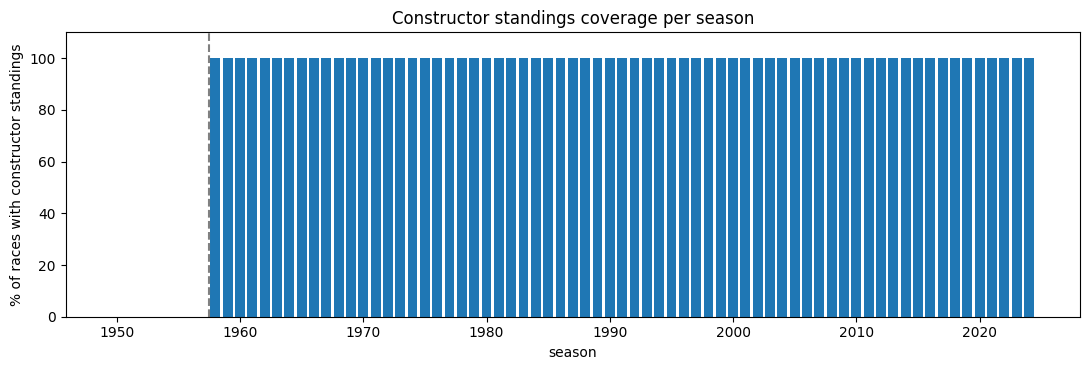

seasons with no standings: 1950 to 1957
seasons with partial coverage: []


In [437]:
cov = (races.assign(has_cs=races.raceId.isin(constructor_standings.raceId))
       .groupby('year').has_cs.mean() * 100)

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(cov.index, cov.values, color=['tab:red' if y < 1958 else 'tab:blue' for y in cov.index])
ax.axvline(1957.5, linestyle='--', color='gray')
ax.set_ylim(0, 110)
ax.set_xlabel('season')
ax.set_ylabel('% of races with constructor standings')
ax.set_title('Constructor standings coverage per season')
plt.tight_layout()
plt.show()

print('seasons with no standings:', cov[cov == 0].index.min(), 'to', cov[cov == 0].index.max())
print('seasons with partial coverage:', cov[(cov > 0) & (cov < 100)].index.tolist())


In [438]:
down = cs[cs.added < 0].merge(constructors[['constructorId', 'name']], on='constructorId', suffixes=('', '_constructor'))
print(down[['year', 'round', 'name_constructor', 'points', 'added']])

# the rows around them, to see what happened
for _, r in down.iterrows():
    print(cs[(cs.constructorId == r.constructorId) & (cs.year == r.year)]
          [['round', 'points', 'position', 'wins']].to_string(index=False))


   year  round name_constructor  points  added
0  2018     13      Force India    18.0  -41.0
1  2020      5     Racing Point    41.0   -1.0
 round  points  position  wins
     1     0.0         6     0
     2     1.0         9     0
     3     1.0         9     0
     4    16.0         6     0
     5    18.0         7     0
     6    26.0         6     0
     7    28.0         6     0
     8    28.0         6     0
     9    42.0         7     0
    10    49.0         6     0
    11    59.0         5     0
    12    59.0         6     0
    13    18.0         9     0
    14    32.0         7     0
    15    32.0         7     0
    16    35.0         7     0
    17    43.0         7     0
    18    47.0         7     0
    19    47.0         7     0
    20    48.0         7     0
    21    52.0         7     0
 round  points  position  wins
     1     8.0         4     0
     2    22.0         4     0
     3    40.0         4     0
     4    42.0         5     0
     5    41.0        

## constructor_standings: structure, keys and coverage

**Grain.** The table has 13,391 rows and 7 columns. One row is a constructor's championship standing right after one race. `points` and `wins` are running totals for the season, and `position` is the championship rank at that moment, not a finishing place. It has the same structure as `driver_standings`, with `constructorId` in place of `driverId`.

**Types and missing values.** The IDs, `position` and `wins` are integers, `points` is a float and `positionText` is text. No column has missing values, so nothing needed converting.

**Primary key.** `constructorStandingsId` has 0 nulls and 0 duplicates, so it is a valid primary key. The natural key `(raceId, constructorId)` also has 0 duplicates.

**Foreign keys.** Every `raceId` exists in `races` and every `constructorId` exists in `constructors`, so there are no orphans.

**Coverage.** Standings start in 1958. The 64 races without any constructor standings are exactly the seasons 1950 to 1957, and every race from 1958 on has standings. Features built from this table are therefore missing for those early seasons, which only matters if the training window starts before 1958.

**Running total.** Wins never go down inside a season. Points go down in two rows only. Force India in 2018 drops from 59 points after round 12 to 18 after round 13, and Racing Point in 2020 drops from 42 to 41 at round 5. After each drop the totals grow normally again, but from the lower number. The table shows the drops and not their cause. A possible explanation is a points deduction in that round, but this is an assumption, and we will investigate it by comparing the standings with what the team's cars scored in `results`. Features read the previous-round points directly and do not use differences between rounds, so these two rows cannot produce a negative value.

**Leakage.** As in `driver_standings`, a row is the standing after the race. For a feature on a given race we use the row from the previous round of the same season, ordered by `(year, round)`, and never the same-race row.

**Next.** Investigate the two points drops, and check that constructor points match the sum of both cars' race points.


In [439]:
cr = raw_before['constructor_results'][['raceId', 'constructorId', 'points']].rename(columns={'points': 'race_points'})

# (b) is a row written AFTER its race? points added vs the team's points in constructor_results
m = cs.merge(cr, on=['raceId', 'constructorId'], how='left')
raced = m[m.race_points.notna()]
same = (raced.added - raced.race_points).abs() < 1e-6
print('rows of teams with a result in that race:', len(raced),
      '| points added = the team points of that race:', int(same.sum()), f'({same.mean() * 100:.1f}%)')
print('rows that disagree:', int((~same).sum()),
      '| before 1980:', int((raced[~same].year < 1980).sum()),
      '| other seasons:', sorted(raced[~same & (raced.year >= 1980)].year.unique().tolist()))

# the two points drops, next to what the team scored that race
drops = cs[cs.added < 0].merge(constructors[['constructorId', 'name']], on='constructorId', suffixes=('', '_team'))
display(drops.merge(cr, on=['raceId', 'constructorId'], how='left')
        [['year', 'round', 'name_team', 'points', 'added', 'race_points']])

# (d) the safe version: standing before the race = previous round's row
x = (cr.merge(races[['raceId', 'year', 'round']], on='raceId')
       .query('year >= 1958').sort_values(['year', 'constructorId', 'round']))
x['scored_before'] = x.groupby(['year', 'constructorId']).race_points.cumsum() - x.race_points
previous = (cs[['year', 'constructorId', 'round', 'points']]
            .assign(round=lambda t: t['round'] + 1).rename(columns={'points': 'points_before'}))
x = x.merge(previous, on=['year', 'constructorId', 'round'], how='left')
later = x[x['round'] > 1].fillna({'points_before': 0})
agree = (later.points_before - later.scored_before).abs() < 1e-6
print('team starts after round 1:', len(later),
      '| standing-before = points scored earlier:', round(agree.mean() * 100, 1), '%')
print('by decade (%):', (agree.groupby(later.year // 10 * 10).mean() * 100).round(1).to_dict())


rows of teams with a result in that race: 12497 | points added = the team points of that race: 12412 (99.3%)
rows that disagree: 85 | before 1980: 81 | other seasons: [2007, 2018, 2020]


,year,round,name_team,points,added,race_points
0,2018,13,Force India,18.0,-41.0,18.0
1,2020,5,Racing Point,41.0,-1.0,14.0


team starts after round 1: 11847 | standing-before = points scored earlier: 98.8 %
by decade (%): {1950: 94.2, 1960: 93.1, 1970: 96.5, 1980: 100.0, 1990: 100.0, 2000: 99.8, 2010: 99.6, 2020: 98.8}


In [440]:
bad = raced[~same & (raced.year >= 1980)].merge(constructors[['constructorId', 'name']], on='constructorId', suffixes=('', '_team'))
print(bad[['year', 'round', 'name_team', 'points', 'added', 'race_points']])

   year  round     name_team  points  added  race_points
0  2007     11       McLaren   138.0    0.0         15.0
1  2007     14       McLaren   192.0   26.0         11.0
2  2018     13   Force India    18.0  -41.0         18.0
3  2020      5  Racing Point    41.0   -1.0         14.0


## constructor_standings: the points drops and the check against constructor_results

**Running total.** Wins never go down inside a season. Points go down in two rows only. Force India in 2018 drops from 59 points after round 12 to 18 after round 13, and Racing Point in 2020 drops from 42 to 41 at round 5. After each drop the totals grow normally again, but from the lower number. In `constructor_results`, Force India scored 18 points in that race, which equals its new total, so the earlier points disappeared from the table, and Racing Point scored 14 points yet the total fell by 1, so about 15 points are missing. The table does not show the cause. These drops match two known events, which are general Formula 1 knowledge and not shown by the table, the change of ownership of Force India in 2018, after which the team's constructors' points were removed, and a points penalty given to Racing Point in 2020. We keep both rows, because they record what the championship table showed. Features read the previous-round points directly and do not use differences between rounds, so these rows cannot produce a negative value.

**Written after the race.** Of 12,497 standing rows with a result in that race, 12,412 (99.3%) add exactly the points the team scored, so a row is the standing after the race. The 85 that disagree are mostly before 1980 (81), where best-results rules and shared drives apply and which we do not investigate further, and the rest are in 2007, 2018 and 2020. The 2007 rows are McLaren in rounds 11 and 14. In round 11 the team scored 15 points in the race but the standing added 0, and in round 14 it scored 11 but the standing added 26, which is 15 plus 11. The points of round 11 therefore appear in the table three rounds late. The table does not show why, and we keep the rows as they are. The previous-round standing equals the points scored in earlier races in 98.8% of cases, and 100% in the 1980s and 1990s, so it is a safe pre-race value.

**What we check next.** We compare every team that started a race from 1958 on with the rows in the standings, in both directions. This is the team version of the 8,664 rows we looked at for drivers. First, standings rows for a team that did not start that race. Second, team starts with no standings row, and whether any of those teams scored points, because a missing row for a team that scored would leave a gap in the previous-round feature.

**Sprint points.** For 2021 to 2024 we also test whether the constructor standings include sprint points, by comparing the points added in each row with `constructor_results` alone, and with `constructor_results` plus the sprint points of the same weekend. For drivers the sum of Sunday and sprint matched 100% of rows, and we check whether the team table behaves the same way.



In [441]:
# team starts (1958 on) vs standings rows
team_starts = (results_unique.merge(races[['raceId', 'year']], on='raceId')
               .query('year >= 1958')[['raceId', 'constructorId']].drop_duplicates())
cmp = cs[['raceId', 'constructorId']].merge(team_starts.assign(started=1),
                                            on=['raceId', 'constructorId'], how='outer', indicator=True)
cmp = cmp[cmp.raceId.isin(races[races.year >= 1958].raceId)]
print('standings rows for a team that did not start:', int((cmp._merge == 'left_only').sum()),
      '| team starts with no standings row:', int((cmp._merge == 'right_only').sum()))

# which of those missing rows scored points?
tp = (results_unique.groupby(['raceId', 'constructorId']).points.sum().reset_index()
      .merge(races[['raceId', 'year', 'name']], on='raceId').query('year >= 1958')
      .merge(cs[['raceId', 'constructorId']].assign(has_row=1), on=['raceId', 'constructorId'], how='left'))
no_row = tp[tp.has_row.isna()]
scoring = no_row[no_row.points > 0].merge(constructors[['constructorId', 'name']], on='constructorId', suffixes=('', '_team'))
print('team starts with no standings row:', len(no_row), '| that scored points:', len(scoring))
print(scoring[['year', 'name', 'name_team', 'points']].head(10))

# sprint points, 2021-2024
sprint_team = (raw_before['sprint_results'].groupby(['raceId', 'constructorId']).points.sum()
               .rename('sprint_points').reset_index())
recent = (cs.merge(cr, on=['raceId', 'constructorId'], how='left')
            .query('year >= 2021').merge(sprint_team, on=['raceId', 'constructorId'], how='left')
            .fillna({'sprint_points': 0, 'race_points': 0}))
print('2021-2024: added = constructor_results:', round(((recent.added - recent.race_points).abs() < 1e-6).mean() * 100, 1),
      '% | = constructor_results + sprint:', round(((recent.added - recent.race_points - recent.sprint_points).abs() < 1e-6).mean() * 100, 1), '%')


standings rows for a team that did not start: 893 | team starts with no standings row: 129
team starts with no standings row: 129 | that scored points: 10
   year              name     name_team  points
0  1960  Indianapolis 500        Watson    14.0
1  1960  Indianapolis 500       Epperly     4.0
2  1960  Indianapolis 500      Phillips     3.0
3  1960  Indianapolis 500      Lesovsky     2.0
4  1960  Indianapolis 500        Trevis     1.0
5  1959  Indianapolis 500        Watson    14.0
6  1959  Indianapolis 500       Epperly     5.0
7  1959  Indianapolis 500      Lesovsky     5.0
8  1958  Indianapolis 500       Epperly    20.0
9  1958  Indianapolis 500  Kurtis Kraft     4.0
2021-2024: added = constructor_results: 100.0 % | = constructor_results + sprint: 90.9 %


## constructor_standings: who has a standings row, and sprint points

**Result.** 893 standings rows belong to a team that did not start that race, so the table keeps teams that skipped a round, as it does for drivers. 129 team starts from 1958 on have no standings row, and only 10 of them scored points. All 10 are Indianapolis 500 races from 1958 to 1960, by teams that raced nowhere else, so their points never reached the constructor standings. The Indianapolis 500 rows are excluded from the modelling table, so these gaps do not matter, and the other 119 missing rows scored no points. For 2021 to 2024, the points added match `constructor_results` in 100% of rows, and adding sprint points on top lowers the match to 90.9%. The reason is that `constructor_results` already includes the sprint points, which we confirmed in the next section, where the 82 team-races with sprint points differ from the drivers' summed race points and agree once the sprint is added. The constructor standings therefore include sprint points, in the same way as the driver standings.

## `Constructor Results Table`

In [442]:
constructor_results = load('constructor_results')

print('shape:', constructor_results.shape)
display(constructor_results.head())
print(constructor_results.dtypes)
print('\nmissing per column:')
print(constructor_results.isna().sum())

shape: (12625, 5)


,constructorResultsId,raceId,constructorId,points,status
0,1,18,1,14.0,NaN
1,2,18,2,8.0,NaN
2,3,18,3,9.0,NaN
3,4,18,4,5.0,NaN
4,5,18,5,2.0,NaN


constructorResultsId      int64
raceId                    int64
constructorId             int64
points                  float64
status                   object
dtype: object

missing per column:
constructorResultsId        0
raceId                      0
constructorId               0
points                      0
status                  12608
dtype: int64


In [443]:
cr_raw = constructor_results.copy()

# keys
print('constructorResultsId nulls:      ', cr_raw.constructorResultsId.isna().sum())
print('constructorResultsId duplicates: ', cr_raw.constructorResultsId.duplicated().sum())
print('(raceId, constructorId) duplicates:', cr_raw.duplicated(['raceId', 'constructorId']).sum())

# links
print('raceIds not in races:              ', (~cr_raw.raceId.isin(races.raceId)).sum())
print('constructorIds not in constructors:', (~cr_raw.constructorId.isin(constructors.constructorId)).sum())

# coverage by year
crr = cr_raw.merge(races[['raceId', 'year', 'round', 'name']], on='raceId')
no_rows = races[~races.raceId.isin(cr_raw.raceId)]
print('seasons with rows:', crr.year.min(), 'to', crr.year.max(),
      '| races with rows:', cr_raw.raceId.nunique(), 'of', len(races))
print('races with no rows: before 1958 =', int((no_rows.year < 1958).sum()),
      '| from 1958 on =', no_rows[no_rows.year >= 1958][['year', 'name']].values.tolist())

# the status column
print('\nstatus values:', cr_raw.status.value_counts(dropna=False).to_dict())
flagged = crr[crr.status.notna()].merge(constructors[['constructorId', 'name']],
                                         on='constructorId', suffixes=('', '_team'))
print(flagged[['year', 'round', 'name_team', 'points', 'status']])


constructorResultsId nulls:       0
constructorResultsId duplicates:  0
(raceId, constructorId) duplicates: 0
raceIds not in races:               0
constructorIds not in constructors: 0
seasons with rows: 1958 to 2024 | races with rows: 1060 of 1125
races with no rows: before 1958 = 64 | from 1958 on = [[1958, 'Indianapolis 500']]

status values: {nan: 12608, 'D': 17}
    year  round name_team  points status
0   2007      1   McLaren    14.0      D
1   2007      2   McLaren    18.0      D
2   2007      3   McLaren    12.0      D
3   2007      4   McLaren    14.0      D
4   2007      5   McLaren    18.0      D
5   2007      6   McLaren    12.0      D
6   2007      7   McLaren    18.0      D
7   2007      8   McLaren     8.0      D
8   2007      9   McLaren    14.0      D
9   2007     10   McLaren    10.0      D
10  2007     11   McLaren    15.0      D
11  2007     12   McLaren    10.0      D
12  2007     13   McLaren    18.0      D
13  2007     14   McLaren    11.0      D
14  2007     1

In [444]:
mc_id = flagged.constructorId.iloc[0]

res_mc = (results_unique[results_unique.constructorId == mc_id]
          .merge(races[['raceId', 'year']], on='raceId').query('year == 2007'))
print('McLaren 2007 result rows:', len(res_mc))
print(res_mc.positionText.value_counts().to_dict())

cs_mc = cs[(cs.constructorId == mc_id) & (cs.year == 2007)]
print('constructor_standings positionText in 2007:', cs_mc.positionText.value_counts().to_dict())
print('constructor_standings positionText "E" rows overall:', int((cs.positionText == 'E').sum()))

McLaren 2007 result rows: 34
{'2': 9, '1': 8, '3': 7, '7': 3, '5': 2, '4': 2, 'R': 2, '9': 1}
constructor_standings positionText in 2007: {'E': 17}
constructor_standings positionText "E" rows overall: 17


## constructor_results: structure, keys, coverage and the status column

**Grain.** The table has 12,625 rows and 5 columns. One row is one team's score in one race, so `points` is what the team scored in that race and not a running total.

**Types and missing values.** The IDs are integers, `points` is a float and `status` is text. Only `status` has missing values, 12,608 of 12,625 rows, so the column is blank except for 17 rows.

**Primary key.** `constructorResultsId` has 0 nulls and 0 duplicates, so it is a valid primary key. The natural key `(raceId, constructorId)` also has 0 duplicates.

**Foreign keys.** Every `raceId` exists in `races` and every `constructorId` exists in `constructors`, so there are no orphans.

**Coverage.** Rows exist from 1958 to 2024 for 1,060 of the 1,125 races. The 65 races without rows are the 64 races of 1950 to 1957 and the 1958 Indianapolis 500.

**The status column.** The only value is `D`, in 17 rows, and all 17 belong to McLaren in 2007, one for each of its 17 races. The table does not say what `D` means. It is general Formula 1 knowledge, not shown by the table, that McLaren was removed from the 2007 constructors' championship, which fits a flag on every race of that team and season. In `results`, McLaren's 2007 rows are normal (8 wins, 9 second places, 7 third places), so the flag does not affect the drivers' race results. In `constructor_standings` the same 17 team-races carry `positionText` `E`, a value that appears nowhere else in that table, so `D` and `E` appear to mark the same team-season. McLaren's points still appear in both tables, so the flag, and not the points, marks the exclusion.

**Decision.** We keep the rows and do not use `status` as a feature, because it is blank apart from one team and one season. The drivers' race results of McLaren in 2007 stay in the modelling table. How team-form features treat that team-season is decided at the feature step.

team-races compared: 12617 | team score = drivers sum: 12233 (96.96%) | = drivers sum + sprint: 12315 (97.61%)
from 1979 on, not equal (with sprint): 0 of 9911
2021-2024: differences from drivers sum: 82 | team-races with sprint points: 82 | equal once sprint is added: 82
differences left: 302 | seasons 1958 to 1978 | team scored less than its drivers: 302
reasons: {'only the best car counted': 292, 'best car minus 1 point': 9, 'something else': 1}


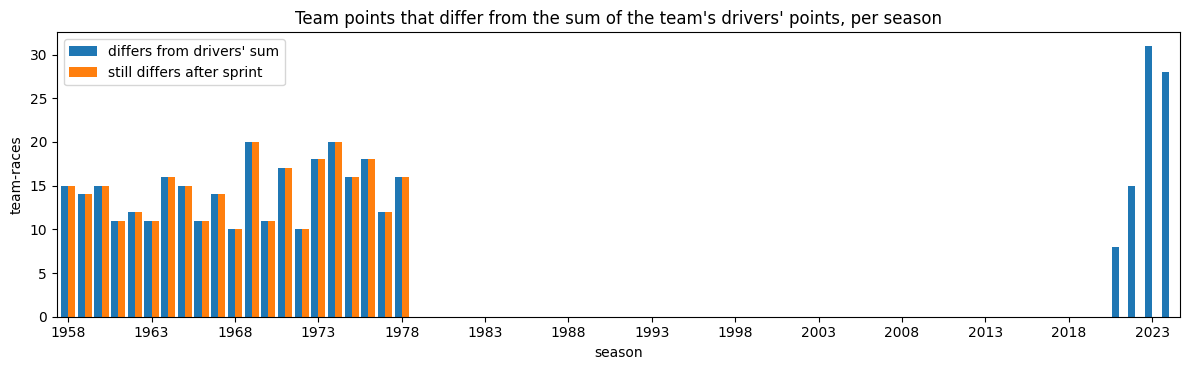

In [445]:
# drivers' side: points per team per race from the deduplicated results
drivers_side = (results_unique.groupby(['raceId', 'constructorId'])
                .agg(drivers_sum=('points', 'sum'), best_car=('points', 'max'), cars=('points', 'size'))
                .reset_index())

# sprint points per team per race
sprint_team = (raw_before['sprint_results'].groupby(['raceId', 'constructorId']).points.sum()
               .rename('sprint_points').reset_index())

j = (crr.merge(drivers_side, on=['raceId', 'constructorId'])
        .merge(sprint_team, on=['raceId', 'constructorId'], how='left')
        .fillna({'sprint_points': 0}))
j['same_as_drivers'] = (j.points - j.drivers_sum).abs() < 1e-6
j['same_with_sprint'] = (j.points - j.drivers_sum - j.sprint_points).abs() < 1e-6

print('team-races compared:', len(j),
      '| team score = drivers sum:', int(j.same_as_drivers.sum()), f'({j.same_as_drivers.mean() * 100:.2f}%)',
      '| = drivers sum + sprint:', int(j.same_with_sprint.sum()), f'({j.same_with_sprint.mean() * 100:.2f}%)')

late = j[j.year >= 1979]
print('from 1979 on, not equal (with sprint):', int((~late.same_with_sprint).sum()), 'of', len(late))

rec = j[j.year >= 2021]
print('2021-2024: differences from drivers sum:', int((~rec.same_as_drivers).sum()),
      '| team-races with sprint points:', int((rec.sprint_points > 0).sum()),
      '| equal once sprint is added:', int(rec[rec.sprint_points > 0].same_with_sprint.sum()))

# the differences that are left, and a first guess at why (old seasons)
old = j[~j.same_with_sprint]
reason = np.select([(old.points - old.best_car).abs() < 1e-6,
                    (old.points - (old.best_car - 1)).abs() < 1e-6],
                   ['only the best car counted', 'best car minus 1 point'], 'something else')
print('differences left:', len(old), '| seasons', int(old.year.min()), 'to', int(old.year.max()),
      '| team scored less than its drivers:', int((old.points < old.drivers_sum).sum()))
print('reasons:', pd.Series(reason).value_counts().to_dict())

# per-season picture
by_season = pd.DataFrame({
    "differs from drivers' sum": j[~j.same_as_drivers].groupby('year').size(),
    'still differs after sprint': j[~j.same_with_sprint].groupby('year').size()
}).reindex(range(1958, 2025), fill_value=0).fillna(0)
ax = by_season.plot.bar(figsize=(12, 3.8), width=0.85,
                        title="Team points that differ from the sum of the team's drivers' points, per season")
ax.set_xticks(range(0, len(by_season), 5))
ax.set_xticklabels(by_season.index[::5], rotation=0)
plt.xlabel('season')
plt.ylabel('team-races')
plt.tight_layout()
plt.show()


**Team score against the drivers' points.** For 12,617 team-races, the team's points in `constructor_results` equal the sum of its drivers' points in `results` in 96.96% of cases, and 97.61% once sprint points are added. From 1979 on, all 9,911 team-races agree. In 2021 to 2024, 82 team-races differ from the drivers' sum, which are exactly the 82 with sprint points, and all 82 agree once the sprint is added, so `constructor_results` already includes sprint points. The 302 remaining differences are all between 1958 and 1978, and in every one the team scored less than its drivers. In 292 of them the team score equals its best car's points, in 9 it equals the best car minus one point, and 1 is unexplained. This fits seasons in which only the best car counted for the team, which is general Formula 1 knowledge and not shown by the table.

## `Sprint Results Table`

In [446]:
sprint_results = load('sprint_results')

print('shape:', sprint_results.shape)
display(sprint_results.head())
print(sprint_results.dtypes)
print('\nmissing per column:')
print(sprint_results.isna().sum())

shape: (360, 16)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,fastestLapTime,statusId
0,1,1061,830,9,33,2,1.0,1,1,3,17,25:38.426,1538426.0,14.0,1:30.013,1
1,2,1061,1,131,44,1,2.0,2,2,2,17,+1.430,1539856.0,17.0,1:29.937,1
2,3,1061,822,131,77,3,3.0,3,3,1,17,+7.502,1545928.0,17.0,1:29.958,1
3,4,1061,844,6,16,4,4.0,4,4,0,17,+11.278,1549704.0,16.0,1:30.163,1
4,5,1061,846,1,4,6,5.0,5,5,0,17,+24.111,1562537.0,16.0,1:30.566,1


resultId            int64
raceId              int64
driverId            int64
constructorId       int64
number              int64
grid                int64
position          float64
positionText       object
positionOrder       int64
points              int64
laps                int64
time               object
milliseconds      float64
fastestLap        float64
fastestLapTime     object
statusId            int64
dtype: object

missing per column:
resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position          15
positionText       0
positionOrder      0
points             0
laps               0
time              20
milliseconds      20
fastestLap         9
fastestLapTime     9
statusId           0
dtype: int64


In [447]:
sp = sprint_results

print('resultId nulls:', sp.resultId.isna().sum(), '| duplicates:', sp.resultId.duplicated().sum())
print('(raceId, driverId) duplicates:', sp.duplicated(['raceId', 'driverId']).sum())

print('raceIds not in races:              ', (~sp.raceId.isin(races.raceId)).sum())
print('driverIds not in drivers:          ', (~sp.driverId.isin(drivers.driverId)).sum())
print('constructorIds not in constructors:', (~sp.constructorId.isin(constructors.constructorId)).sum())
print('statusIds not in status:           ', (~sp.statusId.isin(status.statusId)).sum())

resultId nulls: 0 | duplicates: 0
(raceId, driverId) duplicates: 0
raceIds not in races:               0
driverIds not in drivers:           0
constructorIds not in constructors: 0
statusIds not in status:            0


In [448]:
spr = sp.merge(races[['raceId', 'year', 'round', 'name']], on='raceId')
per_sprint = sp.groupby('raceId').size()
print('rows:', len(sp), '| sprints:', len(per_sprint), '| rows per sprint:', per_sprint.value_counts().to_dict())
print('same sprints as races.sprint_date:', set(sp.raceId) == set(races[races.sprint_date.notna()].raceId))

cov = pd.DataFrame({'races': races[races.year >= 2021].groupby('year').size(),
                    'with a sprint': spr.groupby('year').raceId.nunique()}).fillna(0).astype(int)
cov['share %'] = (cov['with a sprint'] / cov['races'] * 100).round(0)
display(cov)

rows: 360 | sprints: 18 | rows per sprint: {20: 18}
same sprints as races.sprint_date: True


,races,with a sprint,share %
year,,,
2021,22,3,14.0
2022,22,3,14.0
2023,22,6,27.0
2024,24,6,25.0


In [449]:
order = sp.groupby('raceId').positionOrder.agg(['min', 'max', 'nunique', 'size'])
print('finishing order is exactly 1..n:',
      bool(((order['min'] == 1) & (order['max'] == order['size']) & (order['nunique'] == order['size'])).all()))

finishing order is exactly 1..n: True


In [450]:
outcome = sp.statusId.map(status.set_index('statusId').status)
empty = pd.DataFrame({c: [int(sp[c].isna().sum()), int((sp[c].isna() & (outcome == 'Finished')).sum())]
                      for c in ['position', 'time', 'milliseconds', 'fastestLap', 'fastestLapTime']},
                     index=['empty cells', 'of them for a driver who Finished']).T
display(empty)
print('time empty together with milliseconds:', bool((sp.time.isna() == sp.milliseconds.isna()).all()))
print('fastestLap empty together with fastestLapTime:', bool((sp.fastestLap.isna() == sp.fastestLapTime.isna()).all()))

,empty cells,of them for a driver who Finished
position,15,0
time,20,0
milliseconds,20,0
fastestLap,9,0
fastestLapTime,9,0


time empty together with milliseconds: True
fastestLap empty together with fastestLapTime: True


In [451]:
sd = races[races.sprint_date.notna()].assign(days_before=lambda t: (t.date - t.sprint_date).dt.days)
print('days between sprint and Sunday race:', sd.days_before.value_counts().to_dict())

days between sprint and Sunday race: {1: 18}


In [452]:
print('fastestLapTime patterns:')
print(sp.fastestLapTime.dropna().str.replace(r'\d', '9', regex=True).value_counts().to_dict())

print('\ntime patterns:')
print(sp.time.dropna().str.replace(r'\d', '9', regex=True).value_counts().to_dict())


fastestLapTime patterns:
{'9:99.999': 351}

time patterns:
{'+99.999': 259, '+9.999': 38, '+9:99.999': 25, '99:99.999': 18}


In [453]:
sp = sprint_results.copy()

parts = sp.fastestLapTime.str.split(':', expand=True)
sp['fastestLapTime_s'] = parts[0].astype(float) * 60 + parts[1].astype(float)

print('filled before / after:', sp.fastestLapTime.notna().sum(), '/', sp.fastestLapTime_s.notna().sum())
print('range (s):', sp.fastestLapTime_s.min(), 'to', sp.fastestLapTime_s.max())
display(sp[['fastestLapTime', 'fastestLapTime_s']].dropna().head())

filled before / after: 351 / 351
range (s): 68.321 to 124.76


,fastestLapTime,fastestLapTime_s
0,1:30.013,90.013
1,1:29.937,89.937
2,1:29.958,89.958
3,1:30.163,90.163
4,1:30.566,90.566


## sprint_results: structure, keys, coverage and missing values

**Grain.** The table has 360 rows and 16 columns, with the same columns as `results`. One row is one driver's result in one sprint. It covers 18 sprints with exactly 20 rows each, 3 in 2021, 3 in 2022, 6 in 2023 and 6 in 2024, which is 14% to 27% of each season's races. They are exactly the 18 races that have a `sprint_date` in `races`.

**Types.** `points` is an integer here, because sprint points are whole numbers. `position`, `milliseconds` and `fastestLap` are floats only because they have missing values. The `fastestLapTime` column is stored as text in a single `m:ss.mmm` pattern, so we converted it to seconds in a new column called `fastestLapTime_s`. All 351 filled values converted with none lost, and the values range from 68.3 to 124.8 seconds, which is realistic for a sprint lap. The original text column was kept. The `time` column is also text, and it mixes the winner's full time with gaps to the winner, so we leave it unchanged and use `milliseconds` as the numeric version of the race time instead.

**Primary key.** `resultId` has 0 nulls and 0 duplicates, so it is a valid primary key. The natural key `(raceId, driverId)` also has 0 duplicates.

**Foreign keys.** Every `raceId`, `driverId`, `constructorId` and `statusId` exists in its parent table, so there are no orphans.

**Finishing order.** `positionOrder` runs exactly from 1 to 20 in every sprint, with no repeats and no gaps.

**Timing.** All 18 sprints took place exactly 1 day before their Sunday race, so a sprint result is always known before the race starts.

**Missing values.** `position` is empty in 15 rows, `time` and `milliseconds` in 20 rows, and `fastestLap` and `fastestLapTime` in 9 rows. Each pair is empty in the same rows, and none of the empty cells belongs to a driver who finished, so they mean the driver did not finish or set no lap time and not that data was lost. `positionOrder` is always filled, as in `results`.

**Decision.** A sprint feature would be empty for about 98% of all races, and it would be constant in any training window that ends before 2021, since sprints only exist from 2021 onward. In 2021 and 2022 the sprint result also set the Sunday starting grid, so it is largely redundant with the grid position we already use. We therefore propose not to use it in the main model, and at most to test a has_sprint flag as an optional experiment.

## `Lap Times Table`

In [454]:
lap_times = load('lap_times')
lt = lap_times.copy()
print(lt.shape)
print(lt.dtypes)
display(lt.head())
print(lt.isna().sum())

(589081, 6)
raceId           int64
driverId         int64
lap              int64
position         int64
time            object
milliseconds     int64
dtype: object


,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342


raceId          0
driverId        0
lap             0
position        0
time            0
milliseconds    0
dtype: int64


In [455]:
print('duplicate (raceId, driverId, lap):', lt.duplicated(['raceId', 'driverId', 'lap']).sum())
print('races covered:', lt.raceId.nunique())
print('drivers:', lt.driverId.nunique())
print('lap range:', lt.lap.min(), 'to', lt.lap.max())
print('position range:', lt.position.min(), 'to', lt.position.max())

duplicate (raceId, driverId, lap): 0
races covered: 544
drivers: 143
lap range: 1 to 87
position range: 1 to 24


first season: 1996
last season: 2024
races with lap data: 544 of 1125
races from 1996 on: 544
of them with lap data: 544
races before 1996 with lap data: 0


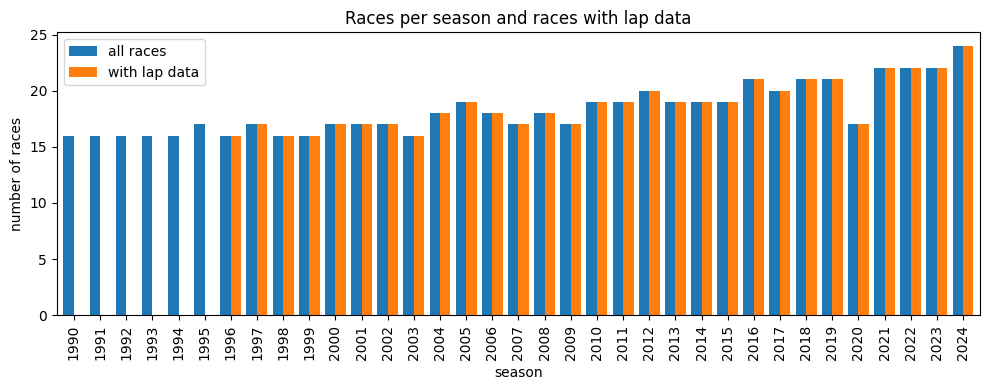

In [456]:
laps = lap_times.merge(races[['raceId', 'year']], on='raceId')
print('first season:', laps.year.min())
print('last season:', laps.year.max())
print('races with lap data:', laps.raceId.nunique(), 'of', len(races))
import matplotlib.pyplot as plt

since_1996 = races[races.year >= 1996]
print('races from 1996 on:', len(since_1996))
print('of them with lap data:', since_1996.raceId.isin(laps.raceId).sum())
print('races before 1996 with lap data:', laps[laps.year < 1996].raceId.nunique())

per_year = races.groupby('year').size().rename('all races').to_frame()
per_year['with lap data'] = laps.groupby('year').raceId.nunique()
per_year = per_year.fillna(0)

per_year.loc[1990:].plot.bar(figsize=(10, 4), width=0.8,
    title='Races per season and races with lap data')
plt.xlabel('season')
plt.ylabel('number of races')
plt.tight_layout()
plt.show()


In [457]:
per_driver = laps.groupby(['raceId', 'driverId']).lap.agg(['min', 'max', 'nunique', 'size'])
no_gap = (per_driver['min'] == 1) & (per_driver['max'] == per_driver['nunique']) & (per_driver['nunique'] == per_driver['size'])
print('driver-races:', len(per_driver), '| laps run 1..n with no gap:', int(no_gap.sum()))

per_lap = laps.groupby(['raceId', 'lap']).position.agg(['nunique', 'size', 'max'])
print('race-laps:', len(per_lap))
print('all positions different within a lap:', int((per_lap['nunique'] == per_lap['size']).sum()))
print('positions run exactly 1..n:', int((per_lap['max'] == per_lap['size']).sum()))

driver-races: 11041 | laps run 1..n with no gap: 11041
race-laps: 33196
all positions different within a lap: 33196
positions run exactly 1..n: 33196


In [458]:
normal = laps.time.str.match(r'^\d+:\d{2}\.\d{3}$')
with_hours = laps.time.str.match(r'^\d+:\d{2}:\d{2}\.\d{3}$')
print('time looks like m:ss.mmm:', int(normal.sum()))
print('time looks like h:mm:ss.mmm:', int(with_hours.sum()))
print('any other format:', int((~normal & ~with_hours).sum()))

def lap_text_to_ms(s):
    parts = s.split(':')
    seconds, minutes = float(parts[-1]), float(parts[-2])
    hours = float(parts[-3]) if len(parts) > 2 else 0.0
    return round(((hours * 60 + minutes) * 60 + seconds) * 1000)

print('time text agrees with milliseconds:', int((laps.time.map(lap_text_to_ms) == laps.milliseconds).sum()), 'of', len(laps))

time looks like m:ss.mmm: 589038
time looks like h:mm:ss.mmm: 43
any other format: 0
time text agrees with milliseconds: 589081 of 589081


In [459]:
long_laps = laps[laps.time.str.match(r'^\d+:\d{2}:\d{2}\.\d{3}$')].merge(races[['raceId', 'name']], on='raceId')
display(long_laps.groupby(['year', 'name']).agg(rows=('lap', 'size'), first_lap=('lap', 'min'), last_lap=('lap', 'max'), shortest=('time', 'min'), longest=('time', 'max')))

,,rows,first_lap,last_lap,shortest,longest
year,name,,,,,
2011,Canadian Grand Prix,23,25,25,2:04:29.869,2:05:07.547
2014,British Grand Prix,20,1,2,1:01:07.384,1:03:23.459


In [460]:
with_names = laps.merge(races[['raceId', 'name']], on='raceId')
print('median lap (ms):', int(laps.milliseconds.median()))
print('fastest lap (ms):', laps.milliseconds.min())
print('slowest lap (ms):', laps.milliseconds.max(), '=', round(laps.milliseconds.max() / 60000, 1), 'minutes')
display(pd.concat([with_names.nsmallest(1, 'milliseconds'), with_names.nlargest(1, 'milliseconds')])[['year', 'name', 'lap', 'milliseconds']])


median lap (ms): 90608
fastest lap (ms): 55404
slowest lap (ms): 7507547 = 125.1 minutes


,year,name,lap,milliseconds
488409,2020,Sakhir Grand Prix,80,55404
8372,2011,Canadian Grand Prix,25,7507547


## lap_times: structure, keys, coverage and trust in the time column

**Grain.** The table has 589,081 rows and 6 columns. One row is one completed lap of one driver in one race, and `position` is the driver's running position at the end of that lap, not the final result.

**Types and missing values.** No column has missing values. `raceId`, `driverId`, `lap`, `position` and `milliseconds` are integers. The `time` column is text, and it is the same lap time as `milliseconds` written in another form. All 589,081 `time` values follow one of two patterns, `m:ss.mmm` in 589,038 rows and `h:mm:ss.mmm` in 43 rows, with none in any other format. Converting the text to milliseconds gives exactly the `milliseconds` column in all 589,081 rows. We therefore use `milliseconds` as the numeric lap time and leave `time` unchanged.

**Primary key.** The table has no ID column, and `(raceId, driverId, lap)` has 0 duplicates, so it is a valid natural key.

**Coverage.** Lap data covers 544 races from 1996 to 2024 and 143 drivers. All 544 races from 1996 on have lap data, and no race before 1996 has any, so the coverage is a clean cut at 1996. This is 544 of 1,125 races, which is about 48% of all races.

**Completeness.** In all 11,041 driver-races the laps run exactly 1 to n with no gap. In all 33,196 race-laps no two drivers share a position, and the positions run exactly from 1 to the number of cars. So every lap gives a proper running order. Positions go up to 24 and lap numbers up to 87.

**Long laps.** The 43 laps in `h:mm:ss.mmm` form come from two races, 23 from lap 25 of the 2011 Canadian Grand Prix (about 2 hours) and 20 from laps 1 and 2 of the 2014 British Grand Prix (about 1 hour). They are consistent with red-flag stoppages included in the lap time. They are real values and not errors, but they are extreme, since the slowest lap is 125.1 minutes while the median lap is 90.6 seconds.


In [461]:
race_median = laps.groupby('raceId').milliseconds.median() / 1000
low, middle, high = race_median.quantile([0.01, 0.5, 0.99])
print('typical lap of a race (seconds):')
print('fastest race:', round(race_median.min(), 1))
print('1% of races below:', round(low, 1))
print('median:', round(middle, 1))
print('99% of races below:', round(high, 1))
print('slowest race:', round(race_median.max(), 1))


typical lap of a race (seconds):
fastest race: 58.7
1% of races below: 70.3
median: 91.1
99% of races below: 122.2
slowest race: 225.4


In [462]:
laps['relative'] = laps.milliseconds / laps.groupby('raceId').milliseconds.transform('median')
print('relative lap: median', round(laps.relative.median(), 3))
print('smallest', round(laps.relative.min(), 3), '| largest', round(laps.relative.max(), 1))
print('lap 1 (standing start) median:', round(laps[laps.lap == 1].relative.median(), 3))

slow = pd.DataFrame({'laps': {f'slower than {k} x typical': int((laps.relative > k).sum()) for k in [1.2, 1.5, 2, 3]}})
slow['% of all laps'] = (slow['laps'] / len(laps) * 100).round(2)
display(slow)

relative lap: median 1.0
smallest 0.745 | largest 72.7
lap 1 (standing start) median: 1.131


,laps,% of all laps
slower than 1.2 x typical,38875,6.60
slower than 1.5 x typical,11709,1.99
slower than 2 x typical,1092,0.19
slower than 3 x typical,723,0.12


## lap_times: extreme laps and why circuits cannot be compared

**Typical and extreme laps.** The median lap is 90,608 ms, which is about 90.6 seconds. The fastest lap is 55,404 ms, from lap 80 of the 2020 Sakhir Grand Prix, which is consistent with the short outer layout used for that race. The slowest lap is 7,507,547 ms, which is 125.1 minutes, from lap 25 of the 2011 Canadian Grand Prix, where the red-flag stoppage is included in the lap time. The slowest lap is more than 80 times the median, so a single stoppage lap would distort any plain average of lap times.

**Circuits cannot be compared on raw lap times.** Every circuit has its own length, so a lap of the same duration means something different in each race. The typical (median) lap of a race is 58.7 seconds in the fastest race and 91.1 seconds in the median race. 1% of races are below 70.3 seconds and 99% of races are below 122.2 seconds. The slowest race has a typical lap of 225.4 seconds, far outside the rest, and we have not yet checked which race this is or why. A model fed raw lap times would mostly learn which circuit it was looking at and not how fast the driver was.

**Relative lap time.** To put all races on one scale, we divide each lap by the median lap of its own race, so 1.0 is a typical lap of that race. The median relative lap is 1.0 by construction. The smallest value is 0.745 and the largest is 72.7, which is the 2011 Canadian Grand Prix stoppage lap. Lap 1 has a median of 1.131, so a first lap is about 13% slower than a typical lap, which fits the standing start.

**How common are slow laps.** Most laps are close to typical, and extreme laps are rare.

| Slower than | Laps | Share of all laps |
|---|---|---|
| 1.2 x typical | 38,875 | 6.60% |
| 1.5 x typical | 11,709 | 1.99% |
| 2 x typical | 1,092 | 0.19% |
| 3 x typical | 723 | 0.12% |

About 93% of laps are within 20% of the typical lap of their race. The reasons for the slow laps (pit stops, lap 1, safety cars, red flags) have not been checked yet, because that needs the pit_stops table.

**Decision.** Raw lap times are not used. Any pace feature built from laps uses the relative lap time, and because a few stoppage laps are extreme, it takes a median or caps the values instead of using a plain average.

In [463]:
one_row = results_unique.drop_duplicates(['raceId', 'driverId'])
count = (laps.groupby(['raceId', 'driverId']).size().rename('lap_rows').reset_index()
         .merge(one_row[['raceId', 'driverId', 'laps']], on=['raceId', 'driverId']))
count['difference'] = count.lap_rows - count.laps
different = count[count.difference != 0]
print('driver-races:', len(count))
print('lap rows = laps in results:', int((count.difference == 0).sum()))
print('different:', len(different), 'in', different.raceId.nunique(), 'of', count.raceId.nunique(), 'races')
print('differ by 1 or 2 laps:', int((different.difference.abs() <= 2).sum()))
print('differ by 10 laps or more:', int((different.difference.abs() >= 10).sum()))

driver-races: 11041
lap rows = laps in results: 10951
different: 90 in 35 of 544 races
differ by 1 or 2 laps: 71
differ by 10 laps or more: 10


In [464]:
# driver-races where lap_times and results differ by 10 laps or more
big = different[different.difference.abs() >= 10].merge(races[['raceId', 'year', 'name']], on='raceId')

cols = ['raceId', 'driverId', 'grid', 'positionOrder', 'laps', 'statusId']
check = big.merge(one_row[cols], on=['raceId', 'driverId', 'laps'])
display(check[['year', 'name', 'driverId', 'lap_rows', 'laps', 'grid', 'positionOrder', 'statusId']].sort_values(['year', 'name']))

,year,name,driverId,lap_rows,laps,grid,positionOrder,statusId
4,2001,Hungarian Grand Prix,15,75,53,5,17,9
5,2001,Hungarian Grand Prix,55,53,75,12,10,12
6,2001,Italian Grand Prix,15,52,0,5,22,4
7,2001,Japanese Grand Prix,15,5,52,8,8,11
8,2001,Japanese Grand Prix,55,52,5,11,22,4
3,2006,French Grand Prix,22,18,28,13,20,5
2,2008,British Grand Prix,21,26,16,19,17,20
0,2009,Italian Grand Prix,17,52,0,10,20,4
1,2009,Italian Grand Prix,67,19,52,19,13,11
9,2024,São Paulo Grand Prix,807,30,0,17,20,2


In [465]:
d = (different
     .merge(one_row[['raceId', 'driverId', 'grid', 'positionOrder', 'statusId']], on=['raceId', 'driverId'])
     .merge(races[['raceId', 'year', 'name']], on='raceId')
     .merge(status[['statusId', 'status']], on='statusId')
     .merge(drivers[['driverId', 'surname']], on='driverId'))

print('rows:', len(d))
print('lap_times has MORE laps than results:', int((d.difference > 0).sum()))
print('lap_times has FEWER laps than results:', int((d.difference < 0).sum()))
print('grid == 0:', int((d.grid == 0).sum()))
print(d.status.value_counts().head(8))

pd.set_option('display.max_rows', 100)
display(d[['year', 'name', 'surname', 'lap_rows', 'laps', 'difference', 'grid', 'positionOrder', 'status']]
        .sort_values(['year', 'name']))

rows: 90
lap_times has MORE laps than results: 37
lap_times has FEWER laps than results: 53
grid == 0: 0
status
+1 Lap        20
Accident      11
Finished      11
Collision      8
+2 Laps        5
Spun off       4
Engine         4
Hydraulics     4
Name: count, dtype: int64


,year,name,surname,lap_rows,laps,difference,grid,positionOrder,status
39,1998,Monaco Grand Prix,Frentzen,9,5,4,5,20,Collision
31,2001,Belgian Grand Prix,Trulli,36,31,5,16,14,Engine
32,2001,Belgian Grand Prix,Alesi,31,36,-5,13,6,Finished
33,2001,Belgian Grand Prix,Marques,32,31,1,22,13,+5 Laps
29,2001,Hungarian Grand Prix,Trulli,75,53,22,5,17,Hydraulics
30,2001,Hungarian Grand Prix,Alesi,53,75,-22,12,10,+2 Laps
34,2001,Italian Grand Prix,Trulli,52,0,52,5,22,Collision
37,2001,Japanese Grand Prix,Trulli,5,52,-47,8,8,+1 Lap
38,2001,Japanese Grand Prix,Alesi,52,5,47,11,22,Collision
35,2001,United States Grand Prix,Trulli,72,73,-1,8,4,Finished


In [466]:
print(d.groupby('status').difference.agg(['size', 'min', 'median', 'max']).sort_values('size', ascending=False).head(10))

            size  min  median  max
status                            
+1 Lap        20  -47     1.0    2
Accident      11   -2    -1.0   -1
Finished      11   -5     2.0    2
Collision      8   -3     1.5   52
+2 Laps        5  -22    -1.0    2
Engine         4  -10     1.0    5
Hydraulics     4   -2     1.0   22
Spun off       4   -1     0.5   10
+4 Laps        3   -2    -1.0    2
Brakes         3   -5    -4.0   -1


In [467]:
small = d[d.difference.abs() <= 2]
by_race = (small.groupby(['year', 'name']).size()
           .rename('small differences').sort_values(ascending=False))
print('rows with a 1 or 2 lap difference:', len(small))
print('races involved:', len(by_race))
print('share in the top race:', round(by_race.iloc[0] / len(small) * 100, 1), '%')
display(by_race.head(10))

rows with a 1 or 2 lap difference: 71
races involved: 24
share in the top race: 28.2 %


year  name                    
2014  Chinese Grand Prix          20
2003  Brazilian Grand Prix         9
2010  Belgian Grand Prix           7
      Monaco Grand Prix            6
2014  Hungarian Grand Prix         6
2001  United States Grand Prix     2
2005  Chinese Grand Prix           2
2012  Indian Grand Prix            2
2010  Canadian Grand Prix          2
2004  French Grand Prix            1
Name: small differences, dtype: int64

In [468]:
cn = d[(d.year == 2014) & (d.name == 'Chinese Grand Prix')]
print('drivers in that race with a difference:', len(cn))
print(cn.difference.value_counts().to_dict())
display(cn[['surname', 'lap_rows', 'laps', 'difference', 'positionOrder', 'status']].sort_values('positionOrder'))

drivers in that race with a difference: 20
{2: 20}


,surname,lap_rows,laps,difference,positionOrder,status
63,Hamilton,56,54,2,1,Finished
64,Rosberg,56,54,2,2,Finished
65,Alonso,56,54,2,3,Finished
74,Ricciardo,56,54,2,4,Finished
69,Vettel,56,54,2,5,Finished
71,Hülkenberg,56,54,2,6,Finished
78,Bottas,56,54,2,7,Finished
66,Räikkönen,56,54,2,8,Finished
73,Pérez,56,54,2,9,Finished
81,Kvyat,55,53,2,10,+1 Lap


In [469]:
cn_all = (laps[laps.raceId == cn.raceId.iloc[0]].groupby('driverId').size().rename('lap_rows').reset_index()
          .merge(one_row[['raceId', 'driverId', 'laps', 'positionOrder']], on='driverId')
          .query('raceId == @cn.raceId.iloc[0]'))
print('max laps in lap_times:', laps[laps.raceId == cn.raceId.iloc[0]].lap.max())
print('max laps in results:', cn_all.laps.max())
display(cn_all.sort_values('positionOrder').head(5))

max laps in lap_times: 56
max laps in results: 54


,driverId,lap_rows,raceId,laps,positionOrder
132,1,56,903,54,1
506,3,56,903,54,2
782,4,56,903,54,3
3245,817,56,903,54,4
2149,20,56,903,54,5


In [470]:
d['abs_diff'] = d.difference.abs()
print('differ by 3 to 9 laps:', int(d.abs_diff.between(3, 9).sum()))
display(d[(d.abs_diff >= 3) | (d.status == 'Finished')]
        [['year', 'name', 'surname', 'lap_rows', 'laps', 'difference', 'positionOrder', 'status']]
        .sort_values(['year', 'name']))

differ by 3 to 9 laps: 9


,year,name,surname,lap_rows,laps,difference,positionOrder,status
39,1998,Monaco Grand Prix,Frentzen,9,5,4,20,Collision
31,2001,Belgian Grand Prix,Trulli,36,31,5,14,Engine
32,2001,Belgian Grand Prix,Alesi,31,36,-5,6,Finished
29,2001,Hungarian Grand Prix,Trulli,75,53,22,17,Hydraulics
30,2001,Hungarian Grand Prix,Alesi,53,75,-22,10,+2 Laps
34,2001,Italian Grand Prix,Trulli,52,0,52,22,Collision
37,2001,Japanese Grand Prix,Trulli,5,52,-47,8,+1 Lap
38,2001,Japanese Grand Prix,Alesi,52,5,47,22,Collision
35,2001,United States Grand Prix,Trulli,72,73,-1,4,Finished
15,2004,United States Grand Prix,Heidfeld,43,40,3,12,Engine


In [471]:
for rid_year, rid_name in [(2003, 'Brazilian Grand Prix'), (2010, 'Belgian Grand Prix'), (2010, 'Monaco Grand Prix'), (2014, 'Hungarian Grand Prix')]:
    sub = d[(d.year == rid_year) & (d.name == rid_name)]
    print(rid_year, rid_name, '| rows:', len(sub), '| differences:', sub.difference.value_counts().to_dict())

2003 Brazilian Grand Prix | rows: 9 | differences: {-1: 9}
2010 Belgian Grand Prix | rows: 7 | differences: {-1: 5, -2: 2}
2010 Monaco Grand Prix | rows: 6 | differences: {-2: 4, -1: 2}
2014 Hungarian Grand Prix | rows: 6 | differences: {-1: 4, -2: 2}


In [472]:
fl = one_row[['raceId', 'driverId', 'fastestLapTime']].dropna(subset=['fastestLapTime']).copy()
fl = fl[fl.raceId.isin(laps.raceId)]
fl['results_ms'] = fl.fastestLapTime.map(
    lambda s: round((float(s.split(':')[0]) * 60 + float(s.split(':')[1])) * 1000))
best = laps.groupby(['raceId', 'driverId']).milliseconds.min().rename('lap_times_ms').reset_index()
fl = fl.merge(best, on=['raceId', 'driverId'])

same = fl.lap_times_ms == fl.results_ms
print('driver-races with a fastest lap in results (and lap data):', len(fl))
print('same fastest lap in both tables:', int(same.sum()), f'({same.mean() * 100:.1f}%)')
print('different:', int((~same).sum()))

driver-races with a fastest lap in results (and lap data): 8249
same fastest lap in both tables: 8039 (97.5%)
different: 210


In [473]:
bad = fl[~same].copy()
bad['gap_ms'] = bad.lap_times_ms - bad.results_ms
bad['abs_gap'] = bad.gap_ms.abs()
print('gap = lap_times minus results (ms)')
print('lap_times faster (negative):', int((bad.gap_ms < 0).sum()), '| slower (positive):', int((bad.gap_ms > 0).sum()))
print('within 10 ms:', int((bad.abs_gap <= 10).sum()), '| within 1 second:', int((bad.abs_gap <= 1000).sum()), '| over 1 second:', int((bad.abs_gap > 1000).sum()))
print(bad.abs_gap.describe().round(0))

bad = bad.merge(races[['raceId', 'year']], on='raceId')
print(bad.year.value_counts().sort_index().to_dict())

gap = lap_times minus results (ms)
lap_times faster (negative): 150 | slower (positive): 60
within 10 ms: 3 | within 1 second: 133 | over 1 second: 77
count      210.0
mean      3855.0
std       9593.0
min          1.0
25%        266.0
50%        639.0
75%       1550.0
max      71585.0
Name: abs_gap, dtype: float64
{2006: 3, 2007: 7, 2008: 3, 2009: 1, 2010: 6, 2011: 21, 2012: 17, 2013: 8, 2014: 20, 2015: 11, 2016: 5, 2017: 4, 2018: 30, 2019: 12, 2020: 13, 2021: 13, 2022: 23, 2023: 8, 2024: 5}


In [474]:
bad = bad.merge(races[['raceId', 'name']], on='raceId')
print('races involved:', bad.raceId.nunique())
print(bad.groupby(['year', 'name']).size().sort_values(ascending=False).head(8))
display(bad.sort_values('abs_gap', ascending=False).head(8)[['year', 'name', 'driverId', 'lap_times_ms', 'results_ms', 'gap_ms']])

races involved: 72
year  name                    
2011  British Grand Prix          20
2014  Australian Grand Prix       18
2018  Italian Grand Prix          13
      United States Grand Prix    11
2022  United States Grand Prix     9
2012  British Grand Prix           9
2013  British Grand Prix           8
2019  German Grand Prix            7
dtype: int64


,year,name,driverId,lap_times_ms,results_ms,gap_ms
7,2007,European Grand Prix,24,130715,202300,-71585
6,2007,European Grand Prix,26,129078,181900,-52822
17,2010,German Grand Prix,15,95768,134452,-38684
5,2007,European Grand Prix,3,133966,170950,-36984
15,2010,Monaco Grand Prix,18,98509,134285,-35776
19,2010,Japanese Grand Prix,9,127363,161378,-34015
9,2007,Brazilian Grand Prix,21,89298,122680,-33382
135,2018,United States Grand Prix,4,133811,100933,32878


In [475]:
mismatch = (count.assign(laps_mismatch=count.difference.abs() >= 3)
                 [['raceId', 'driverId', 'laps_mismatch']])

before = len(laps)
laps = laps.drop(columns='laps_mismatch', errors='ignore').merge(mismatch, on=['raceId', 'driverId'], how='left')
laps['laps_mismatch'] = laps.laps_mismatch.fillna(False).astype(bool)

print('rows unchanged:', len(laps) == before)
print('flagged driver-races:', int(laps[laps.laps_mismatch].groupby(['raceId', 'driverId']).ngroups), '(expect 19)')
print('flagged lap rows:', int(laps.laps_mismatch.sum()))

rows unchanged: True
flagged driver-races: 19 (expect 19)
flagged lap rows: 671


## lap_times, agreement with results

**Lap counts.** We compared the number of lap rows of every driver in every race with the `laps` column in `results`. Of 11,041 driver-races, 10,951 (99.2%) have the same count in both tables. The other 90 differ and they are spread over 35 of the 544 races. Of these, 71 differ by 1 or 2 laps, 9 by 3 to 9 laps and 10 by 10 laps or more. Lap_times has more laps in 37 cases and fewer in 53, and none of the 90 drivers started from the pit lane.

**Differences of 1 or 2 laps.** These are mostly small and fall into two kinds. In the 2014 Chinese GP all 20 drivers differ by exactly +2, because lap_times runs to 56 laps and results stops at 54. The race was scheduled for 56 laps (this comes from F1 knowledge and not from the tables), so the error looks like it is in results and not in lap_times. We have not tested why. The other cases are scattered and mostly negative. All 11 Accident rows are -1 or -2, and the 2003 Brazilian, 2010 Belgian, 2010 Monaco and 2014 Hungarian races only have negative differences of 1 or 2 laps. This looks like a small counting difference at the end of a driver's race, but we have not tested it.

**Differences of 3 laps or more.** There are 19 driver-races in 14 races. Six of them come from three swaps between Trulli and Alesi in the 2001 Belgian, Hungarian and Japanese Grands Prix, where the two drivers have opposite lap counts in the two tables. They were teammates, which is F1 knowledge and makes a mix-up between the two cars plausible. A similar pair appears in the 2009 Italian GP with Webber and Buemi. In these cases the results row fits the finishing position and status, so lap_times looks like the table that is wrong. Three drivers have 30 to 52 lap rows but 0 laps in results (Trulli in the 2001 Italian GP, Webber in the 2009 Italian GP and Hülkenberg in the 2024 São Paulo GP, where the status is Disqualified). The remaining cases are single differences of 3 to 10 laps, mostly retirements, without a clear pattern. We have not confirmed any of this with an outside source.

**Fastest laps.** We compared each driver's quickest lap in lap_times with `fastestLapTime` in results, for the 8,249 driver-races that have both. The two tables agree in 8,039 cases (97.5%) and differ in 210 cases, spread over 72 races between 2006 and 2024. These differences are not rounding, since only 3 are within 10 ms, the median gap is 639 ms, 77 are over a second and the largest is about 71.6 seconds. In 150 cases lap_times has the faster lap and in 60 it has the slower one. The differences cluster partly in a few races, with eight races holding 95 of the 210. In the 2011 British Grand Prix, 20 of 24 drivers differ and in every case lap_times is faster by 0.3 to 3.3 seconds, which looks like a shift affecting the whole race. In the 2014 Australian Grand Prix, 18 of 20 drivers differ in both directions with a median gap of only 62 ms, so the two tables seem to report different laps for each driver. The largest single gaps include three drivers in the 2007 European Grand Prix whose fastest lap in results is 37 to 72 seconds slower than in lap_times. We have not confirmed which table is wrong. Because `fastestLapTime` in results is only known after the race and is not planned as a feature, this affects only possible lap-based pace features and not the target.

**Decision.** We keep all rows in lap_times. We add a flag `laps_mismatch` to the 19 driver-races that differ by 3 laps or more, and lap-based features skip them. Differences of 1 or 2 laps are not flagged, and the 210 fastest-lap differences are not flagged either, since their lap counts agree and the doubt is only about one lap. The 2014 Chinese GP is noted as a likely error in `results.laps`, which we do not use as a feature.

## `Pit Stops Table`

In [476]:
pit_stops = load('pit_stops')

ps = pit_stops.copy()
print(ps.shape)
print(ps.dtypes)
display(ps.head())
print(ps.isna().sum())
print('duplicate (raceId, driverId, stop):', ps.duplicated(['raceId', 'driverId', 'stop']).sum())
print('races:', ps.raceId.nunique(), '| drivers:', ps.driverId.nunique())
ps = ps.merge(races[['raceId', 'year']], on='raceId')
print('first season:', ps.year.min(), '| last season:', ps.year.max())

(11371, 7)
raceId           int64
driverId         int64
stop             int64
lap              int64
time            object
duration        object
milliseconds     int64
dtype: object


,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021
2,841,17,1,11,17:20:48,23.426,23426
3,841,4,1,12,17:22:34,23.251,23251
4,841,13,1,13,17:24:10,23.842,23842


raceId          0
driverId        0
stop            0
lap             0
time            0
duration        0
milliseconds    0
dtype: int64
duplicate (raceId, driverId, stop): 0
races: 285 | drivers: 76
first season: 2011 | last season: 2024


In [477]:
since_2011 = races[races.year >= 2011]
print('races from 2011 on:', len(since_2011), '| with pit stop data:', since_2011.raceId.isin(ps.raceId).sum())
print('races before 2011 with pit stops:', int((ps.year < 2011).sum()))

print('duration formats:', ps.duration.str.match(r'^\d+\.\d{3}$').sum(), 'plain seconds |',
      ps.duration.str.match(r'^\d+:\d{2}\.\d{3}$').sum(), 'm:ss.mmm |',
      (~ps.duration.str.match(r'^\d+(:\d{2})?\.\d{3}$')).sum(), 'other')

def dur_to_ms(s):
    parts = s.split(':')
    return round((float(parts[-1]) + (float(parts[-2]) * 60 if len(parts) > 1 else 0)) * 1000)

print('duration agrees with milliseconds:', int((ps.duration.map(dur_to_ms) == ps.milliseconds).sum()), 'of', len(ps))
print('milliseconds: min', ps.milliseconds.min(), '| median', int(ps.milliseconds.median()), '| max', ps.milliseconds.max())

races from 2011 on: 286 | with pit stop data: 285
races before 2011 with pit stops: 0
duration formats: 10854 plain seconds | 517 m:ss.mmm | 0 other
duration agrees with milliseconds: 11371 of 11371
milliseconds: min 12897 | median 23606 | max 3069017


In [478]:
print('duration:')
print(ps.duration.str.len().value_counts().to_dict())
print(ps.duration.head(5).tolist())
print(ps[ps.duration.str.contains(':')].duration.head(5).tolist())

print('time:')
print(ps.time.str.len().value_counts().to_dict())
print(ps.time.head(5).tolist())

duration:
{6: 10854, 9: 460, 8: 57}
['26.898', '25.021', '23.426', '23.251', '23.842']
['16:44.718', '2:03.124', '1:29.401', '1:44.833', '1:14.026']
time:
{8: 11371}
['17:05:23', '17:05:52', '17:20:48', '17:22:34', '17:24:10']


In [479]:
def dur_to_s(s):
    parts = s.split(':')
    return float(parts[-1]) + (float(parts[-2]) * 60 if len(parts) > 1 else 0)

before_dur, before_time = ps.duration.notna().sum(), ps.time.notna().sum()

ps['duration_s'] = ps.duration.map(dur_to_s)
ps['time_of_day'] = pd.to_datetime(ps.time, format='%H:%M:%S').dt.time

print('duration filled before / after:', before_dur, '/', ps.duration_s.notna().sum())
print('duration matches milliseconds:', int((ps.duration_s.round(3) == (ps.milliseconds / 1000).round(3)).sum()), 'of', len(ps))
print('duration range (s):', ps.duration_s.min(), 'to', ps.duration_s.max())
print('time filled before / after:', before_time, '/', ps.time_of_day.notna().sum())
display(ps[['duration', 'duration_s', 'time', 'time_of_day']].head())

duration filled before / after: 11371 / 11371
duration matches milliseconds: 11371 of 11371
duration range (s): 12.897 to 3069.017
time filled before / after: 11371 / 11371


,duration,duration_s,time,time_of_day
0,26.898,26.898,17:05:23,17:05:23
1,25.021,25.021,17:05:52,17:05:52
2,23.426,23.426,17:20:48,17:20:48
3,23.251,23.251,17:22:34,17:22:34
4,23.842,23.842,17:24:10,17:24:10


In [480]:
import matplotlib.pyplot as plt

before_types = pit_stops.dtypes.astype(str)

def dur_to_s(s):
    parts = s.split(':')
    return float(parts[-1]) + (float(parts[-2]) * 60 if len(parts) > 1 else 0)

before_dur, before_time = ps.duration.notna().sum(), ps.time.notna().sum()
ps['duration_s'] = ps.duration.map(dur_to_s)
ps['time_of_day'] = pd.to_datetime(ps.time, format='%H:%M:%S').dt.time

print('duration filled before / after:', before_dur, '/', ps.duration_s.notna().sum())
print('duration matches milliseconds:', int((ps.duration_s.round(3) == (ps.milliseconds / 1000).round(3)).sum()), 'of', len(ps))
print('duration range (s):', ps.duration_s.min(), 'to', ps.duration_s.max())
print('time filled before / after:', before_time, '/', ps.time_of_day.notna().sum())

after_types = pd.Series({
    'raceId': 'int64', 'driverId': 'int64', 'stop': 'int64', 'lap': 'int64',
    'time': 'object (kept)', 'time_of_day': 'time', 
    'duration': 'object (kept)', 'duration_s': 'float64', 'milliseconds': 'int64'})

comparison = pd.DataFrame({'before': before_types, 'after': after_types}).fillna('new column')
display(comparison)

duration filled before / after: 11371 / 11371
duration matches milliseconds: 11371 of 11371
duration range (s): 12.897 to 3069.017
time filled before / after: 11371 / 11371


,before,after
driverId,int64,int64
duration,object,object (kept)
duration_s,new column,float64
lap,int64,int64
milliseconds,int64,int64
raceId,int64,int64
stop,int64,int64
time,object,object (kept)
time_of_day,new column,time


In [481]:
missing = races[(races.year >= 2011) & ~races.raceId.isin(ps.raceId)]
print(missing[['year', 'name', 'date']].values.tolist())

[[2021, 'Belgian Grand Prix', Timestamp('2021-08-29 00:00:00')]]


In [482]:
ru = results_unique.merge(races[['raceId', 'year']], on='raceId')
ru = ru[ru.raceId.isin(ps.raceId)].merge(status[['statusId', 'status']], on='statusId')
stops = ps.groupby(['raceId', 'driverId']).size().rename('stops').reset_index()
ru = ru.merge(stops, on=['raceId', 'driverId'], how='left').fillna({'stops': 0})
fin = ru[ru.status.eq('Finished') | ru.status.str.match(r'^\+\d+ Laps?$')]

print('race starts in races with pit data:', len(ru), '| with at least one stop:', int((ru.stops > 0).sum()))
print('finishers:', len(fin), '| finishers with NO stop:', int((fin.stops == 0).sum()))

race starts in races with pit data: 5960 | with at least one stop: 5575
finishers: 4922 | finishers with NO stop: 3


In [483]:
odd = fin[fin.stops == 0].merge(races[['raceId', 'name']], on='raceId').merge(drivers[['driverId', 'surname']], on='driverId')
display(odd[['year', 'name', 'surname', 'laps', 'positionOrder', 'status']])

,year,name,surname,laps,positionOrder,status
0,2011,Malaysian Grand Prix,Karthikeyan,14,23,+42 Laps
1,2019,Abu Dhabi Grand Prix,Gasly,53,18,+2 Laps
2,2021,Turkish Grand Prix,Ocon,57,10,+1 Lap


In [484]:
num = ps.groupby(['raceId', 'driverId']).stop.agg(['min', 'max', 'nunique', 'size'])
ok = (num['min'] == 1) & (num['max'] == num['size']) & (num['nunique'] == num['size'])
print('stops numbered exactly 1..n:', int(ok.sum()), 'of', len(num))
print('highest stop number:', ps.stop.max(), '| highest lap:', ps.lap.max())

stops numbered exactly 1..n: 5567 of 5575
highest stop number: 70 | highest lap: 78


In [485]:
bad_num = num[~ok].reset_index()
detail = (ps.merge(bad_num[['raceId', 'driverId']], on=['raceId', 'driverId'])
            .merge(races[['raceId', 'name']], on='raceId'))
display(detail[['year', 'name', 'driverId', 'stop', 'lap', 'duration']]
        .sort_values(['year', 'name', 'driverId', 'lap']))

,year,name,driverId,stop,lap,duration
0,2014,British Grand Prix,820,2,2,23.154
1,2014,British Grand Prix,820,3,29,29.737
2,2019,Singapore Grand Prix,832,2,35,30.623
4,2024,Monaco Grand Prix,1,1,1,39:35.369
12,2024,Monaco Grand Prix,1,51,2,24.232
7,2024,Monaco Grand Prix,822,1,1,39:54.053
9,2024,Monaco Grand Prix,822,15,2,24.239
3,2024,Monaco Grand Prix,830,1,1,39:32.670
13,2024,Monaco Grand Prix,830,52,2,23.813
5,2024,Monaco Grand Prix,840,1,1,39:43.588


In [486]:
start = races.set_index('raceId').time
first_stop = ps.groupby('raceId').time.min()
offset = ((pd.to_timedelta(first_stop) - pd.to_timedelta(start.reindex(first_stop.index))).dt.total_seconds() / 3600).round()
print('first stop minus race start, in whole hours:', offset.dropna().astype(int).value_counts().head(6).to_dict())
print('races compared:', int(offset.notna().sum()), 'of', len(first_stop))

first stop minus race start, in whole hours: {2: 101, 3: 32, 8: 28, 4: 24, 1: 18, 9: 16}
races compared: 285 of 285


In [487]:
sec = ps.milliseconds / 1000
print('duration (s): min', round(sec.min(), 1), '| median', round(sec.median(), 1),
      '| 90%', round(sec.quantile(0.90), 1), '| 99%', round(sec.quantile(0.99), 1), '| max', round(sec.max(), 1))

cut = pd.DataFrame({'stops': {f'longer than {k} s': int((sec > k).sum()) for k in [30, 60, 120, 180, 300]},
                    'races': {f'longer than {k} s': ps[sec > k].raceId.nunique() for k in [30, 60, 120, 180, 300]}})
display(cut)

ps['kind'] = np.select([sec > 300, sec > 60], ['red-flag pause', 'very slow stop'], 'normal')
print('stops by kind:', ps.kind.value_counts().to_dict())

long = ps[sec > 60].assign(together=lambda t: t.groupby(['raceId', 'lap']).driverId.transform('nunique'))
display(long.groupby('kind').together.agg(stops='size', median_drivers_together='median',
                                          with_4_or_more_others=lambda s: int((s >= 5).sum())))

raw = ps.groupby(['raceId', 'driverId']).size()
clean = ps[ps.kind != 'red-flag pause'].groupby(['raceId', 'driverId']).size().reindex(raw.index).fillna(0).astype(int)
print('driver-races where the count changes:', int((raw != clean).sum()), '| left with 0 stops:', int((clean == 0).sum()))

duration (s): min 12.9 | median 23.6 | 90% 31.6 | 99% 1848.2 | max 3069.0


,stops,races
longer than 30 s,1664,235
longer than 60 s,517,50
longer than 120 s,481,29
longer than 180 s,478,26
longer than 300 s,478,26


stops by kind: {'normal': 10854, 'red-flag pause': 478, 'very slow stop': 39}


,stops,median_drivers_together,with_4_or_more_others
kind,,,
red-flag pause,478,17.0,461
very slow stop,39,1.0,10


driver-races where the count changes: 404 | left with 0 stops: 41


## pit_stops, structure, keys, coverage, types and long stops

**Grain.** The table has 11,371 rows and 7 columns. One row is one pit stop of one driver in one race, where `stop` is the number of that stop within the race and `lap` is the lap it happened on.

**Primary key.** The table has no ID column, and `(raceId, driverId, stop)` has 0 duplicates, so it is a valid natural key.

**Missing values.** No column has any missing value.

**Coverage.** Pit stop data covers 2011 to 2024, with 285 races and 76 drivers, which is about 25% of all 1,125 races. No race before 2011 has any data, so the coverage is a clean cut at 2011. Of the 286 races from 2011 on, only the 2021 Belgian Grand Prix has no rows, which is consistent with a race that was abandoned without any racing.

**Completeness.** Of 5,960 race starts in races with pit data, 5,575 have at least one stop. The missing ones are mostly retirements that ended before a stop was needed, and of 4,922 classified finishers only 3 have no stop recorded. One of them, Karthikeyan in the 2011 Malaysian GP, was classified after only 14 laps, so a race without a stop is plausible. The other two, Gasly in the 2019 Abu Dhabi GP and Ocon in the 2021 Turkish GP, ran nearly the full distance, so at most two rows are missing in the whole table.

**Types.** Following the rule that durations and times become proper objects, we converted two text columns and kept the originals. The `duration` column holds a stop length in two written forms, plain seconds such as 26.898 in 10,854 rows and minutes with seconds such as 1:29.401 in 517 rows, with none in any other form. We converted it to seconds in a new column `duration_s`, and all 11,371 values converted with none lost. It matches the `milliseconds` column in all 11,371 rows, so the two columns carry the same information. The `time` column is the clock time of the stop, always written as hh:mm:ss, and we converted it to a time object in a new column `time_of_day`. This clock does not agree with the race start time in `races`, and the difference varies from race to race between 1 and 9 whole hours, so the stop times are probably local while the race start is stored in UTC. We do not use either column. The remaining five columns are already integers.

**Stop numbering.** In 5,567 of the 5,575 driver-races the stops are numbered exactly 1 to n, and 8 are not. Six of them are at the 2024 Monaco GP, where each driver has a stop of about 39 minutes on lap 1 and then a normal stop of about 24 seconds on lap 2 numbered 15, 42, 51, 52, 57 or 70. These numbers are labels gone wrong and not real stop counts, since no driver has more than 7 stop rows in a race. In the 2014 British GP and the 2019 Singapore GP one driver each starts at stop 2, so their first stop is missing. We therefore do not trust `stop` as a count and recount stops by sorting on `lap`.

**Long stops.** A real stop is fast, with a median of 23.6 seconds and 90% under 31.6 seconds, but the longest is 3,069 seconds, which is about 51 minutes. 517 stops are longer than 60 seconds, spread over 50 races. Of these, 478 are longer than 5 minutes and 39 are between 1 and 5 minutes. The 5 minute line is supported by the data, because only 3 stops last between 2 and 5 minutes and none between 3 and 5 minutes, so any cutoff in that range gives the same 478 rows. These 478 are made together by the whole field, with a median of 17 drivers stopping on the same lap of the same race and 461 of them alongside at least 4 other drivers, which is what a stoppage of the whole race looks like. The 39 slower stops have a median of 1 driver, so they are single slow stops.

**Decision.** A stop up to 60 seconds is a real pit stop. The 478 rows longer than 5 minutes are red-flag pauses, so they are removed from stop counts and from any duration figure, which changes the count in 404 of 5,575 driver-races and leaves 41 with no stops. The 39 very slow stops are kept as stops and flagged, and stop durations are summarised with medians rather than averages.

# 3. Cleaning summary: decisions and findings

This section gathers the decisions taken across all 14 tables, grouped by the kind of decision rather than by table, because the same finding often appears in several tables and leads to one rule.

## 1. What the modelling table is

One row is one driver in one race, and the target is whether the finishing position (`positionOrder`) is 3 or less. The base table is `results` after deduplication, and every other table is joined onto it on `raceId` and `driverId`, or through `raceId` for race-level and circuit-level information.

Two tables cannot be joined directly, because they hold many rows per driver-race. `lap_times` and `pit_stops` are summarised to one row per driver and race before they are joined.

## 2. Rows we remove or mark

Several tables pointed to the same small set of rows that do not belong in the modelling table.

| Rows | Where it came from | What we do |
|---|---|---|
| 91 duplicate driver-races | results has repeated rows from shared drives before 1961 | Keep the lowest `positionOrder` per driver and race |
| 87 shared finishing places in 45 races, 1950 to 1961 | results, two drivers of the same team credited with one car's `positionOrder` (shared drives); in 18 of these races more than 3 rows have a podium place | Keep, because it does not happen after 1961 and the model uses recent seasons; if older seasons are used, count one podium per car |
| 1,563 rows with grid 0 and 0 laps | results, drivers who never actually ran | Flag as `never_ran`, build history features first, then drop |
| 381 rows from 11 Indianapolis 500 races | results, races, constructors and constructor_standings all treat it differently | Flag as `is_indy500` and exclude from the modelling table |
| 72 pit lane starts (grid 0 with laps run) | results | Keep, flag as `pit_lane_start`, and set grid to the back of the field |

The Indianapolis races are identified by race name and not by `circuitId`, because the same circuit also hosted the United States Grand Prix from 2000 to 2007. They are excluded because 103 of their 107 drivers never raced another Formula One race, because the fields of 33 to 42 cars make grid position mean something different, because 30 constructors entered only this race, and because the constructor tables record it inconsistently.

## 3. Features that must look backwards only

Several tables record a race after it has been run, so using the row of the race itself would leak the result into the features. The same rule solves all of them.

- The driver and constructor standings rows of a race are written after that race, confirmed by 99.8% of rows matching the weekend points. We therefore use the previous round, ordered by year and round and not by `raceId`, with a fallback of 0 and a flag for round 1.
- The status of a driver is only known after the race, and 99.8% of podium finishers are either Finished or classified laps down, so status is never used as a feature.
- The fastest lap and the finishing time in results are only known afterwards and are not used.
- Lap times and pit stops belong to the race itself, so they can only feed history features built from earlier races.

## 4. Numbers that are not comparable across eras

The rules of the sport changed often, so several raw numbers mean different things in different seasons. In every case the answer is to use a rate or a relative value rather than a raw total.

- Points are not comparable, since a champion scored 30 points in 1950, 95 in 2009, 256 in 2010 and 575 in 2023. Season totals become points per race or a share of the points available.
- The calendar grew from 7 races in 1950 to 24 in 2024, so any season total becomes a rate.
- Raw lap times cannot be compared between races, because the typical lap of a race ranges from 58.7 to 225.4 seconds. Each lap is divided by the median lap of its own race.
- Before 1979 a constructor scored only its best car, and before 1991 some seasons counted only a driver's best results, so standings and constructor points of those eras do not equal the sum of the race points.

## 5. Columns converted to proper types

The project requires dates and durations to be stored as real objects rather than text, so the same conversion was applied wherever a column held a time written as a string. In each case the original column was kept and the converted value was added beside it.

| Column | Table | Converted to |
|---|---|---|
| `date` and the five session date columns | races | datetime |
| `dob` | drivers | datetime |
| `q1`, `q2`, `q3` | qualifying | seconds |
| `fastestLapTime` | results and sprint_results | seconds |
| `duration` | pit_stops | seconds |
| `time` | pit_stops | time of day |

Where a numeric version of a column already existed, the text version was left alone rather than converted twice. This applies to `time` and `milliseconds` in results, sprint_results and lap_times, where `milliseconds` is used and the text column is kept unchanged.

## 6. Data quality flags

Three checks found a small number of rows that are real but unreliable, and in every case the row is kept and marked rather than deleted, so the table still matches the source and the decision stays visible.

- `laps_mismatch` marks 19 driver-races in lap_times whose lap count differs from results by 3 laps or more, including three swaps between teammates. Any lap-based feature skips them.
- `kind` marks the 478 pit stop rows longer than 5 minutes as red-flag pauses and the 39 rows between 1 and 5 minutes as very slow stops. The pauses are removed from stop counts and durations.
- The `stop` number in pit_stops is not trusted as a count, because 8 driver-races are numbered wrongly, so stops are recounted by sorting on lap.

## 7. Coverage, and what it means for the training window

The tables start at different times, so the earliest usable season depends on which features we want.

| From | What becomes available |
|---|---|
| 1950 | results, races, drivers, constructors, seasons, circuits, status |
| 1958 | constructor standings and constructor

# 4. EDA after cleaning

This section compares the cleaned tables with `raw_before`, to show what the cleaning changed and to check that it did not change anything it should not have.

,rows,removed
raw results,26759,0
one row per driver per race,26668,91
without never_ran,25105,1563
without never_ran and Indy 500 (modelling rows),24724,381


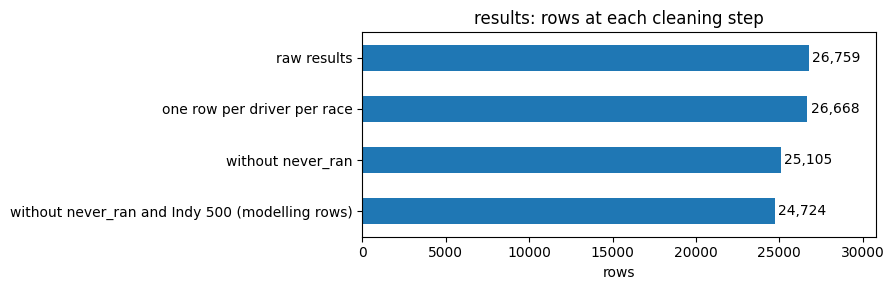

In [488]:
# rows of results at each step, down to the rows of the modelling table
post_model = results_unique[~results_unique.never_ran & ~results_unique.is_indy500]

post_steps = pd.Series({
    'raw results': len(raw_before['results']),
    'one row per driver per race': len(results_unique),
    'without never_ran': int((~results_unique.never_ran).sum()),
    'without never_ran and Indy 500 (modelling rows)': len(post_model),
})
display(post_steps.to_frame('rows').assign(removed=lambda d: -d.rows.diff().fillna(0).astype(int)))

ax = post_steps[::-1].plot.barh(figsize=(9, 3))
for i, v in enumerate(post_steps[::-1]):
    ax.text(v + 200, i, f'{v:,}', va='center')
ax.set_xlim(0, post_steps.max() * 1.15)
plt.xlabel('rows')
plt.title('results: rows at each cleaning step')
plt.tight_layout()
plt.show()

,missing seen by pandas (raw),\N in the raw file,missing after cleaning
number,0,6,6
position,0,10953,10872
rank,0,18249,18158
fastestLap,0,18507,18416
fastestLapTime,0,18507,18416
fastestLapSpeed,0,18507,18416
milliseconds,0,19079,18988
time,0,19079,18988


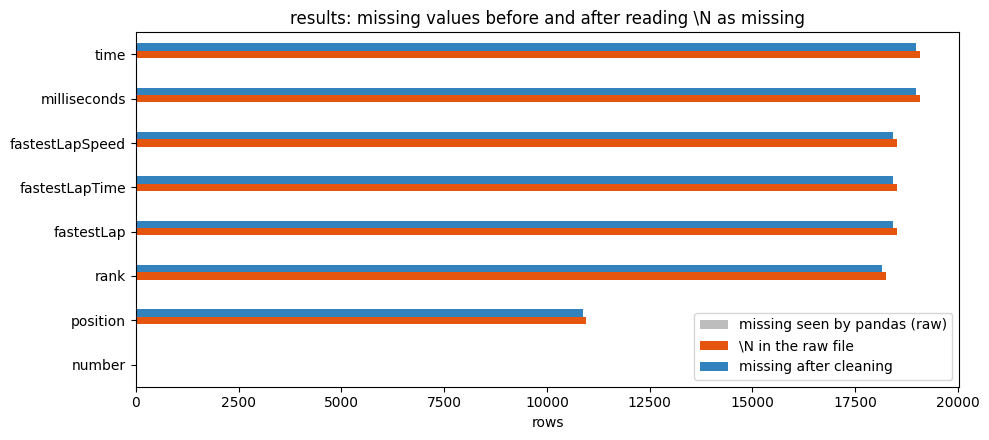

In [489]:
# results: missing values as pandas saw them in the raw file, the real ones (\N), and after cleaning
post_raw = raw_before['results']
post_miss = pd.DataFrame({
    'missing seen by pandas (raw)': post_raw.isna().sum(),
    '\\N in the raw file': (post_raw == '\\N').sum(),
    'missing after cleaning': results_unique[post_raw.columns].isna().sum(),
})
post_miss = post_miss[post_miss.sum(axis=1) > 0].sort_values('\\N in the raw file')
display(post_miss)

post_miss.plot.barh(figsize=(10, 4.5), color=['#bdbdbd', '#e6550d', '#3182bd'])
plt.xlabel('rows')
plt.title('results: missing values before and after reading \\N as missing')
plt.tight_layout()
plt.show()

,text before,text after,retyped,added
table,,,,
results,9,3,"number, position, milliseconds, fastestLap, rank, fastestLapSpeed","fastestLapTime_s, never_ran, pit_lane_start, grid_clean, is_indy500"
qualifying,3,3,,"q1_s, q2_s, q3_s"
seasons,1,1,,
races,14,8,"date, fp1_date, fp2_date, fp3_date, quali_date, sprint_date",
circuits,5,5,,
drivers,8,6,"number, dob",
constructors,4,4,,
status,1,1,,"times_used, group"
driver_standings,1,1,,


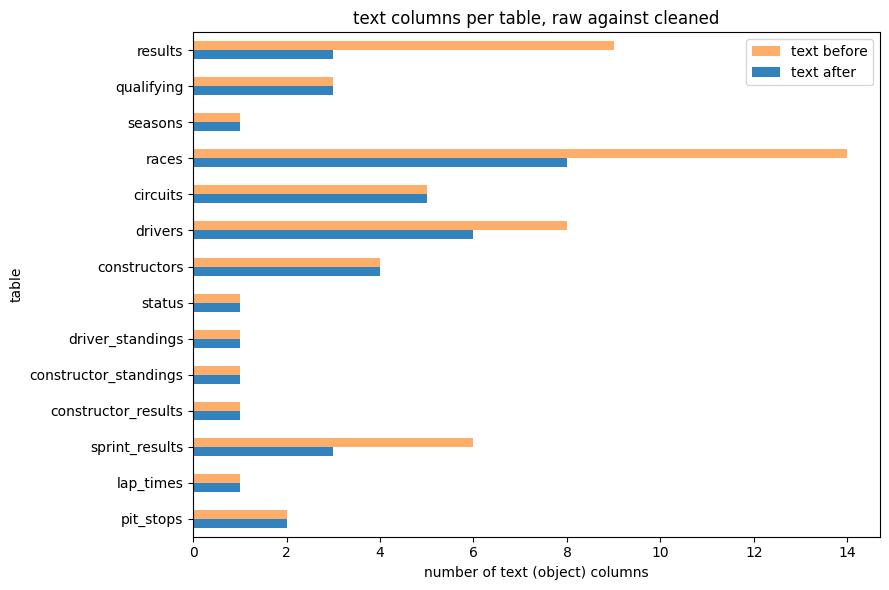

In [490]:
# column types of every table, raw against cleaned (columns added in cleaning are listed separately)
post_clean = {'results': results_unique, 'qualifying': qualifying, 'seasons': seasons, 'races': races,
              'circuits': circuits, 'drivers': drivers, 'constructors': constructors, 'status': status,
              'driver_standings': driver_standings, 'constructor_standings': constructor_standings,
              'constructor_results': constructor_results, 'sprint_results': sp,
              'lap_times': lap_times, 'pit_stops': ps}


def kind(dtype):
    if pd.api.types.is_datetime64_any_dtype(dtype):
        return 'date'
    if pd.api.types.is_numeric_dtype(dtype) or pd.api.types.is_bool_dtype(dtype):
        return 'number'
    return 'text'


post_rows = []
for name, clean in post_clean.items():
    raw = raw_before[name]
    before = raw.dtypes.map(kind)
    after = clean[raw.columns].dtypes.map(kind)
    post_rows.append({'table': name,
                      'text before': int((before == 'text').sum()),
                      'text after': int((after == 'text').sum()),
                      'retyped': ', '.join(c for c in raw.columns if before[c] != after[c]),
                      'added': ', '.join(c for c in clean.columns if c not in raw.columns and c != 'year')})
post_types = pd.DataFrame(post_rows).set_index('table')
with pd.option_context('display.max_colwidth', None):
    display(post_types)

post_types[['text before', 'text after']].plot.barh(figsize=(9, 6), color=['#fdae6b', '#3182bd'])
plt.gca().invert_yaxis()
plt.xlabel('number of text (object) columns')
plt.title('text columns per table, raw against cleaned')
plt.tight_layout()
plt.show()

raw results                    12.69
one row per driver per race    12.73
modelling rows                 13.59


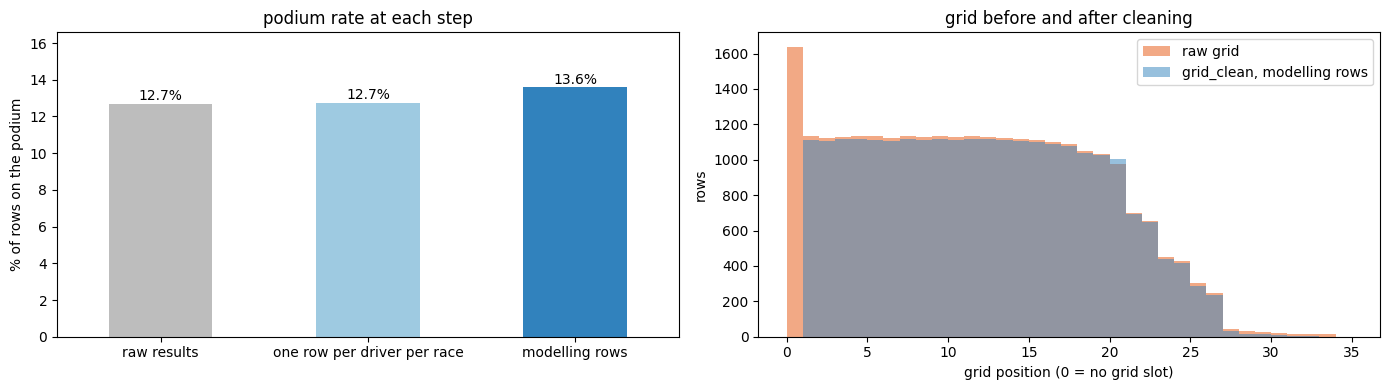

rows with grid 0, raw: 1638 | modelling rows with grid_clean 0: 0


In [491]:
# the target and the grid, raw against the modelling rows
post_rate = pd.Series({
    'raw results': (raw_before['results'].positionOrder <= 3).mean() * 100,
    'one row per driver per race': (results_unique.positionOrder <= 3).mean() * 100,
    'modelling rows': (post_model.positionOrder <= 3).mean() * 100,
})
print(post_rate.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

post_rate.plot.bar(ax=axes[0], rot=0, color=['#bdbdbd', '#9ecae1', '#3182bd'])
for i, v in enumerate(post_rate):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center')
axes[0].set_ylim(0, post_rate.max() + 3)
axes[0].set_ylabel('% of rows on the podium')
axes[0].set_title('podium rate at each step')

bins = range(0, int(raw_before['results'].grid.max()) + 2)
axes[1].hist(raw_before['results'].grid, bins=bins, alpha=0.5, label='raw grid', color='#e6550d')
axes[1].hist(post_model.grid_clean, bins=bins, alpha=0.5, label='grid_clean, modelling rows', color='#3182bd')
axes[1].set_xlabel('grid position (0 = no grid slot)')
axes[1].set_ylabel('rows')
axes[1].set_title('grid before and after cleaning')
axes[1].legend()

plt.tight_layout()
plt.show()

print('rows with grid 0, raw:', int((raw_before['results'].grid == 0).sum()),
      '| modelling rows with grid_clean 0:', int((post_model.grid_clean == 0).sum()))

### What the cleaning changed

**Rows.** `results` goes from 26,759 rows to 26,668 after keeping one row per driver per race (91 shared-drive rows removed), and to 24,724 modelling rows once the 1,563 `never_ran` rows and the 381 Indianapolis 500 rows are left out. Those two groups are only flagged so far, and they are removed in section 5, after the history features.

**Missing values.** In the raw file pandas saw no missing value in `results` (the grey bars are all 0), while 122,887 cells held `\N`. After cleaning, each column's missing count is its `\N` count, lower by at most 91 because of the duplicate rows removed. All of these columns except `number` describe the race outcome, so they are not features (section 2, results).

**Types.** Text columns fall from 9 to 3 in `results`, 14 to 8 in `races`, 8 to 6 in `drivers` and 6 to 3 in `sprint_results`. The columns that were text only because of `\N` are numbers again, the six race dates and `dob` are dates, and the duration strings have numeric versions beside them (`fastestLapTime_s`, `q1_s` to `q3_s`, `duration_s`). `qualifying` and `pit_stops` keep the same number of text columns because the converted values are added next to the original text. The text columns left are names, codes, URLs and the time columns kept as text on purpose (section 2).

**Target.** The podium rate rises from 12.7% in the raw results to 13.6% in the modelling rows. None of the 1,563 `never_ran` rows is a podium and the Indianapolis 500 rows hold 36, so 1,944 rows are removed but only 36 podiums.

**Grid.** The raw results have 1,638 rows with `grid` = 0 and the modelling rows have none. The `never_ran` rows are left out, and the 72 pit-lane starters have `grid_clean` set to the back of the field (the highest grid slot in that race + 1), which shows as the small extra bar around grid 20.

# 5. Modelling table

The cleaned tables are joined onto the deduplicated results. The flagged rows are removed after the history features are built.

In [492]:
base = results_unique.copy()
print('start:', len(base))

m = (base
     .merge(races[['raceId', 'year', 'round', 'circuitId', 'date', 'name']], on='raceId', how='left')
     .merge(circuits[['circuitId', 'country', 'alt']], on='circuitId', how='left')
     .merge(drivers[['driverId', 'surname', 'dob', 'nationality']].rename(columns={'nationality': 'driver_nat'}), on='driverId', how='left')
     .merge(constructors[['constructorId', 'name', 'nationality']].rename(columns={'name': 'team', 'nationality': 'team_nat'}), on='constructorId', how='left')
     .merge(status[['statusId', 'status']], on='statusId', how='left'))

print('after merges:', len(m), '| row count unchanged:', len(m) == len(base))
print('duplicate (raceId, driverId):', m.duplicated(['raceId', 'driverId']).sum())
print('missing after merge:', m[['year', 'country', 'surname', 'team', 'status']].isna().sum().to_dict())
print(m.shape)

start: 26668
after merges: 26668 | row count unchanged: True
duplicate (raceId, driverId): 0
missing after merge: {'year': 0, 'country': 0, 'surname': 0, 'team': 0, 'status': 0}
(26668, 36)


# 6. Data-engineering questions

The three data-engineering questions of the brief. Each one starts from the cleaned tables built above (sections 2 to 5): `results_unique` with its flags (`never_ran`, `pit_lane_start`, `grid_clean`, `is_indy500`), `races`, `circuits`, `drivers`, `constructors`, `status` (with its `group` column) and `qualifying`. No question loads or cleans the data again, and no question changes these tables.

Run the notebook from the top: some settings (for example `K_VALUES`) are defined again by each question.

## Q1: Which circuits turn a front-row start into a podium, and did that change after 2014?

**The question has three parts:**
1. **Qualifying vs grid:** which definition of a front-row start to use.
2. **Which circuits convert best:** the share of front-row starters who finish on the podium, per circuit.
3. **Did the ranking change after 2014**, when the turbo-hybrid era began.

Each step is written as *what we do* → *why* → *the result*. Where an earlier section of this notebook already established something, Q1 points to it and only states what it means for this question.

### 1. Setup

#### 1.1 Analysis choices

Every choice is set **once** here, so it can be changed in one place. Each one is explained in the section where it is first used.

| Setting | Value | What it controls | Explained in |
|---|---|---|---|
| `PRE_START` | 1980 | First season of the earlier era | 3.2 |
| `HYBRID_START` | 2014 | First season of the later era | 3.2 |
| `QUALI_START` | 2003 (`QYEAR` from the results section) | First season used for the qualifying-vs-grid comparison | 3.2 |
| `K_VALUES` / `K_MAIN` | 5, 10, 20 / 10 | Strength of the Bayesian average | 3.3 |
| `MIN_N` / `MIN_N_VALUES` | 10 / 6, 10, 14 | Minimum front-row starts for a circuit to be ranked | 3.3 |
| `TOP` | 5 | Size of the "top group" | 3.3 |
| `N_RESAMPLES` | 2,000 | Number of simulations in the luck checks | 6.3 |

In [493]:
PRE_START = 1980        # earlier era starts here: front row = 2 cars, grid data complete
HYBRID_START = 2014     # first season of the turbo-hybrid era
LAST_SEASON = 2024      # the brief covers seasons up to 2024
K_VALUES = [5, 10, 20]  # imaginary average starts added by the Bayesian average
K_MAIN = 10             # main value of k
MIN_N = 10              # minimum front-row starts per circuit per era to be ranked
MIN_N_VALUES = [6, 10, 14]
TOP = 5                 # size of the "top group"
N_RESAMPLES = 2000      # simulations in the luck checks
SEED = 42

In [494]:
# labels, colours and output folder
ERA_OLD = f"1950–{PRE_START - 1} (not used)"
ERA_PRE, ERA_POST = f"{PRE_START}–{HYBRID_START - 1}", f"{HYBRID_START}–{LAST_SEASON}"
ERAS = [ERA_PRE, ERA_POST]
ERA_COLORS = {ERA_PRE: "#4C72B0", ERA_POST: "#DD8452"}
GREY = "#8C8C8C"
FIG_DIR = "figures_q1"
os.makedirs(FIG_DIR, exist_ok=True)

#### 1.2 Libraries and helper functions

The setup in section 0 does not import `scipy` (rank correlations) or `Markdown` (written results), so the first helper cell imports them. These helpers are shared by Q1, Q2 and Q3. The two scoring functions (`wilson` and `bayes_avg`) are explained in 3.3.

In [495]:
from scipy import stats                          # not imported in section 0
from IPython.display import display, Markdown

def table(df, pct=(), pct1=(), dec1=(), dec2=(), caption=None):
    """Show a DataFrame as a formatted table (pct: whole percent, pct1: one decimal)."""
    fmt = {c: "{:.0%}" for c in pct}
    fmt.update({c: "{:.1%}" for c in pct1})
    fmt.update({c: "{:.1f}" for c in dec1})
    fmt.update({c: "{:.2f}" for c in dec2})
    s = df.style.format(fmt, na_rep="–").hide(axis="index")
    if caption:
        s = s.set_caption(caption).set_table_styles([{"selector": "caption", "props": [
            ("caption-side", "top"), ("font-weight", "bold"), ("text-align", "left"), ("font-size", "110%")]}])
    display(s)

def md(text):
    """Show a result as formatted text."""
    display(Markdown(text))

def savefig(name):
    """Save the current figure (into this question's FIG_DIR) so it can be reused in the report."""
    plt.savefig(os.path.join(FIG_DIR, f"{name}.png"), dpi=150, bbox_inches="tight")

In [496]:
def wilson(successes, n, z=1.96):
    """95% Wilson range for a rate of `successes` out of `n` (stays inside 0–100% for small samples)."""
    k, n = np.asarray(successes, dtype=float), np.asarray(n, dtype=float)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return np.minimum(centre - half, p), np.maximum(centre + half, p)   # min/max only removes rounding errors

def bayes_avg(events, starts, prior_rate, k):
    """Bayesian average: k imaginary starts at `prior_rate`, plus the real results."""
    return (events + k * prior_rate) / (starts + k)

def pct_range(lo, hi, digits=0):
    """Format two arrays of rates as '57% – 90%' strings."""
    return [f"{a:.{digits}%} – {b:.{digits}%}" for a, b in zip(lo, hi)]

In [497]:
SHORT_NAMES = {"Circuit of the Americas": "Americas (COTA)"}

def short(name):
    """Shorter circuit names for figures."""
    if name in SHORT_NAMES:
        return SHORT_NAMES[name]
    for w in ["Autodromo Nazionale di ", "Autodromo Internazionale ", "Autódromo ", "Autodromo ",
              "Circuit de ", "Circuito de ", "Circuit ", " Circuit", " International", " Internacional"]:
        name = name.replace(w, "")
    return name.strip()

def pct_axis(axis):
    """Show an axis in percent."""
    axis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

### 2. Rows used

Q1 starts from the **modelling rows** (notebook section 5): `results_unique` without the `never_ran` and `is_indy500` rows (cleaning summary, notebook section 3, *Rows we remove or mark*). What the earlier sections mean for Q1:

- **Shared drives** (results, *Keep rule for duplicated pairs*): the last duplicated driver-race is from 1978, before Q1's windows, so Q1 is not affected.
- **`grid` = 0** (results, *Decision: `grid` = 0*): neither the drivers who never ran nor the 72 pit-lane starters can hold grid slot 1 or 2, so the front-row starts are the same with or without them. For slots 1–2, `grid` and `grid_clean` are identical, so Q1 reads `grid`.
- **Indianapolis 500** (races, *Indianapolis 500: decision*): 1950–1960 only, outside Q1's windows.
- **Circuits** (circuits, *usage over time*): a circuit is identified by `circuitId`, never by race name. So the Red Bull Ring's two races in 2020 and in 2021 both count for that circuit, and a track keeps one record under all its Grand Prix names (the Nürburgring has four).
- **Qualifying** (qualifying, *Key checks*): one row per driver per race, so joining it adds no rows.

**Grain:** one driver entering one race. **Podium:** `positionOrder ≤ 3`, the notebook's target (top of the notebook).

In [498]:
starters = results_unique[~results_unique.never_ran & ~results_unique.is_indy500]
q1_base = (starters[["raceId", "driverId", "grid", "positionOrder"]]
           .merge(races[["raceId", "year", "circuitId"]], on="raceId", how="left", validate="m:1")
           .merge(circuits[["circuitId", "name"]].rename(columns={"name": "circuit_name"}),
                  on="circuitId", how="left", validate="m:1")
           .merge(qualifying[["raceId", "driverId", "position"]].rename(columns={"position": "quali_pos"}),
                  on=["raceId", "driverId"], how="left", validate="1:1"))
q1_base = q1_base[q1_base.year <= LAST_SEASON].copy()
assert q1_base[["year", "circuit_name"]].notna().all().all()

In [499]:
q1_base["podium"] = (q1_base.positionOrder <= 3).astype(int)
q1_base["era"] = np.select([q1_base.year < PRE_START, q1_base.year < HYBRID_START], [ERA_OLD, ERA_PRE], default=ERA_POST)

fr = q1_base[q1_base.grid.isin([1, 2])].copy()   # one row per front-row starter (definition in 3.1)

In [500]:
overview = (q1_base.groupby("era").agg(seasons=("year", "nunique"), races=("raceId", "nunique"),
                                    circuits=("circuitId", "nunique"), entries=("driverId", "size"))
                .join(fr.groupby("era").agg(**{"front-row starts": ("podium", "size"),
                                               "front-row podium rate": ("podium", "mean")}))
                .reindex([ERA_OLD] + ERAS).reset_index())
table(overview, pct=["front-row podium rate"], caption="The analysis table by era")

era,seasons,races,circuits,entries,front-row starts,front-row podium rate
1950–1979 (not used),30,317,43,6841,628,51%
1980–2013,34,569,48,13264,1138,59%
2014–2024,11,228,32,4619,454,76%


### 3. Definitions, windows and scoring method

#### 3.1 What counts as a front-row start?

**Front row = grid slot 1 or 2** (`results.grid`), the slot the car actually started from.

There are two candidate numbers: the **qualifying position** (where the driver set their time) and the **grid slot** (where the car started, after penalties, pit-lane starts and, in 2021–22, sprint results). We use the grid slot because the question is about starting on the front row. Part A shows this choice matters for the cases where the two differ.

- **Grain:** one front-row starter in one race (2 rows per race).
- **Conversion rate** = podiums ÷ front-row starts.

#### 3.2 Why these time windows?

**Earlier era = 1980–2013.**
- **Both front-row slots are recorded in (almost) every race** (table below), so the earlier era is not limited by the `qualifying` table.
- **But before the mid-1970s a front row often held 3 or 4 cars**, so "grid 1–2" would not mean "the front row". We start in 1980 to leave a safe margin. This comes from F1 history, not from the data: Ergast does not store how many cars stood in each row.

**Later era = 2014–2024**, the turbo-hybrid era, up to the last season the brief covers.

**Qualifying-vs-grid comparison (Part A) = from 2003.** The results section already measured qualifying coverage per season (the qualifying join under *What `grid` = 0 means*): complete in 1994–1995, only 6–59% of entries in 1996–2002, and complete again from 2003, which set `QYEAR = 2003`. Q1 uses the same year, so both definitions are compared on exactly the same races.

**Note:** the eras are unequal (34 vs 11 seasons). Circuits in the earlier era have more data, so their rates are more precise (narrower error bars).

In [501]:
race_year = q1_base.groupby("raceId").year.first()

# how many cars hold grid slot 1 and slot 2 in each race (should be exactly one each)
slots = (fr.groupby(["raceId", "grid"]).size().unstack(fill_value=0)
           .reindex(index=race_year.index, columns=[1, 2], fill_value=0))
complete = (slots[1] == 1) & (slots[2] == 1)
duplicated_slot = (slots[1] > 1) | (slots[2] > 1)

In [502]:
QUALI_START = QYEAR   # first season with complete qualifying records, set in the results section

In [503]:
windows = [(ERA_PRE, PRE_START, HYBRID_START - 1), (ERA_POST, HYBRID_START, LAST_SEASON),
           (f"Part A: {QUALI_START}–{LAST_SEASON}", QUALI_START, LAST_SEASON)]
cov_rows = []
for name, a, b in windows:
    yrs = race_year.between(a, b)
    cov_rows.append({"window": name, "races": int(yrs.sum()),
                     "races with both front-row slots recorded": complete[yrs].mean(),
                     "races with a front-row slot held twice": int(duplicated_slot[yrs].sum())})
table(pd.DataFrame(cov_rows), pct=["races with both front-row slots recorded"],
      caption="Front-row records inside the analysis windows")

window,races,races with both front-row slots recorded,races with a front-row slot held twice
1980–2013,569,100%,0
2014–2024,228,99%,0
Part A: 2003–2024,428,100%,0


**Reading:** both front-row slots are recorded in (almost) every race of both eras and no slot is held twice, so the 1980 start is not limited by the data.

#### 3.3 How circuits are scored

**The problem:** each race has only two front-row starters. A circuit that hosted one race, where both front-row cars finished on the podium, has a rate of 2/2 = 100%. That is luck, not a property of the track. Any ranking has to deal with circuits that have very few races.

We report **three numbers per circuit**, each with a different job:

**1. Raw rate** = podiums ÷ front-row starts. This is what actually happened. It is shown, but **not used for ranking**, because small circuits jump to the top or bottom by luck.

**2. Wilson range (95%)** = the range the circuit's *true* rate probably lies in. **Used for error bars only.**
- *Why Wilson:* it is the standard range for "X out of N" data. The simpler textbook formula (rate ± 1.96 × standard error) breaks down for small samples and rates near 100%: for 2/2 it claims 100%–100% (total certainty), and for 8/10 its upper end goes above 100%. Wilson stays inside 0–100% and stays honestly wide when there are few races.

**3. Bayesian average** = the number **used for ranking**.

> adjusted rate = (podiums + k × era average) ÷ (front-row starts + k)

- *In plain words:* every circuit starts with **k imaginary front-row starts at the era's average rate**, and then its real results are added. A circuit with many races keeps its own rate, because its real data outweighs the imaginary starts. A circuit with few races is pulled towards the average, because its data cannot yet show it is special.
- *Why this metric:* it gives a **best estimate of each circuit's real rate** ("Monza: about 76%"), which a reader can interpret directly. Ranking by the low end of the Wilson range instead would answer a different question ("which circuit are we *most sure* is good?") and always favours circuits that hosted many races. The same approach is used by IMDb's Top 250 list, so a film with ten perfect votes cannot beat one with a million votes.
- *Why the era's own average:* front-row conversion is different in each era (for example, cars broke down far more often in the 1980s). Pulling each circuit towards **its own era's** average means that a general change between eras does not move circuits around; only circuit-specific differences do.

**Why three values of k (5, 10, 20):** k is a judgment call, so we show the result for all three instead of hiding the choice. A circuit typically has about 20 front-row starts in the later era.
- k = 5: a light pull; the circuit's own data dominates.
- **k = 10 (main value):** the imaginary starts equal about half a typical circuit's data.
- k = 20: a heavy pull; as much imaginary data as real data.

If a circuit ranks highly under all three, the conclusion does not depend on our choice of k.

**Minimum sample (`MIN_N` = 10 front-row starts, about 5 races):** the Bayesian average already handles small samples, so this cutoff mainly keeps one-off circuits out of the tables. It is also a judgment call, so 5.4 repeats the ranking with 6 and 14.

**Top group instead of exact ranks:** the Wilson ranges of neighbouring circuits overlap heavily, so "1st vs 3rd" is not a meaningful difference. We report a **top group: the circuits in the top 5 under every value of k.**

The table below applies all three numbers to example records, using an era average of 70%.

In [504]:
ex = pd.DataFrame({"example": ["one-off circuit", "short-lived circuit", "long-serving circuit", "very long-serving circuit"],
                   "podiums": [2, 8, 17, 50], "front-row starts": [2, 10, 22, 68]})
ex["raw rate"] = ex.podiums / ex["front-row starts"]

se = np.sqrt(ex["raw rate"] * (1 - ex["raw rate"]) / ex["front-row starts"])
ex["textbook range"] = pct_range(ex["raw rate"] - 1.96 * se, ex["raw rate"] + 1.96 * se)
ex["Wilson range"] = pct_range(*wilson(ex.podiums, ex["front-row starts"]))

for k in K_VALUES:
    ex[f"adjusted (k={k})"] = bayes_avg(ex.podiums, ex["front-row starts"], 0.70, k)

In [505]:
table(ex, pct=["raw rate"] + [f"adjusted (k={k})" for k in K_VALUES],
      caption="How the three numbers behave (era average = 70%)")

example,podiums,front-row starts,raw rate,textbook range,Wilson range,adjusted (k=5),adjusted (k=10),adjusted (k=20)
one-off circuit,2,2,100%,100% – 100%,34% – 100%,79%,75%,73%
short-lived circuit,8,10,80%,55% – 105%,49% – 94%,77%,75%,73%
long-serving circuit,17,22,77%,60% – 95%,57% – 90%,76%,75%,74%
very long-serving circuit,50,68,74%,63% – 84%,62% – 83%,73%,73%,73%


**Reading:** the one-off circuit's 100% is pulled almost all the way back to the 70% average, because two races prove very little. The long-serving circuits barely move. The textbook range claims certainty for 2/2 and goes above 100% for 8/10; Wilson does neither.

#### 3.4 The scoring functions

`circuit_table` builds the per-circuit table used in Parts A, B and C. `top_group` picks the circuits that are in the top 5 under every k.

In [506]:
def circuit_table(starts, min_n=MIN_N, k_values=K_VALUES):
    """One row per circuit and era: raw rate, Wilson range and Bayesian averages.

    `starts` has one row per front-row start, with columns era, circuitId, circuit_name, raceId, podium.
    The era average is computed over ALL front-row starts of the era, before the minimum-sample filter.
    """
    era_avg = starts.groupby("era")["podium"].mean()
    t = (starts.groupby(["era", "circuitId"])
               .agg(circuit=("circuit_name", "first"), races=("raceId", "nunique"),
                    starts=("podium", "size"), podiums=("podium", "sum"))
               .reset_index())
    t["raw rate"] = t.podiums / t.starts
    t["ci_lo"], t["ci_hi"] = wilson(t.podiums, t.starts)
    t["era average"] = t.era.map(era_avg)
    for k in k_values:
        t[f"adj_k{k}"] = bayes_avg(t.podiums, t.starts, t["era average"], k)
    t = t[t.starts >= min_n].copy()
    for k in k_values:
        t[f"rank_k{k}"] = t.groupby("era")[f"adj_k{k}"].rank(ascending=False, method="min").astype(int)
    sort_k = K_MAIN if K_MAIN in k_values else k_values[0]
    return t.sort_values(["era", f"rank_k{sort_k}"]).reset_index(drop=True)

In [507]:
RANK_COLS = [f"rank_k{k}" for k in K_VALUES]

def top_group(t, top=TOP):
    """Circuits that are in the top `top` under every value of k."""
    return t[(t[RANK_COLS] <= top).all(axis=1)]

### 4. Part A: Qualifying vs grid

**What we do:** for every front-row case, compare where the driver **qualified** with where they **started**. There are three possible cases:
1. qualified on the front row **and** started there (the usual case);
2. qualified on the front row but **started further back**, for example after a grid penalty for an engine or gearbox change, or a pit-lane start;
3. **started on the front row without qualifying there**, for example because a car ahead was penalised, or because a sprint race set the grid (2021–22).

**Why:** the question asks for this comparison, and it tells us which definition to use for Parts B and C.

**Window:** only seasons with complete qualifying records (3.2), so both definitions are compared on exactly the same races.

#### 4.1 How often do the two differ, and does it matter?

In [508]:
ERA_Q_PRE = f"{QUALI_START}–{HYBRID_START - 1}"
qa = q1_base[q1_base.year >= QUALI_START].copy()
qa["era"] = np.where(qa.year >= HYBRID_START, ERA_POST, ERA_Q_PRE)
qa["fr_quali"] = qa.quali_pos.isin([1, 2])
qa["fr_grid"] = qa.grid.isin([1, 2])

In [509]:
CASES = ["Qualified and started on the front row",
         "Started on the front row without qualifying there",
         "Qualified on the front row, started further back"]
qa["case"] = np.select([qa.fr_quali & qa.fr_grid, ~qa.fr_quali & qa.fr_grid, qa.fr_quali & ~qa.fr_grid],
                       CASES, default="")

cases = (qa[qa.case != ""].groupby("case").agg(starts=("podium", "size"), podiums=("podium", "sum"))
           .reindex(CASES).reset_index())
cases["podium rate"] = cases.podiums / cases.starts
cases["ci_lo"], cases["ci_hi"] = wilson(cases.podiums, cases.starts)
cases["95% Wilson range"] = pct_range(cases.ci_lo, cases.ci_hi)

In [510]:
table(cases.drop(columns=["ci_lo", "ci_hi"]), pct=["podium rate"],
      caption=f"Podium rate by front-row case, {QUALI_START}–{LAST_SEASON}")

case,starts,podiums,podium rate,95% Wilson range
Qualified and started on the front row,818,594,73%,69% – 76%
Started on the front row without qualifying there,36,23,64%,48% – 78%
"Qualified on the front row, started further back",36,11,31%,18% – 47%


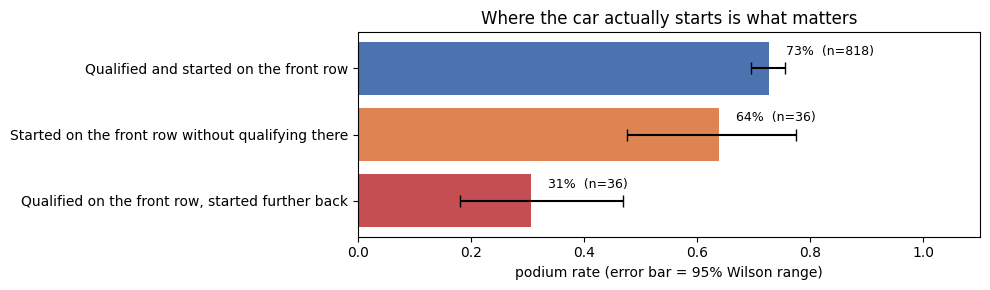

In [511]:
fig, ax = plt.subplots(figsize=(10, 3))
c = cases.iloc[::-1]
ax.barh(c.case, c["podium rate"], color=["#C44E52", "#DD8452", "#4C72B0"],
        xerr=[c["podium rate"] - c.ci_lo, c.ci_hi - c["podium rate"]], capsize=4)
for i, (rate, n) in enumerate(zip(c["podium rate"], c.starts)):
    ax.text(rate + 0.03, i + 0.25, f"{rate:.0%}  (n={n})", va="center", fontsize=9)
ax.set(xlim=(0, 1.1), xlabel="podium rate (error bar = 95% Wilson range)",
       title="Where the car actually starts is what matters")
plt.tight_layout(); savefig("q1_02_quali_vs_grid_cases"); plt.show()

In [512]:
overall = pd.DataFrame({"definition of front row": ["qualifying position 1–2", "grid slot 1–2"],
                        "front-row starts": [int(qa.fr_quali.sum()), int(qa.fr_grid.sum())],
                        "podiums": [int(qa.loc[qa.fr_quali, "podium"].sum()), int(qa.loc[qa.fr_grid, "podium"].sum())]})
overall["podium rate"] = overall.podiums / overall["front-row starts"]
overall["95% Wilson range"] = pct_range(*wilson(overall.podiums, overall["front-row starts"]))
table(overall, pct=["podium rate"], caption="Overall conversion under each definition")

definition of front row,front-row starts,podiums,podium rate,95% Wilson range
qualifying position 1–2,854,605,71%,68% – 74%
grid slot 1–2,854,617,72%,69% – 75%


In [513]:
kept, pushed, promoted = (cases.set_index("case").loc[x] for x in [CASES[0], CASES[2], CASES[1]])
share_same = kept.starts / qa.fr_grid.sum()
md(f"""**Reading:**
- The two definitions agree in **{share_same:.0%}** of front-row starts, so the overall rates are close
  ({overall['podium rate'].iloc[0]:.1%} by qualifying vs {overall['podium rate'].iloc[1]:.1%} by grid).
- When they disagree, it matters a lot. Drivers who qualified on the front row but **started further back**
  reached the podium only **{pushed['podium rate']:.0%}** of the time (n = {pushed.starts}),
  compared with **{kept['podium rate']:.0%}** for drivers who kept their slot.
- Drivers **promoted** onto the front row converted **{promoted['podium rate']:.0%}** (n = {promoted.starts}).
- **Decision:** use the **grid slot**. Counting qualifying position would credit penalised drivers with a front-row start they never had.""")

**Reading:**
- The two definitions agree in **96%** of front-row starts, so the overall rates are close
  (70.8% by qualifying vs 72.2% by grid).
- When they disagree, it matters a lot. Drivers who qualified on the front row but **started further back**
  reached the podium only **31%** of the time (n = 36),
  compared with **73%** for drivers who kept their slot.
- Drivers **promoted** onto the front row converted **64%** (n = 36).
- **Decision:** use the **grid slot**. Counting qualifying position would credit penalised drivers with a front-row start they never had.

#### 4.2 Does the definition change which circuits rank highest?

**What we do:** score every circuit twice, once with each definition, and compare the two rankings within each era. The scoring is the same Bayesian average (k = 10) used in Part B.

**How to read ρ (Spearman rank correlation):** 1 means both definitions put the circuits in exactly the same order; 0 means the two orders are unrelated.

In [514]:
def definition_agreement(e):
    """Compare circuit rankings under the grid and qualifying definitions within one era."""
    d = qa[qa.era == e]
    tg = circuit_table(d[d.fr_grid]).set_index("circuitId")
    tq = circuit_table(d[d.fr_quali]).set_index("circuitId")
    j = tg[[f"adj_k{K_MAIN}"]].join(tq[[f"adj_k{K_MAIN}"]], lsuffix="_grid", rsuffix="_quali", how="inner")
    top_g = set(tg.nsmallest(TOP, f"rank_k{K_MAIN}").index)
    top_q = set(tq.nsmallest(TOP, f"rank_k{K_MAIN}").index)
    return {"era": e, "circuits ranked under both": len(j),
            "ranking agreement (Spearman ρ)": stats.spearmanr(j.iloc[:, 0], j.iloc[:, 1])[0],
            "average gap in adjusted rate": (j.iloc[:, 0] - j.iloc[:, 1]).abs().mean(),
            f"circuits shared by both top {TOP}s": f"{len(top_g & top_q)} of {TOP}"}

In [515]:
agree = pd.DataFrame([definition_agreement(e) for e in [ERA_Q_PRE, ERA_POST]])
table(agree, pct=["average gap in adjusted rate"], dec2=["ranking agreement (Spearman ρ)"],
      caption=f"Grid vs qualifying: circuit rankings (adjusted rate, k = {K_MAIN})")

era,circuits ranked under both,ranking agreement (Spearman ρ),average gap in adjusted rate,circuits shared by both top 5s
2003–2013,21,0.91,1%,4 of 5
2014–2024,19,0.88,2%,5 of 5


**Reading:** values of ρ close to 1 and small gaps mean the circuit ranking barely depends on the definition. The definition matters for individual penalised drivers (4.1), not for which circuits come out on top.

### 5. Part B: Which circuits convert a front-row start most often?

**What we do:** score every circuit in each era with the method from 3.3, using the grid definition, then check that the result holds for all values of k and for different minimum samples.

#### 5.1 The ranking

In [516]:
fr_main = fr[fr.era.isin(ERAS)].copy()   # front-row starts inside the two eras
ct = circuit_table(fr_main)              # circuits with at least MIN_N front-row starts

def top10_table(e):
    """Top 10 circuits of one era, formatted for reading."""
    t = ct[ct.era == e]
    head = t.head(10)
    table(pd.DataFrame({
        "rank": head[f"rank_k{K_MAIN}"], "circuit": head.circuit, "races": head.races,
        "front-row starts": head.starts, "podiums": head.podiums, "raw rate": head["raw rate"],
        "95% Wilson range": pct_range(head.ci_lo, head.ci_hi),
        f"adjusted rate (k={K_MAIN})": head[f"adj_k{K_MAIN}"],
    }), pct=["raw rate", f"adjusted rate (k={K_MAIN})"],
        caption=f"{e}: top 10 of {len(t)} ranked circuits (era average {t['era average'].iloc[0]:.0%})")

In [517]:
top10_table(ERA_PRE)

rank,circuit,races,front-row starts,podiums,raw rate,95% Wilson range,adjusted rate (k=10)
1,Circuit de Nevers Magny-Cours,18,36,29,81%,65% – 90%,76%
2,Istanbul Park,7,14,11,79%,52% – 92%,71%
3,Suzuka Circuit,25,50,35,70%,56% – 81%,68%
4,Sepang International Circuit,15,30,21,70%,52% – 83%,67%
5,Hungaroring,28,56,38,68%,55% – 79%,67%
6,Autódromo Hermanos Rodríguez,7,14,10,71%,45% – 88%,66%
7,Indianapolis Motor Speedway,8,16,11,69%,44% – 86%,65%
8,Circuit de Barcelona-Catalunya,23,46,30,65%,51% – 77%,64%
9,Bahrain International Circuit,9,18,12,67%,44% – 84%,64%
9,Circuit Paul Ricard,9,18,12,67%,44% – 84%,64%


In [518]:
top10_table(ERA_POST)

rank,circuit,races,front-row starts,podiums,raw rate,95% Wilson range,adjusted rate (k=10)
1,Suzuka Circuit,9,18,16,89%,67% – 97%,84%
2,Yas Marina Circuit,11,22,19,86%,67% – 95%,83%
3,Circuit de Monaco,10,20,17,85%,64% – 95%,82%
4,Circuit de Barcelona-Catalunya,11,22,18,82%,61% – 93%,80%
4,Circuit de Spa-Francorchamps,11,22,18,82%,61% – 93%,80%
6,Sochi Autodrom,8,16,13,81%,57% – 93%,79%
7,Circuit of the Americas,10,20,16,80%,58% – 92%,79%
8,Autódromo José Carlos Pace,10,19,15,79%,57% – 91%,78%
9,Shanghai International Circuit,7,14,11,79%,52% – 92%,77%
10,Circuit Gilles Villeneuve,9,18,14,78%,55% – 91%,77%


#### 5.2 What the Bayesian average does to each circuit

**What the figure shows:** every circuit in each era (including those below the minimum sample). The hollow dot is the raw rate, the filled dot is the adjusted rate, and the line between them is how far the circuit was pulled towards the era average (dashed). Circuits with few starts (left) are pulled a lot; circuits with many starts (right) barely move.

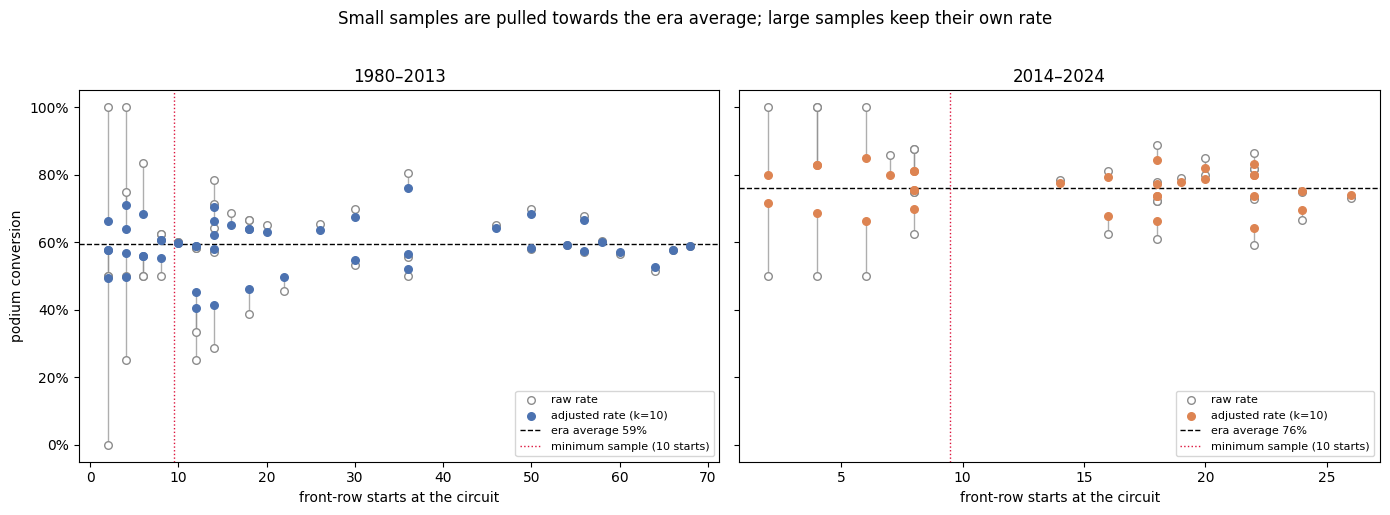

In [519]:
ct_all = circuit_table(fr_main, min_n=1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, e in zip(axes, ERAS):
    t = ct_all[ct_all.era == e]
    avg = t["era average"].iloc[0]
    ax.vlines(t.starts, t["raw rate"], t[f"adj_k{K_MAIN}"], color=GREY, lw=1, alpha=0.7)
    ax.scatter(t.starts, t["raw rate"], facecolor="white", edgecolor=GREY, s=30, zorder=3, label="raw rate")
    ax.scatter(t.starts, t[f"adj_k{K_MAIN}"], color=ERA_COLORS[e], s=30, zorder=4, label=f"adjusted rate (k={K_MAIN})")
    ax.axhline(avg, color="black", ls="--", lw=1, label=f"era average {avg:.0%}")
    ax.axvline(MIN_N - 0.5, color="crimson", ls=":", lw=1, label=f"minimum sample ({MIN_N} starts)")
    ax.set(title=e, xlabel="front-row starts at the circuit", ylim=(-0.05, 1.05))
    pct_axis(ax.yaxis)
    ax.legend(fontsize=8, loc="lower right")
axes[0].set_ylabel("podium conversion")
fig.suptitle("Small samples are pulled towards the era average; large samples keep their own rate", y=1.02)
plt.tight_layout(); savefig("q1_03_shrinkage"); plt.show()

#### 5.3 Top circuits with their uncertainty

**What the figure shows:** the 12 highest-ranked circuits per era. The diamond is the adjusted rate used for ranking. The grey dot and bar are the raw rate and its 95% Wilson range, so you can see how uncertain each circuit's record is. `n` is the number of front-row starts.

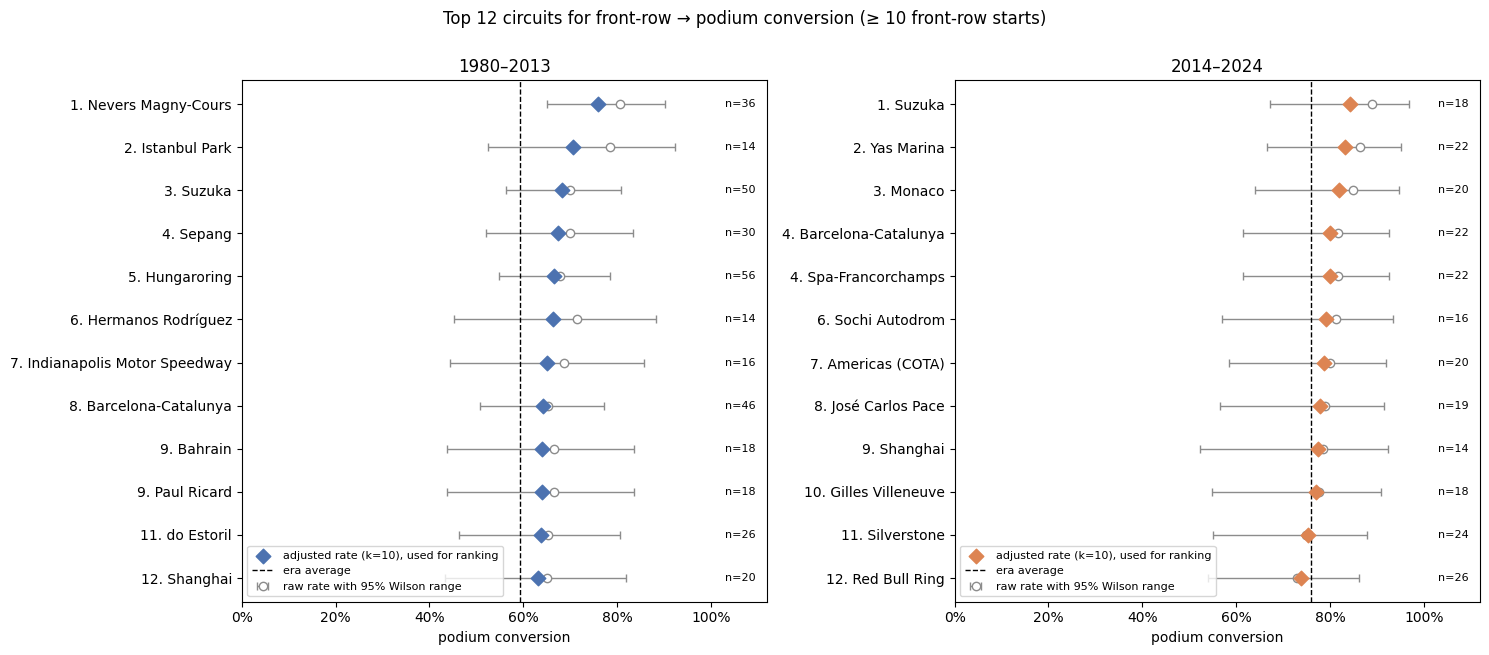

In [520]:
TOP_FIG = 12
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, e in zip(axes, ERAS):
    t = ct[ct.era == e].head(TOP_FIG).iloc[::-1]
    y = np.arange(len(t))
    ax.errorbar(t["raw rate"], y, xerr=[(t["raw rate"] - t.ci_lo).values, (t.ci_hi - t["raw rate"]).values],
                fmt="o", color=GREY, mfc="white", capsize=3, lw=1, label="raw rate with 95% Wilson range")
    ax.scatter(t[f"adj_k{K_MAIN}"], y, marker="D", s=55, color=ERA_COLORS[e], zorder=4,
               label=f"adjusted rate (k={K_MAIN}), used for ranking")
    ax.axvline(t["era average"].iloc[0], color="black", ls="--", lw=1, label="era average")
    ax.set_yticks(y)
    ax.set_yticklabels([f"{r}. {short(n)}" for r, n in zip(t[f"rank_k{K_MAIN}"], t.circuit)])
    for yi, n in zip(y, t.starts):
        ax.text(1.03, yi, f"n={n}", va="center", fontsize=8)
    ax.set(xlim=(0, 1.12), title=e, xlabel="podium conversion")
    pct_axis(ax.xaxis)
    ax.legend(fontsize=8, loc="lower left")
fig.suptitle(f"Top {TOP_FIG} circuits for front-row → podium conversion (≥ {MIN_N} front-row starts)", y=1.0)
plt.tight_layout(); savefig("q1_04_top_circuits"); plt.show()

#### 5.4 Does the ranking depend on our choices?

**Check 1: the value of k.** The heatmap shows each circuit's rank under k = 5, 10 and 20 (circuits in the top 10 under at least one value). Dark cells are the top 5. A row that is dark in all three columns belongs to the **top group**.

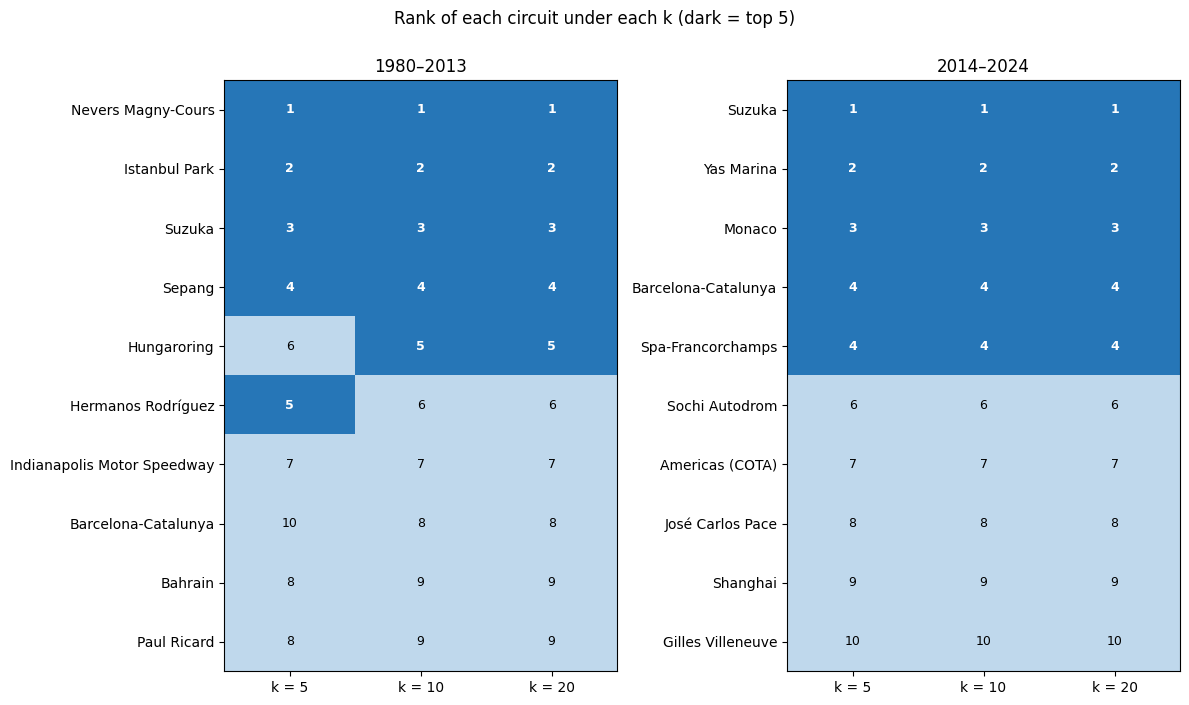

In [521]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7))
for ax, e in zip(axes, ERAS):
    t = ct[ct.era == e]
    t = t[(t[RANK_COLS] <= 10).any(axis=1)]
    m = t[RANK_COLS].values
    ax.imshow(np.where(m <= TOP, 0, 1), cmap="Blues_r", vmin=-0.6, vmax=1.6, aspect="auto")
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            in_top = m[i, j] <= TOP
            ax.text(j, i, m[i, j], ha="center", va="center", fontsize=9,
                    color="white" if in_top else "black", fontweight="bold" if in_top else None)
    ax.set_xticks(range(len(K_VALUES))); ax.set_xticklabels([f"k = {k}" for k in K_VALUES])
    ax.set_yticks(range(len(t))); ax.set_yticklabels([short(n) for n in t.circuit])
    ax.grid(False); ax.set_title(e)
fig.suptitle(f"Rank of each circuit under each k (dark = top {TOP})", y=1.0)
plt.tight_layout(); savefig("q1_05_rank_by_k"); plt.show()

In [522]:
tg_rows = []
for e in ERAS:
    t = ct[ct.era == e]
    robust = top_group(t)
    some = t[(t[RANK_COLS] <= TOP).any(axis=1) & ~t.circuitId.isin(robust.circuitId)]
    tg_rows.append({"era": e, f"top group (top {TOP} under every k)": ", ".join(robust.circuit) or "none",
                    f"top {TOP} under some k only": ", ".join(some.circuit) or "none"})
table(pd.DataFrame(tg_rows), caption="Top group per era")

era,top group (top 5 under every k),top 5 under some k only
1980–2013,"Circuit de Nevers Magny-Cours, Istanbul Park, Suzuka Circuit, Sepang International Circuit","Hungaroring, Autódromo Hermanos Rodríguez"
2014–2024,"Suzuka Circuit, Yas Marina Circuit, Circuit de Monaco, Circuit de Barcelona-Catalunya, Circuit de Spa-Francorchamps",none


**Check 2: the minimum sample.** We rebuild the ranking with a minimum of 6, 10 and 14 front-row starts. A lower cutoff lets more circuits in, so a circuit with only 3–4 races could enter the top group; a higher cutoff removes them.

In [523]:
mn_rows = []
for m in MIN_N_VALUES:
    t_m = circuit_table(fr_main, min_n=m)
    for e in ERAS:
        te = t_m[t_m.era == e]
        mn_rows.append({"era": e, "minimum front-row starts": m, "circuits ranked": len(te),
                        "top group": ", ".join(top_group(te).circuit) or "none"})
table(pd.DataFrame(mn_rows).sort_values(["era", "minimum front-row starts"]),
      caption="Top group under different minimum samples")

era,minimum front-row starts,circuits ranked,top group
1980–2013,6,40,"Circuit de Nevers Magny-Cours, Istanbul Park, Suzuka Circuit, Sepang International Circuit"
1980–2013,10,34,"Circuit de Nevers Magny-Cours, Istanbul Park, Suzuka Circuit, Sepang International Circuit"
1980–2013,14,28,"Circuit de Nevers Magny-Cours, Istanbul Park, Suzuka Circuit, Sepang International Circuit"
2014–2024,6,27,"Miami International Autodrome, Suzuka Circuit, Yas Marina Circuit, Circuit de Monaco, Circuit Park Zandvoort, Jeddah Corniche Circuit"
2014–2024,10,19,"Suzuka Circuit, Yas Marina Circuit, Circuit de Monaco, Circuit de Barcelona-Catalunya, Circuit de Spa-Francorchamps"
2014–2024,14,19,"Suzuka Circuit, Yas Marina Circuit, Circuit de Monaco, Circuit de Barcelona-Catalunya, Circuit de Spa-Francorchamps"


#### 5.5 Part B answer

In [524]:
lines = []
for e in ERAS:
    t = ct[ct.era == e]
    robust = top_group(t)
    desc = "; ".join(f"**{c}** ({p}/{n} raw, about {a:.0%} adjusted)"
                     for c, p, n, a in zip(robust.circuit, robust.podiums, robust.starts, robust[f"adj_k{K_MAIN}"])
                     ) or "no circuit is in the top 5 under every k"
    lines.append(f"- **{e}** (era average {t['era average'].iloc[0]:.0%}): {desc}.")
md(f"**Top group (top {TOP} under k = 5, 10 and 20, minimum {MIN_N} front-row starts):**\n" + "\n".join(lines) +
   "\n\nCompare with the minimum-sample table above: circuits that stay in the top group under every cutoff "
   "are the most reliable result.")

**Top group (top 5 under k = 5, 10 and 20, minimum 10 front-row starts):**
- **1980–2013** (era average 59%): **Circuit de Nevers Magny-Cours** (29/36 raw, about 76% adjusted); **Istanbul Park** (11/14 raw, about 71% adjusted); **Suzuka Circuit** (35/50 raw, about 68% adjusted); **Sepang International Circuit** (21/30 raw, about 67% adjusted).
- **2014–2024** (era average 76%): **Suzuka Circuit** (16/18 raw, about 84% adjusted); **Yas Marina Circuit** (19/22 raw, about 83% adjusted); **Circuit de Monaco** (17/20 raw, about 82% adjusted); **Circuit de Barcelona-Catalunya** (18/22 raw, about 80% adjusted); **Circuit de Spa-Francorchamps** (18/22 raw, about 80% adjusted).

Compare with the minimum-sample table above: circuits that stay in the top group under every cutoff are the most reliable result.

### 6. Part C: Did the ranking change after 2014?

#### 6.1 Which circuits can be compared?

**What we do:** a circuit can only be compared if it has a rank in **both** eras, so it needs at least `MIN_N` front-row starts before 2014 **and** after. The table shows every circuit that was left out, and why. Their data is not invalid; they simply were not on the calendar long enough in one of the eras. This is the pattern the circuits section found (*usage over time*): only 24 of the 77 circuits were used in 2024, so many tracks belong to one era only, and the before/after comparison can only use the long-serving ones.

In [525]:
counts = (fr_main.groupby(["circuitId", "era"]).size().unstack(fill_value=0)
                 .reindex(columns=ERAS, fill_value=0))
names = fr_main.groupby("circuitId").circuit_name.first()

STATUSES = ["compared", f"raced in both eras, but fewer than {MIN_N} front-row starts in one",
            f"only raced in {ERA_PRE}", f"only raced in {ERA_POST}"]

def comparison_status(row):
    pre, post = row[ERA_PRE], row[ERA_POST]
    if pre >= MIN_N and post >= MIN_N: return STATUSES[0]
    if pre > 0 and post > 0: return STATUSES[1]
    return STATUSES[2] if post == 0 else STATUSES[3]

counts["status"] = counts.apply(comparison_status, axis=1)
comp_ids = list(counts.index[counts.status == "compared"])

In [526]:
def label(cid):
    return f"{names[cid]} ({counts.loc[cid, ERA_PRE]} / {counts.loc[cid, ERA_POST]})"

table(pd.DataFrame([{"status": s, "circuits": int((counts.status == s).sum()),
                     "which (front-row starts before / after 2014)":
                         ", ".join(label(c) for c in counts.index[counts.status == s])}
                    for s in STATUSES]),
      caption="Which circuits enter the before/after comparison")

status,circuits,which (front-row starts before / after 2014)
compared,16,"Albert Park Grand Prix Circuit (36 / 18), Bahrain International Circuit (18 / 24), Circuit de Barcelona-Catalunya (46 / 22), Circuit de Monaco (68 / 20), Circuit Gilles Villeneuve (64 / 18), Silverstone Circuit (60 / 24), Hungaroring (56 / 22), Circuit de Spa-Francorchamps (56 / 22), Autodromo Nazionale di Monza (66 / 22), Marina Bay Street Circuit (12 / 18), Shanghai International Circuit (20 / 14), Autódromo José Carlos Pace (50 / 19), Suzuka Circuit (50 / 18), Yas Marina Circuit (10 / 22), Autódromo Hermanos Rodríguez (14 / 18), Red Bull Ring (30 / 26)"
"raced in both eras, but fewer than 10 front-row starts in one",8,"Sepang International Circuit (30 / 7), Istanbul Park (14 / 4), Hockenheimring (58 / 8), Nürburgring (36 / 2), Autodromo Enzo e Dino Ferrari (54 / 8), Circuit Paul Ricard (18 / 8), Circuit Park Zandvoort (12 / 8), Circuit of the Americas (4 / 20)"
only raced in 1980–2013,24,"Circuit de Nevers Magny-Cours (36 / 0), Valencia Street Circuit (10 / 0), Fuji Speedway (4 / 0), Indianapolis Motor Speedway (16 / 0), Autódromo Juan y Oscar Gálvez (12 / 0), Circuito de Jerez (14 / 0), Autódromo do Estoril (26 / 0), Okayama International Circuit (4 / 0), Adelaide Street Circuit (22 / 0), Kyalami (14 / 0), Donington Park (2 / 0), Phoenix street circuit (6 / 0), Korean International Circuit (8 / 0), Autódromo Internacional Nelson Piquet (18 / 0), Detroit Street Circuit (14 / 0), Brands Hatch (12 / 0), Zolder (8 / 0), Dijon-Prenois (6 / 0), Fair Park (2 / 0), Long Beach (8 / 0), Las Vegas Street Circuit (4 / 0), Jarama (2 / 0), Watkins Glen (2 / 0), Buddh International Circuit (6 / 0)"
only raced in 2014–2024,8,"Sochi Autodrom (0 / 16), Baku City Circuit (0 / 16), Autódromo Internacional do Algarve (0 / 4), Autodromo Internazionale del Mugello (0 / 2), Jeddah Corniche Circuit (0 / 8), Losail International Circuit (0 / 6), Miami International Autodrome (0 / 6), Las Vegas Strip Street Circuit (0 / 4)"


#### 6.2 How much did the ranking move?

**How the comparison works:** each circuit keeps the adjusted rate computed against **its own era's average**, so the general rise in conversion after 2014 does not count as a change in ranking. The compared circuits are then ranked among themselves in each era.

The Spearman rank correlation ρ summarises the overall movement: **ρ = 1** means the circuits are in exactly the same order in both eras, **ρ = 0** means the two orders are unrelated.

In [527]:
def era_compare(k, ids=comp_ids):
    """Adjusted rates (vs each era's own average) of the compared circuits, ranked among themselves."""
    t = circuit_table(fr_main, min_n=1, k_values=[k])
    w = t[t.circuitId.isin(ids)].pivot(index="circuitId", columns="era", values=f"adj_k{k}")[ERAS]
    w["rank before"] = w[ERA_PRE].rank(ascending=False, method="min").astype(int)
    w["rank after"] = w[ERA_POST].rank(ascending=False, method="min").astype(int)
    w["change"] = w["rank before"] - w["rank after"]          # positive = climbed after 2014
    w["circuit"] = names.reindex(w.index)
    return w

In [528]:
cmp = {k: era_compare(k) for k in K_VALUES}
rho_obs = {k: stats.spearmanr(cmp[k][ERA_PRE], cmp[k][ERA_POST])[0] for k in K_VALUES}

table(pd.DataFrame({"k": K_VALUES, "circuits compared": [len(cmp[k]) for k in K_VALUES],
                    "rank correlation before vs after (ρ)": [rho_obs[k] for k in K_VALUES]}),
      dec2=["rank correlation before vs after (ρ)"], caption="How similar are the two rankings?")

k,circuits compared,rank correlation before vs after (ρ)
5,16,-0.00
10,16,0.02
20,16,-0.01


**Figure 1 (k = 10):** each circuit's adjusted rate before 2014 (x) and after (y). The dashed lines are the two era averages, so the four corners read "above average in both eras", "better after 2014", "worse after 2014" and "below average in both". Dot size = front-row starts after 2014.

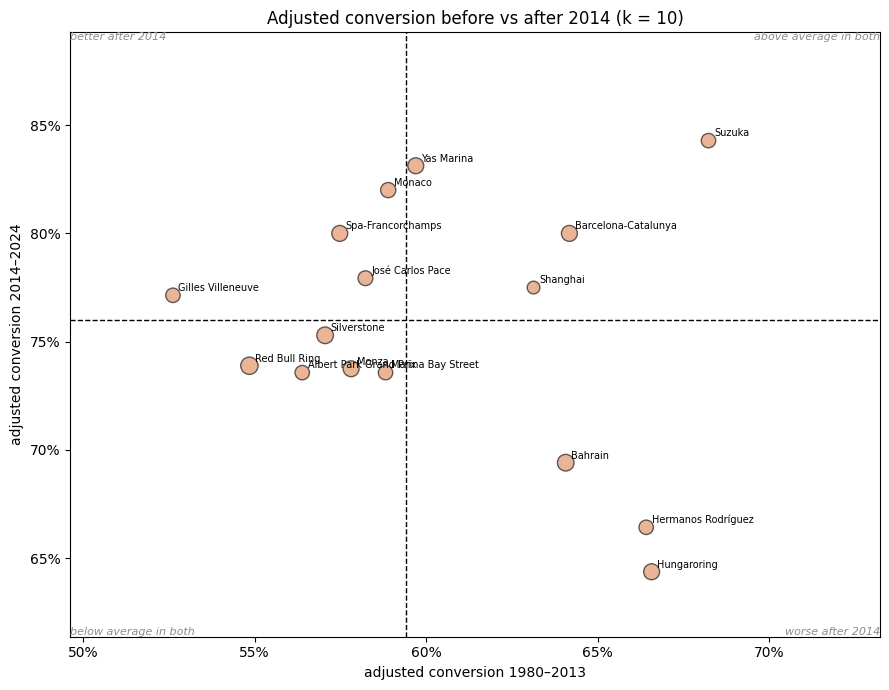

In [529]:
w = cmp[K_MAIN]
avg = ct.groupby("era")["era average"].first()
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(w[ERA_PRE], w[ERA_POST], s=counts.loc[w.index, ERA_POST] * 6,
           color=ERA_COLORS[ERA_POST], alpha=0.6, edgecolor="k")
for cid, x, y in zip(w.index, w[ERA_PRE], w[ERA_POST]):
    ax.annotate(short(names[cid]), (x, y), fontsize=7, xytext=(4, 3), textcoords="offset points")
ax.axvline(avg[ERA_PRE], color="black", ls="--", lw=1)
ax.axhline(avg[ERA_POST], color="black", ls="--", lw=1)
x0, x1 = w[ERA_PRE].min() - 0.03, w[ERA_PRE].max() + 0.05
y0, y1 = w[ERA_POST].min() - 0.03, w[ERA_POST].max() + 0.05
for tx, ty, ha, va, txt in [(x1, y1, "right", "top", "above average in both"), (x0, y1, "left", "top", "better after 2014"),
                            (x1, y0, "right", "bottom", "worse after 2014"), (x0, y0, "left", "bottom", "below average in both")]:
    ax.text(tx, ty, txt, ha=ha, va=va, fontsize=8, color=GREY, style="italic")
ax.set(xlim=(x0, x1), ylim=(y0, y1), xlabel=f"adjusted conversion {ERA_PRE}",
       ylabel=f"adjusted conversion {ERA_POST}", title=f"Adjusted conversion before vs after 2014 (k = {K_MAIN})")
pct_axis(ax.xaxis); pct_axis(ax.yaxis)
plt.tight_layout(); savefig("q1_06_before_after_rates"); plt.show()

**Figure 2 (k = 10):** each circuit's rank among the compared circuits, before and after 2014 (green = climbed, red = dropped).

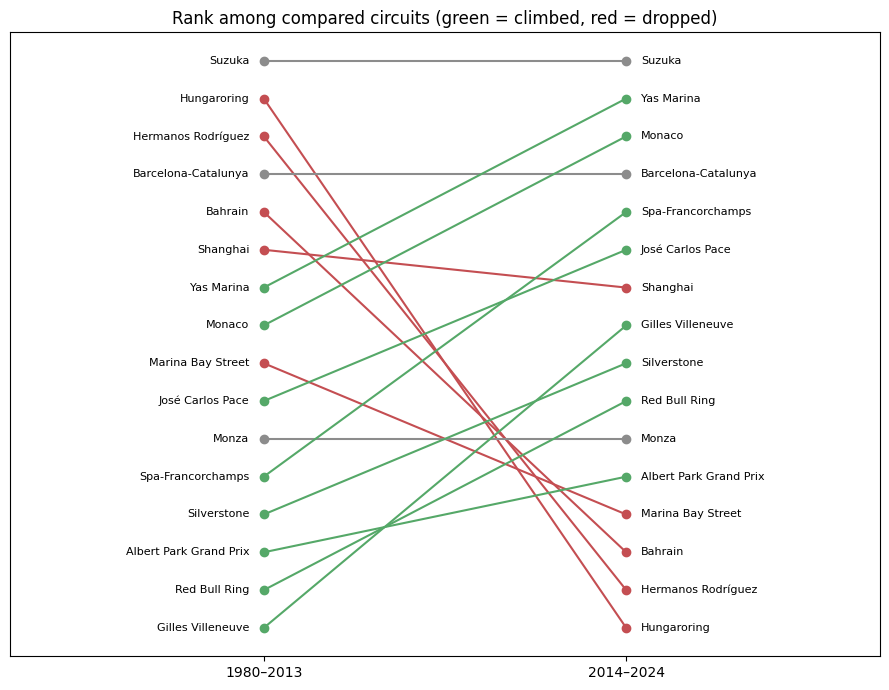

In [530]:
s = w.assign(y0=w[ERA_PRE].rank(ascending=False, method="first"),      # tie-free positions so labels do not overlap
             y1=w[ERA_POST].rank(ascending=False, method="first")).sort_values("y0")
fig, ax = plt.subplots(figsize=(9, 7))
for name, r0, r1 in zip(s.circuit, s.y0, s.y1):
    col = "#55A868" if r1 < r0 else ("#C44E52" if r1 > r0 else GREY)
    ax.plot([0, 1], [r0, r1], color=col, marker="o")
    ax.text(-0.04, r0, short(name), ha="right", va="center", fontsize=8)
    ax.text(1.04, r1, short(name), ha="left", va="center", fontsize=8)
ax.invert_yaxis(); ax.set_xticks([0, 1]); ax.set_xticklabels(ERAS); ax.set_xlim(-0.7, 1.7)
ax.set_yticks([]); ax.grid(False); ax.set_title("Rank among compared circuits (green = climbed, red = dropped)")
plt.tight_layout(); savefig("q1_07_before_after_ranks"); plt.show()

In [531]:
movers = w.sort_values("change", ascending=False)
table(pd.DataFrame({"circuit": movers.circuit,
                    f"adjusted {ERA_PRE}": movers[ERA_PRE], "rank before": movers["rank before"],
                    f"adjusted {ERA_POST}": movers[ERA_POST], "rank after": movers["rank after"],
                    "places climbed (+) / dropped (−)": movers.change.map(lambda v: f"{v:+d}")}),
      pct=[f"adjusted {ERA_PRE}", f"adjusted {ERA_POST}"], caption=f"Rank changes after 2014 (k = {K_MAIN})")

circuit,adjusted 1980–2013,rank before,adjusted 2014–2024,rank after,places climbed (+) / dropped (−)
Circuit de Spa-Francorchamps,57%,12,80%,4,+8
Circuit Gilles Villeneuve,53%,16,77%,8,+8
Circuit de Monaco,59%,8,82%,3,+5
Red Bull Ring,55%,15,74%,10,+5
Yas Marina Circuit,60%,7,83%,2,+5
Autódromo José Carlos Pace,58%,10,78%,6,+4
Silverstone Circuit,57%,13,75%,9,+4
Albert Park Grand Prix Circuit,56%,14,74%,12,+2
Suzuka Circuit,68%,1,84%,1,+0
Autodromo Nazionale di Monza,58%,11,74%,11,+0


#### 6.3 Is the change bigger than luck?

A low ρ does not prove the ranking changed. Each circuit has only a handful of races per era, so the rankings would shuffle somewhat **even if nothing real had changed**. Two simulations tell the difference.

**Simulation 1: how precise is our ρ? (redrawing races)**
For each circuit, we redraw its races at random from its own record in each era (the same race can be picked twice), recompute every rate, and recompute ρ. Repeating this 2,000 times shows how much our ρ could vary with slightly different luck.
- *Why whole races, not individual drivers:* the two front-row cars in a race are often teammates in the same car, so they tend to succeed or fail together. Treating them as independent would make the result look more certain than it is.

**Simulation 2: what ρ would we see if nothing had changed? (a "no-change" world)**
We build a world in which **every circuit keeps the same advantage over its era's average in both eras**, and only the overall level moves (59% → 76%). We then generate fake results with exactly the same number of front-row starts per circuit and era, and compute ρ. Repeated 2,000 times, this shows what ρ looks like when the only reason for a reshuffle is luck.
- *Why not simply shuffle races between the eras:* conversion jumped from about 59% to 76% after 2014. Shuffling would hand each circuit a random mix of "low-era" and "high-era" races, which pushes circuits in opposite directions and makes ρ look negative even when nothing changed.
- *Why "advantage" is measured on the odds scale:* a fixed gap in percentage points can push a rate above 100% when the era average is high. Odds keep every rate between 0% and 100%.
- *Why the adjusted (k = 10) rates are used as each circuit's true advantage:* raw rates exaggerate the differences between circuits (part of each gap is luck), which would make the no-change world look more stable than it is.
- *Limitation:* this simulation treats the two front-row cars as independent, so its spread is slightly too narrow. A borderline result should be read with care.

**The decision rule:** if our ρ is lower than at least 95% of the no-change values (p below 0.05), the ranking changed more than luck can explain. Otherwise, the data cannot separate a real change from luck.

In [532]:
# race-level records: front-row starts and podiums per race
race_lvl = (fr_main.groupby(["era", "circuitId", "raceId"])
                   .agg(n=("podium", "size"), pods=("podium", "sum")).reset_index())

def spearman_rows(a, b):
    """Spearman ρ between matching rows of two (simulations × circuits) arrays."""
    ra, rb = stats.rankdata(a, axis=1), stats.rankdata(b, axis=1)
    ra, rb = ra - ra.mean(axis=1, keepdims=True), rb - rb.mean(axis=1, keepdims=True)
    return (ra * rb).sum(axis=1) / np.sqrt((ra**2).sum(axis=1) * (rb**2).sum(axis=1))

def rho_from_sums(P, N, avg, ids, k_values):
    """Simulated podiums P and starts N per era and circuit → simulated ρ for each k."""
    out = {}
    for k in k_values:
        adj = {e: np.column_stack([bayes_avg(P[e][c], N[e][c], avg[e], k) for c in ids]) for e in ERAS}
        out[k] = spearman_rows(adj[ERA_PRE], adj[ERA_POST])
    return out

In [533]:
def resample_rho(ids, k_values, B=N_RESAMPLES, seed=SEED):
    """Simulation 1: redraw each circuit's races (with replacement) within each era."""
    rng = np.random.default_rng(seed)
    P, N, avg = {}, {}, {}
    for e in ERAS:
        P[e], N[e] = {}, {}
        for cid, g in race_lvl[race_lvl.era == e].groupby("circuitId"):   # all circuits, so the era average is redrawn too
            idx = rng.integers(0, len(g), size=(B, len(g)))
            P[e][cid], N[e][cid] = g.pods.values[idx].sum(axis=1), g.n.values[idx].sum(axis=1)
        avg[e] = sum(P[e].values()) / sum(N[e].values())
    return rho_from_sums(P, N, avg, ids, k_values)

In [534]:
def logit(p):
    return np.log(p / (1 - p))

def expit(x):
    return 1 / (1 + np.exp(-x))

def no_change_rates(ids, k=K_MAIN):
    """Each circuit's podium chance per era in a world where its advantage (on the odds scale) never changed."""
    t = circuit_table(fr_main, min_n=1, k_values=[k])
    t = t[t.circuitId.isin(ids)].copy()
    t["gap"] = logit(t[f"adj_k{k}"]) - logit(t["era average"])           # advantage over the era average
    advantage = (t.gap * t.starts).groupby(t.circuitId).sum() / t.starts.groupby(t.circuitId).sum()
    t["p_no_change"] = expit(logit(t["era average"]) + t.circuitId.map(advantage))
    return t[["era", "circuitId", "starts", "p_no_change"]]

In [535]:
def no_change_rho(ids, k_values, B=N_RESAMPLES, seed=SEED):
    """Simulation 2: fake results from the no-change world, same number of starts per circuit and era."""
    rng = np.random.default_rng(seed)
    others = race_lvl[~race_lvl.circuitId.isin(ids)].groupby("era")[["pods", "n"]].sum().reindex(ERAS, fill_value=0)
    P, N = {e: {} for e in ERAS}, {e: {} for e in ERAS}
    for r in no_change_rates(ids).itertuples():
        P[r.era][r.circuitId] = rng.binomial(r.starts, r.p_no_change, size=B)
        N[r.era][r.circuitId] = np.full(B, r.starts)
    avg = {e: (others.loc[e, "pods"] + sum(P[e].values())) / (others.loc[e, "n"] + sum(N[e].values())) for e in ERAS}
    return rho_from_sums(P, N, avg, ids, k_values)

In [536]:
boot = resample_rho(comp_ids, K_VALUES)
null = no_change_rho(comp_ids, K_VALUES)
p_val = {k: np.mean(null[k] <= rho_obs[k]) for k in K_VALUES}

In [537]:
def spread(x):
    return f"{np.nanpercentile(x, 2.5):.2f} to {np.nanpercentile(x, 97.5):.2f}"

luck = pd.DataFrame({
    "k": K_VALUES,
    "our ρ": [rho_obs[k] for k in K_VALUES],
    "plausible range of our ρ (simulation 1)": [spread(boot[k]) for k in K_VALUES],
    "typical ρ if nothing changed (simulation 2)": [f"{np.nanmedian(null[k]):.2f} (95%: {spread(null[k])})" for k in K_VALUES],
    "share of no-change simulations with ρ this low (p)": [p_val[k] for k in K_VALUES],
})
table(luck, dec2=["our ρ", "share of no-change simulations with ρ this low (p)"],
      caption="Is the change in ranking bigger than luck?")

k,our ρ,plausible range of our ρ (simulation 1),typical ρ if nothing changed (simulation 2),share of no-change simulations with ρ this low (p)
5,-0.00,-0.52 to 0.38,0.12 (95%: -0.38 to 0.60),0.33
10,0.02,-0.51 to 0.38,0.12 (95%: -0.40 to 0.61),0.36
20,-0.01,-0.51 to 0.39,0.12 (95%: -0.40 to 0.60),0.32


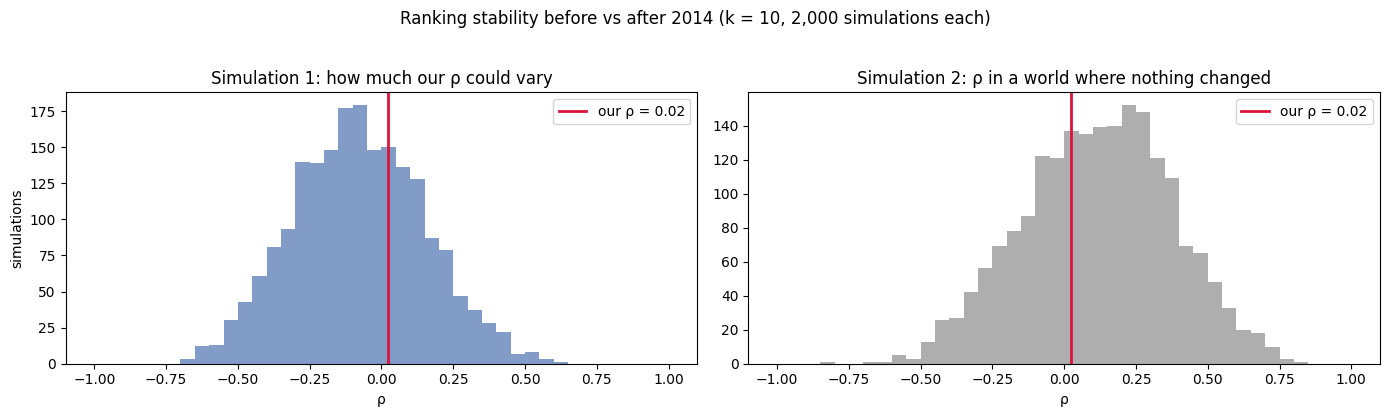

In [538]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
bins = np.linspace(-1, 1, 41)
axes[0].hist(boot[K_MAIN][~np.isnan(boot[K_MAIN])], bins=bins, color=ERA_COLORS[ERA_PRE], alpha=0.7)
axes[0].set(title="Simulation 1: how much our ρ could vary", xlabel="ρ", ylabel="simulations")
axes[1].hist(null[K_MAIN][~np.isnan(null[K_MAIN])], bins=bins, color=GREY, alpha=0.7)
axes[1].set(title="Simulation 2: ρ in a world where nothing changed", xlabel="ρ")
for ax in axes:
    ax.axvline(rho_obs[K_MAIN], color="crimson", lw=2, label=f"our ρ = {rho_obs[K_MAIN]:.2f}")
    ax.legend()
fig.suptitle(f"Ranking stability before vs after 2014 (k = {K_MAIN}, {N_RESAMPLES:,} simulations each)", y=1.03)
plt.tight_layout(); savefig("q1_08_luck_check"); plt.show()

**How to read this:**
- **Simulation 1 (left):** the wider this spread, the less precisely our data pins down ρ. Redrawing races adds extra noise to both rankings, so these values sit somewhat lower than our ρ; read this panel for its **width**, not its centre.
- **Simulation 2 (right):** the grey histogram is what luck alone produces when nothing changed. If the red line sits **far to the left** of it (p below 0.05), the ranking changed more than luck can explain. If it sits **inside** it, the data cannot separate a real change from luck.

#### 6.4 Does the answer depend on the minimum sample?

In [539]:
mc_rows = []
for m in MIN_N_VALUES:
    ids_m = list(counts.index[(counts[ERA_PRE] >= m) & (counts[ERA_POST] >= m)])
    w_m = era_compare(K_MAIN, ids_m)
    r_m = stats.spearmanr(w_m[ERA_PRE], w_m[ERA_POST])[0]
    null_m = no_change_rho(ids_m, [K_MAIN])[K_MAIN]
    mc_rows.append({"minimum front-row starts per era": m, "circuits compared": len(ids_m), "our ρ": r_m,
                    "typical ρ if nothing changed": np.nanmedian(null_m), "p (no-change simulation)": np.mean(null_m <= r_m)})
table(pd.DataFrame(mc_rows), dec2=["our ρ", "typical ρ if nothing changed", "p (no-change simulation)"],
      caption=f"Before/after comparison under different minimum samples (k = {K_MAIN})")

minimum front-row starts per era,circuits compared,our ρ,typical ρ if nothing changed,p (no-change simulation)
6,21,-0.04,0.11,0.25
10,16,0.02,0.12,0.36
14,14,0.02,0.13,0.34


#### 6.5 Part C answer

In [540]:
p_main, r_main, null_mid = p_val[K_MAIN], rho_obs[K_MAIN], np.nanmedian(null[K_MAIN])
if p_main < 0.05:
    verdict = (f"**Yes.** If nothing had changed, we would typically see ρ ≈ {null_mid:.2f}. Our ρ = {r_main:.2f} is lower "
               f"than that in all but {p_main:.0%} of simulations (p = {p_main:.2f}), so the order of circuits really changed.")
else:
    verdict = (f"**We cannot tell.** If nothing had changed, we would typically see ρ ≈ {null_mid:.2f}. Our ρ = {r_main:.2f}, "
               f"and a value this low happens in {p_main:.0%} of no-change simulations (p = {p_main:.2f}), "
               "so the reshuffle is consistent with luck.")
up, down = w.sort_values("change", ascending=False).head(3), w.sort_values("change").head(3)
fmt_moves = lambda d: ", ".join(f"{c} ({a}→{b})" for c, a, b in zip(d.circuit, d["rank before"], d["rank after"]))
md(f"""**Part C answer (k = {K_MAIN}, {len(comp_ids)} circuits compared):** {verdict}

- Biggest climbers: {fmt_moves(up)}.
- Biggest fallers: {fmt_moves(down)}.
- Check the tables above: the verdict should hold for k = 5 and 20 and for every minimum sample.""")

**Part C answer (k = 10, 16 circuits compared):** **We cannot tell.** If nothing had changed, we would typically see ρ ≈ 0.12. Our ρ = 0.02, and a value this low happens in 36% of no-change simulations (p = 0.36), so the reshuffle is consistent with luck.

- Biggest climbers: Circuit de Spa-Francorchamps (12→4), Circuit Gilles Villeneuve (16→8), Circuit de Monaco (8→3).
- Biggest fallers: Hungaroring (2→16), Autódromo Hermanos Rodríguez (3→15), Bahrain International Circuit (5→14).
- Check the tables above: the verdict should hold for k = 5 and 20 and for every minimum sample.

### 7. Answer and limitations

#### 7.1 Summary

In [541]:
robust = {e: ", ".join(top_group(ct[ct.era == e]).circuit) or "none" for e in ERAS}
summary = pd.DataFrame([
    {"part": "A. Qualifying vs grid",
     "answer": f"Use the grid slot. Drivers pushed back from a front-row qualifying position converted only "
               f"{pushed['podium rate']:.0%} vs {kept['podium rate']:.0%} for those who kept their slot.",
     "evidence": "4.1, 4.2"},
    {"part": f"B. Best circuits {ERA_PRE}", "answer": robust[ERA_PRE], "evidence": "5.1–5.5"},
    {"part": f"B. Best circuits {ERA_POST}", "answer": robust[ERA_POST], "evidence": "5.1–5.5"},
    {"part": "C. Did the ranking change after 2014?",
     "answer": ("Yes: more than luck explains" if p_main < 0.05 else "Not distinguishable from luck")
               + f" (ρ = {r_main:.2f} vs ≈ {null_mid:.2f} if nothing changed; p = {p_main:.2f}; {len(comp_ids)} circuits)",
     "evidence": "6.1–6.5"},
])
table(summary, caption="Q1 answers")

part,answer,evidence
A. Qualifying vs grid,Use the grid slot. Drivers pushed back from a front-row qualifying position converted only 31% vs 73% for those who kept their slot.,"4.1, 4.2"
B. Best circuits 1980–2013,"Circuit de Nevers Magny-Cours, Istanbul Park, Suzuka Circuit, Sepang International Circuit",5.1–5.5
B. Best circuits 2014–2024,"Suzuka Circuit, Yas Marina Circuit, Circuit de Monaco, Circuit de Barcelona-Catalunya, Circuit de Spa-Francorchamps",5.1–5.5
C. Did the ranking change after 2014?,Not distinguishable from luck (ρ = 0.02 vs ≈ 0.12 if nothing changed; p = 0.36; 16 circuits),6.1–6.5


#### 7.2 Limitations

- **Team dominance is mixed into circuit results.** A circuit's rate partly reflects which team held its front row (for example Mercedes 2014–2020, Red Bull 2022–2023). This analysis does not control for team strength. A possible extension is to compare each front-row start with that team's podium rate in the same season.
- **The eras are unequal.** 1980–2013 has 34 seasons and 2014–2024 has 11, so earlier-era rates are more precise. The earlier era also spans very different reliability levels. Using each era's own average and comparing ranks (not raw rates) limits the effect of this.
- **Front-row starts are not independent.** Teammates often share the front row. Simulation 1 handles this by redrawing whole races, but the per-circuit Wilson ranges and Simulation 2 treat starts as independent, so their uncertainty is somewhat too narrow.
- **Layout changes are not separated.** A circuit keeps its `circuitId` when its layout changes (for example Yas Marina in 2021), so its rate mixes layouts.
- **Sprint weekends (2021–2022)** set the grid with a sprint race. They are included, because the grid is still fixed before the main race.
- **Judgment calls:** the 1980 start (front row = 2 cars, from F1 history, not checkable in Ergast), k and the minimum sample. The last two are tested with alternative values above.
- **Descriptive only:** these are associations. Nothing here shows *why* a circuit converts more often.

## Q2: Do drivers podium more often at home, after controlling for starting position?

**The question:** compare home and away podium rates for drivers who start from the same place on the grid. The main result compares **each driver with themselves**: their home starts against their own away starts.

Each step is written as *what we do* → *why* → *the result*. Where an earlier section of this notebook already established something, Q2 points to it and only states what it means for this question.

#### Two terms used throughout

**Odds ratio (OR).** *Odds* are another way of writing a chance: a podium 1 time in 4 means odds of 1 to 3. The **odds ratio** compares home odds with away odds:
- **OR = 1:** no difference between home and away.
- **OR above 1:** home drivers do better (1.20 = 20% higher odds).
- **OR below 1:** home drivers do worse (0.80 = 20% lower odds).

Every OR comes with a **95% range**. If the range includes 1, the data cannot tell home and away apart.

**"Compare like with like, then combine" (Mantel–Haenszel).** Split the starts into groups of comparable starts (for example "P3 starters in the 1990s"), compare home with away *inside* each group, and combine the groups into one OR. Pole-sitters are never compared with backmarkers.

### 1. Setup

Q2 reuses the libraries and helper functions defined in Q1 (1.2: `table`, `md`, `savefig`, `wilson`, `pct_range`) and Q1's `LAST_SEASON`, `SEED` and `GREY`. Only Q2's own settings and one formatting helper are added here.

#### 1.1 Analysis choices

| Setting | Value | What it controls | Explained in |
|---|---|---|---|
| `GRID_BINS` | P1 … P10 exact, then P11–12, P13–15, P16–20, P21+ | How finely starting position is controlled | 3.3 |
| `SENS_STARTS` | 1980, 2000, 2014 | Later start years used as sensitivity checks | 8 |
| `N_BOOT` | 1,000 | Resamples used to widen ranges for repeated drivers | 5.3 |

In [542]:
GRID_BINS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, np.inf]
GRID_LABELS = ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8", "P9", "P10", "P11–12", "P13–15", "P16–20", "P21+"]
SENS_STARTS = [1980, 2000, 2014]
N_BOOT = 1000

In [543]:
HOME_COLOR, AWAY_COLOR = "#DD8452", "#4C72B0"
FIG_DIR = "figures_q2"
os.makedirs(FIG_DIR, exist_ok=True)

#### 1.2 Helper function

In [544]:
def or_text(o, lo, hi):
    """Format an odds ratio with its range."""
    return f"{o:.2f} ({lo:.2f} – {hi:.2f})"

### 2. Rows used

Q2 starts from `results_unique` and joins the season, circuit country and driver nationality. What the earlier sections mean for Q2:

- **Starting position** (results, *Decision: `grid` = 0*): the 1,563 `never_ran` rows never started, so they are left out (3.2). The 72 pit-lane starters raced, so they stay, and Q2 uses `grid_clean`, which places them at the back of the field. This is the control variable throughout Q2.
- **Shared drives** (results, *Keep rule for duplicated pairs*): one row per driver per race, keeping the best-classified row and its grid slot. Q2 covers all seasons, so this applies to the 1950s rows it uses.
- **Shared podium cars** (results, *Summary of anomaly checks*): in 18 races of 1950–1960 more than three drivers are credited with a podium place. The cleaning summary (notebook section 3, *Rows we remove or mark*) sets the rule for older seasons, *count one podium per car*; Q2 applies it (3.2 below).
- **Indianapolis 500** (races, *Indianapolis 500: decision*): excluded from the home-country question there, because 95% of its rows come from drivers who never raced another Grand Prix and it would inflate American home starts. Q2 follows that decision and shows its effect in section 8.

**Grain:** one driver entering one race. **Podium:** `positionOrder ≤ 3`, the notebook's target. **Pre-race cutoff:** the starting position and the home flag are known before the race.

In [545]:
q2_base = (results_unique[["resultId", "raceId", "driverId", "constructorId", "grid", "grid_clean", "positionOrder",
                           "never_ran", "is_indy500"]]
           .merge(races[["raceId", "year", "circuitId", "name"]].rename(columns={"name": "race_name"}),
                  on="raceId", how="left", validate="m:1")
           .merge(circuits[["circuitId", "country"]].rename(columns={"country": "circuit_country"}),
                  on="circuitId", how="left", validate="m:1")
           .merge(drivers[["driverId", "forename", "surname", "nationality"]].rename(columns={"nationality": "driver_nationality"}),
                  on="driverId", how="left", validate="m:1"))
q2_base = q2_base[q2_base.year <= LAST_SEASON].copy()
q2_base["podium"] = (q2_base.positionOrder <= 3).astype(int)
q2_base["driver"] = q2_base.forename + " " + q2_base.surname
q2_base["circuit_country"] = q2_base.circuit_country.str.strip()
q2_base["driver_nationality"] = q2_base.driver_nationality.str.strip()   # 'Argentinian ' has a trailing space
assert q2_base[["year", "circuit_country", "driver_nationality"]].notna().all().all()

### 3. Definitions: home race, sample, controls

#### 3.1 What counts as a home race?

**Definition:** a start is a **home start** when the circuit is in the driver's country. For example, a British driver at Silverstone or Brands Hatch, or an Italian driver at Monza or Imola.

The drivers section (*circuits and drivers: countries and nationalities*) already showed that the two columns cannot be matched as written: circuits store a country (`UK`), drivers an adjective (`British`), the United States is written two ways, `Argentinian` has a trailing space (removed in section 2 above), and four values are mixed or historical. It decided to build **one explicit nationality-to-country map** for this question and for the `is_home` feature. The map is built here, with these rules:
1. **One spelling per country:** `United States` becomes `USA`.
2. **Every nationality is mapped explicitly;** anything that does not map is shown, not silently dropped.
3. **Two nationalities mean two home countries.** `American-Italian` drivers are at home in the USA **and** in Italy, `Argentine-Italian` drivers in Argentina **and** in Italy. A driver with two nationalities can reasonably be at home in either country, so both count.
4. **Historical nationalities count as not home:** `East German` and `Rhodesian` (the countries no longer exist).

Section 6.4 measures how much rule 3 changes the result. Note for the model: the `is_home` feature should use the same map.

In [546]:
COUNTRY_NORMALISE = {"United States": "USA"}   # rule 1: the only double spelling (drivers section)
q2_base["circuit_country"] = q2_base.circuit_country.replace(COUNTRY_NORMALISE)

In [547]:
NATIONALITY_TO_COUNTRY = {
    "American": "USA", "Argentine": "Argentina", "Argentinian": "Argentina",
    "Australian": "Australia", "Austrian": "Austria", "Belgian": "Belgium",
    "Brazilian": "Brazil", "British": "UK", "Canadian": "Canada", "Chilean": "Chile", "Chinese": "China",
    "Colombian": "Colombia", "Czech": "Czech Republic", "Danish": "Denmark", "Dutch": "Netherlands",
    "Finnish": "Finland", "French": "France", "German": "Germany",
    "Hong Kong": "Hong Kong", "Hungarian": "Hungary", "Indian": "India", "Indonesian": "Indonesia",
    "Irish": "Ireland", "Italian": "Italy", "Japanese": "Japan", "Liechtensteiner": "Liechtenstein",
    "Malaysian": "Malaysia", "Mexican": "Mexico", "Monegasque": "Monaco", "Moroccan": "Morocco",
    "New Zealander": "New Zealand", "Polish": "Poland", "Portuguese": "Portugal", "Russian": "Russia", "South African": "South Africa", "Spanish": "Spain", "Swedish": "Sweden",
    "Swiss": "Switzerland", "Thai": "Thailand", "Uruguayan": "Uruguay", "Venezuelan": "Venezuela",
    "Saudi": "Saudi Arabia", "Emirati": "UAE", "Chinese Taipei": "Taiwan", "Estonian": "Estonia",
    "Israeli": "Israel",
}
DUAL_HOME = {"American-Italian": ["USA", "Italy"], "Argentine-Italian": ["Argentina", "Italy"]}   # at home in both
NOT_HOME = ["East German", "Rhodesian"]   # historical: never home (team decision)

In [548]:
present = set(q2_base.driver_nationality)
unmapped = sorted(present - set(NATIONALITY_TO_COUNTRY) - set(DUAL_HOME) - set(NOT_HOME))
home_countries = set(NATIONALITY_TO_COUNTRY.values()) | {c for cs in DUAL_HOME.values() for c in cs}
no_home_driver = sorted(set(q2_base.circuit_country) - home_countries)
table(pd.DataFrame([
    {"check": "dual nationalities, at home in both countries",
     "result": ", ".join(f"{n} ({' and '.join(DUAL_HOME[n])})" for n in DUAL_HOME if n in present) or "none"},
    {"check": "historical nationalities, counted as not home", "result": ", ".join(n for n in NOT_HOME if n in present) or "none"},
    {"check": "other nationalities without a mapping (should be none)", "result": ", ".join(unmapped) or "none"},
    {"check": "host countries with no driver of that nationality (no home race possible)",
     "result": ", ".join(no_home_driver) or "none"},
]), caption="Mapping checks")

single = q2_base.driver_nationality.map(NATIONALITY_TO_COUNTRY) == q2_base.circuit_country
dual = [isinstance(h, list) and c in h for h, c in zip(q2_base.driver_nationality.map(DUAL_HOME), q2_base.circuit_country)]
q2_base["home"] = (single | np.array(dual)).astype(int)    # the home flag used everywhere in Q2
q2_base["home_without_dual"] = single.astype(int)          # dual nationals never at home: only for the comparison in 6.4

check,result
"dual nationalities, at home in both countries","American-Italian (USA and Italy), Argentine-Italian (Argentina and Italy)"
"historical nationalities, counted as not home","East German, Rhodesian"
other nationalities without a mapping (should be none),none
host countries with no driver of that nationality (no home race possible),"Azerbaijan, Bahrain, Korea, Qatar, Singapore, Turkey"


**Drivers with two nationalities.** Rule 3 gives these drivers two home countries. The table shows, for the starts in the Q2 sample, how many of their starts are home starts because of it.

In [549]:
in_sample = q2_base[~q2_base.never_ran & ~q2_base.is_indy500]
dual_rows = in_sample[in_sample.driver_nationality.isin(DUAL_HOME)]
dual_drivers = (dual_rows.groupby(["driver", "driver_nationality"])
                         .agg(starts=("podium", "size"), podiums=("podium", "sum"), **{"home starts": ("home", "sum")})
                         .reset_index().rename(columns={"driver_nationality": "nationality"}))
dual_drivers.insert(2, "home countries", dual_drivers.nationality.map(lambda n: " and ".join(DUAL_HOME[n])))
dual_drivers["home podiums"] = dual_drivers.driver.map(dual_rows[dual_rows.home == 1].groupby("driver").podium.sum()).fillna(0).astype(int)
if len(dual_drivers):
    table(dual_drivers, caption=f"Drivers with two nationalities: {int(dual_drivers['home starts'].sum())} home starts from rule 3")
else:
    md("No driver with two nationalities is in the Q2 sample.")

driver,nationality,home countries,starts,podiums,home starts,home podiums
Alessandro de Tomaso,Argentine-Italian,Argentina and Italy,2,0,1,0
Alfonso Thiele,American-Italian,USA and Italy,1,0,1,0


#### 3.2 The sample: which starts are used?

**Which starts are used:**
- **`never_ran`** and the **Indianapolis 500** are left out, and pit-lane starters are kept at the back of the field (reasons in section 2 above).
- **One podium per car** (the rule for older seasons in the cleaning summary, notebook section 3): where two drivers shared a car, each car counts once: the first-listed driver (lowest `resultId`) keeps the start and the others are left out. The data does not say which driver started the car, so this choice is arbitrary but reproducible; the table below lists every row it affects.

**Time window:** all seasons, 1950–2024, to keep as many home starts as possible. Later start years (1980, 2000, 2014) are checked in section 8.

In [550]:
SHARED_CAR = ["raceId", "positionOrder", "constructorId"]   # one car's finishing place in one race

def shared_podium_extras(d):
    """Index of the extra drivers credited with a car's podium place that is already counted (shared drives)."""
    pod = d[d.podium == 1].sort_values("resultId")
    return pod.index[pod.duplicated(SHARED_CAR, keep="first")]

def q2_frame(df, include_indy=False, year_from=None):
    """The Q2 sample: drivers who started, Indy 500 optional, optional later start year, one podium per car, plus the controls."""
    d = df[~df.never_ran]
    if not include_indy:
        d = d[~d.is_indy500]
    if year_from:
        d = d[d.year >= year_from]
    d = d.drop(index=shared_podium_extras(d)).copy()         # one podium per car
    d["grid"] = d.grid_clean                                     # starting position: pit-lane starters at the back
    d["grid_slot"] = pd.cut(d.grid, GRID_BINS, labels=GRID_LABELS)
    d["decade"] = (d.year // 10 * 10).astype(int)
    return d

In [551]:
q2 = q2_frame(q2_base)
steps = [("all driver–race entries 1950–2024", q2_base),
         ("minus never_ran (did not start)", q2_base[~q2_base.never_ran]),
         ("minus the Indianapolis 500", q2_base[~q2_base.never_ran & ~q2_base.is_indy500]),
         ("minus extra drivers credited with an already counted podium car (the Q2 sample)", q2)]
table(pd.DataFrame([{"step": s, "starts": len(d), "home starts": int(d.home.sum()),
                     "share at home": d.home.mean()} for s, d in steps]),
      pct=["share at home"], caption="Building the Q2 sample")

step,starts,home starts,share at home
all driver–race entries 1950–2024,26668,2488,9%
minus never_ran (did not start),25105,2320,9%
minus the Indianapolis 500,24724,1940,8%
minus extra drivers credited with an already counted podium car (the Q2 sample),24707,1935,8%


**Shared podium cars.** The results section listed the 18 races with more than three podium rows. This table shows, for the races in the Q2 sample, which driver keeps each shared podium car and which are left out:

In [552]:
pre = q2_base[~q2_base.never_ran & ~q2_base.is_indy500]
pod = pre[pre.podium == 1].sort_values("resultId")
shared = pod[pod.duplicated(SHARED_CAR, keep=False)].sort_values(["year", "raceId", "positionOrder", "resultId"])
kept = ~shared.duplicated(SHARED_CAR, keep="first")
table(pd.DataFrame({"season": shared.year, "race": shared.race_name, "podium place": shared.positionOrder,
                    "driver": shared.driver, "home start": np.where(shared.home == 1, "yes", "no"),
                    "in Q2": np.where(kept, "kept", "left out")}),
      caption=f"Shared podium cars: {int((~kept).sum())} extra rows left out, {int(shared[~kept].home.sum())} of them home starts")

season,race,podium place,driver,home start,in Q2
1950,Italian Grand Prix,2,Dorino Serafini,yes,kept
1950,Italian Grand Prix,2,Alberto Ascari,yes,left out
1951,French Grand Prix,1,Luigi Fagioli,no,kept
1951,French Grand Prix,1,Juan Fangio,no,left out
1951,French Grand Prix,2,Alberto Ascari,no,kept
1951,French Grand Prix,2,José Froilán González,no,left out
1951,Italian Grand Prix,3,Felice Bonetto,yes,kept
1951,Italian Grand Prix,3,Nino Farina,yes,left out
1953,Dutch Grand Prix,3,Felice Bonetto,no,kept
1953,Dutch Grand Prix,3,José Froilán González,no,left out


#### 3.3 The two controls: grid slot and decade

**Grid slot.** Wide bands (for example P6–10 or P16+) would hide differences: inside a wide band, a P6 and a P10 start are treated as equal although a P6 starter makes the podium far more often. Because home drivers start further back on average (section 4), they would sit nearer the back of each band and look worse for that reason alone.
- **P1 to P10 are used exactly.** This is where podiums happen.
- **Behind P10, slots are grouped** (P11–12, P13–15, P16–20, P21+), because podiums from there are so rare that single slots carry almost no information.

**Decade.** A P8 start meant different things in different eras: in the 1950s cars broke down constantly and a P8 starter often reached the podium by surviving; in the 2010s that rarely happened. Home starts are also concentrated in early decades. Every comparison is therefore made **within the same grid slot and the same decade**.

**Grid slot means `grid_clean`:** pit-lane starters sit in the group for the back of the field.

The table shows why the back of the grid is grouped: the podium rate there is close to zero.

In [553]:
slots = (q2.groupby("grid_slot", observed=True)
           .agg(starts=("podium", "size"), podiums=("podium", "sum"), **{"home starts": ("home", "sum")})
           .reset_index())
slots["podium rate"] = slots.podiums / slots.starts
table(slots.rename(columns={"grid_slot": "grid slot"}), pct=["podium rate"], caption="Starts and podium rate by grid slot (the control groups)")

grid slot,starts,podiums,home starts,podium rate
P1,1111,715,81,64%
P2,1107,622,75,56%
P3,1113,515,71,46%
P4,1116,386,73,35%
P5,1108,277,71,25%
P6,1105,206,80,19%
P7,1117,141,77,13%
P8,1109,110,78,10%
P9,1117,90,96,8%
P10,1112,63,86,6%


### 4. The raw comparison (and why it misleads)

**What we do:** compare home and away podium rates with no control at all, and look at where home and away drivers start.

In [554]:
raw_cmp = (q2.groupby("home").agg(starts=("podium", "size"), podiums=("podium", "sum"),
                                  **{"average grid slot": ("grid", "mean"), "median grid slot": ("grid", "median")})
             .rename(index={0: "away", 1: "home"}).reset_index().rename(columns={"home": "where"}))
raw_cmp["median grid slot"] = raw_cmp["median grid slot"].astype(int)
raw_cmp["podium rate"] = raw_cmp.podiums / raw_cmp.starts
raw_cmp["95% Wilson range"] = pct_range(*wilson(raw_cmp.podiums, raw_cmp.starts))
table(raw_cmp, pct=["podium rate"], dec2=["average grid slot"], caption="Raw comparison: home vs away")

where,starts,podiums,average grid slot,median grid slot,podium rate,95% Wilson range
away,22772,3117,11.74,12,14%,13% – 14%
home,1935,225,12.72,13,12%,10% – 13%


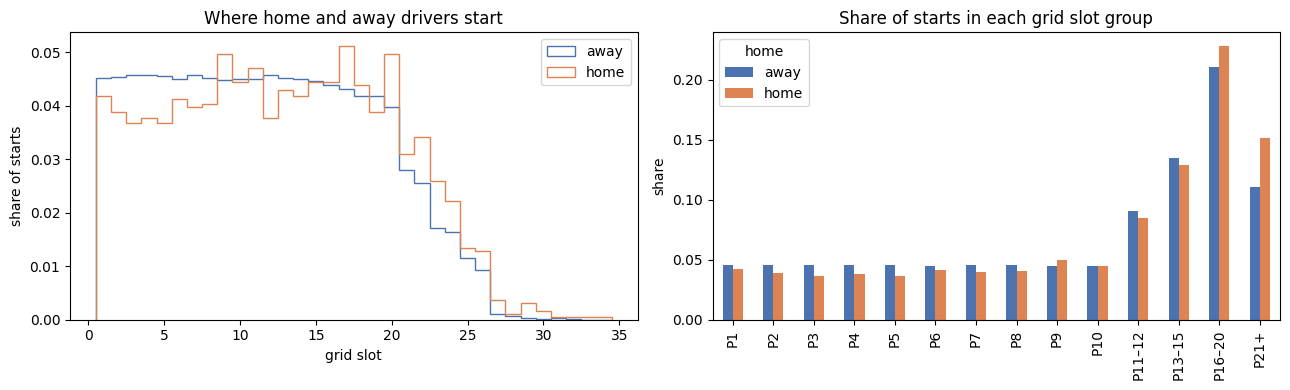

In [555]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bins = np.arange(0.5, q2.grid.max() + 1.5)
for h, col, lab in [(0, AWAY_COLOR, "away"), (1, HOME_COLOR, "home")]:
    axes[0].hist(q2[q2.home == h].grid, bins=bins, density=True, histtype="step", lw=2, color=col, label=lab)
axes[0].set(title="Where home and away drivers start", xlabel="grid slot", ylabel="share of starts")
axes[0].legend()

mix = pd.crosstab(q2.home, q2.grid_slot, normalize="index").rename(index={0: "away", 1: "home"})
mix.T.plot(kind="bar", ax=axes[1], color=[AWAY_COLOR, HOME_COLOR])
axes[1].set(title="Share of starts in each grid slot group", ylabel="share", xlabel="")
plt.tight_layout(); savefig("q2_01_grid_mix"); plt.show()

In [556]:
raw_home, raw_away = raw_cmp.set_index("where").loc["home"], raw_cmp.set_index("where").loc["away"]
more_less = "less" if raw_home["podium rate"] < raw_away["podium rate"] else "more"
back_front = "further back" if raw_home["average grid slot"] > raw_away["average grid slot"] else "further forward"
md(f"""**Reading:** home drivers reach the podium **{more_less}** often ({raw_home['podium rate']:.1%} vs {raw_away['podium rate']:.1%}),
and they start {back_front} on average (slot {raw_home['average grid slot']:.1f} vs {raw_away['average grid slot']:.1f}).
Where a driver starts strongly affects the chance of a podium, so the raw numbers mix the home effect with the starting
position. This is exactly why the question asks us to control for it.""")

**Reading:** home drivers reach the podium **less** often (11.6% vs 13.7%),
and they start further back on average (slot 12.7 vs 11.7).
Where a driver starts strongly affects the chance of a podium, so the raw numbers mix the home effect with the starting
position. This is exactly why the question asks us to control for it.

### 5. Like with like: home drivers vs other drivers

This section compares home drivers with *other* drivers who started from the same place: the same grid slot in the same decade, with ranges that account for the same driver appearing many times. Section 6 then compares each driver with themselves.

#### 5.1 Home vs away, slot by slot

**What the figure shows:** the podium rate of home and away starters from each grid slot group, with 95% Wilson ranges. If being at home helped, the orange dots would sit consistently above the blue ones.

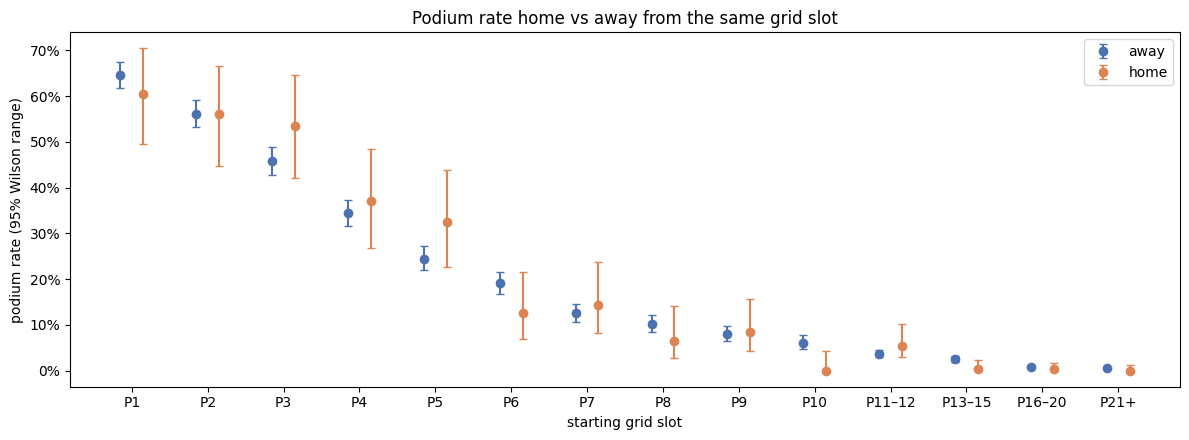

In [557]:
strat = (q2.groupby(["grid_slot", "home"], observed=True)
           .agg(n=("podium", "size"), podiums=("podium", "sum")).reset_index())
strat["rate"] = strat.podiums / strat.n
strat["ci_lo"], strat["ci_hi"] = wilson(strat.podiums, strat.n)

fig, ax = plt.subplots(figsize=(12, 4.5))
xs = np.arange(len(GRID_LABELS))
for h, col, off, lab in [(0, AWAY_COLOR, -0.15, "away"), (1, HOME_COLOR, 0.15, "home")]:
    s = strat[strat.home == h].set_index("grid_slot").reindex(GRID_LABELS)
    ax.errorbar(xs + off, s.rate, yerr=[s.rate - s.ci_lo, s.ci_hi - s.rate], fmt="o", color=col,
                capsize=3, label=lab, ms=6)
ax.set_xticks(xs); ax.set_xticklabels(GRID_LABELS)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set(ylabel="podium rate (95% Wilson range)", xlabel="starting grid slot",
       title="Podium rate home vs away from the same grid slot")
ax.legend(); plt.tight_layout(); savefig("q2_02_by_slot"); plt.show()

#### 5.2 Combining the slots into one number

**The method (Mantel–Haenszel):** for every group of comparable starts we count four numbers:

| | podium | no podium |
|---|---|---|
| **home** | a | b |
| **away** | c | d |

The combined odds ratio is **Σ(a·d / n) ÷ Σ(b·c / n)** over all groups (n = starts in the group). Each group is compared only with itself, and bigger groups count more. Groups where nobody (or everybody) reached the podium carry no information and drop out automatically.

**Why this method:** it is the standard way to combine "like with like" comparisons, it needs no model assumptions, and it works even when many groups are small, which matters in section 6. The 95% range uses the standard Robins–Breslow–Greenland formula.

In [558]:
def stratum_counts(d, strata):
    """The four counts (a, b, c, dd) for every group of comparable starts."""
    t = d.assign(a=d.home * d.podium, b=d.home * (1 - d.podium),
                 c=(1 - d.home) * d.podium, dd=(1 - d.home) * (1 - d.podium))
    return t.groupby(strata, observed=True)[["a", "b", "c", "dd"]].sum().reset_index()

In [559]:
def mh_or(a, b, c, d):
    """Mantel–Haenszel odds ratio over the last axis (works for one table or many resamples at once)."""
    a, b, c, d = (np.asarray(x, dtype=float) for x in (a, b, c, d))
    n = a + b + c + d
    n = np.where(n == 0, np.nan, n)
    with np.errstate(divide="ignore", invalid="ignore"):     # a resample with no informative group gives inf/nan
        return np.nansum(a * d / n, axis=-1) / np.nansum(b * c / n, axis=-1)

def mh_range(a, b, c, d, z=1.96):
    """95% range of the MH odds ratio (Robins–Breslow–Greenland), assuming every start is independent."""
    a, b, c, d = (np.asarray(x, dtype=float) for x in (a, b, c, d))
    n = a + b + c + d
    keep = n > 0
    a, b, c, d, n = a[keep], b[keep], c[keep], d[keep], n[keep]
    R, S, P, Q = a * d / n, b * c / n, (a + d) / n, (b + c) / n
    var = ((P * R).sum() / (2 * R.sum() ** 2) + (P * S + Q * R).sum() / (2 * R.sum() * S.sum())
           + (Q * S).sum() / (2 * S.sum() ** 2))
    o = R.sum() / S.sum()
    return o, o * np.exp(-z * np.sqrt(var)), o * np.exp(z * np.sqrt(var))

In [560]:
impr = stratum_counts(q2, ["grid_slot", "decade"])
o_impr = mh_range(impr.a, impr.b, impr.c, impr.dd)
table(pd.DataFrame([{"comparison": "home vs other drivers, same grid slot and decade", "groups compared": len(impr),
                     "odds ratio (range)": or_text(*o_impr)}]),
      caption="Home vs other drivers from comparable starts")

comparison,groups compared,odds ratio (range)
"home vs other drivers, same grid slot and decade",112,0.92 (0.77 – 1.10)


#### 5.3 Accounting for repeated drivers

**The problem:** the ranges above treat every start as independent. But the same driver appears many times, with the same skill and often the same car. Asking 10 people the same question 100 times does not give 1,000 independent opinions.

**The fix (resampling drivers):** we redraw the list of *drivers* at random (some drivers drawn twice, some not at all), keep all the starts of each drawn driver, and recompute the odds ratio. Repeated 1,000 times, the middle 95% of the results is a range that respects the fact that each driver's starts belong together.

In [561]:
def driver_resample_range(d, strata, B=N_BOOT, seed=SEED):
    """95% range of the MH odds ratio when whole drivers (with all their starts) are redrawn B times."""
    rng = np.random.default_rng(seed)
    cnt = stratum_counts(d, ["driverId"] + [s for s in strata if s != "driverId"])   # counts per driver and group
    cnt["group"] = cnt.groupby(strata, observed=True).ngroup()
    ids = pd.Index(cnt.driverId.unique())
    rows, cols = ids.get_indexer(cnt.driverId), cnt.group.values
    mats = []
    for x in ["a", "b", "c", "dd"]:                           # drivers × groups matrix for each count
        m = np.zeros((len(ids), cols.max() + 1))
        np.add.at(m, (rows, cols), cnt[x].values)
        mats.append(m)
    draws = rng.multinomial(len(ids), np.full(len(ids), 1 / len(ids)), size=B)   # times each driver is drawn
    sims = mh_or(*(draws @ m for m in mats))
    return np.nanpercentile(sims, [2.5, 97.5])

In [562]:
lo_b, hi_b = driver_resample_range(q2, ["grid_slot", "decade"])
between = {"or": o_impr[0], "lo": lo_b, "hi": hi_b}
table(pd.DataFrame([
    {"range calculated": "every start independent (5.2)", "odds ratio": o_impr[0], "95% range": f"{o_impr[1]:.2f} – {o_impr[2]:.2f}",
     "width": o_impr[2] - o_impr[1]},
    {"range calculated": "whole drivers redrawn", "odds ratio": o_impr[0], "95% range": f"{lo_b:.2f} – {hi_b:.2f}",
     "width": hi_b - lo_b},
]), dec2=["odds ratio", "width"], caption="Home vs other drivers (exact slot × decade): effect of repeated drivers")

range calculated,odds ratio,95% range,width
every start independent (5.2),0.92,0.77 – 1.10,0.33
whole drivers redrawn,0.92,0.73 – 1.12,0.39


In [563]:
widen = (hi_b - lo_b) / (o_impr[2] - o_impr[1])
md(f"**Reading:** redrawing whole drivers makes the range **{widen:.1f} times** as wide as treating every start as "
   "independent. The second range is the honest one, and it is the one used from here on.")

**Reading:** redrawing whole drivers makes the range **1.2 times** as wide as treating every start as independent. The second range is the honest one, and it is the one used from here on.

### 6. Each driver vs themselves (main result)

#### 6.1 Why compare drivers with themselves?

Section 5 compares home drivers with **other** drivers. That leaves a problem the grid slot cannot fix: the home group and the away group contain different kinds of drivers. In the early decades many home starts came from local one-off drivers, often in old cars, who raced only their home Grand Prix.

The cleaner question is: **does the same driver do better at home than elsewhere, from the same grid slot?** For example, does Alonso reach the podium more often in Spain than at his other races, when he starts from the same place?

The table below shows the drivers with the most home starts, with their home and away record. It is only an illustration (not yet controlled for grid slot).

In [564]:
per_driver = (q2.groupby(["driverId", "driver", "driver_nationality", "home"])
                .agg(starts=("podium", "size"), rate=("podium", "mean"), grid=("grid", "mean"))
                .unstack("home"))
per_driver.columns = [f"{a}_{'home' if b else 'away'}" for a, b in per_driver.columns]
per_driver = per_driver.reset_index().fillna({"starts_home": 0, "starts_away": 0})

In [565]:
top = per_driver.sort_values("starts_home", ascending=False).head(12)
table(pd.DataFrame({"driver": top.driver, "nationality": top.driver_nationality,
                    "home starts": top.starts_home.astype(int), "home podium rate": top.rate_home,
                    "away starts": top.starts_away.astype(int), "away podium rate": top.rate_away,
                    "average slot at home": top.grid_home, "average slot away": top.grid_away}),
      pct=["home podium rate", "away podium rate"], dec2=["average slot at home", "average slot away"],
      caption="Drivers with the most home starts (raw, not yet controlled)")

driver,nationality,home starts,home podium rate,away starts,away podium rate,average slot at home,average slot away
Riccardo Patrese,Italian,29,14%,228,14%,8.31,9.40
Michael Schumacher,German,28,54%,280,50%,3.89,4.96
Andrea de Cesaris,Italian,27,0%,181,3%,14.89,14.33
Fernando Alonso,Spanish,26,35%,378,26%,7.38,8.71
Jarno Trulli,Italian,25,0%,231,5%,10.20,10.42
Giancarlo Fisichella,Italian,24,4%,206,9%,13.08,11.18
Michele Alboreto,Italian,23,17%,171,11%,12.48,13.44
Ralf Schumacher,German,20,15%,160,15%,6.40,8.01
Rubens Barrichello,Brazilian,19,5%,306,22%,8.00,8.97
Mario Andretti,American,19,16%,109,15%,7.74,8.71


#### 6.2 Who can be compared with themselves?

Only drivers who started **both** at home and away can be compared with themselves. Drivers who only ever raced at home drop out automatically, which is the point: their record says nothing about the effect of being at home.

In [566]:
def driver_type(row):
    if row.starts_home > 0 and row.starts_away > 0: return "raced at home and away"
    if row.starts_home > 0: return "only ever raced at home"
    return "never raced at home"

per_driver["type"] = per_driver.apply(driver_type, axis=1)
kinds = q2.merge(per_driver[["driverId", "type"]], on="driverId")
who = (kinds.groupby("type").agg(drivers=("driverId", "nunique"), starts=("podium", "size"),
                                 **{"home starts": ("home", "sum"), "podium rate": ("podium", "mean"),
                                    "average grid slot": ("grid", "mean")})
            .reindex(["raced at home and away", "only ever raced at home", "never raced at home"], fill_value=0)
            .rename_axis("type").reset_index())
table(who, pct=["podium rate"], dec2=["average grid slot"], caption="Three kinds of drivers")

type,drivers,starts,home starts,podium rate,average grid slot
raced at home and away,392,20387,1785,14%,11.57
only ever raced at home,110,150,150,1%,18.68
never raced at home,187,4170,0,11%,12.77


In [567]:
only_home = who.set_index("type").loc["only ever raced at home"]
if only_home["home starts"] == 0:
    md("**Reading:** no driver in this sample raced only at home, so this comparison loses no home starts for that reason.")
else:
    md(f"""**Reading:** **{int(only_home['home starts']):,}** home starts ({only_home['home starts'] / q2.home.sum():.0%} of all home starts)
    come from drivers who **never raced anywhere else**. Their podium rate is {only_home['podium rate']:.1%} and they started on
    average from slot {only_home['average grid slot']:.1f}. In section 5 these starts count as "home" evidence;
    in the comparison below they drop out.""")

**Reading:** **150** home starts (8% of all home starts)
    come from drivers who **never raced anywhere else**. Their podium rate is 0.7% and they started on
    average from slot 18.7. In section 5 these starts count as "home" evidence;
    in the comparison below they drop out.

#### 6.3 The comparison

**What we do:** the same "like with like" method as in 5.2, but a group of comparable starts is now **one driver, from one grid slot, in one decade**. Each driver's home starts are compared only with their own away starts from the same slot in the same decade, and the groups are combined into one odds ratio.

**Why this method rather than a regression:** it is the same transparent calculation as section 5, it works well with many small groups (most drivers have only a few home starts), and groups without a matching away start simply drop out. The range again comes from redrawing whole drivers.

**What counts:** only groups with both a home and an away start and at least one podium and one non-podium carry information. The table reports how many home starts that leaves.

In [568]:
WITHIN = ["driverId", "grid_slot", "decade"]     # main: same driver, same slot, same decade
WITHIN_LOOSE = ["driverId", "grid_slot"]         # check: same driver, same slot, any point in the career

def informative_home_starts(cnt):
    """Home starts in groups that have a home and an away start and at least one podium and one non-podium."""
    keep = (cnt.a + cnt.b > 0) & (cnt.c + cnt.dd > 0) & (cnt.a + cnt.c > 0) & (cnt.b + cnt.dd > 0)
    return int((cnt.a + cnt.b)[keep].sum())

In [569]:
def within_driver(d, strata=WITHIN, B=N_BOOT, seed=SEED):
    """Each driver vs themselves: MH odds ratio within driver groups, range from redrawing drivers."""
    cnt = stratum_counts(d, strata)
    o = float(mh_or(cnt.a, cnt.b, cnt.c, cnt.dd))
    lo, hi = driver_resample_range(d, strata, B=B, seed=seed)
    return {"or": o, "lo": lo, "hi": hi, "home used": informative_home_starts(cnt)}

In [570]:
within = within_driver(q2)
loose = within_driver(q2, WITHIN_LOOSE)
between_used = informative_home_starts(stratum_counts(q2, ["grid_slot", "decade"]))
table(pd.DataFrame([
    {"comparison": "home vs other drivers, same slot and decade (section 5)", "home starts used": between_used,
     "odds ratio": between["or"], "95% range (drivers redrawn)": f"{between['lo']:.2f} – {between['hi']:.2f}"},
    {"comparison": "each driver vs themselves, same slot and decade (MAIN)", "home starts used": within["home used"],
     "odds ratio": within["or"], "95% range (drivers redrawn)": f"{within['lo']:.2f} – {within['hi']:.2f}"},
    {"comparison": "check: each driver vs themselves, same slot, any decade", "home starts used": loose["home used"],
     "odds ratio": loose["or"], "95% range (drivers redrawn)": f"{loose['lo']:.2f} – {loose['hi']:.2f}"},
]), dec2=["odds ratio"], caption="Home effect on podium odds")

comparison,home starts used,odds ratio,95% range (drivers redrawn)
"home vs other drivers, same slot and decade (section 5)",1772,0.92,0.73 – 1.12
"each driver vs themselves, same slot and decade (MAIN)",568,1.00,0.78 – 1.24
"check: each driver vs themselves, same slot, any decade",667,1.00,0.77 – 1.24


**How to read this:**
- The **second row is the main result.**
- **"Home starts used"** counts only home starts that carry information: those in a group with a matching away start and at least one podium and one non-podium. Starts from the back of the grid (almost never a podium) and home starts without a matching away start drop out.
- **The third row is a check on how strict the matching is.** Requiring the same decade can split a driver's career (for example 2008 and 2011 fall in different decades), which removes matches. Allowing any point in the career keeps more home starts. If both rows agree, the choice does not matter.

#### 6.4 How much does the dual-nationality rule change the result?

Rule 3 (section 3.1) makes drivers with two nationalities at home in both countries. To see how much this choice matters, both comparisons are repeated on exactly the same sample **without** it, i.e. with those drivers never at home, as first proposed in the drivers section (*circuits and drivers: countries and nationalities*), and the two results are compared.

In [571]:
def verdict(lo, hi):
    """Plain-language reading of an odds-ratio range."""
    return "home advantage" if lo > 1 else ("home disadvantage" if hi < 1 else "no detectable difference")

def both_comparisons(d):
    """Home vs other drivers (section 5) and each driver vs themselves (section 6) for one home flag."""
    cnt = stratum_counts(d, ["grid_slot", "decade"])
    lo, hi = driver_resample_range(d, ["grid_slot", "decade"])
    return {"home starts": int(d.home.sum()), "between": (float(mh_or(cnt.a, cnt.b, cnt.c, cnt.dd)), lo, hi),
            "within": within_driver(d)}

with_rule = {"home starts": int(q2.home.sum()), "between": (between["or"], between["lo"], between["hi"]), "within": within}
without_rule = both_comparisons(q2.assign(home=q2.home_without_dual))

In [572]:
def fmt_or(r, part):
    o = r[part] if part == "within" else dict(zip(["or", "lo", "hi"], r[part]))
    return or_text(o["or"], o["lo"], o["hi"])

added = with_rule["home starts"] - without_rule["home starts"]
table(pd.DataFrame([
    {"home definition": "with rule 3: dual nationals at home in both countries (used in Q2)",
     "home starts": f"{with_rule['home starts']:,}", "home vs other drivers": fmt_or(with_rule, "between"),
     "each driver vs themselves": fmt_or(with_rule, "within")},
    {"home definition": "without rule 3: dual nationals never at home",
     "home starts": f"{without_rule['home starts']:,}", "home vs other drivers": fmt_or(without_rule, "between"),
     "each driver vs themselves": fmt_or(without_rule, "within")},
    {"home definition": "difference made by rule 3", "home starts": f"{added:+,} ({added / without_rule['home starts']:+.1%})",
     "home vs other drivers": f"{with_rule['between'][0] - without_rule['between'][0]:+.3f}",
     "each driver vs themselves": f"{with_rule['within']['or'] - without_rule['within']['or']:+.3f}"},
]), caption="Effect of the dual-nationality rule (odds ratio with 95% range, drivers redrawn)")

home definition,home starts,home vs other drivers,each driver vs themselves
with rule 3: dual nationals at home in both countries (used in Q2),"1,935",0.92 (0.73 – 1.12),1.00 (0.78 – 1.24)
without rule 3: dual nationals never at home,"1,933",0.92 (0.73 – 1.12),1.00 (0.78 – 1.24)
difference made by rule 3,+2 (+0.1%),-0.001,+0.000


In [573]:
same = verdict(with_rule["within"]["lo"], with_rule["within"]["hi"]) == verdict(without_rule["within"]["lo"], without_rule["within"]["hi"])
shift = with_rule["within"]["or"] - without_rule["within"]["or"]
md(f"""**Reading:** rule 3 adds **{added:,} home starts** ({added / without_rule['home starts']:.1%} more). The main odds ratio
(each driver vs themselves) is {with_rule['within']['or']:.2f} with the rule and {without_rule['within']['or']:.2f} without it
({shift:+.2f}), so the verdict {'**is the same either way**: the dual-nationality rule does not skew the answer'
if same else '**depends on the rule**: how dual nationalities are treated matters for the answer'}.""")

**Reading:** rule 3 adds **2 home starts** (0.1% more). The main odds ratio
(each driver vs themselves) is 1.00 with the rule and 1.00 without it
(+0.00), so the verdict **is the same either way**: the dual-nationality rule does not skew the answer.

### 7. What the data rules out

An odds ratio range is hard to picture. This section translates the main result into **podium chances**: for a driver whose away podium chance from a given slot is X%, what would their home chance be?
- at the **estimate** (the most likely home effect), and
- at the **top of the range** (the largest home advantage the data still allows).

If even the top of the range adds only a few percentage points, a large home advantage is ruled out.

In [574]:
def apply_or(p, o):
    """Podium chance after multiplying the odds of chance p by odds ratio o."""
    odds = p / (1 - p) * o
    return odds / (1 + odds)

away_rate = q2[q2.home == 0].groupby("grid_slot", observed=True).podium.mean()
show_slots = ["P1", "P2", "P3", "P5", "P8"]
rule = pd.DataFrame({"starting slot": show_slots, "away podium chance": away_rate.reindex(show_slots).values})
rule["home chance at the estimate"] = apply_or(rule["away podium chance"], within["or"])
rule["home chance at the top of the range"] = apply_or(rule["away podium chance"], within["hi"])
rule["largest possible gain (points)"] = (rule["home chance at the top of the range"] - rule["away podium chance"]) * 100

In [575]:
table(rule, pct=["away podium chance", "home chance at the estimate", "home chance at the top of the range"],
      dec2=["largest possible gain (points)"], caption="What the main result means in podium chances")

starting slot,away podium chance,home chance at the estimate,home chance at the top of the range,largest possible gain (points)
P1,65%,65%,69%,4.75
P2,56%,56%,61%,5.21
P3,46%,46%,51%,5.37
P5,24%,24%,29%,4.19
P8,10%,10%,12%,2.14


In [576]:
best = rule.loc[rule["largest possible gain (points)"].idxmax()]
md(f"""**Reading:** the largest home advantage still consistent with the data is an odds ratio of **{within['hi']:.2f}**.
For a driver starting {best['starting slot']} (away podium chance {best['away podium chance']:.0%}) that would mean at most
**{best['largest possible gain (points)']:.1f} percentage points** more at home. Anything larger is ruled out.""")

**Reading:** the largest home advantage still consistent with the data is an odds ratio of **1.24**.
For a driver starting P3 (away podium chance 46%) that would mean at most
**5.4 percentage points** more at home. Anything larger is ruled out.

### 8. Sensitivity checks

**What we do:** repeat both comparisons (home vs other drivers, and each driver vs themselves) with different choices:
- adding the **Indianapolis 500** back in (the races section excluded it from this question; this shows what that decision changes);
- starting in **1980**, **2000** or **2014** instead of 1950.

**A note on repeated checking:** the more versions we check, the more likely one of them looks unusual purely by chance. With five versions, one borderline result is not surprising. A result should only be taken seriously if it appears in most versions, or in the main comparison.

In [577]:
variants = {"main (1950–2024, no Indy 500)": q2_frame(q2_base),
            "including the Indy 500": q2_frame(q2_base, include_indy=True)}
for y in SENS_STARTS:
    variants[f"from {y}"] = q2_frame(q2_base, year_from=y)

sens_rows = []
for name, d in variants.items():
    cnt = stratum_counts(d, ["grid_slot", "decade"])
    lo, hi = driver_resample_range(d, ["grid_slot", "decade"])
    w = within_driver(d)
    sens_rows.append({"version": name, "home starts": int(d.home.sum()),
                      "vs other drivers": float(mh_or(cnt.a, cnt.b, cnt.c, cnt.dd)), "vs other: lo": lo, "vs other: hi": hi,
                      "vs themselves": w["or"], "vs themselves: lo": w["lo"], "vs themselves: hi": w["hi"]})
sens = pd.DataFrame(sens_rows)

In [578]:
table(pd.DataFrame({
    "version": sens.version, "home starts": sens["home starts"],
    "home vs other drivers": [or_text(o, l, h) for o, l, h in zip(sens["vs other drivers"], sens["vs other: lo"], sens["vs other: hi"])],
    "each driver vs themselves": [or_text(o, l, h) for o, l, h in zip(sens["vs themselves"], sens["vs themselves: lo"], sens["vs themselves: hi"])],
}), caption="Odds ratio (95% range, drivers redrawn) under each version")

version,home starts,home vs other drivers,each driver vs themselves
"main (1950–2024, no Indy 500)",1935,0.92 (0.73 – 1.12),1.00 (0.78 – 1.24)
including the Indy 500,2312,0.90 (0.74 – 1.09),1.00 (0.79 – 1.24)
from 1980,1046,0.90 (0.64 – 1.18),0.95 (0.65 – 1.28)
from 2000,435,0.72 (0.35 – 1.13),0.70 (0.33 – 1.17)
from 2014,145,0.85 (0.25 – 1.83),0.85 (0.27 – 2.19)


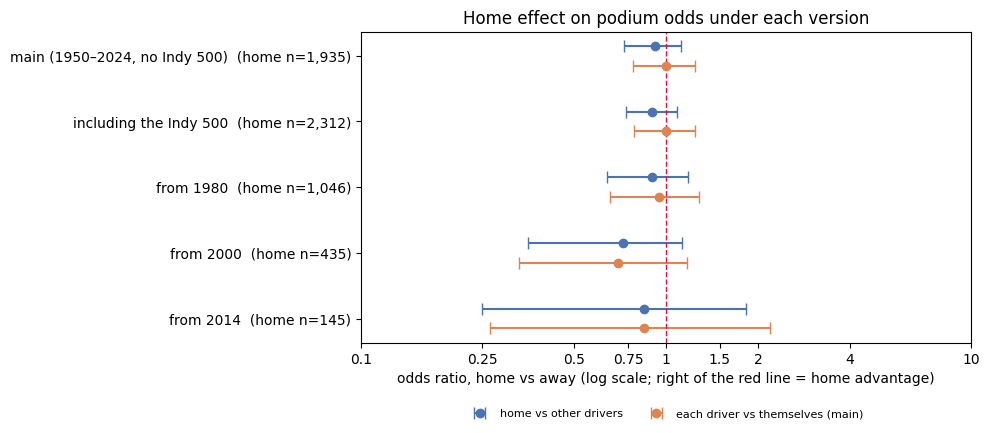

In [579]:
fig, ax = plt.subplots(figsize=(10, 4.5))
y = np.arange(len(sens))[::-1]
for off, pre, col, lab in [(0.15, "vs other", AWAY_COLOR, "home vs other drivers"),
                           (-0.15, "vs themselves", HOME_COLOR, "each driver vs themselves (main)")]:
    o = sens["vs other drivers"] if pre == "vs other" else sens["vs themselves"]
    lo, hi = sens[f"{pre}: lo"].clip(lower=0.1), sens[f"{pre}: hi"].clip(upper=10)   # keep very wide ranges on the chart
    ax.errorbar(o, y + off, xerr=[o - lo, hi - o], fmt="o", color=col, capsize=4, label=lab)
ax.axvline(1, color="crimson", ls="--", lw=1)
ax.set_yticks(y); ax.set_yticklabels([f"{v}  (home n={n:,})" for v, n in zip(sens.version, sens["home starts"])])
ax.set_xscale("log")
ticks = [0.1, 0.25, 0.5, 0.75, 1, 1.5, 2, 4, 10]
ax.set_xticks(ticks); ax.set_xticklabels([f"{t:g}" for t in ticks]); ax.minorticks_off()
ax.set(xlabel="odds ratio, home vs away (log scale; right of the red line = home advantage)",
       title="Home effect on podium odds under each version")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=8, frameon=False)
plt.tight_layout(); savefig("q2_03_sensitivity"); plt.show()

In [580]:
sens["verdict (vs themselves)"] = [verdict(l, h) for l, h in zip(sens["vs themselves: lo"], sens["vs themselves: hi"])]
counts = sens["verdict (vs themselves)"].value_counts()
md("**Reading:** each driver compared with themselves gives " +
   ", ".join(f"**{v}** in {n} of {len(sens)} versions" for v, n in counts.items()) +
   ". A version that disagrees with the rest should be read as a hint, not a finding (see the note above).")

**Reading:** each driver compared with themselves gives **no detectable difference** in 5 of 5 versions. A version that disagrees with the rest should be read as a hint, not a finding (see the note above).

### 9. Answer and limitations

#### 9.1 Summary

In [581]:
main_verdict = verdict(within["lo"], within["hi"])
summary = pd.DataFrame([
    {"step": "Raw comparison (no control)", "result": f"home {raw_home['podium rate']:.1%} vs away {raw_away['podium rate']:.1%}",
     "what it means": "misleading: home drivers start further back"},
    {"step": "Home vs other drivers (exact slot × decade, drivers redrawn)",
     "result": f"OR {or_text(between['or'], between['lo'], between['hi'])}", "what it means": verdict(between["lo"], between["hi"])},
    {"step": "Each driver vs themselves (main result)",
     "result": f"OR {or_text(within['or'], within['lo'], within['hi'])}", "what it means": main_verdict},
    {"step": "Same, without the dual-nationality rule (6.4)",
     "result": f"OR {fmt_or(without_rule, 'within')}",
     "what it means": verdict(without_rule["within"]["lo"], without_rule["within"]["hi"])},
])
table(summary, caption="Q2: from the raw comparison to the main result")

step,result,what it means
Raw comparison (no control),home 11.6% vs away 13.7%,misleading: home drivers start further back
"Home vs other drivers (exact slot × decade, drivers redrawn)",OR 0.92 (0.73 – 1.12),no detectable difference
Each driver vs themselves (main result),OR 1.00 (0.78 – 1.24),no detectable difference
"Same, without the dual-nationality rule (6.4)",OR 1.00 (0.78 – 1.24),no detectable difference


In [582]:
if main_verdict == "no detectable difference":
    answer = (f"**No detectable home advantage.** Compared with themselves, from the same grid slot in the same decade, "
              f"drivers reach the podium about as often at home as elsewhere (OR {or_text(within['or'], within['lo'], within['hi'])}). "
              f"The data rules out a large advantage: at most about {best['largest possible gain (points)']:.0f} percentage points "
              f"of podium chance for a {best['starting slot']} starter.")
else:
    answer = (f"**A {main_verdict}.** Compared with themselves, from the same grid slot in the same decade, drivers' podium odds "
              f"at home are {or_text(within['or'], within['lo'], within['hi'])} times their odds elsewhere.")
md("**Q2 answer:** " + answer)

**Q2 answer:** **No detectable home advantage.** Compared with themselves, from the same grid slot in the same decade, drivers reach the podium about as often at home as elsewhere (OR 1.00 (0.78 – 1.24)). The data rules out a large advantage: at most about 5 percentage points of podium chance for a P3 starter.

#### 9.2 Limitations

- **Nationality is a proxy for "home".** Ergast stores one nationality per driver. Drivers with dual nationality, or who grew up in another country, are mapped to one country only. The two dual nationalities in the data are at home in both countries; East German and Rhodesian count as not home.
- **Several Grands Prix share a country.** All of them count as home (for example Monza and Imola for Italians), although a driver may feel at home at only one of them.
- **Home advantage could work through qualifying.** The question asks about podiums *after* controlling for the grid slot, so any advantage that shows up as a better grid slot at home is deliberately not counted here.
- **Podiums are rare from the back.** Starts from P11 onwards carry almost no information about podiums, so the evidence comes mostly from starts in the top 10.
- **Within-driver comparison uses fewer starts.** Only home starts with a matching away start by the same driver, slot and decade count. This is the price of a fairer comparison.
- **Shared drives (1950–1960):** each car's podium counts once; which of the sharing drivers keeps it is not recorded in the data, so the first-listed one is kept.
- **Descriptive only:** these are associations, not causes.

## Q3: Which constructors have the highest mechanical-retirement rate in 2014–2021 vs 2022–2024?

**The question has two parts:**
1. **Which constructors break down most often** in each period?
2. **What changed between the periods**, overall and for each team?

**Unit:** "constructor" means the **team name as entered** in Ergast. Renamed teams (Toro Rosso → AlphaTauri → RB, and so on) are grouped by factory only in section 7, to compare the same team across 2022.

Each step is written as *what we do* → *why* → *the result*. Where an earlier section of this notebook already established something, Q3 points to it and only states what it means for this question.

#### 1.1 Analysis choices

| Setting | Value | What it controls | Explained in |
|---|---|---|---|
| `FIRST_SEASON` / `SPLIT` | 2014 / 2022 | The two periods: 2014–2021 and 2022–`LAST_SEASON` (2024) | 2 |
| `K_VALUES` / `K_MAIN` | 10, 20, 40 / 20 | Strength of the Bayesian average (a quarter, half and one season of starts) | 5.1 |
| `MIN_STARTS` / `MIN_STARTS_VALUES` | 20 / 10, 20, 40 | Minimum starts for a constructor to be ranked | 5.1 |
| `TOP` | 3 | Size of the "top group" | 5.1 |
| `LATE_PRE` | 2019 | Start of the "just before 2022" comparison window (2019–2021) | 6 |

In [583]:
FIRST_SEASON, SPLIT = 2014, 2022
K_VALUES = [10, 20, 40]     # imaginary average starts: a quarter, half and one season of a two-car team
K_MAIN = 20
MIN_STARTS = 20             # about half a season for a two-car team
MIN_STARTS_VALUES = [10, 20, 40]
TOP = 3
LATE_PRE = 2019             # 2019–2021: the three seasons just before the 2022 rules

In [584]:
P1, P2 = f"{FIRST_SEASON}–{SPLIT - 1}", f"{SPLIT}–{LAST_SEASON}"
PERIODS = [P1, P2]
P_COLORS = {P1: "#C44E52", P2: "#DD8452"}
FIG_DIR = "figures_q3"
os.makedirs(FIG_DIR, exist_ok=True)

### 2. Rows used

Q3 starts from `results_unique` for 2014–2024 and joins the season, the status with its group, the constructor and the driver's surname. What the earlier sections mean for Q3:

- **Shared drives and the Indianapolis 500** (results and races sections): both end long before 2014, so they do not touch Q3.
- **Drivers who never started** (results, *Decision: `grid` = 0*): `never_ran` marks grid 0 and 0 laps. A few drivers in 2014–2024 have a failure status but never started; Q3 leaves them out of the starts (3.2).
- **Status groups** (status, *grouping the labels for the mechanical-retirement question*): every label already sits in one of eight groups. Q3 uses these groups as they are (section 3).
- **Constructors** (constructors, *is one constructorId one continuous team*): Q3 joins on `constructorId`. The long gaps found there (for example Mercedes 1955 → 2010, Aston Martin 1960 → 2021) all lie before 2014, so inside Q3's window each id is one continuous entry. Renamed teams have separate ids, which Part C handles.
- **Timing** (status section, leakage check): the status is only known after the race, so it is never a model input. Here it is the *answer* to a descriptive question.

**Grain:** one car (one driver) entering one race, 2014–2024.

In [585]:
q3_base = (results_unique[["raceId", "driverId", "constructorId", "statusId", "never_ran"]]
           .merge(races[["raceId", "year", "name"]].rename(columns={"name": "race_name"}), on="raceId", how="left", validate="m:1")
           .merge(status[["statusId", "status", "group"]], on="statusId", how="left", validate="m:1")
           .merge(constructors[["constructorId", "constructorRef", "name"]].rename(columns={"name": "constructor"}),
                  on="constructorId", how="left", validate="m:1")
           .merge(drivers[["driverId", "surname"]], on="driverId", how="left", validate="m:1"))
q3_base = q3_base[q3_base.year.between(FIRST_SEASON, LAST_SEASON)].copy()
q3_base["period"] = np.where(q3_base.year < SPLIT, P1, P2)
assert q3_base[["year", "status", "group", "constructor"]].notna().all().all()

In [586]:
table(q3_base.groupby("period").agg(seasons=("year", "nunique"), races=("raceId", "nunique"),
                                    constructors=("constructorId", "nunique"), entries=("driverId", "size")).reset_index(),
      caption="The analysis table by period")

period,seasons,races,constructors,entries
2014–2021,8,160,19,3267
2022–2024,3,68,12,1359


### 3. What counts as a mechanical retirement?

#### 3.1 The definition

A **mechanical retirement** is a race **start** that ended early because a **part of the car failed**: not a crash, not the driver, not a decision by the stewards.

The status section (*grouping the labels for the mechanical-retirement question*) already placed every label in a group and showed, per period, the share of starts ending in each: clear mechanical failures fell from **9.2% to 5.6%**, and from 11.4% to 7.0% with the grey zone, while accidents stayed at 6.6%. It also decided that the question reports the clear-only rate and the grey zone as a range. Q3 uses the groups like this:

| Group | Role in Q3 |
|---|---|
| `mechanical (clear)` | **numerator of the main rate** |
| `grey zone` | added to the numerator for the **upper bound** only |
| `finished`, `finished, laps down`, `accident or collision`, `disqualified or excluded`, `driver health` | starts that did not end in a mechanical failure |
| `did not start` | not a start: left out |

**Race start** = not in the `did not start` group **and** not `never_ran`. Because of the second condition, Q3's rates can differ very slightly from the status section's shares (3.2).

#### 3.2 Drivers who never started, although their status is not "did not start"

Some drivers have a failure status but grid 0 and 0 laps: their car failed before the start (for example on the way to the grid). The results section's `never_ran` flag catches them, while the status section's shares still count them as starts. They never started, so they cannot retire from the race, and Q3 leaves them out of both the numerator and the denominator.

In [587]:
ns = q3_base[q3_base.never_ran & (q3_base.group != "did not start")].sort_values("year")
table(ns[["year", "race_name", "surname", "constructor", "status", "group"]].rename(columns={"race_name": "race"}),
      caption="Left out of the starts: never_ran, but the status is not 'did not start'")

year,race,surname,constructor,status,group
2015,Malaysian Grand Prix,Stevens,Manor Marussia,Fuel system,mechanical (clear)
2017,Malaysian Grand Prix,Räikkönen,Ferrari,Battery,mechanical (clear)
2021,Italian Grand Prix,Tsunoda,AlphaTauri,Brakes,mechanical (clear)
2023,São Paulo Grand Prix,Leclerc,Ferrari,Engine,mechanical (clear)


#### 3.3 Judgment calls in the grouping

The status section names the unclear labels and puts them in the grey zone. The table adds, for the labels that occur in 2014–2024, *why* each placement is a judgment call and how often it happens. The upper-bound rate (grey zone counted) shows how much the grey-zone labels matter.

In [588]:
EDGE_CASES = [
    ("Retired", "No reason given: could be a failure, damage or a strategic retirement to save parts."),
    ("Wheel nut", "Usually a pit-stop error by the crew, not a failed part."),
    ("Wheel", "A wheel coming loose can be a failed part or a pit-stop error."),
    ("Puncture", "Usually debris or contact, sometimes a tyre failure."),
    ("Withdrew", "Can be a car failure before the start, but the car never started, so it cannot retire."),
    ("Disqualified", "The car started (and often finished); a stewards' decision, not a failure."),
    ("Brakes", "Counted as a failed part, although overheated brakes can come from how the car is driven."),
    ("Overheating", "Counted as a failed part, although debris in a radiator can cause it."),
    ("Undertray", "Could be a failed part or damage from kerbs."),
    ("Vibrations", "Could be a failing part or worn tyres."),
    ("Seat", "A failed part, though not a powertrain one."),
    ("Driver Seat", "A failed part, though not a powertrain one."),
    ("Safety belt", "A failed part, though not a powertrain one."),
]
edge = pd.DataFrame(EDGE_CASES, columns=["status", "why it is a judgment call"])
edge.insert(1, "team's group", edge.status.map(status.set_index("status").group))
edge["entries 2014–2024"] = edge.status.map(q3_base.status.value_counts()).fillna(0).astype(int)
table(edge[edge["entries 2014–2024"] > 0], caption="Judgment calls that occur in 2014–2024")

status,team's group,why it is a judgment call,entries 2014–2024
Retired,grey zone,"No reason given: could be a failure, damage or a strategic retirement to save parts.",50
Wheel nut,grey zone,"Usually a pit-stop error by the crew, not a failed part.",3
Wheel,grey zone,A wheel coming loose can be a failed part or a pit-stop error.,11
Puncture,grey zone,"Usually debris or contact, sometimes a tyre failure.",7
Withdrew,did not start,"Can be a car failure before the start, but the car never started, so it cannot retire.",14
Disqualified,disqualified or excluded,"The car started (and often finished); a stewards' decision, not a failure.",11
Brakes,mechanical (clear),"Counted as a failed part, although overheated brakes can come from how the car is driven.",49
Overheating,mechanical (clear),"Counted as a failed part, although debris in a radiator can cause it.",8
Undertray,grey zone,Could be a failed part or damage from kerbs.,4
Vibrations,grey zone,Could be a failing part or worn tyres.,2


In [589]:
q3_base["started"] = ((q3_base.group != "did not start") & ~q3_base.never_ran).astype(int)
q3_base["mech"] = (q3_base.group == "mechanical (clear)").astype(int)
q3_base["mech_upper"] = q3_base.group.isin(["mechanical (clear)", "grey zone"]).astype(int)   # upper bound
starts = q3_base[q3_base.started == 1].copy()                                                # the denominator

### 4. What is already known, and what Q3 adds

The status section's figure (*Share of race starts that ended for each reason, per period*) already shows how starts ended in each period, so Q3 does not repeat it. It leaves three questions open, which the rest of Q3 answers:
- **Which constructors** are behind the failures in each period? (Part A, section 5)
- Is the fall from 9.2% to 5.6% **bigger than luck**, and did it happen **in 2022** or before? (Part B, section 6, with a season-by-season chart)
- Did **the same team** become more or less reliable across 2022? (Part C, section 7)

### 5. Part A: Which constructors break down most often?

#### 5.1 How constructors are ranked

The same problem as in Q1: a constructor that raced only one season has few starts, so its rate can be very high or very low by luck. For example, Caterham raced only one season in this window (2014), so its rate rests on about 34 starts.

We report three numbers per constructor and period:
1. **Raw rate** = mechanical retirements ÷ starts. What happened; shown, but not used for ranking.
2. **Wilson range (95%)** = where the true rate probably lies. Used for error bars only.
3. **Bayesian average** = the number **used for ranking**:

> adjusted rate = (mechanical retirements + k × period average) ÷ (starts + k)

Every constructor starts with **k imaginary starts at its period's average rate**, then its real results are added. Teams with several seasons of data keep their own rate; a team with one season is pulled towards the average until its data shows it is really different. The period's own average is used, so a general change in reliability between the periods does not move teams around in the ranking.

**Why k = 10, 20 and 40 (and not Q1's 5, 10, 20):** k should be measured against how much data a typical unit has. A circuit in Q1 had about 20 front-row starts per era; a two-car team has about **40 starts per season**. So:
- k = 10: a quarter of a season, a light pull;
- **k = 20 (main): half a season;**
- k = 40: a full season, a heavy pull.

**Minimum sample (20 starts, about half a season)** keeps the tables readable; 5.5 checks 10 and 40.

**Top group:** the teams in the top 3 under **every** value of k. Teams with exactly the same adjusted rate share a rank, so a tie can make the group slightly larger.

In [590]:
def constructor_table(d, event="mech", min_n=MIN_STARTS, k_values=K_VALUES):
    """One row per constructor and period: raw rate, Wilson range, Bayesian averages and ranks."""
    avg = d.groupby("period")[event].mean()                    # period average over ALL constructors
    t = (d.groupby(["period", "constructorId"])
           .agg(constructor=("constructor", "first"), seasons=("year", "nunique"),
                starts=(event, "size"), events=(event, "sum"))
           .reset_index())
    t["raw rate"] = t.events / t.starts
    t["ci_lo"], t["ci_hi"] = wilson(t.events, t.starts)
    t["period average"] = t.period.map(avg)
    for k in k_values:
        t[f"adj_k{k}"] = bayes_avg(t.events, t.starts, t["period average"], k)
    t = t[t.starts >= min_n].copy()
    for k in k_values:
        t[f"rank_k{k}"] = t.groupby("period")[f"adj_k{k}"].rank(ascending=False, method="min").astype(int)
    sort_k = K_MAIN if K_MAIN in k_values else k_values[0]
    return t.sort_values(["period", f"rank_k{sort_k}"]).reset_index(drop=True)

In [591]:
RANK_COLS = [f"rank_k{k}" for k in K_VALUES]

def top_group(t, top=TOP):
    """Constructors in the top `top` under every value of k."""
    return t[(t[RANK_COLS] <= top).all(axis=1)]

#### 5.2 The ranking

In [592]:
ct = constructor_table(starts)
ct_upper = constructor_table(starts, event="mech_upper")   # upper bound: grey-zone statuses counted

def ranking_table(p):
    """Formatted ranking of one period."""
    t = ct[ct.period == p]
    up = ct_upper[ct_upper.period == p].set_index("constructorId")["raw rate"]
    table(pd.DataFrame({
        "rank": t[f"rank_k{K_MAIN}"], "constructor": t.constructor, "seasons": t.seasons, "starts": t.starts,
        "mechanical retirements": t.events, "raw rate": t["raw rate"], "95% Wilson range": pct_range(t.ci_lo, t.ci_hi, digits=1),
        f"adjusted rate (k={K_MAIN})": t[f"adj_k{K_MAIN}"], "upper bound (grey zone counted)": t.constructorId.map(up),
    }), pct1=["raw rate", f"adjusted rate (k={K_MAIN})", "upper bound (grey zone counted)"],
        caption=f"{p}: mechanical-retirement rate per start (period average {t['period average'].iloc[0]:.1%})")

In [593]:
ranking_table(P1)

rank,constructor,seasons,starts,mechanical retirements,raw rate,95% Wilson range,adjusted rate (k=20),upper bound (grey zone counted)
1,Caterham,1,34,8,23.5%,12.4% – 40.0%,18.2%,32.4%
2,Lotus F1,2,75,13,17.3%,10.4% – 27.4%,15.6%,24.0%
3,Toro Rosso,6,242,39,16.1%,12.0% – 21.3%,15.6%,18.2%
4,McLaren,8,318,43,13.5%,10.2% – 17.7%,13.3%,16.0%
5,Renault,5,200,27,13.5%,9.4% – 18.9%,13.1%,16.5%
6,Sauber,5,200,22,11.0%,7.4% – 16.1%,10.8%,13.5%
7,Red Bull,8,319,34,10.7%,7.7% – 14.5%,10.6%,11.9%
8,Marussia,1,31,3,9.7%,3.3% – 24.9%,9.4%,9.7%
9,Racing Point,2,76,7,9.2%,4.5% – 17.8%,9.2%,10.5%
10,AlphaTauri,2,77,7,9.1%,4.5% – 17.6%,9.1%,10.4%


In [594]:
ranking_table(P2)

rank,constructor,seasons,starts,mechanical retirements,raw rate,95% Wilson range,adjusted rate (k=20),upper bound (grey zone counted)
1,Alfa Romeo,2,88,11,12.5%,7.1% – 21.0%,11.2%,12.5%
2,Alpine F1 Team,3,136,15,11.0%,6.8% – 17.4%,10.3%,11.0%
3,AlphaTauri,2,88,6,6.8%,3.2% – 14.1%,6.6%,8.0%
4,Williams,3,134,7,5.2%,2.6% – 10.4%,5.3%,8.2%
5,Ferrari,3,135,7,5.2%,2.5% – 10.3%,5.2%,7.4%
6,Haas F1 Team,3,135,6,4.4%,2.1% – 9.4%,4.6%,5.2%
7,RB F1 Team,1,48,2,4.2%,1.2% – 14.0%,4.6%,10.4%
8,Mercedes,3,136,6,4.4%,2.0% – 9.3%,4.6%,4.4%
9,McLaren,3,136,5,3.7%,1.6% – 8.3%,3.9%,3.7%
9,Red Bull,3,136,5,3.7%,1.6% – 8.3%,3.9%,4.4%


#### 5.3 The ranking with its uncertainty

**What the figure shows:** the diamond is the adjusted rate used for ranking; the grey dot and bar are the raw rate and its 95% Wilson range; the black tick is the upper bound (grey-zone statuses counted); `n` is the number of starts.

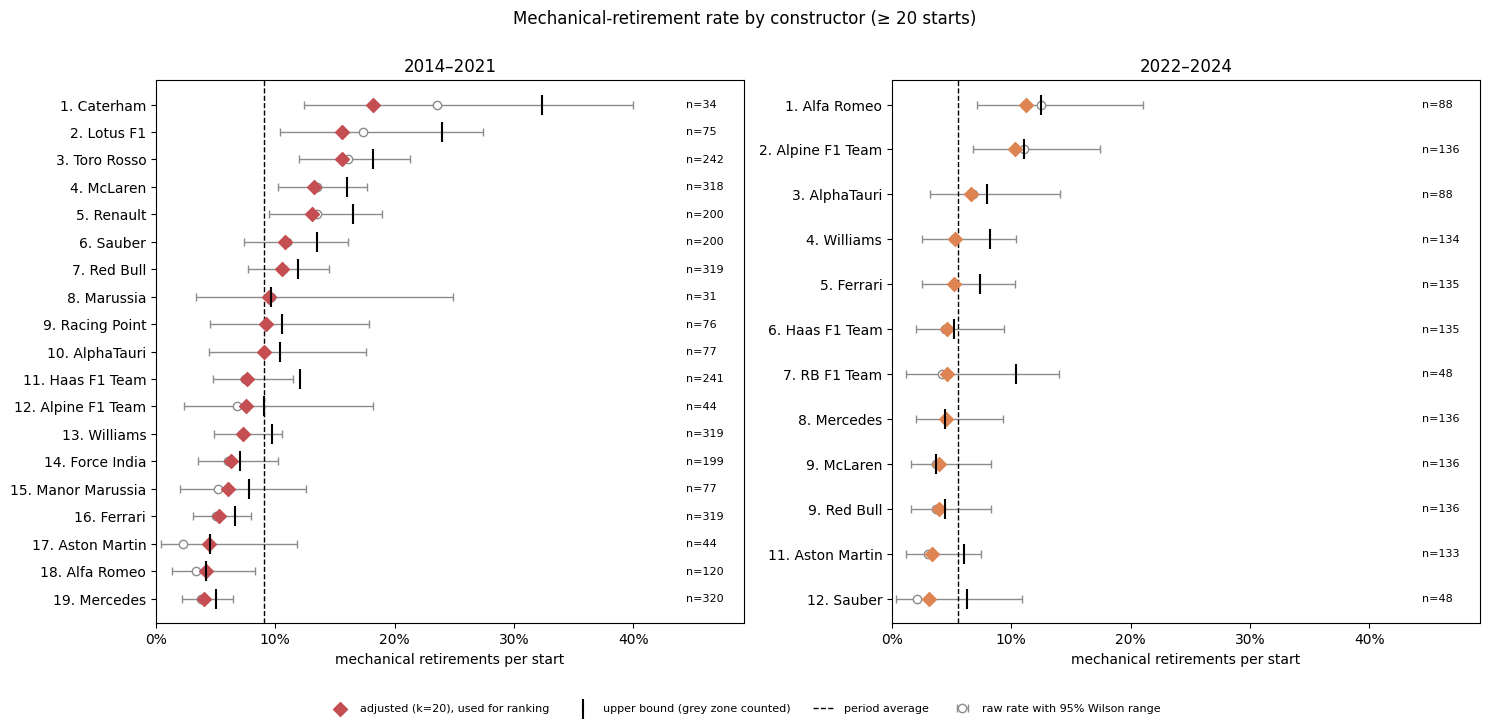

In [595]:
xmax = max(ct.ci_hi.max(), ct_upper["raw rate"].max()) * 1.1
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True)
for ax, p in zip(axes, PERIODS):
    t = ct[ct.period == p].iloc[::-1]
    up = ct_upper[ct_upper.period == p].set_index("constructorId").reindex(t.constructorId)["raw rate"].values
    y = np.arange(len(t))
    ax.errorbar(t["raw rate"], y, xerr=[(t["raw rate"] - t.ci_lo).values, (t.ci_hi - t["raw rate"]).values],
                fmt="o", color=GREY, mfc="white", capsize=3, lw=1, label="raw rate with 95% Wilson range")
    ax.scatter(t[f"adj_k{K_MAIN}"], y, marker="D", s=50, color=P_COLORS[p], zorder=4, label=f"adjusted (k={K_MAIN}), used for ranking")
    ax.scatter(up, y, marker="|", s=200, color="black", zorder=5, label="upper bound (grey zone counted)")
    ax.axvline(t["period average"].iloc[0], color="black", ls="--", lw=1, label="period average")
    ax.set_yticks(y); ax.set_yticklabels([f"{r}. {c}" for r, c in zip(t[f"rank_k{K_MAIN}"], t.constructor)])
    for yi, n in zip(y, t.starts):
        ax.text(xmax * 1.01, yi, f"n={n}", va="center", fontsize=8)
    ax.set(title=p, xlim=(0, xmax * 1.12), xlabel="mechanical retirements per start")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"Mechanical-retirement rate by constructor (≥ {MIN_STARTS} starts)", y=1.0)
plt.tight_layout(rect=(0, 0.04, 1, 1)); savefig("q3_02_rate_by_constructor"); plt.show()

#### 5.4 Does the ranking depend on k?

**What the figure shows:** each constructor's rank under k = 10, 20 and 40. Dark cells are the top 3; a row dark in all three columns belongs to the **top group**.

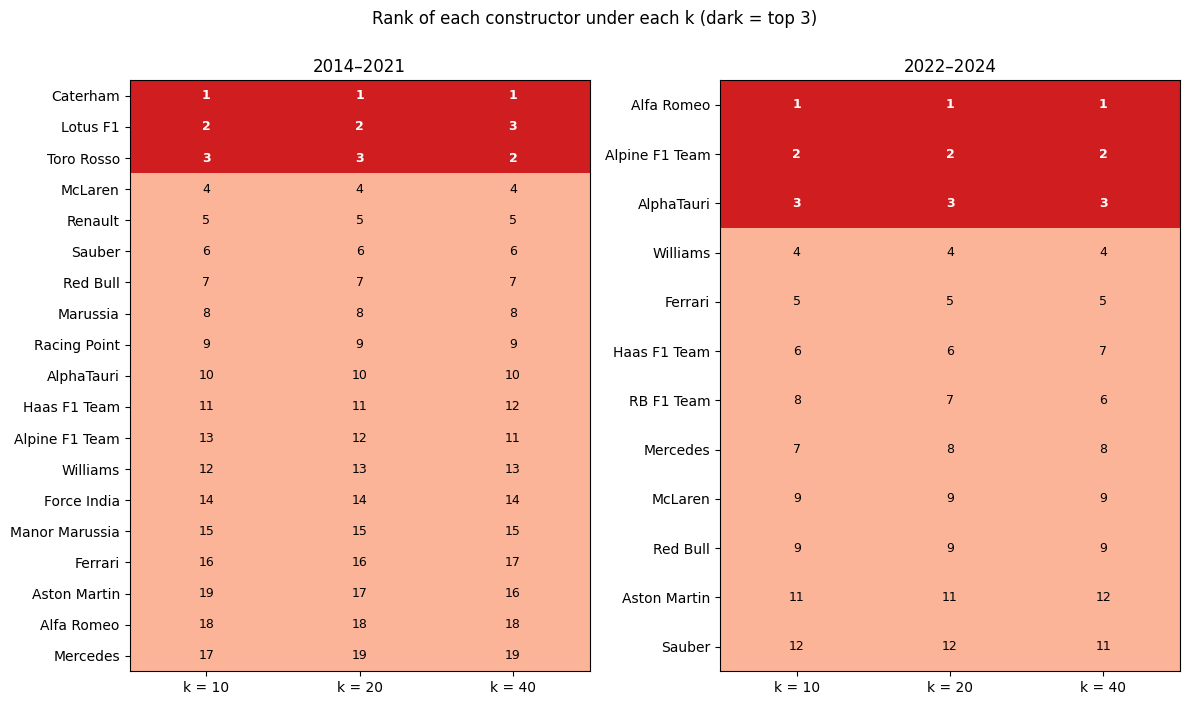

In [596]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7))
for ax, p in zip(axes, PERIODS):
    t = ct[ct.period == p]
    m = t[RANK_COLS].values
    ax.imshow(np.where(m <= TOP, 0, 1), cmap="Reds_r", vmin=-0.6, vmax=1.6, aspect="auto")
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            in_top = m[i, j] <= TOP
            ax.text(j, i, m[i, j], ha="center", va="center", fontsize=9,
                    color="white" if in_top else "black", fontweight="bold" if in_top else None)
    ax.set_xticks(range(len(K_VALUES))); ax.set_xticklabels([f"k = {k}" for k in K_VALUES])
    ax.set_yticks(range(len(t))); ax.set_yticklabels(t.constructor)
    ax.grid(False); ax.set_title(p)
fig.suptitle(f"Rank of each constructor under each k (dark = top {TOP})", y=1.0)
plt.tight_layout(); savefig("q3_03_rank_by_k"); plt.show()

In [597]:
tg_rows = []
for p in PERIODS:
    t = ct[ct.period == p]
    robust = top_group(t)
    some = t[(t[RANK_COLS] <= TOP).any(axis=1) & ~t.constructorId.isin(robust.constructorId)]
    tg_rows.append({"period": p, f"top group (top {TOP} under every k)": ", ".join(robust.constructor) or "none",
                    f"top {TOP} under some k only": ", ".join(some.constructor) or "none"})
table(pd.DataFrame(tg_rows), caption="Top group per period")

period,top group (top 3 under every k),top 3 under some k only
2014–2021,"Caterham, Lotus F1, Toro Rosso",none
2022–2024,"Alfa Romeo, Alpine F1 Team, AlphaTauri",none


#### 5.5 Does the ranking depend on the minimum sample, or on the grey-zone statuses?

**Check 1:** rebuild the ranking with a minimum of 10, 20 and 40 starts (a quarter, half and one season).

**Check 2:** rebuild it with the **upper-bound** definition (grey-zone statuses counted as mechanical), and measure how similar the two rankings are (Spearman ρ: 1 = same order, 0 = unrelated).

In [598]:
mn_rows = []
for m in MIN_STARTS_VALUES:
    t_m = constructor_table(starts, min_n=m)
    for p in PERIODS:
        tp = t_m[t_m.period == p]
        mn_rows.append({"period": p, "minimum starts": m, "constructors ranked": len(tp),
                        "top group": ", ".join(top_group(tp).constructor) or "none"})
table(pd.DataFrame(mn_rows).sort_values(["period", "minimum starts"]), caption="Top group under different minimum samples")

period,minimum starts,constructors ranked,top group
2014–2021,10,19,"Caterham, Lotus F1, Toro Rosso"
2014–2021,20,19,"Caterham, Lotus F1, Toro Rosso"
2014–2021,40,17,"Lotus F1, Toro Rosso, McLaren"
2022–2024,10,12,"Alfa Romeo, Alpine F1 Team, AlphaTauri"
2022–2024,20,12,"Alfa Romeo, Alpine F1 Team, AlphaTauri"
2022–2024,40,12,"Alfa Romeo, Alpine F1 Team, AlphaTauri"


In [599]:
amb_rows = []
for p in PERIODS:
    s = ct[ct.period == p].set_index("constructorId")[f"adj_k{K_MAIN}"]
    u = ct_upper[ct_upper.period == p].set_index("constructorId")[f"adj_k{K_MAIN}"]
    j = pd.concat([s, u], axis=1, keys=["strict", "upper"]).dropna()
    amb_rows.append({"period": p, "constructors": len(j),
                     "ranking agreement strict vs upper bound (ρ)": stats.spearmanr(j.strict, j.upper)[0],
                     "top group, strict": ", ".join(top_group(ct[ct.period == p]).constructor) or "none",
                     "top group, upper bound": ", ".join(top_group(ct_upper[ct_upper.period == p]).constructor) or "none"})
table(pd.DataFrame(amb_rows), dec2=["ranking agreement strict vs upper bound (ρ)"],
      caption="Does counting the grey-zone statuses change the answer?")

period,constructors,ranking agreement strict vs upper bound (ρ),"top group, strict","top group, upper bound"
2014–2021,19,0.97,"Caterham, Lotus F1, Toro Rosso","Caterham, Lotus F1, Toro Rosso"
2022–2024,12,0.73,"Alfa Romeo, Alpine F1 Team, AlphaTauri","Alfa Romeo, Alpine F1 Team, RB F1 Team"


#### 5.6 Part A answer

In [600]:
lines = []
for p in PERIODS:
    t = ct[ct.period == p]
    robust = top_group(t)
    desc = "; ".join(f"**{c}** ({e}/{n} starts, about {a:.1%} adjusted)"
                     for c, e, n, a in zip(robust.constructor, robust.events, robust.starts, robust[f"adj_k{K_MAIN}"])
                     ) or f"no constructor is in the top {TOP} under every k"
    low = t.nsmallest(2, f"adj_k{K_MAIN}")
    lines.append(f"- **{p}** (period average {t['period average'].iloc[0]:.1%}): {desc}. "
                 f"Most reliable: {', '.join(f'{c} ({a:.1%})' for c, a in zip(low.constructor, low[f'adj_k{K_MAIN}']))}.")
md(f"**Highest mechanical-retirement rate (top group: top {TOP} under k = 10, 20 and 40, minimum {MIN_STARTS} starts):**\n"
   + "\n".join(lines) + "\n\nCheck the tables in 5.5: teams that stay in the top group under every cutoff and both "
   "definitions are the most reliable result.")

**Highest mechanical-retirement rate (top group: top 3 under k = 10, 20 and 40, minimum 20 starts):**
- **2014–2021** (period average 9.1%): **Caterham** (8/34 starts, about 18.2% adjusted); **Lotus F1** (13/75 starts, about 15.6% adjusted); **Toro Rosso** (39/242 starts, about 15.6% adjusted). Most reliable: Mercedes (4.1%), Alfa Romeo (4.2%).
- **2022–2024** (period average 5.5%): **Alfa Romeo** (11/88 starts, about 11.2% adjusted); **Alpine F1 Team** (15/136 starts, about 10.3% adjusted); **AlphaTauri** (6/88 starts, about 6.6% adjusted). Most reliable: Sauber (3.1%), Aston Martin (3.3%).

Check the tables in 5.5: teams that stay in the top group under every cutoff and both definitions are the most reliable result.

### 6. Part B: Did reliability improve, and was it because of 2022?

**The question behind the question:** the status section showed that clear mechanical failures fell from 9.2% to 5.6% of starts between the two periods. But 2014–2016 were the first, troubled seasons of the turbo-hybrid engines. If reliability had **already** improved by 2019–2021, the drop has little to do with the 2022 rules. Two steps check this:
1. a season-by-season chart;
2. the same comparison against **2019–2021**, the three seasons just before the new rules (the same length as 2022–2024).

#### 6.1 Season by season

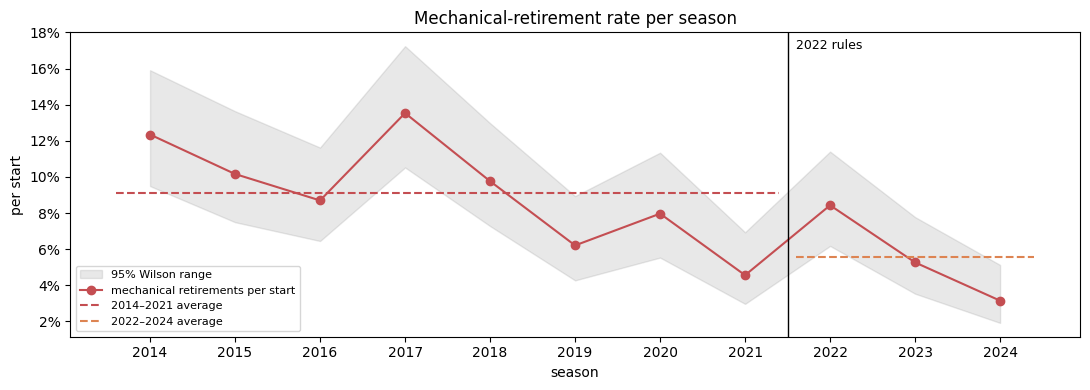

In [601]:
season = starts.groupby("year").agg(starts=("mech", "size"), mech=("mech", "sum")).reset_index()
season["rate"] = season.mech / season.starts
season["ci_lo"], season["ci_hi"] = wilson(season.mech, season.starts)

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(season.year, season.ci_lo, season.ci_hi, color=GREY, alpha=0.2, label="95% Wilson range")
ax.plot(season.year, season.rate, marker="o", color="#C44E52", label="mechanical retirements per start")
for p, (a, b) in {P1: (FIRST_SEASON, SPLIT - 1), P2: (SPLIT, LAST_SEASON)}.items():
    s = season[season.year.between(a, b)]
    ax.hlines(s.mech.sum() / s.starts.sum(), a - 0.4, b + 0.4, color=P_COLORS[p], ls="--", label=f"{p} average")
ax.axvline(SPLIT - 0.5, color="black", lw=1); ax.text(SPLIT - 0.4, ax.get_ylim()[1] * 0.95, f"{SPLIT} rules", fontsize=9)
ax.set(xlabel="season", ylabel="per start", title="Mechanical-retirement rate per season")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xticks(season.year); ax.legend(fontsize=8)
plt.tight_layout(); savefig("q3_04_rate_by_season"); plt.show()

In [602]:
table(pd.DataFrame({"season": season.year, "starts": season.starts, "mechanical retirements": season.mech,
                    "rate": season.rate, "95% Wilson range": pct_range(season.ci_lo, season.ci_hi, digits=1)}),
      pct1=["rate"], caption="Mechanical-retirement rate per season")

season,starts,mechanical retirements,rate,95% Wilson range
2014,405,50,12.3%,9.5% – 15.9%
2015,374,38,10.2%,7.5% – 13.6%
2016,460,40,8.7%,6.5% – 11.6%
2017,399,54,13.5%,10.5% – 17.2%
2018,420,41,9.8%,7.3% – 13.0%
2019,419,26,6.2%,4.3% – 8.9%
2020,339,27,8.0%,5.5% – 11.3%
2021,439,20,4.6%,3.0% – 6.9%
2022,439,37,8.4%,6.2% – 11.4%
2023,437,23,5.3%,3.5% – 7.8%


#### 6.2 Is the change real, and when did it happen?

**What we compare:**
- **2014–2021 vs 2022–2024:** the question's two periods.
- **2019–2021 vs 2022–2024:** the three seasons just before the new rules against the three seasons under them. If the 2022 rules made the difference, this change should also be clear.
- **2014–2016 vs 2017–2021:** where the drop inside the hybrid era happened, for context.

**Two ways of measuring uncertainty:**
- *Every start independent* (what a standard chi-square test assumes): each car start is a separate coin flip.
- *Whole team-seasons redrawn* (the honest one): a team's two cars share the same engine and parts all season, so their failures go together. We redraw whole team-seasons (for example "McLaren 2015", with both cars and every race) at random, 1,000 times, and recompute the change. The middle 95% of the results is the range. Some team-seasons are drawn twice and some not at all, which mimics having seen a different set of team-seasons.

**Reading the result:** a change is **clear** when its range does not include 0.

In [603]:
team_season = (starts.groupby(["constructorId", "year"])
                     .agg(mech=("mech", "sum"), n=("mech", "size")).reset_index())

def window(a, b):
    """Team-seasons inside seasons a..b."""
    return team_season[team_season.year.between(a, b)]

def independent_range(wa, wb, z=1.96):
    """95% range of the change in rate (points) if every start were independent."""
    pa, na = wa.mech.sum() / wa.n.sum(), wa.n.sum()
    pb, nb = wb.mech.sum() / wb.n.sum(), wb.n.sum()
    se = np.sqrt(pa * (1 - pa) / na + pb * (1 - pb) / nb)
    return (pb - pa - z * se) * 100, (pb - pa + z * se) * 100

In [604]:
def team_season_range(wa, wb, B=N_BOOT, seed=SEED):
    """95% range of the change in rate (points) when whole team-seasons are redrawn B times."""
    rng = np.random.default_rng(seed)
    ia = rng.integers(0, len(wa), size=(B, len(wa)))
    ib = rng.integers(0, len(wb), size=(B, len(wb)))
    ra = wa.mech.values[ia].sum(axis=1) / wa.n.values[ia].sum(axis=1)
    rb = wb.mech.values[ib].sum(axis=1) / wb.n.values[ib].sum(axis=1)
    return tuple(np.percentile((rb - ra) * 100, [2.5, 97.5]))

In [605]:
COMPARISONS = [("the question's periods: 2014–2021 vs 2022–2024", (FIRST_SEASON, SPLIT - 1), (SPLIT, LAST_SEASON)),
               (f"just before vs after: {LATE_PRE}–{SPLIT - 1} vs {SPLIT}–{LAST_SEASON}", (LATE_PRE, SPLIT - 1), (SPLIT, LAST_SEASON)),
               ("inside the hybrid era: 2014–2016 vs 2017–2021", (FIRST_SEASON, 2016), (2017, SPLIT - 1))]
cmp_rows = []
for name, (a0, a1), (b0, b1) in COMPARISONS:
    wa, wb = window(a0, a1), window(b0, b1)
    ra, rb = wa.mech.sum() / wa.n.sum(), wb.mech.sum() / wb.n.sum()
    i_lo, i_hi = independent_range(wa, wb)
    t_lo, t_hi = team_season_range(wa, wb)
    cmp_rows.append({"comparison": name, "rate before": ra, "rate after": rb, "change (points)": (rb - ra) * 100,
                     "range, starts independent": f"{i_lo:+.1f} to {i_hi:+.1f}",
                     "range, team-seasons redrawn": f"{t_lo:+.1f} to {t_hi:+.1f}",
                     "clear change?": "yes" if (t_hi < 0 or t_lo > 0) else "no",
                     "_lo": t_lo, "_hi": t_hi})
cmp = pd.DataFrame(cmp_rows)

In [606]:
table(cmp.drop(columns=["_lo", "_hi"]), pct1=["rate before", "rate after"], dec1=["change (points)"],
      caption="Change in mechanical-retirement rate (percentage points; negative = fewer failures)")

comparison,rate before,rate after,change (points),"range, starts independent","range, team-seasons redrawn",clear change?
the question's periods: 2014–2021 vs 2022–2024,9.1%,5.5%,-3.6,-5.1 to -2.0,-5.4 to -1.6,yes
just before vs after: 2019–2021 vs 2022–2024,6.1%,5.5%,-0.6,-2.4 to +1.3,-2.5 to +1.4,no
inside the hybrid era: 2014–2016 vs 2017–2021,10.3%,8.3%,-2.0,-4.1 to +0.1,-4.9 to +0.7,no


In [607]:
main, late = cmp.iloc[0], cmp.iloc[1]
if late["clear change?"] == "yes":
    when = (f"The drop is also clear against the three seasons just before the rules ({late['rate before']:.1%} → "
            f"{late['rate after']:.1%}), so the 2022 period really is more reliable than the end of the previous rules.")
else:
    when = (f"Against the three seasons just before the rules, the change is **not clear** ({late['rate before']:.1%} → "
            f"{late['rate after']:.1%}, range {late['_lo']:+.1f} to {late['_hi']:+.1f} points). Most of the improvement "
            "had already happened before 2022, so it should not be credited to the 2022 rules.")
md(f"""**Reading:**
- **2014–2021 vs 2022–2024:** {main['rate before']:.1%} → {main['rate after']:.1%} ({main['change (points)']:+.1f} points).
  With whole team-seasons redrawn the range is {main['_lo']:+.1f} to {main['_hi']:+.1f} points: wider than if starts were
  independent, {'but still clear of zero' if main['clear change?'] == 'yes' else 'and it includes zero'}.
- **When did it happen?** {when}""")

**Reading:**
- **2014–2021 vs 2022–2024:** 9.1% → 5.5% (-3.6 points).
  With whole team-seasons redrawn the range is -5.4 to -1.6 points: wider than if starts were
  independent, but still clear of zero.
- **When did it happen?** Against the three seasons just before the rules, the change is **not clear** (6.1% → 5.5%, range -2.5 to +1.4 points). Most of the improvement had already happened before 2022, so it should not be credited to the 2022 rules.

### 7. Part C: The same team across 2022 (factory lineage)

#### 7.1 Grouping renamed teams

Several teams changed their entry name while keeping the same factory, staff and car development: Toro Rosso → AlphaTauri → RB, Force India → Racing Point → Aston Martin, Lotus F1 → Renault → Alpine, Sauber ↔ Alfa Romeo, Marussia → Manor. Ergast gives each name its own `constructorId`. To ask "did **this team** become more or less reliable across 2022?", we group names by factory. This is an extra view; Part A keeps the names as entered.

In [608]:
LINEAGE = {
    "toro_rosso": "Faenza (Toro Rosso / AlphaTauri / RB)", "alphatauri": "Faenza (Toro Rosso / AlphaTauri / RB)",
    "rb": "Faenza (Toro Rosso / AlphaTauri / RB)",
    "force_india": "Silverstone (Force India / Racing Point / Aston Martin)",
    "racing_point": "Silverstone (Force India / Racing Point / Aston Martin)",
    "aston_martin": "Silverstone (Force India / Racing Point / Aston Martin)",
    "lotus_f1": "Enstone (Lotus F1 / Renault / Alpine)", "renault": "Enstone (Lotus F1 / Renault / Alpine)",
    "alpine": "Enstone (Lotus F1 / Renault / Alpine)",
    "sauber": "Hinwil (Sauber / Alfa Romeo)", "alfa": "Hinwil (Sauber / Alfa Romeo)",
    "marussia": "Banbury (Marussia / Manor)", "manor": "Banbury (Marussia / Manor)",
}
starts["team"] = starts.constructorRef.map(LINEAGE).fillna(starts.constructor)

In [609]:
names_used = (starts.groupby(["team", "constructor"]).year.agg(["min", "max"]).reset_index()
                    .assign(seasons=lambda d: d["min"].astype(str) + "–" + d["max"].astype(str)))
grouped = names_used.groupby("team").filter(lambda g: len(g) > 1)
table(grouped.groupby("team").apply(lambda g: ", ".join(f"{c} ({s})" for c, s in zip(g.constructor, g.seasons)))
             .rename("names used (seasons)").reset_index(),
      caption="Teams that raced under more than one name, 2014–2024")

/tmp/ipykernel_49/878831809.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  table(grouped.groupby("team").apply(lambda g: ", ".join(f"{c} ({s})" for c, s in zip(g.constructor, g.seasons)))


team,names used (seasons)
Banbury (Marussia / Manor),"Manor Marussia (2015–2016), Marussia (2014–2014)"
Enstone (Lotus F1 / Renault / Alpine),"Alpine F1 Team (2021–2024), Lotus F1 (2014–2015), Renault (2016–2020)"
Faenza (Toro Rosso / AlphaTauri / RB),"AlphaTauri (2020–2023), RB F1 Team (2024–2024), Toro Rosso (2014–2019)"
Hinwil (Sauber / Alfa Romeo),"Alfa Romeo (2019–2023), Sauber (2014–2024)"
Silverstone (Force India / Racing Point / Aston Martin),"Aston Martin (2021–2024), Force India (2014–2018), Racing Point (2019–2020)"


#### 7.2 Change per team, with its uncertainty

**What we do:** for every team that raced in both periods, compare its mechanical-retirement rate before and after 2022.

**Why raw rates here:** every team in this comparison has at least a few seasons in each period (130+ starts), so the Bayesian average would barely change them.

**How the range is measured:** with only three seasons after 2022, redrawing whole seasons for a single team gives too few combinations to be useful. Instead we redraw whole **races** for that team (both of its cars together), 1,000 times. This keeps the two cars of the same race together, but does not capture problems that last a whole season, so these ranges are somewhat optimistic. A change is **clear** when its range does not include 0.

In [610]:
team_race = starts.groupby(["team", "period", "raceId"]).agg(mech=("mech", "sum"), n=("mech", "size")).reset_index()

def team_change(team, B=N_BOOT, seed=SEED):
    """Change in one team's rate (points) between periods, with a range from redrawing its races."""
    rng = np.random.default_rng(seed)
    out = {"team": team}
    sims = []
    for p in PERIODS:
        g = team_race[(team_race.team == team) & (team_race.period == p)]
        idx = rng.integers(0, len(g), size=(B, len(g)))
        out[p], out[f"starts {p}"] = g.mech.sum() / g.n.sum(), int(g.n.sum())
        sims.append(g.mech.values[idx].sum(axis=1) / g.n.values[idx].sum(axis=1))
    out["change (points)"] = (out[P2] - out[P1]) * 100
    out["lo"], out["hi"] = np.percentile((sims[1] - sims[0]) * 100, [2.5, 97.5])
    return out

In [611]:
both = team_race.groupby("team").period.nunique()
lineage_teams = [t for t in both.index[both == 2]
                 if team_race[team_race.team == t].groupby("period").n.sum().min() >= MIN_STARTS]
lin = pd.DataFrame([team_change(t) for t in lineage_teams]).sort_values(P1)
lin["clear change?"] = np.where((lin.hi < 0) | (lin.lo > 0), "yes", "no")

In [612]:
table(pd.DataFrame({"team": lin.team, f"rate {P1}": lin[P1], f"rate {P2}": lin[P2],
                    "change (points)": lin["change (points)"],
                    "95% range (races redrawn)": [f"{a:+.1f} to {b:+.1f}" for a, b in zip(lin.lo, lin.hi)],
                    "clear change?": lin["clear change?"]}),
      pct1=[f"rate {P1}", f"rate {P2}"], dec1=["change (points)"],
      caption="Change in mechanical-retirement rate per team (percentage points; negative = fewer failures)")

team,rate 2014–2021,rate 2022–2024,change (points),95% range (races redrawn),clear change?
Mercedes,3.8%,4.4%,0.7,-3.1 to +5.0,no
Ferrari,5.0%,5.2%,0.2,-4.6 to +5.5,no
Silverstone (Force India / Racing Point / Aston Martin),6.3%,3.0%,-3.3,-7.4 to +1.3,no
Williams,7.2%,5.2%,-2.0,-6.6 to +2.8,no
Haas F1 Team,7.5%,4.4%,-3.0,-8.3 to +1.7,no
Hinwil (Sauber / Alfa Romeo),8.1%,8.8%,0.7,-4.6 to +6.9,no
Red Bull,10.7%,3.7%,-7.0,-11.5 to -2.0,yes
Enstone (Lotus F1 / Renault / Alpine),13.5%,11.0%,-2.5,-8.7 to +4.1,no
McLaren,13.5%,3.7%,-9.8,-15.2 to -4.5,yes
Faenza (Toro Rosso / AlphaTauri / RB),14.4%,5.9%,-8.5,-13.6 to -2.9,yes


**What the figure shows:** each team's change in percentage points, with its 95% range. Bars left of zero are teams that became more reliable; a range that crosses zero means the change is not clear.

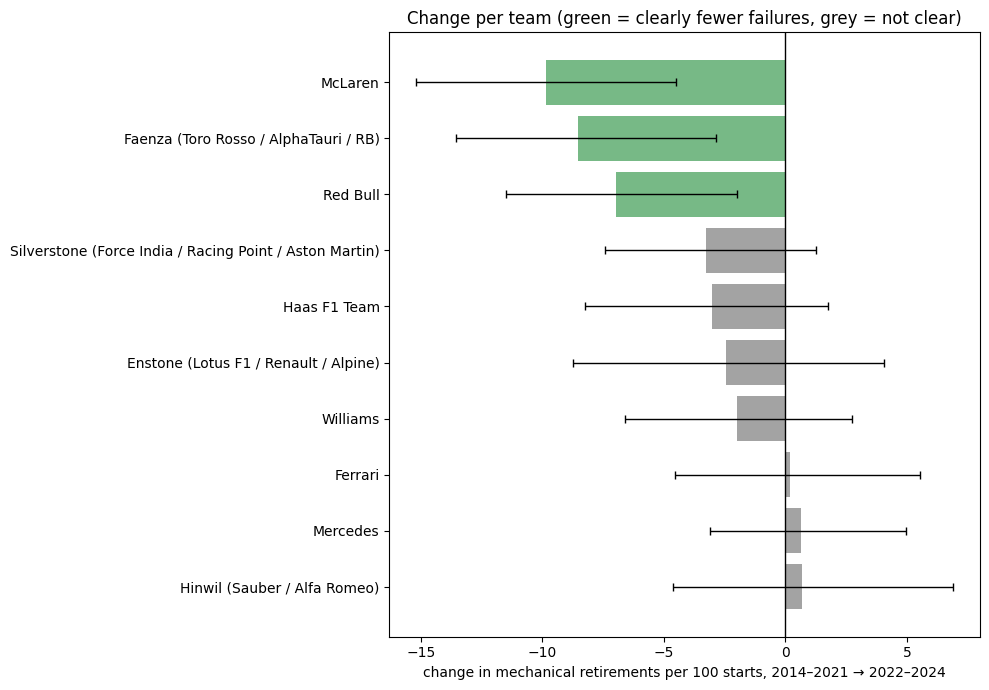

In [613]:
fig, ax = plt.subplots(figsize=(10, 0.55 * len(lin) + 1.5))
d = lin.sort_values("change (points)", ascending=False)
y = np.arange(len(d))
colors = ["#55A868" if h < 0 else ("#C44E52" if l > 0 else GREY) for l, h in zip(d.lo, d.hi)]
ax.barh(y, d["change (points)"], color=colors, alpha=0.8)
ax.errorbar(d["change (points)"], y, xerr=[d["change (points)"] - d.lo, d.hi - d["change (points)"]],
            fmt="none", ecolor="black", capsize=3, lw=1)
ax.axvline(0, color="black", lw=1)
ax.set_yticks(y); ax.set_yticklabels(d.team)
ax.set(xlabel=f"change in mechanical retirements per 100 starts, {P1} → {P2}",
       title="Change per team (green = clearly fewer failures, grey = not clear)")
plt.tight_layout(); savefig("q3_05_team_change"); plt.show()

### 8. Answer and limitations

#### 8.1 Summary

In [614]:
robust = {p: ", ".join(top_group(ct[ct.period == p]).constructor) or "none" for p in PERIODS}
clear_better = ", ".join(lin.loc[lin.hi < 0, "team"]) or "none"
clear_worse = ", ".join(lin.loc[lin.lo > 0, "team"]) or "none"
summary = pd.DataFrame([
    {"part": f"A. Least reliable constructors {P1}", "answer": robust[P1], "evidence": "5.2–5.5"},
    {"part": f"A. Least reliable constructors {P2}", "answer": robust[P2], "evidence": "5.2–5.5"},
    {"part": "B. Overall change", "answer": f"{main['rate before']:.1%} → {main['rate after']:.1%} "
             f"({main['change (points)']:+.1f} points; range {main['_lo']:+.1f} to {main['_hi']:+.1f})", "evidence": "6.2"},
    {"part": "B. Was it the 2022 rules?", "answer": ("yes: also clear against 2019–2021" if late["clear change?"] == "yes"
              else "mostly not: no clear change against 2019–2021"), "evidence": "6.1, 6.2"},
    {"part": "C. Teams clearly more reliable after 2022", "answer": clear_better, "evidence": "7.2"},
    {"part": "C. Teams clearly less reliable after 2022", "answer": clear_worse, "evidence": "7.2"},
])
table(summary, caption="Q3 answers")

part,answer,evidence
A. Least reliable constructors 2014–2021,"Caterham, Lotus F1, Toro Rosso",5.2–5.5
A. Least reliable constructors 2022–2024,"Alfa Romeo, Alpine F1 Team, AlphaTauri",5.2–5.5
B. Overall change,9.1% → 5.5% (-3.6 points; range -5.4 to -1.6),6.2
B. Was it the 2022 rules?,mostly not: no clear change against 2019–2021,"6.1, 6.2"
C. Teams clearly more reliable after 2022,"Red Bull, McLaren, Faenza (Toro Rosso / AlphaTauri / RB)",7.2
C. Teams clearly less reliable after 2022,none,7.2


#### 8.2 Limitations

- **Engine supplier is mixed into team reliability.** In the hybrid era many failures come from the power unit, which several teams buy from the same supplier (for example McLaren's 2015–2017 Honda engines). Ergast does not store the engine supplier, so a team's rate mixes its own reliability with its supplier's.
- **The status gives only the official reason.** "Retired" hides the cause; the upper-bound rate shows how much the grey-zone statuses could matter.
- **The status groups come from the status section** and contain judgment calls (3.3).
- **Team names vs factories.** Part A follows the names as entered; Part C groups them by factory. A renamed team can look like two different constructors in Part A.
- **2022–2024 is only three seasons,** so rates in that period are less precise.
- **The per-team ranges in Part C redraw races, not seasons,** so they do not capture season-long problems and are somewhat optimistic.
- **Sprint races are not in `results.csv`,** so they are not counted.
- **Descriptive only:** the analysis does not show *why* reliability changed.